In [1]:
from networkx.convert import to_networkx_graph
from torch_geometric.utils import to_networkx


import os
from pathlib import Path

PROJECT_DIR = Path.cwd().parent
os.chdir(PROJECT_DIR)

print("PROJECT_DIR:", PROJECT_DIR)
print("Current directory:", Path.cwd())

import numpy as np


from matplotlib import pyplot as plt

from experiments import (
    experiment_train,
    experiment_local_attack_direct,
    experiment_global_attack_direct
)
import helpers.selector_pipeline_helpers

from sparse_smoothing.utils import load_and_standardize
from sparse_smoothing.models import GCN

files = ["cache/demo.json", "cache/demo/demo_1.pt", "cache/evasion_global_adj.json", "cache/evasion_global_attr.json", "cache/evasion_global_adj/evasion_global_adj_1.pt", "cache/evasion_global_attr/evasion_global_attr_1.pt"]

for file_path in files:
    if os.path.exists(file_path):
        os.remove(file_path)
        print(f"{file_path} has been deleted.")
    else:
        print(f"{file_path} does not exist.")

%matplotlib inline


PROJECT_DIR: E:\Masterarbeit\AttackerGNN
Current directory: E:\Masterarbeit\AttackerGNN


Use from seml.experiment import setup_logger instead.
Note that seml.experiment.Experiment already includes the logger setup.
See https://github.com/TUM-DAML/seml/blob/master/examples/example_experiment.py


[08/14/26 17:07:54] WARNING  Importing setup_logger directly from seml is deprecated.                ]8;id=612115;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py\__init__.py]8;;\:]8;id=318978;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py#10\10]8;;\
                             Use from seml.experiment import setup_logger instead.                                 
                             Note that seml.experiment.Experiment already includes the logger setup.               
                             See                                                                                   
                             https://github.com/TUM-DAML/seml/blob/master/examples/example_experimen               
                             t.py                                                                                  

[08/14/26 17:07:54] WARNING  Importing setup_logger directly from seml is deprecated.                ]8;id=665744;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py\__init__.py]8;;\:]8;id=817773;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\seml\__init__.py#10\10]8;;\
                             Use from seml.experiment import setup_logger instead.                                 
                             Note that seml.experiment.Experiment already includes the logger setup.               
                             See                                                                                   
                             https://github.com/TUM-DAML/seml/blob/master/examples/example_experimen               
                             t.py                                                                                  

cache/demo.json does not exist.
cache/demo/demo_1.pt does not exist.
cache/evasion_global_adj.json does not exist.
cache/evasion_global_attr.json does not exist.
cache/evasion_global_adj/evasion_global_adj_1.pt does not exist.
cache/evasion_global_attr/evasion_global_attr_1.pt does not exist.


In [2]:
# ── Dataset / split ─────────────────────────────────────────────────────────
DATASET = 'cora_ml'
SAMPLING = 'stratified'
SPLIT = 'ratio'

# All experiments in this notebook are repeated for these seeds.
# Add/remove values here; every raw table keeps `seed`, while displayed tables
# and plots aggregate over this list.
SEEDS = [0,1]
if not SEEDS:
    raise ValueError("SEEDS must contain at least one integer seed.")
SEEDS = [int(seed) for seed in SEEDS]
SEED = SEEDS[0]  # compatibility alias; never use this for an experiment loop
N_SEEDS = len(SEEDS)

TRAIN_RATIO = 0.15
VAL_RATIO = 0.10
TEST_RATIO = 0.30

# ── Victim model ─────────────────────────────────────────────────────────────
MODEL_NAME = 'GCN'
MODEL_LABEL = 'GCN'
TRAIN_EPOCHS = 200
HIDDEN = 64
INDUCTIVE = True
DROPOUT_VICTIM = 0.5
LR_VICTIM = 1e-2
WEIGHT_DECAY_VICTIM = 1e-3
PATIENCE_VICTIM = 300
MAX_EPOCHS_VICTIM = 3000

# ── V4 mining params ─────────────────────────────────────────────────────────
USE_PRBCD_CANDIDATES = True
N_PRBCD_RUNS = 1
MINER = 'prbcd'
MINER_LOCAL_FACTOR = 0.5
DEGREE_CAP_PCT = None
PRBCD_BUDGET_FRACTION = 0.5
CANDIDATE_SET_SIZES = [1000, 2500]
PRBCD_CANDIDATE_FRACTIONS = [0.0]
SCORING_MODES = ["endpoint","subset_accuracy_drop"]
LABEL_MODES = ["continuous"]
EXTREME_FRACTIONS = [0.3]
PRBCD_EPOCHS = 5
PRBCD_SEARCH_SPACE = 200_000
PRBCD_N_EPOCHS_RESAMPLING = 1


# ── RQ3 subgraph-selector sweep ─────────────────────────────────────────────
# Every requested combination is constructed and trained. Only §8 consumes
# the complete Cartesian product. Legacy RQ3 diagnostics use the primary
# combination selected below.
# A value of 1.0 is an explicit whole-graph selector condition. It uses all
# graph nodes/edges for message passing, while candidate labels are still
# obtained from a finite sampled candidate set.
RQ3_SUBGRAPH_FRACTIONS = [1.0]
RQ3_SUBGRAPH_TRAINING_CANDIDATE_SIZES = [2500,5000,10000]
RQ3_SUBGRAPH_SEEDS = [20]
RQ3_SUBGRAPH_SCORING_MODES = ["endpoint","subset_accuracy_drop"]
RQ3_SUBGRAPH_METHODS = ["stratified_context", "forest_fire"]

# One combination exposed through the legacy names `mining_runs`,
# `lp_training_runs`, and `LP_MODEL_VARIANTS`. This prevents all experiments
# except §8 from silently expanding over the new sweep dimensions.
RQ3_PRIMARY_SUBGRAPH_FRACTION = 1.0
RQ3_PRIMARY_TRAINING_CANDIDATE_SIZE = 10000
RQ3_PRIMARY_SUBGRAPH_SEED = 20
RQ3_PRIMARY_SUBGRAPH_METHOD = "stratified_context"

# ── V4 subset-scoring params ─────────────────────────────────────────────────
N_SUBSETS = 1000
SUBSET_FRACTION = 0.05

# The helper owns the exact schema identifiers. The notebook imports them in
# the mining cell and writes them into every cache key and run dictionary.
# Canonical raw target:
#   mean harmful accuracy drop of subsets in which an edge was selected.

# ── Scorer training params ───────────────────────────────────────────────────
SCORER_HIDDEN = 64
SCORER_EPOCHS = 200
SCORER_LR = 0.01
VAL_FRACTION = 0.2
PATIENCE = 20
# Continuous subset scores are not class-balanced. Keep None unless deliberately
# running a separate projected-label ablation later.
BALANCE_RATIO = None

# ── Reproducibility / aggregation helpers ────────────────────────────────────
import os
import random
import pandas as pd
import torch

from pathlib import Path
from datetime import datetime


def set_global_seed(seed: int, deterministic: bool = True) -> None:
    """Seed Python, NumPy and PyTorch before every independent run."""
    seed = int(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

def aggregate_over_seeds(
    frame: pd.DataFrame,
    group_cols: list[str],
    metric_cols: list[str] | None = None,
) -> pd.DataFrame:
    """Return mean/std/SEM and number of distinct seeds for numeric metrics."""
    if frame is None or frame.empty:
        return pd.DataFrame()
    missing = [column for column in group_cols if column not in frame.columns]
    if missing:
        raise KeyError(f"Missing grouping columns: {missing}")
    if "seed" not in frame.columns:
        raise KeyError("Every raw experiment table must contain a 'seed' column.")
    if metric_cols is None:
        metric_cols = [
            column for column in frame.select_dtypes(include=[np.number]).columns
            if column not in set(group_cols) | {"seed"}
        ]
    metric_cols = [column for column in metric_cols if column in frame.columns]

    if not group_cols:
        row = {"n_seeds": int(frame["seed"].nunique())}
        for metric in metric_cols:
            values = pd.to_numeric(frame[metric], errors="coerce")
            count = int(values.notna().sum())
            mean = float(values.mean()) if count else np.nan
            std = float(values.std(ddof=1)) if count > 1 else 0.0
            row[f"{metric}_mean"] = mean
            row[f"{metric}_std"] = std
            row[f"{metric}_count"] = count
            row[f"{metric}_sem"] = std / np.sqrt(max(1, count))
        return pd.DataFrame([row])

    grouped = frame.groupby(group_cols, dropna=False)
    pieces = []
    if metric_cols:
        stats = grouped[metric_cols].agg(["mean", "std", "count"])
        stats.columns = [f"{metric}_{stat}" for metric, stat in stats.columns]
        stats = stats.reset_index()
        for metric in metric_cols:
            std_col = f"{metric}_std"
            count_col = f"{metric}_count"
            if std_col in stats:
                stats[std_col] = stats[std_col].fillna(0.0)
                stats[f"{metric}_sem"] = stats[std_col] / np.sqrt(
                    stats[count_col].clip(lower=1)
                )
        pieces.append(stats)
    seed_counts = grouped["seed"].nunique().rename("n_seeds").reset_index()
    if not pieces:
        return seed_counts
    return pieces[0].merge(seed_counts, on=group_cols, how="left")


def add_mean_std_band(ax, x, mean, std, *, label=None, **plot_kwargs):
    """Plot a seed mean and a ±1 standard-deviation band."""
    x = np.asarray(x)
    mean = np.asarray(mean, dtype=float)
    std = np.nan_to_num(np.asarray(std, dtype=float), nan=0.0)
    line = ax.plot(x, mean, label=label, **plot_kwargs)[0]
    ax.fill_between(x, mean - std, mean + std, alpha=0.18, color=line.get_color())
    return line

set_global_seed(SEED)
print(f"Configured {N_SEEDS} seeds: {SEEDS}")


The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.
Configured 2 seeds: [0, 1]


Training victim model for seed=0


[08/14/26 17:07:54] INFO     {'dataset': 'cora_ml', 'model_params': {'label': 'GCN',        ]8;id=271493;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=536110;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#180\180]8;;\
                             'model': 'GCN', 'do_cache_adj_prep': True, 'n_filters': 64,                           
                             'dropout': 0.5, 'svd_params': None, 'jaccard_params': None,                           
                             'gdc_params': {'alpha': 0.15, 'k': 64}}, 'train_params':                              
                             {'lr': 0.01, 'weight_decay': 0.001, 'patience': 300,                                  
                             'max_epochs': 3000}, 'binary_attr': False, 'make_undirected':                         
                             True, 'seed': 0, 'artifact_dir': 'cache',                                             
                             'model_storage_type': 'demo_custom_split', 'ppr_cache_params':                        
                             {}, 'device': 'cpu', 'display_steps': 100, 'data_device':                             
                             'cpu'}                                                                                

[08/14/26 17:07:55] INFO     Training set size: 140                                         ]8;id=318046;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=499748;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#216\216]8;;\

                    INFO     Validation set size: 140                                       ]8;id=529202;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=146039;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#217\217]8;;\

                    INFO     Test set size: 2530                                            ]8;id=838234;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=262674;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#218\218]8;;\

...

[08/14/26 17:09:15] INFO                                                                                ]8;id=739595;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\train.py\train.py]8;;\:]8;id=231169;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\train.py#81\81]8;;\
                             Epoch  800: loss_train: 0.07845, loss_val: 0.55637, acc_train: 1.00000,               
                             acc_val: 0.82857                                                                      

[08/14/26 17:09:18] INFO                                                                                ]8;id=446830;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\train.py\train.py]8;;\:]8;id=855546;file://E:\Masterarbeit\AttackerGNN\rgnn_at_scale\train.py#81\81]8;;\
                             Epoch  900: loss_train: 0.07878, loss_val: 0.59411, acc_train: 1.00000,               
                             acc_val: 0.80714                                                                      

                    INFO     Test accuracy is 0.8324110507965088 with seed 1                ]8;id=896870;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=731560;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#271\271]8;;\

                    INFO     Lock 1500691306448 acquired on cache\demo_custom_split.json.lock       ]8;id=665013;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=954220;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#274\274]8;;\

                    INFO     Lock 1500691306448 released on cache\demo_custom_split.json.lock       ]8;id=77591;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=27993;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#318\318]8;;\

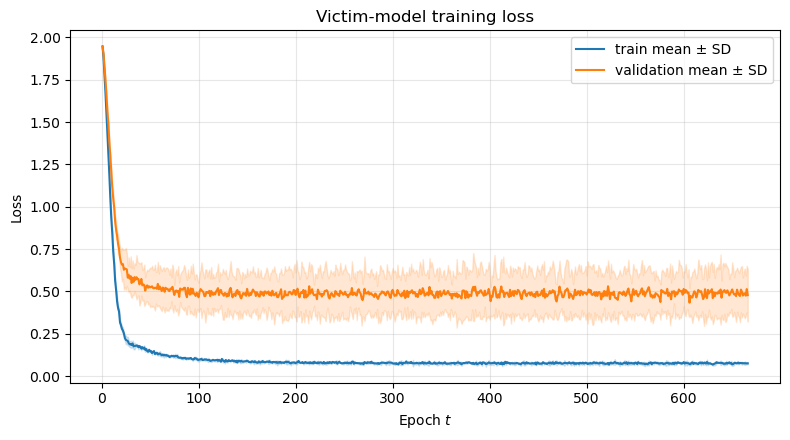

Victim accuracy over 2 seeds: 83.38% ± 0.20% SD


,n_seeds,clean_accuracy_mean,clean_accuracy_std,clean_accuracy_count,clean_accuracy_sem,n_train_epochs_mean,n_train_epochs_std,n_train_epochs_count,n_train_epochs_sem,n_val_epochs_mean,n_val_epochs_std,n_val_epochs_count,n_val_epochs_sem
0,2,0.833794,0.001956,2,0.001383,786.0,169.705627,2,120.0,786.0,169.705627,2,120.0


In [3]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display

seed_victim_runs = []
train_curve_rows = []
train_summary_rows = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for seed in SEEDS:
    print(f"Training victim model for seed={seed}")

    stats = experiment_train.run(
        data_dir='./data',
        dataset=DATASET,
        model_params=dict(
            label=MODEL_LABEL,
            model=MODEL_NAME,
            do_cache_adj_prep=True,
            n_filters=64,
            dropout=DROPOUT_VICTIM,
            svd_params=None,
            jaccard_params=None,
            gdc_params={"alpha": 0.15, "k": 64},
        ),
        train_params=dict(
            lr=LR_VICTIM,
            weight_decay=WEIGHT_DECAY_VICTIM,
            patience=PATIENCE_VICTIM,
            max_epochs=MAX_EPOCHS_VICTIM,
        ),
        binary_attr=False,
        make_undirected=True,
        seed=seed,
        artifact_dir='cache',
        model_storage_type='demo_custom_split',
        ppr_cache_params=dict(),
        device="cpu",
        data_device="cpu",
        display_steps=100,
        debug_level="info",
        custom_split_ratios=None,
    )

    model_seed = stats["model"]
    graph_seed = stats["graph"]
    idx_train_seed = stats["idx_train"]
    idx_val_seed = stats["idx_val"]
    idx_test_seed = stats["idx_test"]
    model_seed.eval()

    attr_matrix_seed, adj_matrix_seed, labels_raw_seed = graph_seed[:3]
    model_device = next(model_seed.parameters()).device
    row, col, value = adj_matrix_seed.coo()
    edge_index_seed = torch.stack([row, col], dim=0).long().to(model_device)
    edge_weight_seed = (
        torch.ones(edge_index_seed.size(1), dtype=torch.float32, device=model_device)
        if value is None else value.float().to(model_device)
    )
    attr_seed = attr_matrix_seed.float().to(model_device)
    labels_seed = labels_raw_seed.long().to(model_device)
    n_nodes_seed = int(adj_matrix_seed.sizes()[0])
    n_edges_directed_seed = int(adj_matrix_seed.nnz())
    n_undirected_seed = n_edges_directed_seed // 2
    clean_acc_seed = float(stats["accuracy"])

    context = {
        "seed": int(seed),
        "train_statistics": stats,
        "clean_acc": clean_acc_seed,
        "model": model_seed,
        "graph": graph_seed,
        "idx_train": idx_train_seed,
        "idx_val": idx_val_seed,
        "idx_test": idx_test_seed,
        "device": model_device,
        "n_nodes": n_nodes_seed,
        "n_edges_directed": n_edges_directed_seed,
        "n_undirected": n_undirected_seed,
        "attr_matrix": attr_matrix_seed,
        "adj_matrix": adj_matrix_seed,
        "labels_raw": labels_raw_seed,
        "edge_index": edge_index_seed,
        "edge_weight": edge_weight_seed,
        "attr": attr_seed,
        "labels": labels_seed,
    }
    seed_victim_runs.append(context)

    for split, values in (
        ("train", stats.get("trace_train", [])),
        ("validation", stats.get("trace_val", [])),
    ):
        for epoch, loss in enumerate(values, start=1):
            train_curve_rows.append({
                "seed": int(seed),
                "split": split,
                "epoch": int(epoch),
                "loss": float(loss),
            })

    train_summary_rows.append({
        "seed": int(seed),
        "clean_accuracy": clean_acc_seed,
        "n_train_epochs": len(stats.get("trace_train", [])),
        "n_val_epochs": len(stats.get("trace_val", [])),
    })

SEED_CONTEXTS = seed_victim_runs
#SEED_CONTEXT_BY_SEED = {context["seed"]: context for context in seed_victim_runs}

train_curve_df = pd.DataFrame(train_curve_rows)
train_summary_raw_df = pd.DataFrame(train_summary_rows)
train_summary_df = aggregate_over_seeds(
    train_summary_raw_df,
    group_cols=[],
    metric_cols=["clean_accuracy", "n_train_epochs", "n_val_epochs"],
)

curve_summary = (
    train_curve_df.groupby(["split", "epoch"], as_index=False)
    .agg(loss_mean=("loss", "mean"), loss_std=("loss", "std"), n_seeds=("seed", "nunique"))
)
curve_summary["loss_std"] = curve_summary["loss_std"].fillna(0.0)
curve_summary = curve_summary[curve_summary["n_seeds"] == N_SEEDS].copy()
if curve_summary.empty:
    raise RuntimeError("No victim-training epochs are shared by every configured seed.")

fig, ax = plt.subplots(figsize=(8, 4.5))
for split, group in curve_summary.groupby("split", sort=False):
    group = group.sort_values("epoch")
    add_mean_std_band(
        ax,
        group["epoch"],
        group["loss_mean"],
        group["loss_std"],
        label=f"{split} mean ± SD",
    )
ax.set_xlabel('Epoch $t$')
ax.set_ylabel("Loss")
ax.set_title("Victim-model training loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

clean_mean = train_summary_raw_df["clean_accuracy"].mean()
clean_std = train_summary_raw_df["clean_accuracy"].std(ddof=1) if N_SEEDS > 1 else 0.0
print(f"Victim accuracy over {N_SEEDS} seeds: {100*clean_mean:.2f}% ± {100*clean_std:.2f}% SD")
display(train_summary_df)


# RQ2 — Mining and Evaluating Harmful Edge Perturbations

RQ1 showed that the scalability of PR-BCD depends on restricting optimization to a sampled candidate block. RQ2 therefore studies whether victim-model evaluations can produce a useful harmfulness ranking over candidate edge flips.

For `subset_accuracy_drop`, one random subset of candidate flips is applied at a time. Let \(d_t=A(G)-A(G\oplus S_t)\) be the signed evaluation-accuracy drop of subset \(S_t\). For candidate edge \(e_i\), the canonical mined target is

\[
s_i
=
\frac{\sum_{t:e_i\in S_t}\max(0,d_t)}
     {\sum_t \mathbf{1}[e_i\in S_t]}.
\]

Thus, \(s_i\) is the **mean harmful subset drop observed when edge \(e_i\) was selected**. It corrects for unequal inclusion frequency.

This is an edge-associated subset score, not an isolated causal effect. Interactions, redundancy, and cancellation between jointly flipped edges remain part of the signal. The later oracle and PR-BCD experiments test whether the resulting noisy score nevertheless provides a useful ranking.

Every mining run stores:

- signed and harmful subset drops;
- inclusion counts;
- raw mean harmful scores;
- normalized scores in \([0,1]\);
- within-run percentile ranks;
- an explicit schema version and score definition.


In [4]:
from helpers.selector_pipeline_helpers import _edge_set
from IPython.display import display
import random
import pandas as pd


def _safe_config_value(value):
    text = f"{value:.12g}" if isinstance(value, float) else str(value)
    return (
        text.strip()
        .replace(" ", "")
        .replace("/", "-")
        .replace("\\", "-")
        .replace(".", "p")
        .replace("+", "")
        .replace("-", "m")
    )

def sample_random_candidates(num_nodes: int, count: int, *, seed: int,):
    """Sample candidate edges"""
    n_possible = num_nodes * (num_nodes - 1) // 2
    rng = random.Random(int(seed))
    sampled = set()
    while len(sampled) < count:
        u = rng.randrange(num_nodes)
        v = rng.randrange(num_nodes)
        if u == v:
            continue
        sampled.add((min(u, v), max(u, v)))
    return sampled

# ---------------------------------------------------------
# Build random candidate sets
# ---------------------------------------------------------

candidate_runs = []

for context in SEED_CONTEXTS:
    seed = int(context["seed"])
    n_nodes = int(context["n_nodes"])
    edge_index = context["edge_index"]
    orig_edges = _edge_set(edge_index)
    for candidate_set_size in CANDIDATE_SET_SIZES:
        candidate_seed = (seed + 20 * candidate_set_size + 17)
        random_candidates = sample_random_candidates(
            num_nodes=n_nodes,
            count=candidate_set_size,
            seed=candidate_seed,
        )
        candidates_for_config = list(random_candidates)
        random.Random(candidate_seed + 1).shuffle(candidates_for_config)
        n_delete_candidates = sum(edge in orig_edges for edge in candidates_for_config)
        n_add_candidates = (candidate_set_size - n_delete_candidates)
        candidate_runs.append({
            "seed": seed,
            "context": context,
            "candidate_set_size": candidate_set_size,
            "n_add_candidates": n_add_candidates,
            "n_delete_candidates": n_delete_candidates,
            "candidates": candidates_for_config,
        })

# ---------------------------------------------------------
# Summary table
# ---------------------------------------------------------

candidate_config_raw_df = pd.DataFrame([
    {
        key: value
        for key, value in run.items()
        if key not in {
            "context",
            "candidates",
        }
    }
    for run in candidate_runs
])
candidate_config_df = aggregate_over_seeds(
    candidate_config_raw_df,
    ["candidate_set_size"],
    ["n_add_candidates", "n_delete_candidates"],
)
display(candidate_config_df)
print(
    f"Created {len(candidate_runs)} candidate runs = "
    f"{len(SEEDS)} seeds × "
    f"{len(candidate_set_size)} candidate-set sizes."
)

,candidate_set_size,n_add_candidates_mean,n_add_candidates_std,n_add_candidates_count,n_delete_candidates_mean,n_delete_candidates_std,n_delete_candidates_count,n_add_candidates_sem,n_delete_candidates_sem,n_seeds
0,1000,999.0,0.000000,2,1.0,0.000000,2,0.0,0.0,2
1,2500,2490.5,0.707107,2,9.5,0.707107,2,0.5,0.5,2


Created 4 candidate runs = 2 seeds × 2500 candidate-set sizes.


---
## §2  Subset Scoring

We run `N_SUBSETS` random subsets of the candidate pool and apply each subset jointly.

For each subset, the notebook stores both:

- the signed accuracy drop \(A(G)-A(G\oplus S)\);
- the harmful-only drop \(\max(0, A(G)-A(G\oplus S))\).

For every edge, the harmful drops are divided by the number of subsets in which that edge appeared. The canonical raw score is therefore the **mean harmful subset drop when selected**, rather than the accumulated sum.

The run also stores a max-normalized score in \([0,1]\), a percentile rank, the inclusion count, and an observed mask. Unobserved candidates are marked as unobserved rather than being treated as genuine zero-score edges.


---

## Experiment 1 — Direct Mining of Harmful Candidates

### Research objective

This experiment constructs candidate edge perturbations and evaluates them against the fixed victim model.

For `subset_accuracy_drop`, random candidate subsets are flipped jointly. Every selected edge receives the subset's harmful accuracy drop, and its final raw score is the average of those assigned drops over all subsets in which it appeared.

The resulting value is an observational, subset-associated harmfulness score. It should not be interpreted as the isolated accuracy effect of the edge.

### Execution block

The following cell:

- loads or computes versioned mining results;
- rejects caches created with the previous accumulated-sum target;
- filters candidates that were never observed;
- exposes raw, normalized, and percentile score representations;
- preserves signed-drop, harmful-drop, and inclusion-count diagnostics;
- creates the standardized `mining_runs` objects used downstream.


In [5]:
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd
import torch

from helpers.selector_pipeline_helpers import (
    mine_candidate_edge_scores,
    _dense_adj,
)
# ---------------------------------------------------------
# Score candidate sets
# ---------------------------------------------------------

mining_runs = []

for candidate_run in candidate_runs:

    context = candidate_run["context"]
    seed = int(candidate_run["seed"])
    model = context["model"]
    attr = context["attr"]
    edge_index = context["edge_index"]
    labels = context["labels"]
    idx_test = context["idx_test"]
    n_nodes = int(context["n_nodes"])
    device = attr.device
    candidates = list(candidate_run["candidates"])

    for scoring_mode in SCORING_MODES:
        print(f"\nScoring seed={seed} | "f"{candidate_run['candidate_set_size']} | "f"mode={scoring_mode}")
        result = mine_candidate_edge_scores(
            model=model,
            attr=attr,
            edge_index=edge_index,
            labels=labels,
            eval_idx=idx_test,
            candidates=candidates,
            n_nodes=n_nodes,
            mode=scoring_mode,
            subset_fraction=SUBSET_FRACTION,
            n_subsets=N_SUBSETS,
            seed=seed,
            device=device,
        )
        scored_candidates = list(candidates)

        score_raw = np.asarray(result["labels_raw"], dtype=np.float64).reshape(-1)
        score_norm = np.asarray(result["labels_norm"],dtype=np.float32).reshape(-1)

        exists = np.asarray(result.get("exists").reshape(-1))

        # Remove unobserved candidate edges, only relevant for subset accuracy drop scores.
        if scoring_mode == "subset_accuracy_drop":
            inclusion_count = np.asarray(result["inclusion_count"],dtype=np.int64).reshape(-1)
            observed_mask = inclusion_count > 0
        else:
            inclusion_count = np.ones(len(scored_candidates),dtype=np.int64)
            observed_mask = np.ones(len(scored_candidates),dtype=bool)

        n_total = len(scored_candidates)
        n_observed = int(observed_mask.sum())
        n_unobserved = n_total - n_observed
        scored_candidates = [
            candidate
            for candidate, observed
            in zip(scored_candidates, observed_mask)
            if observed
        ]
        score_raw = score_raw[observed_mask]
        score_norm = score_norm[observed_mask]
        exists = exists[observed_mask]
        inclusion_count = inclusion_count[observed_mask]
        src = np.asarray([u for u, _ in scored_candidates],dtype=np.int64)
        dst = np.asarray([v for _, v in scored_candidates],dtype=np.int64)
        n_positive = int(np.sum(score_norm > 0))
        clean_accuracy = float(result["clean_accuracy"])

        # Store results for RQ2 experiments and selector training
        run = {
            "seed": seed,
            "context": context,
            "candidate_set_size": candidate_run["candidate_set_size"],
            "scoring_mode": scoring_mode,
            "candidate_pool": candidates,
            "candidates": scored_candidates,
            "n_candidates_total": n_total,
            "n_cands": n_observed,
            "n_unobserved_candidates": n_unobserved,
            "score_raw": score_raw,
            "score_norm": score_norm,
            "labels_raw":score_raw,
            "labels_norm": score_norm,
            "labels_changed":
                torch.tensor(
                    score_norm,
                    dtype=torch.float32,
                    device=device,
                ),
            "src":
                torch.tensor(
                    src,
                    dtype=torch.long,
                    device=device,
                ),
            "dst":
                torch.tensor(
                    dst,
                    dtype=torch.long,
                    device=device,
                ),
            "exists":
                torch.tensor(
                    exists,
                    dtype=torch.float32,
                    device=device,
                ),
            "inclusion_count":inclusion_count,
            "clean_accuracy": clean_accuracy,
            "n_positive_labels": n_positive,
            "mining_result": result,
        }

        mining_runs.append(run)


Scoring seed=0 | 1000 | mode=endpoint
Clean accuracy: 0.8352
Candidates evaluated: 1000
Endpoint hits: 105/1000 (10.50%)

Scoring seed=0 | 1000 | mode=subset_accuracy_drop
Clean evaluation accuracy: 0.8352
Subset size: 50.0 (5% of 1000 candidates)
Subsets run: 1000
Accuracy drop per subset: mean=0.0022  max=0.0075  zero_rate=11.00%
Edges with score > 0: 1000/1000 (100.0%)

Scoring seed=0 | 2500 | mode=endpoint
Clean accuracy: 0.8352
Candidates evaluated: 2500
Endpoint hits: 256/2500 (10.24%)

Scoring seed=0 | 2500 | mode=subset_accuracy_drop
Clean evaluation accuracy: 0.8352
Subset size: 125.0 (5% of 2500 candidates)
Subsets run: 1000
Accuracy drop per subset: mean=0.0040  max=0.0111  zero_rate=4.20%
Edges with score > 0: 2500/2500 (100.0%)

Scoring seed=1 | 1000 | mode=endpoint
Clean accuracy: 0.8324
Candidates evaluated: 1000
Endpoint hits: 113/1000 (11.30%)

Scoring seed=1 | 1000 | mode=subset_accuracy_drop
Clean evaluation accuracy: 0.8324
Subset size: 50.0 (5% of 1000 candidates)

---
## §3  Continuous Score Distribution

The canonical raw label is the mean harmful subset accuracy drop observed when an edge was selected. It remains in the original accuracy-drop scale.

For selector training, the raw score is divided by the largest observed raw score within the mining run, producing `score_norm` in \([0,1]\). This is a relative harmfulness score, not a probability.

`score_percentile` stores the tie-aware within-run rank. `observed_mask` distinguishes evaluated zero-score candidates from candidates that were never included in any sampled subset.


### Analysis and plotting block

The following cells characterize the candidates obtained through direct mining.

The analysis examines:

- the number and proportion of positive labels;
- the balance between label-1 and label-0 candidates;
- edge additions versus edge deletions;
- the number of distinct affected endpoints;
- structural differences between label groups;
- the distribution of accuracy-drop scores;
- the overlap between local endpoint harmfulness and global accuracy effects.

This analysis addresses the first step of the RQ2 argument:

> Are harmful candidates observable through direct local or global evaluations, and how are they distributed within the candidate space?

These descriptive results do not yet establish that the candidates remain harmful when several perturbations are applied jointly. That question is addressed by the oracle and injection experiments.

In [7]:
# ============================================================
# RQ2: Compare graph/model properties of candidate edges
#
# endpoint:
#   group 1 = harmful
#   group 0 = non-harmful
#
# subset_accuracy_drop:
#   group 1 = top 10% raw score
#   group 0 = bottom 10% raw score
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import torch
import networkx as nx

from scipy.stats import mannwhitneyu, fisher_exact
from IPython.display import display

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

RQ2_SUBSET_EXTREME_FRACTION = 0.10

RQ2_OUT_DIR = (
    Path("extendedPlotting")
    / "rq2_simple_endpoint_and_subset_stats"
)

RQ2_OUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# Small helpers
# ------------------------------------------------------------

def _to_numpy(value):
    if torch.is_tensor(value):
        return value.detach().cpu().numpy()

    return np.asarray(value)


def _compute_clean_stats(context):
    """
    Compute edge node- level comparison statistics.

    Returns:
        degree
        PageRank
        prediction
        confidence
        margin
        true label
    """

    n_nodes = context["n_nodes"]
    edge_index = context["edge_index"]
    attr = context["attr"]
    adj = context["adj_matrix"]
    labels = context["labels"]
    model = context["model"]
    device = attr.device

    # Build nx Graph for degree and pagerank
    graph = nx.Graph()
    graph.add_nodes_from(range(n_nodes))
    graph.add_edges_from(
        (int(u),int(v))
        for u, v in zip(
            edge_index[0],
            edge_index[1],
        )
        if u != v
    )

    # Compute degree and pagerank from reconstructed nx Graph
    degree = np.asarray([graph.degree(node) for node in range(n_nodes)],dtype=float)
    pagerank_dict = nx.pagerank(graph,alpha=0.85)
    pagerank = np.asarray([pagerank_dict[node] for node in range(n_nodes)],dtype=float)

    model.eval()

    with torch.no_grad():
        # Compute confidence and margin
        logits = model(attr, adj)
        probabilities = torch.softmax(logits, dim=-1)
        prediction = logits.argmax(dim=-1)
        confidence = probabilities.max(dim=-1).values

        top2 = torch.topk(probabilities,k=2,dim=-1).values
        margin = (top2[:, 0] - top2[:, 1])

    return {
        "degree":degree,
        "pagerank":pagerank,
        "prediction":prediction.detach().cpu().numpy(),
        "confidence":confidence.detach().cpu().numpy(),
        "margin": margin.detach().cpu().numpy(),
        "labels": labels.detach().cpu().numpy(),
    }

# ------------------------------------------------------------
# Build candidate-level dataframe
# ------------------------------------------------------------

rows = []

for run_index, run in enumerate(mining_runs):

    seed = int(run["seed"])
    scoring_mode = str(run["scoring_mode"])
    context = run["context"]
    candidate_set_size = run["candidate_set_size"]

    clean_stats = _compute_clean_stats(context)
    candidates = list(run["candidates"])
    exists = _to_numpy(run["exists"]).astype(bool).reshape(-1)
    score_raw = np.asarray(run["score_raw"],dtype=float).reshape(-1)
    labels_changed = _to_numpy(run["labels_changed"]).astype(float).reshape(-1)
    n_candidates = run["n_cands"]

    # Make sure everything is aligned.
    if not (
        len(exists)
        == len(score_raw)
        == len(labels_changed)
        == n_candidates
    ):
        raise ValueError(
            f"Candidate arrays are not aligned for "
            f"seed={seed}, "
            f"size={candidate_set_size}, "
            f"mode={scoring_mode}."
        )

    # Build comparison groups from ordered scores on the candidate set.
    if scoring_mode == "endpoint":
        selected_indices = np.arange(n_candidates)
        comparison_groups = (labels_changed > 0.5).astype(int) # indicates which candidates are used
    else:
        n_valid = len(score_raw)
        n_per_group = int(np.floor(RQ2_SUBSET_EXTREME_FRACTION * n_valid))

        ordered_indices = np.argsort(score_raw)

        bottom_indices = (ordered_indices[:n_per_group])
        top_indices = (ordered_indices[-n_per_group:])
        selected_indices = np.concatenate([bottom_indices,top_indices])
        comparison_groups = np.concatenate([np.zeros(n_per_group,dtype=int),np.ones(n_per_group,dtype=int)])

        print(
            f"[subset] "
            f"seed={seed} | "
            f"size={candidate_set_size} | "
            f"valid={n_valid} | "
            f"bottom={n_per_group} | "
            f"top={n_per_group} | "
            f"bottom cutoff="
            f"{score_raw[bottom_indices[-1]]:.6f} | "
            f"top cutoff="
            f"{score_raw[top_indices[0]]:.6f}"
        )

    # ========================================================
    # Build selected candidate rows
    # ========================================================

    for local_index, candidate_index in enumerate(selected_indices):

        u, v = candidates[candidate_index]
        group = int(comparison_groups[local_index])

        # ----------------------------------------------------
        # Addition / deletion
        # ----------------------------------------------------

        action = ("delete" if exists[candidate_index] else "add")

        # Compute node level statistics for candidate comparison groups
        degree_u = float(clean_stats["degree"][u])
        degree_v = float(clean_stats["degree"][v])
        pagerank_u = float(clean_stats["pagerank"][u])
        pagerank_v = float(clean_stats["pagerank"][v])
        confidence_u = float(clean_stats["confidence"][u])
        confidence_v = float(clean_stats["confidence"][v])
        margin_u = float(clean_stats["margin"][u])
        margin_v = float(clean_stats["margin"][v])
        true_u = int(clean_stats["labels"][u])
        true_v = int(clean_stats["labels"][v])
        pred_u = int(clean_stats["prediction"][u])
        pred_v = int(clean_stats["prediction"][v])


        rows.append({
            "run_index": run_index,
            "seed": seed,
            "candidate_set_size":candidate_set_size,
            "scoring_mode":scoring_mode,
            "candidate_index": candidate_index,
            "u": u,
            "v": v,
            "group": group,
            "group_name":
                (
                    "harmful"
                    if scoring_mode == "endpoint"
                    and group == 1

                    else "non_harmful"
                    if scoring_mode == "endpoint"

                    else "top_10_percent"
                    if group == 1

                    else "bottom_10_percent"
                ),
            "score_raw": float(score_raw[candidate_index]),
            "action": action,

            "u_degree": degree_u,
            "v_degree": degree_v,
            "mean_degree": (degree_u + degree_v) / 2.0,

            "u_pagerank": pagerank_u,
            "v_pagerank": pagerank_v,
            "mean_pagerank": (pagerank_u + pagerank_v) / 2.0,

            "u_margin": margin_u,
            "v_margin": margin_v,
            "min_margin": min(margin_u, margin_v),

            "u_confidence": confidence_u,
            "v_confidence": confidence_v,

            "min_confidence": min(confidence_u, confidence_v),

            "same_true_class": bool(true_u == true_v),
            "same_clean_prediction": bool(pred_u == pred_v),

            "both_endpoints_clean_correct": bool(pred_u == true_u and pred_v == true_v),
        })

#
node_statistics_df = pd.DataFrame(rows)

result_rows = []
for (seed, candidate_set_size, scoring_mode), frame in node_statistics_df.groupby(
    ["seed", "candidate_set_size", "scoring_mode"]
):

    group_harmful = frame[frame["group"] == 1]
    group_nonharmful = frame[frame["group"] == 0]

    result_rows.append({
        "seed": seed,
        "candidate_set_size": candidate_set_size,
        "scoring_mode": scoring_mode,

        "group_1_n": len(group_harmful),
        "group_0_n": len(group_nonharmful),

        "group_1_prevalence": (
            float((frame["group"] == 1).mean())
            if scoring_mode == "endpoint"
            else np.nan
        ),

        "group_0_prevalence": (
            float((frame["group"] == 0).mean())
            if scoring_mode == "endpoint"
            else np.nan
        ),

        "group_1_raw_score": (
            float(group_harmful["score_raw"].mean())
            if scoring_mode == "subset_accuracy_drop"
            else np.nan
        ),

        "group_0_raw_score": (
            float(group_nonharmful["score_raw"].mean())
            if scoring_mode == "subset_accuracy_drop"
            else np.nan
        ),

        "group_1_min_confidence": float(group_harmful["min_confidence"].mean()),
        "group_0_min_confidence": float(group_nonharmful["min_confidence"].mean()),
        "difference_min_confidence": float(
            group_harmful["min_confidence"].mean()
            - group_nonharmful["min_confidence"].mean()
        ),

        "group_1_min_margin": float(group_harmful["min_margin"].mean()),
        "group_0_min_margin": float(group_nonharmful["min_margin"].mean()),
        "difference_min_margin": float(
            group_harmful["min_margin"].mean()
            - group_nonharmful["min_margin"].mean()
        ),

        "group_1_both_clean_correct": float(
            group_harmful["both_endpoints_clean_correct"].mean()
        ),
        "group_0_both_clean_correct": float(
            group_nonharmful["both_endpoints_clean_correct"].mean()
        ),
        "difference_both_clean_correct": float(
            group_harmful["both_endpoints_clean_correct"].mean()
            - group_nonharmful["both_endpoints_clean_correct"].mean()
        ),

        "group_1_same_true_class": float(group_harmful["same_true_class"].mean()),
        "group_0_same_true_class": float(group_nonharmful["same_true_class"].mean()),
        "difference_same_true_class": float(
            group_harmful["same_true_class"].mean()
            - group_nonharmful["same_true_class"].mean()
        ),

        "group_1_same_clean_prediction": float(
            group_harmful["same_clean_prediction"].mean()
        ),
        "group_0_same_clean_prediction": float(
            group_nonharmful["same_clean_prediction"].mean()
        ),
        "difference_same_clean_prediction": float(
            group_harmful["same_clean_prediction"].mean()
            - group_nonharmful["same_clean_prediction"].mean()
        ),

        "group_1_mean_degree": float(group_harmful["mean_degree"].mean()),
        "group_0_mean_degree": float(group_nonharmful["mean_degree"].mean()),
        "difference_mean_degree": float(
            group_harmful["mean_degree"].mean()
            - group_nonharmful["mean_degree"].mean()
        ),

        "group_1_mean_pagerank": float(group_harmful["mean_pagerank"].mean()),
        "group_0_mean_pagerank": float(group_nonharmful["mean_pagerank"].mean()),
        "difference_mean_pagerank": float(
            group_harmful["mean_pagerank"].mean()
            - group_nonharmful["mean_pagerank"].mean()
        ),
    })

rq2_results_df = pd.DataFrame(result_rows)

rq2_results_df = (
    rq2_results_df
    .drop(columns="seed")
    .groupby(["candidate_set_size", "scoring_mode"])
    .agg(["mean", "std"])
    .reset_index()
)

rq2_results_df.columns = [
    "_".join(str(part) for part in column if str(part))
    if isinstance(column, tuple)
    else column
    for column in rq2_results_df.columns
]

display(rq2_results_df)

rq2_results_df.to_csv(
    RQ2_OUT_DIR
    / (
        f"rq2_diagnostic_statistics_{DATASET}"
        f"_candidates{'-'.join(map(str, CANDIDATE_SET_SIZES))}"
        f"_seeds{'-'.join(map(str, SEEDS))}.csv"
    ),
    index=False,
)

print(f"\nSaved to: {RQ2_OUT_DIR.resolve()}")

[subset] seed=0 | size=1000 | valid=1000 | bottom=100 | top=100 | bottom cutoff=0.085375 | top cutoff=0.135572
[subset] seed=0 | size=2500 | valid=2500 | bottom=250 | top=250 | bottom cutoff=0.158892 | top cutoff=0.242686
[subset] seed=1 | size=1000 | valid=1000 | bottom=100 | top=100 | bottom cutoff=0.078260 | top cutoff=0.125691
[subset] seed=1 | size=2500 | valid=2500 | bottom=250 | top=250 | bottom cutoff=0.191699 | top cutoff=0.288141


,candidate_set_size,scoring_mode,group_1_n_mean,group_1_n_std,group_0_n_mean,group_0_n_std,group_1_prevalence_mean,group_1_prevalence_std,group_0_prevalence_mean,group_0_prevalence_std,...,group_0_mean_degree_mean,group_0_mean_degree_std,difference_mean_degree_mean,difference_mean_degree_std,group_1_mean_pagerank_mean,group_1_mean_pagerank_std,group_0_mean_pagerank_mean,group_0_mean_pagerank_std,difference_mean_pagerank_mean,difference_mean_pagerank_std
0,1000,endpoint,109.0,5.656854,891.0,5.656854,0.1090,0.005657,0.8910,0.005657,...,5.696384,0.095970,-2.248344,0.199745,0.000253,0.000016,0.000353,8.484704e-08,-0.000100,0.000016
1,1000,subset_accuracy_drop,100.0,0.000000,100.0,0.000000,NaN,NaN,NaN,NaN,...,4.852500,0.031820,-0.097500,0.512652,0.000314,0.000031,0.000311,4.088340e-06,0.000003,0.000027
2,2500,endpoint,268.5,17.677670,2231.5,17.677670,0.1074,0.007071,0.8926,0.007071,...,5.907066,0.211412,-2.263494,0.273535,0.000270,0.000004,0.000366,7.002490e-06,-0.000096,0.000003
3,2500,subset_accuracy_drop,250.0,0.000000,250.0,0.000000,NaN,NaN,NaN,NaN,...,5.793000,0.188090,-0.248000,0.726906,0.000352,0.000025,0.000354,1.439214e-06,-0.000003,0.000026



Saved to: E:\Masterarbeit\AttackerGNN\extendedPlotting\rq2_simple_endpoint_and_subset_stats


---

## Experiment 3 — Oracle Evaluation of Joint and Conditional Harmfulness

### Research objective

An edge that is harmful when evaluated individually does not necessarily remain harmful when combined with other perturbations.

The oracle experiment applies candidate perturbations cumulatively and compares two orderings:

1. candidates ordered by their mined harmfulness score;
2. candidates placed in a random order.

For an ordering \(e_1,\ldots,e_n\), define the cumulative perturbation block

\[
B_k=\{e_1,\ldots,e_k\}.
\]

The test accuracy after applying the first \(k\) candidates is

\[
A_k=A(G\oplus B_k).
\]

The experiment first determines whether mined candidates construct a stronger standalone attack than random candidates. It then examines whether each newly added flip block remains harmful under the perturbations already present.

### Execution block

Candidates are added cumulatively in steps of `BLOCK_STEP_ORACLE`.

For every step, the experiment records:

- the previous cumulative block size;
- the new cumulative block size;
- the number of newly added edges;
- accuracy before adding the new flip block;
- accuracy after adding the new flip block;
- cumulative accuracy drop;
- maximum accuracy drop observed so far.

The marginal conditional effect of the newly added flip block is

\[
\Delta A_k
=
A(B_{k-1})-A(B_k).
\]

The newly added block is classified as:

- **conditionally harmful** when \(\Delta A_k>0\);
- **neutral** when \(\Delta A_k\approx 0\);
- **cancelling** when \(\Delta A_k<0\).

With `BLOCK_STEP_ORACLE = 10`, the conditional effect refers to a block of up to ten newly added perturbations. Setting the value to one produces an individual-edge conditional analysis.

In [14]:
# ============================================================
# RQ2: Conjunction experiment accuracy trajectories
#
# endpoint:
#   label 1 first vs label 0 first vs random
#
# subset_accuracy_drop:
#   highest score first vs lowest score first vs random
# ============================================================

from helpers.selector_pipeline_helpers import accuracy
from tqdm.auto import tqdm

import numpy as np
import pandas as pd

from torch_sparse import SparseTensor

BLOCK_STEP_CONJUNCTION = 10 # How many edges are flipped at once
conjunction_rows = []

# Flips one edge from the candidate set identified by the index
def _flip_candidate_sparse(adj, candidates, exists, candidate_index):
    u, v = candidates[candidate_index]
    delta = -1.0 if exists[candidate_index] else 1.0
    change = SparseTensor(
        row=torch.tensor([u, v], device=adj.device()),
        col=torch.tensor([v, u], device=adj.device()),
        value=torch.tensor([delta, delta], device=adj.device()),
        sparse_sizes=adj.sparse_sizes(),
    )
    return (adj + change).coalesce()


# Run conjunction experiment
for run_index, run in enumerate(mining_runs):

    seed = run["seed"]
    scoring_mode = run["scoring_mode"]
    candidate_set_size = run["candidate_set_size"]
    context = run["context"]

    candidates = list(run["candidates"])
    exists = run["exists"].numpy().astype(bool)
    score_raw = np.asarray(run["score_raw"], dtype=float)
    labels_changed = (run["labels_changed"]).numpy()
    n_candidates = run["n_cands"]

    # Build orderings for the evaluated run
    orders = {}
    if scoring_mode == "endpoint":
        # Endpoint label 1 first, then label 0
        orders["endpoint_label_desc"] = np.argsort(-labels_changed)
        # Endpoint label 0 first, then label 1
        orders["endpoint_label_asc"] = np.argsort(labels_changed)
    else:
        # Highest subset accuracy drop scores first
        orders["subset_score_desc"] = np.argsort(-score_raw)
        # Lowest subset accuracy drop score first
        orders["subset_score_asc"] = np.argsort(score_raw)

    # Random control ordering
    rng = np.random.default_rng(seed + run_index)
    orders["random"] = rng.permutation(n_candidates)

    # ========================================================
    # Evaluation steps
    # ========================================================

    block_sizes = list(range(BLOCK_STEP_CONJUNCTION, n_candidates + 1, BLOCK_STEP_CONJUNCTION))

    if not block_sizes or block_sizes[-1] != n_candidates:
        block_sizes.append(n_candidates)

    # ========================================================
    # Evaluate every ordering
    # ========================================================

    for ordering_name, order in orders.items():
        # Every ordering starts from the clean graph
        adj = context["adj_matrix"].clone()
        previous_k = 0

        # Append for the initial conjunction experiment epoch
        conjunction_rows.append({
            "seed": seed,
            "candidate_set_size": candidate_set_size,
            "scoring_mode": scoring_mode,
            "ordering": ordering_name,
            "k": 0,
            "victim_accuracy_drop": 0.0,
        })

        for k in tqdm(block_sizes,
            desc=f"seed={seed}, size={candidate_set_size}, mode={scoring_mode}, order={ordering_name}"
        ):
            # Only flip the newly added candidates
            for candidate_index in order[previous_k:k]:
                adj = _flip_candidate_sparse(adj, candidates, exists, candidate_index)
            # Compute victim accuracy after k flips
            victim_accuracy = float(accuracy(context["model"], context["attr"], context["labels"], context["idx_test"], edge_index=adj))

            # Compute victim accuracy drop from clean baseline after k flips
            victim_accuracy_drop = run["clean_accuracy"] - victim_accuracy
            conjunction_rows.append({
                "seed": seed,
                "candidate_set_size": candidate_set_size,
                "scoring_mode": scoring_mode,
                "ordering": ordering_name,
                "k": k,
                "victim_accuracy_drop": victim_accuracy_drop,
            })
            previous_k = k


# ============================================================
# Final dataframe
# ============================================================

conjunction_accuracy_df = pd.DataFrame(
    conjunction_rows
)

display(conjunction_accuracy_df)

,seed,candidate_set_size,scoring_mode,ordering,k,victim_accuracy_drop
0,0,1000,endpoint,endpoint_label_desc,0,0.000000
1,0,1000,endpoint,endpoint_label_desc,10,0.002767
2,0,1000,endpoint,endpoint_label_desc,20,0.006719
3,0,1000,endpoint,endpoint_label_desc,30,0.010672
4,0,1000,endpoint,endpoint_label_desc,40,0.013834
...,...,...,...,...,...,...
4219,1,2500,subset_accuracy_drop,random,2460,0.040316
4220,1,2500,subset_accuracy_drop,random,2470,0.040316
4221,1,2500,subset_accuracy_drop,random,2480,0.040316
4222,1,2500,subset_accuracy_drop,random,2490,0.040316


### Analysis and plotting block

The oracle results are analyzed at two levels.

#### Step-level analysis

The step-level analysis reports the evolution of:

- cumulative attacked accuracy;
- marginal conditional effect \(\Delta A_k\);
- cumulative accuracy drop;
- maximum accuracy drop reached so far.

#### Run-level analysis

For each victim seed, candidate configuration, and ordering, the following measures are computed:

- proportion of conditionally harmful additions;
- proportion of neutral additions;
- proportion of cancelling additions;
- final cumulative accuracy drop;
- maximum achieved accuracy drop;
- number of edges at which the maximum drop occurs;
- number of edges required to reach fixed accuracy reductions;
- largest harmful marginal step;
- largest cancelling marginal step.

The main comparison is

\[
\text{mined ordering}
\quad\text{versus}\quad
\text{random ordering}.
\]

This experiment provides the central evidence for conditional harmfulness. It determines whether the mined ordering produces more damaging combinations and reveals how often harmfulness persists, disappears, or reverses as the perturbation block grows.

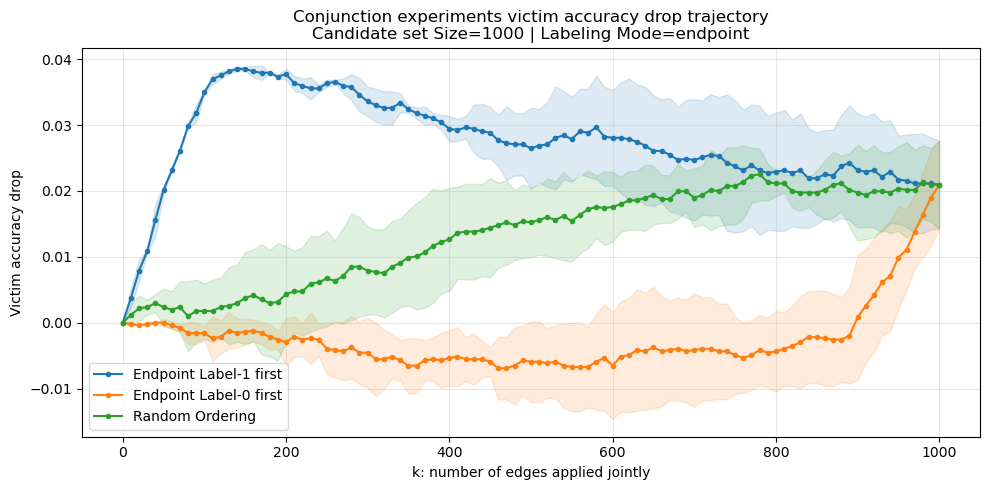

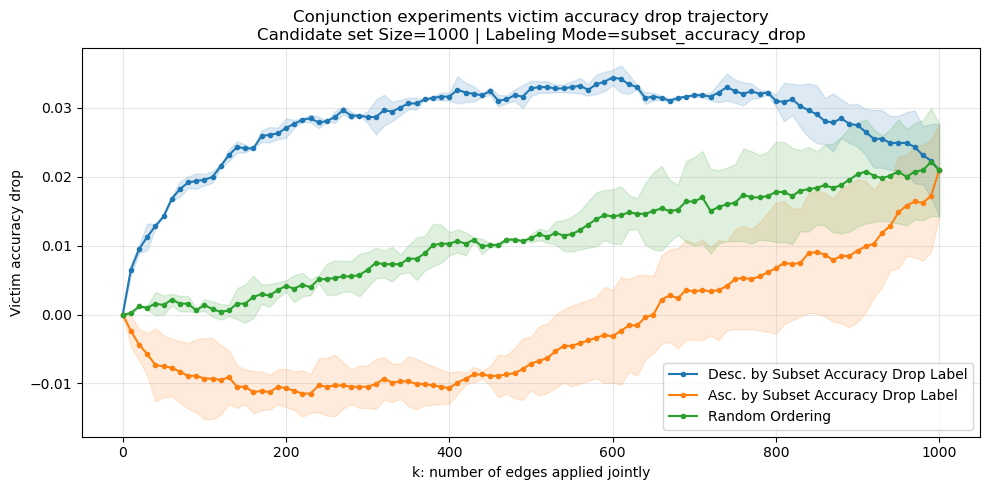

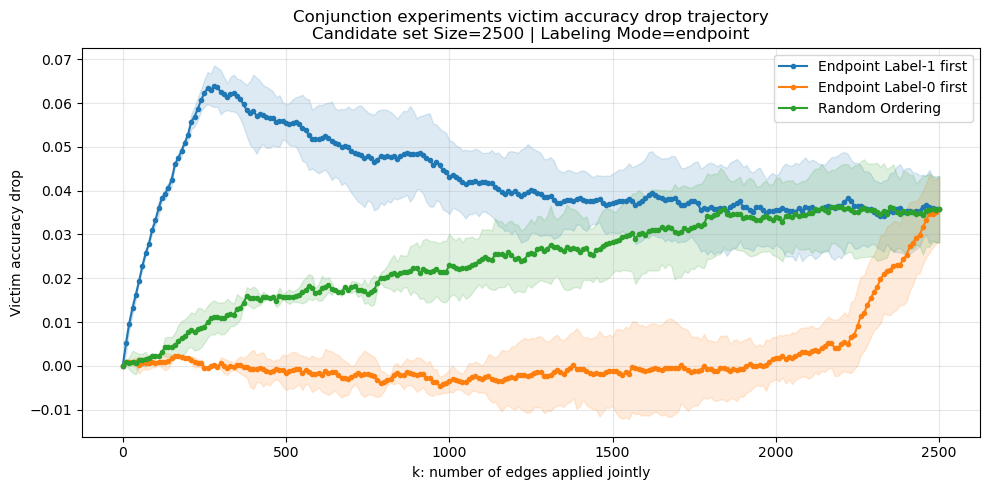

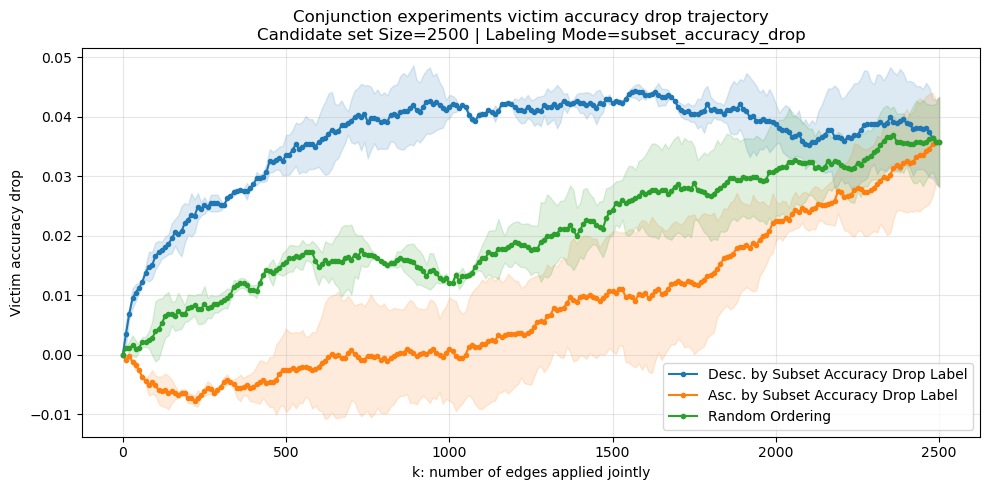

Saved conjunction experiment plots to: E:\Masterarbeit\AttackerGNN\extendedPlotting\conjunction_experiment


In [15]:
# ============================================================
# Plot conjunction experiment trajectories
#
# One plot per:
#   candidate_set_size × scoring_mode
#
# y-axis:
#   victim_accuracy_drop
#
# lines:
#   descending / ascending / random
#
# shading:
#   ±1 standard deviation across seeds
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

CONJUNCTION_PLOT_DIR = Path("extendedPlotting/conjunction_experiment")
CONJUNCTION_PLOT_DIR.mkdir(parents=True, exist_ok=True)

conjunction_plot_df = (
    conjunction_accuracy_df
    .groupby(["candidate_set_size", "scoring_mode", "ordering", "k"], dropna=False)
    .agg(
        victim_accuracy_drop_mean=("victim_accuracy_drop", "mean"),
        victim_accuracy_drop_std=("victim_accuracy_drop", "std"),
        n_seeds=("seed", "nunique"),
    )
    .reset_index()
)

conjunction_plot_df["victim_accuracy_drop_std"] = (
    conjunction_plot_df["victim_accuracy_drop_std"]
    .fillna(0.0)
)


# ------------------------------------------------------------
# Labels for legend
# ------------------------------------------------------------

ordering_labels = {
    "endpoint_label_desc": "Endpoint Label-1 first",
    "endpoint_label_asc": "Endpoint Label-0 first",
    "subset_score_desc": "Desc. by Subset Accuracy Drop Label",
    "subset_score_asc": "Asc. by Subset Accuracy Drop Label",
    "random": "Random Ordering",
}


# ------------------------------------------------------------
# Plot one figure per candidate_set_size × scoring_mode
# ------------------------------------------------------------

for (candidate_set_size, scoring_mode), frame in conjunction_plot_df.groupby(
    ["candidate_set_size", "scoring_mode"],
    dropna=False,
):

    if scoring_mode == "endpoint":
        ordering_sequence = [
            "endpoint_label_desc",
            "endpoint_label_asc",
            "random",
        ]
    elif scoring_mode == "subset_accuracy_drop":
        ordering_sequence = [
            "subset_score_desc",
            "subset_score_asc",
            "random",
        ]
    else:
        continue

    fig, ax = plt.subplots(figsize=(10, 5))

    for ordering in ordering_sequence:

        ordering_df = frame[frame["ordering"] == ordering].copy()
        ordering_df = ordering_df.sort_values("k")

        x = ordering_df["k"].to_numpy(dtype=float)
        mean = ordering_df["victim_accuracy_drop_mean"].to_numpy(dtype=float)
        std = ordering_df["victim_accuracy_drop_std"].to_numpy(dtype=float)

        line = ax.plot(
            x,
            mean,
            marker="o",
            markersize=3,
            label=ordering_labels.get(ordering, ordering),
        )[0]

        ax.fill_between(
            x,
            mean - std,
            mean + std,
            alpha=0.15,
            color=line.get_color(),
        )

    ax.set_xlabel("k: number of edges applied jointly")
    ax.set_ylabel("Victim accuracy drop")
    ax.set_title(
        f"Conjunction experiments victim accuracy drop trajectory\n"
        f"Candidate set Size={candidate_set_size} | Labeling Mode={scoring_mode}"
    )

    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()

    safe_mode = "".join(
        c if c.isalnum() or c in "-_" else "_"
        for c in str(scoring_mode)
    )

    fig.savefig(
        CONJUNCTION_PLOT_DIR
        / f"conjunction_experiment__candN-{candidate_set_size}_{DATASET}_{safe_mode}.png",
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()


print("Saved conjunction experiment plots to:", CONJUNCTION_PLOT_DIR.resolve())

---

## Experiment 4 — Balanced Label-Conditioned PR-BCD Initialization

### Research objective

RQ1 showed that PR-BCD can only optimize candidates contained in its restricted search block. This experiment tests whether endpoint label-1 candidates define a more useful PR-BCD candidate space than label-0 or random candidates.

Three initial block types are compared:

1. endpoint label-1 candidates;
2. endpoint label-0 candidates;
3. random candidates from the full edge-perturbation space.

The label-conditioned blocks are balanced to a common size:

\[
b
=
\min
\left(
n_{\mathrm{label\,1}},
n_{\mathrm{label\,0}}
\right).
\]

The larger label group is sampled without replacement to match the smaller group. The random control receives the same block size.

This balancing ensures that attack differences cannot be attributed to different numbers of available candidate coordinates.


In [18]:
from datetime import datetime
from pathlib import Path
from timeit import default_timer as timer
import gc
import inspect
import json
import os
import re

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display

from experiments import experiment_global_attack_direct
from rgnn_at_scale.attacks.prbcd import PRBCD
from sparse_smoothing.utils import load_and_standardize


# ============================================================
# Configuration
# ============================================================

RQ2_BLOCK_SCHEMA_VERSION = "mode_aware_extreme_blocks_v1"

RQ2_BLOCK_EPSILON = 0.003
RQ2_BLOCK_EPOCHS = 100
RQ2_BLOCK_RESAMPLING_EPOCHS = 50
RQ2_BLOCK_REPEATS = 3          # use >= 5 for the final thesis experiment
RQ2_BLOCK_WITH_EARLY_STOPPING = False

# Endpoint mode keeps the original binary definition.
RQ2_BLOCK_ENDPOINT_LABEL_THRESHOLD = 0.5

# subset_accuracy_drop uses equal-sized top and bottom score groups.
RQ2_BLOCK_SUBSET_EXTREME_FRACTION = 0.10

# The full-space random block excludes every candidate edge from the mined
# candidate set, not only the selected top/bottom extremes.
RQ2_BLOCK_RANDOM_EXCLUDE_MINED_CANDIDATES = True

RQ2_BLOCK_SCORING_MODES = {
    "endpoint",
    "subset_accuracy_drop",
}

# Example: {2}. None uses every endpoint hop represented in mining_runs.
# subset_accuracy_drop normally has endpoint_mining_hop == 0.
RQ2_BLOCK_HOPS = None

RQ2_BLOCK_USE_CERT = "none"
RQ2_BLOCK_MODEL_STORAGE_TYPE = "demo_custom_split"
RQ2_BLOCK_ARTIFACT_DIR = "cache"
RQ2_BLOCK_PERT_ADJ_STORAGE_TYPE = "evasion_global_adj"
RQ2_BLOCK_PERT_ATTR_STORAGE_TYPE = "evasion_global_attr"

RQ2_BLOCK_BASE_OUT_DIR = (
    Path("extendedPlotting")
    / "rq2_mode_aware_initial_block_multiseed"
)


# ============================================================
# Validation
# ============================================================

if not 0 <= RQ2_BLOCK_RESAMPLING_EPOCHS <= RQ2_BLOCK_EPOCHS:
    raise ValueError(
        "RQ2_BLOCK_RESAMPLING_EPOCHS must be in "
        "[0, RQ2_BLOCK_EPOCHS]."
    )

if RQ2_BLOCK_REPEATS < 1:
    raise ValueError("RQ2_BLOCK_REPEATS must be at least 1.")

if not 0.0 < RQ2_BLOCK_SUBSET_EXTREME_FRACTION <= 0.5:
    raise ValueError(
        "RQ2_BLOCK_SUBSET_EXTREME_FRACTION must be in (0, 0.5]."
    )

supported_modes = {
    "endpoint",
    "subset_accuracy_drop",
}
unknown_modes = set(RQ2_BLOCK_SCORING_MODES) - supported_modes
if unknown_modes:
    raise ValueError(
        f"Unsupported RQ2 block scoring modes: {sorted(unknown_modes)}"
    )

required_prbcd_args = {
    "initial_block_path",
    "initial_block_label",
    "resampling_enabled",
    "block_diagnostics_enabled",
    "attack_sampling_seed",
}

available_prbcd_args = set(
    inspect.signature(PRBCD.__init__).parameters
)

missing_prbcd_args = (
    required_prbcd_args
    - available_prbcd_args
)

if missing_prbcd_args:
    raise RuntimeError(
        "The loaded PRBCD class is not the RQ2 custom-block version. "
        f"Missing constructor arguments: {sorted(missing_prbcd_args)}. "
        "Replace rgnn_at_scale/attacks/prbcd.py with the patched file, "
        "restart the kernel, and rerun the notebook."
    )

print("RQ2 block schema:", RQ2_BLOCK_SCHEMA_VERSION)
print("Scoring modes:", sorted(RQ2_BLOCK_SCORING_MODES))
print(
    "Subset extreme fraction:",
    RQ2_BLOCK_SUBSET_EXTREME_FRACTION,
)

RQ2 block schema: mode_aware_extreme_blocks_v1
Scoring modes: ['endpoint', 'subset_accuracy_drop']
Subset extreme fraction: 0.1


### Execution block

Each of the three initializations is evaluated under two optimization conditions.

#### Fixed candidate block

The candidate block remains fixed throughout optimization. PR-BCD can update the relaxed weights but cannot introduce new candidate edges.

This condition isolates candidate quality:

> Does a block of locally harmful candidates provide a better restricted optimization space than an equally sized label-0 or random block?

#### Random coordinate resampling

PR-BCD performs its standard WeightOnly retention and random refill procedure.

This condition evaluates whether the initial candidate advantage persists when the attack can introduce new coordinates.

The resulting six conditions are:

1. label 1 with a fixed block;
2. label 1 with random resampling;
3. label 0 with a fixed block;
4. label 0 with random resampling;
5. random initialization with a fixed block;
6. random initialization with random resampling.

Within each victim seed and repeat, the attack configuration and stochastic seeds are paired as closely as possible.

In [19]:
# ============================================================
# RQ2: PRBCD initial-block experiment
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import torch

from experiments import experiment_global_attack_direct
from rgnn_at_scale.attacks.prbcd import PRBCD
from sparse_smoothing.utils import load_and_standardize


SUBSET_EXTREME_FRACTION = 0.10
PRBCD_BLOCK_DIR = Path("cache/rq2_prbcd_initial_blocks")
PRBCD_BLOCK_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# Helpers
# ============================================================

def _sample_random_candidates(candidates, n, seed):
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(candidates), size=n, replace=False)
    return [candidates[i] for i in indices]

def _candidates_to_linear_ids(candidates, n_nodes):
    pairs = torch.tensor(candidates, dtype=torch.long).T

    u = torch.minimum(pairs[0], pairs[1])
    v = torch.maximum(pairs[0], pairs[1])
    pairs = torch.stack([u, v])

    linear_ids = PRBCD.triu_idx_to_linear_idx(
        n_nodes,
        pairs,
    ).long()

    if len(torch.unique(linear_ids)) != len(candidates):
        raise ValueError("Duplicate candidates in PRBCD block.")

    return linear_ids


'''def _find_accuracy(obj):
    if isinstance(obj, dict):
        accuracy = obj.get("accuracy")

        if isinstance(accuracy, (list, tuple, np.ndarray, torch.Tensor)):
            return accuracy

        for value in obj.values():
            found = _find_accuracy(value)
            if found is not None:
                return found

    elif isinstance(obj, (list, tuple)):
        for value in obj:
            found = _find_accuracy(value)
            if found is not None:
                return found

    return None'''


def _to_numpy(values):
    if torch.is_tensor(values):
        return values.detach().cpu().numpy().astype(float).reshape(-1)

    return np.asarray([
        float(torch.as_tensor(value).detach().cpu().item())
        for value in values
    ])

# ============================================================
# Run experiment
# ============================================================

prbcd_block_rows = []

for run in mining_runs:

    # Initial Block construction required variables
    seed = run["seed"]
    candidate_set_size = run["candidate_set_size"]
    scoring_mode = run["scoring_mode"]
    candidates = list(run["candidates"])

    # PR-BCD required variables
    context = run["context"]
    graph = context["graph"]
    n_nodes = context["n_nodes"]
    n_edges = context["n_undirected"]
    attack_budget = max(1, round(RQ2_BLOCK_EPSILON * n_edges))
    fine_tune_epochs = RQ2_BLOCK_EPOCHS - RQ2_BLOCK_RESAMPLING_EPOCHS

    # Build PR-BCD blocks for both labeling objectives
    if scoring_mode == "endpoint":
        labels = run["labels_changed"].detach().cpu().numpy()
        group_harmful = [
            candidate
            for candidate, label in zip(candidates, labels)
            if label > 0.5
        ]
        group_nonharmful = [
            candidate
            for candidate, label in zip(candidates, labels)
            if label < 0.5
        ]
        block_size = len(group_harmful)
        if len(group_nonharmful) < block_size:
            raise ValueError(
                f"Not enough group_nonharmful candidates for seed={seed}, "
                f"size={candidate_set_size}."
            )
        blocks = {
            "group_harmful": group_harmful,
            "group_nonharmful": _sample_random_candidates(
                group_nonharmful,
                block_size,
                seed,
            ),
        }

    else:
        scores = np.asarray(run["labels_changed"], dtype=float)
        block_size = int(np.floor(SUBSET_EXTREME_FRACTION * len(candidates)))
        order = np.argsort(scores)
        blocks = {
            "group_nonharmful": [
                candidates[i]
                for i in order[:block_size]
            ],
            "group_harmful": [
                candidates[i]
                for i in order[-block_size:]
            ],
        }

    # From initial PR-BCD implementation.
    if block_size <= attack_budget:
        raise ValueError(
            f"block_size={block_size} must be larger "
            f"than attack_budget={attack_budget}."
        )


    print(
        f"\nseed={seed} | "
        f"size={candidate_set_size} | "
        f"mode={scoring_mode} | "
        f"block_size={block_size}"
    )


    # --------------------------------------------------------
    # Run PRBCD for both blocks
    # --------------------------------------------------------

    for block_name, block_candidates in blocks.items():

        block_path = (
            PRBCD_BLOCK_DIR
            / f"seed-{seed}__size-{candidate_set_size}__{block_name}.pt"
        )

        linear_ids = _candidates_to_linear_ids(
            block_candidates,
            n_nodes,
        )

        attack_params = {
            "block_size": block_size,
            "epochs": RQ2_BLOCK_EPOCHS,
            "fine_tune_epochs": fine_tune_epochs,
            "with_early_stopping": RQ2_BLOCK_WITH_EARLY_STOPPING,
            "keep_heuristic": "WeightOnly",
            "loss_type": "tanhMargin",
            "initial_block_path": str(block_path),
            "initial_block_label": block_name,
            "resampling_enabled": False,
            "attack_sampling_seed": seed,
        }

        print(
            f"PRBCD | seed={seed} | "
            f"size={candidate_set_size} | "
            f"block={block_name}"
        )

        result = experiment_global_attack_direct.run(
            graph=graph,
            data_dir="./data",
            dataset=DATASET,
            attack="PRBCD",
            attack_params=attack_params,
            selector_params={},
            epsilons=[RQ2_BLOCK_EPSILON],
            binary_attr=False,
            make_undirected=True,
            seed=seed,
            artifact_dir=RQ2_BLOCK_ARTIFACT_DIR,
            pert_adj_storage_type=RQ2_BLOCK_PERT_ADJ_STORAGE_TYPE,
            pert_attr_storage_type=RQ2_BLOCK_PERT_ATTR_STORAGE_TYPE,
            model_label=MODEL_LABEL,
            model_storage_type=RQ2_BLOCK_MODEL_STORAGE_TYPE,
            device="cpu",
            data_device="cpu",
            debug_level="info",
            semi=True,
            use_cert="none",
        )

        accuracy_values = result.get("accuracy")

        if accuracy_values is None:
            raise RuntimeError(
                "Could not find PRBCD accuracy trajectory."
            )

        accuracies = _to_numpy(accuracy_values)

        for i, victim_accuracy in enumerate(accuracies):
            prbcd_block_rows.append({
                "seed": seed,
                "candidate_set_size": candidate_set_size,
                "scoring_mode": scoring_mode,
                "block": block_name,
                "block_size": block_size,
                "prbcd_epoch": i - 1,
                "victim_accuracy": victim_accuracy,
            })


prbcd_block_accuracy_df = pd.DataFrame(prbcd_block_rows)
display(prbcd_block_accuracy_df)


seed=0 | size=1000 | mode=endpoint | block_size=105
PRBCD | seed=0 | size=1000 | block=group_harmful


[08/14/26 20:25:26] INFO     {'dataset': 'cora_ml', 'attack': 'PRBCD', 'attack_params': {'block_size': ]8;id=125509;file://E:\Masterarbeit\AttackerGNN\experiments\common.py\common.py]8;;\:]8;id=410212;file://E:\Masterarbeit\AttackerGNN\experiments\common.py#38\38]8;;\
                             105, 'epochs': 100, 'fine_tune_epochs': 50, 'with_early_stopping': False,             
                             'keep_heuristic': 'WeightOnly', 'loss_type': 'tanhMargin',                            
                             'initial_block_path':                                                                 
                             'cache\\rq2_prbcd_initial_blocks\\seed-0__size-1000__group_harmful.pt',               
                             'initial_block_label': 'group_harmful', 'resampling_enabled': False,                  
                             'attack_sampling_seed': 0}, 'epsilons': [0.003], 'make_undirected': True,             
                             'binary_attr': False, 'seed': 0, 'artifact_dir': 'cache',                             
                             'pert_adj_storage_type': 'evasion_global_adj', 'pert_attr_storage_type':              
                             'evasion_global_attr', 'model_label': 'GCN', 'model_storage_type':                    
                             'demo_custom_split', 'device': 'cpu', 'data_device': 'cpu'}                           

                    INFO     Lock 1500914976784 acquired on cache\demo_custom_split.json.lock       ]8;id=38159;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=634917;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#274\274]8;;\

                    INFO     Lock 1500914976784 released on cache\demo_custom_split.json.lock       ]8;id=129913;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=502512;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#318\318]8;;\

                    INFO     Evaluate PRBCD for model 'GCN'.                 ]8;id=23889;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_global_attack_direct.py\experiment_global_attack_direct.py]8;;\:]8;id=570672;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_global_attack_direct.py#116\116]8;;\

...

                    INFO     Lock 1500914726608 released on cache\evasion_global_adj.json.lock      ]8;id=367309;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=457251;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#318\318]8;;\

                    INFO     Lock 1500915088912 acquired on cache\evasion_global_attr.json.lock     ]8;id=41291;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=625459;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#274\274]8;;\

                    INFO     Lock 1500915088912 released on cache\evasion_global_attr.json.lock     ]8;id=272769;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=375972;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#318\318]8;;\

                    INFO     No cached perturbations found for model 'GCN' and eps 0.003. Execute     ]8;id=963098;file://E:\Masterarbeit\AttackerGNN\experiments\common.py\common.py]8;;\:]8;id=597445;file://E:\Masterarbeit\AttackerGNN\experiments\common.py#185\185]8;;\
                             attack...                                                                             

FileNotFoundError: Custom PRBCD initial block not found: cache\rq2_prbcd_initial_blocks\seed-0__size-1000__group_harmful.pt

### Analysis and plotting block

The following cell evaluates attack strength, optimization dynamics, and block retention.

#### Attack outcomes

The analysis reports:

- final attacked accuracy;
- final accuracy drop;
- minimum relaxed accuracy;
- maximum relaxed accuracy drop;
- integrated accuracy drop;
- number of epochs required to reach fixed accuracy reductions.

#### Candidate utilization

The analysis also reports:

- fraction of final perturbations originating from the initial block;
- fraction of final perturbations carrying label 1;
- fraction of final perturbations carrying label 0;
- retention of the original block over optimization epochs;
- label composition of the final candidate block;
- label composition of the final discrete perturbation set.

#### Main comparisons

The paired comparisons are:

\[
\text{label 1}
\quad\text{versus}\quad
\text{label 0},
\]

\[
\text{label 1}
\quad\text{versus}\quad
\text{random},
\]

and

\[
\text{fixed block}
\quad\text{versus}\quad
\text{random resampling}.
\]

This experiment connects local harmfulness directly to the candidate-coverage limitation identified in RQ1.

In [ ]:
# ============================================================
# Plot an existing complete or partially completed mode-aware
# RQ2 initial-block run.
# ============================================================

from pathlib import Path
from itertools import combinations
from statistics import NormalDist
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    from scipy.stats import t as student_t
    from scipy.stats import ttest_1samp
except ImportError:
    student_t = None
    ttest_1samp = None


# ============================================================
# Select the existing run
# ============================================================

def _resolve_rq2_block_output_directory():
    current = globals().get(
        "RQ2_BLOCK_OUT_DIR"
    )

    if current is not None:
        current = Path(current)

        if current.exists():
            return current

    base = Path(
        globals().get(
            "RQ2_BLOCK_BASE_OUT_DIR",
            Path("extendedPlotting")
            / "rq2_mode_aware_initial_block_multiseed",
        )
    )

    latest_file = (
        base
        / "latest_run.txt"
    )

    if latest_file.exists():
        latest_path = Path(
            latest_file
            .read_text(
                encoding="utf-8"
            )
            .strip()
        )

        if latest_path.exists():
            return latest_path

    completed = [
        path
        for path in base.glob("*")
        if path.is_dir()
        and (
            path
            / "runs_raw.csv"
        ).exists()
    ]

    if completed:
        return max(
            completed,
            key=lambda path: (
                path.stat().st_mtime,
                path.name,
            ),
        )

    raise FileNotFoundError(
        "Could not find an RQ2 block output directory. "
        "Run the mode-aware execution cell first."
    )


RQ2_BLOCK_OUT_DIR = (
    _resolve_rq2_block_output_directory()
)

RQ2_BLOCK_PLOT_DIR = RUN_PLOTS_DIR

RQ2_BLOCK_PLOT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

RQ2_BLOCK_REPORT_DIR = (
    RQ2_BLOCK_OUT_DIR
    / "thesis_reports"
)

RQ2_BLOCK_REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# Statistical reporting configuration.
RQ2_CONFIDENCE_LEVEL = float(
    globals().get(
        "RQ2_CONFIDENCE_LEVEL",
        0.95,
    )
)

# Accuracy values are stored as fractions. Thesis-facing tables and plots use
# percentage points for accuracy changes and percentages for accuracies.
RQ2_ACCURACY_SCALE = 100.0


# ============================================================
# General helpers
# ============================================================

def _rq2_safe(value):
    return re.sub(
        r"[^a-zA-Z0-9_.=-]+",
        "_",
        str(value),
    ).strip("_")


def _rq2_read_csv(
    out_dir,
    filename,
):
    path = (
        Path(out_dir)
        / filename
    )

    if not path.exists():
        print(
            f"[missing] {filename}"
        )
        return pd.DataFrame()

    if path.stat().st_size == 0:
        print(
            f"[empty]   {filename}"
        )
        return pd.DataFrame()

    try:
        frame = pd.read_csv(
            path,
            on_bad_lines="skip",
        )
    except pd.errors.EmptyDataError:
        print(
            f"[empty]   {filename}"
        )
        return pd.DataFrame()

    print(
        f"[loaded]  {filename}: "
        f"{len(frame):,} rows"
    )

    return frame


def _rq2_t_critical(
    count,
    confidence_level=RQ2_CONFIDENCE_LEVEL,
):
    """Return a two-sided t critical value, or NaN when it is undefined."""
    count = pd.to_numeric(
        count,
        errors="coerce",
    )

    alpha = 1.0 - float(confidence_level)
    result = pd.Series(
        np.nan,
        index=count.index,
        dtype=float,
    )

    valid = count >= 2

    if not valid.any():
        return result

    if student_t is not None:
        result.loc[valid] = student_t.ppf(
            1.0 - alpha / 2.0,
            count.loc[valid] - 1,
        )
    else:
        # Fallback only. Installing SciPy is recommended because a normal
        # critical value is optimistic for small numbers of seeds.
        result.loc[valid] = NormalDist().inv_cdf(
            1.0 - alpha / 2.0
        )

    return result


def _rq2_two_stage_summary(
    frame,
    group_cols,
    metric_cols,
):
    """
    Average repeats within each seed, then summarize across independent seeds.

    The seed is the inferential unit. Standard deviations and confidence
    intervals are therefore calculated across seed-level means, not across
    epochs or repeated attack executions sharing the same victim-model seed.
    """
    if frame.empty:
        return pd.DataFrame()

    missing_group_cols = [
        column
        for column in (
            group_cols
            + ["seed"]
        )
        if column
        not in frame.columns
    ]

    if missing_group_cols:
        raise ValueError(
            "Cannot rebuild summary. "
            "Missing grouping columns: "
            f"{missing_group_cols}"
        )

    available_metrics = [
        column
        for column in metric_cols
        if column in frame.columns
    ]

    if not available_metrics:
        return pd.DataFrame()

    work = frame.copy()

    for metric in available_metrics:
        work[metric] = pd.to_numeric(
            work[metric],
            errors="coerce",
        )

    # Stage 1: collapse stochastic repeats belonging to the same seed.
    seed_level = (
        work
        .groupby(
            group_cols + ["seed"],
            dropna=False,
        )[available_metrics]
        .mean()
        .reset_index()
    )

    # Stage 2: describe variability across independent seeds.
    grouped = seed_level.groupby(
        group_cols,
        dropna=False,
    )

    summary = grouped[available_metrics].agg(
        [
            "mean",
            "std",
            "count",
        ]
    )

    summary.columns = [
        f"{metric}_{statistic}"
        for metric, statistic
        in summary.columns
    ]

    summary = summary.reset_index()

    n_seeds = (
        seed_level
        .groupby(
            group_cols,
            dropna=False,
        )["seed"]
        .nunique()
        .rename("n_seeds")
        .reset_index()
    )

    summary = summary.merge(
        n_seeds,
        on=group_cols,
        how="left",
        validate="one_to_one",
    )

    for metric in available_metrics:
        mean_column = f"{metric}_mean"
        std_column = f"{metric}_std"
        count_column = f"{metric}_count"
        sem_column = f"{metric}_sem"
        low_column = f"{metric}_ci_low"
        high_column = f"{metric}_ci_high"

        # Important: do not replace a one-seed SD with zero. With n=1,
        # between-seed variability and a confidence interval are undefined.
        summary[sem_column] = (
            summary[std_column]
            / np.sqrt(summary[count_column])
        )

        critical = _rq2_t_critical(
            summary[count_column],
            RQ2_CONFIDENCE_LEVEL,
        )

        half_width = critical * summary[sem_column]
        summary[low_column] = summary[mean_column] - half_width
        summary[high_column] = summary[mean_column] + half_width

    return summary


def _rq2_seed_level_frame(
    frame,
    group_cols,
    metric_cols,
):
    """Return one row per condition and seed after averaging repeats."""
    if frame.empty:
        return pd.DataFrame()

    available_metrics = [
        metric
        for metric in metric_cols
        if metric in frame.columns
    ]

    if not available_metrics:
        return pd.DataFrame()

    work = frame.copy()
    for metric in available_metrics:
        work[metric] = pd.to_numeric(
            work[metric],
            errors="coerce",
        )

    return (
        work
        .groupby(
            group_cols + ["seed"],
            dropna=False,
        )[available_metrics]
        .mean()
        .reset_index()
    )

def _rq2_add_block_size_alias(
    frame,
):
    frame = frame.copy()

    if (
        not frame.empty
        and "block_size"
        not in frame.columns
        and "block_size_mean"
        in frame.columns
    ):
        frame["block_size"] = (
            frame[
                "block_size_mean"
            ]
        )

    return frame


def _rq2_is_true(series):
    return (
        series
        .astype(str)
        .str.strip()
        .str.lower()
        .isin({
            "true",
            "1",
            "yes",
        })
    )


def _rq2_add_mean_ci_band(
    ax,
    x,
    mean,
    ci_low,
    ci_high,
    *,
    label,
    scale=1.0,
):
    """Plot a mean line and its confidence interval."""
    plot_frame = pd.DataFrame({
        "x": pd.to_numeric(x, errors="coerce"),
        "mean": pd.to_numeric(mean, errors="coerce"),
        "ci_low": pd.to_numeric(ci_low, errors="coerce"),
        "ci_high": pd.to_numeric(ci_high, errors="coerce"),
    }).dropna(
        subset=["x", "mean"]
    )

    if plot_frame.empty:
        return False

    plot_frame = plot_frame.sort_values("x")

    x_values = plot_frame["x"].to_numpy(dtype=float)
    mean_values = plot_frame["mean"].to_numpy(dtype=float) * scale
    low_values = plot_frame["ci_low"].to_numpy(dtype=float) * scale
    high_values = plot_frame["ci_high"].to_numpy(dtype=float) * scale

    line = ax.plot(
        x_values,
        mean_values,
        label=label,
    )[0]

    finite_interval = np.isfinite(low_values) & np.isfinite(high_values)
    if finite_interval.any():
        ax.fill_between(
            x_values,
            low_values,
            high_values,
            where=finite_interval,
            interpolate=True,
            alpha=0.16,
            color=line.get_color(),
        )

    return True


def _rq2_ci_yerr(
    mean,
    ci_low,
    ci_high,
    *,
    scale=1.0,
):
    """Return Matplotlib-compatible asymmetric confidence-interval errors."""
    mean_values = pd.to_numeric(mean, errors="coerce").to_numpy(dtype=float)
    low_values = pd.to_numeric(ci_low, errors="coerce").to_numpy(dtype=float)
    high_values = pd.to_numeric(ci_high, errors="coerce").to_numpy(dtype=float)

    lower = (mean_values - low_values) * scale
    upper = (high_values - mean_values) * scale

    lower[~np.isfinite(lower)] = 0.0
    upper[~np.isfinite(upper)] = 0.0

    return np.vstack([lower, upper])

def _add_mode_aware_columns(
    frame,
):
    """
    Add missing mode-aware columns and support older endpoint-only outputs.
    """
    if frame.empty:
        return frame

    frame = frame.copy()

    if "scoring_mode" not in frame.columns:
        frame[
            "scoring_mode"
        ] = "endpoint"

    if "comparison_rule" not in frame.columns:
        frame[
            "comparison_rule"
        ] = np.where(
            frame[
                "scoring_mode"
            ].astype(str)
            == "subset_accuracy_drop",
            "top_vs_bottom_10pct",
            "endpoint_label_1_vs_0",
        )

    if "target_group" not in frame.columns:
        initialization = (
            frame.get(
                "initialization",
                pd.Series(
                    "",
                    index=frame.index,
                ),
            )
            .astype(str)
        )

        frame[
            "target_group"
        ] = np.select(
            [
                initialization.isin({
                    "label_positive",
                    "score_top",
                }),
                initialization.isin({
                    "label_zero",
                    "score_bottom",
                }),
                initialization.eq(
                    "random_full_space"
                ),
            ],
            [
                "high",
                "low",
                "random",
            ],
            default="unknown",
        )

    legacy_map = {
        "fraction_final_selected_group_high": (
            "fraction_final_selected_label_positive"
        ),
        "fraction_final_selected_group_low": (
            "fraction_final_selected_label_zero"
        ),
        "final_block_group_high_fraction": (
            "final_block_positive_fraction"
        ),
        "final_block_group_low_fraction": (
            "final_block_zero_fraction"
        ),
        "group_high_fraction_in_current_block": (
            "positive_fraction_in_current_block"
        ),
        "group_low_fraction_in_current_block": (
            "zero_fraction_in_current_block"
        ),
        "n_group_high_edges": (
            "n_positive_labels"
        ),
        "n_group_low_edges": (
            "n_zero_labels"
        ),
        "high_sampling_fraction": (
            "positive_sampling_fraction"
        ),
        "low_sampling_fraction": (
            "zero_sampling_fraction"
        ),
    }

    for (
        new_column,
        old_column,
    ) in legacy_map.items():
        if (
            new_column
            not in frame.columns
            and old_column
            in frame.columns
        ):
            frame[
                new_column
            ] = frame[
                old_column
            ]

    return frame


def _rq2_attach_group_lookup(
    target,
    source,
    *,
    value_column,
    output_column,
):
    """Attach a grouped value using the most specific shared run keys."""
    if (
        target.empty
        or source.empty
        or value_column not in source.columns
    ):
        target = target.copy()
        target[output_column] = np.nan
        return target

    key_candidates = [
        "candidate_config_id",
        "scoring_mode",
        "comparison_rule",
        "endpoint_mining_hop",
        "seed",
        "repeat",
        "condition",
    ]

    keys = [
        column
        for column in key_candidates
        if column in target.columns
        and column in source.columns
    ]

    # A seed key is essential; otherwise the lookup would mix baselines.
    if "seed" not in keys:
        target = target.copy()
        target[output_column] = np.nan
        return target

    lookup = (
        source
        .dropna(subset=[value_column])
        .groupby(
            keys,
            dropna=False,
        )[value_column]
        .mean()
        .rename(output_column)
        .reset_index()
    )

    return target.merge(
        lookup,
        on=keys,
        how="left",
        validate="many_to_one",
    )


def _rq2_add_seed_specific_accuracy_drops(
    runs_frame,
    epochs_frame,
):
    """
    Compute accuracy drops before any cross-seed aggregation.

    Every row is normalized against the clean baseline belonging to the same
    seed (and, where available, the same repeat/configuration/condition).
    """
    runs = runs_frame.copy()
    epochs = epochs_frame.copy()

    if not runs.empty:
        clean = pd.to_numeric(
            runs.get(
                "clean_accuracy",
                pd.Series(np.nan, index=runs.index),
            ),
            errors="coerce",
        )

        final = pd.to_numeric(
            runs.get(
                "final_accuracy",
                pd.Series(np.nan, index=runs.index),
            ),
            errors="coerce",
        )

        runs[
            "final_accuracy_drop_seed_baseline"
        ] = clean - final

        # Older raw files may already contain a correctly computed row-level
        # drop even when one of the two source columns is unavailable.
        if "final_accuracy_drop" in runs.columns:
            existing_drop = pd.to_numeric(
                runs["final_accuracy_drop"],
                errors="coerce",
            )
            runs[
                "final_accuracy_drop_seed_baseline"
            ] = runs[
                "final_accuracy_drop_seed_baseline"
            ].fillna(existing_drop)

    if not epochs.empty and "accuracy" in epochs.columns:
        epochs["accuracy"] = pd.to_numeric(
            epochs["accuracy"],
            errors="coerce",
        )

        baseline = pd.Series(
            np.nan,
            index=epochs.index,
            dtype=float,
        )

        # Prefer an explicit clean-accuracy column when available.
        if "clean_accuracy" in epochs.columns:
            baseline = pd.to_numeric(
                epochs["clean_accuracy"],
                errors="coerce",
            )

        # Next prefer the epoch -1 row from the same seed/run/condition.
        if "prbcd_epoch" in epochs.columns:
            epoch_number = pd.to_numeric(
                epochs["prbcd_epoch"],
                errors="coerce",
            )
            baseline_rows = epochs.loc[
                epoch_number.eq(-1)
            ].copy()

            if not baseline_rows.empty:
                epochs = _rq2_attach_group_lookup(
                    epochs,
                    baseline_rows,
                    value_column="accuracy",
                    output_column="__baseline_from_epoch_minus_one",
                )
                baseline = baseline.fillna(
                    pd.to_numeric(
                        epochs.pop(
                            "__baseline_from_epoch_minus_one"
                        ),
                        errors="coerce",
                    )
                )

        # Finally use the clean run-level accuracy from the matching seed/run.
        if not runs.empty and "clean_accuracy" in runs.columns:
            epochs = _rq2_attach_group_lookup(
                epochs,
                runs,
                value_column="clean_accuracy",
                output_column="__baseline_from_runs",
            )
            baseline = baseline.fillna(
                pd.to_numeric(
                    epochs.pop(
                        "__baseline_from_runs"
                    ),
                    errors="coerce",
                )
            )

        epochs[
            "seed_baseline_accuracy"
        ] = baseline

        epochs[
            "accuracy_drop_seed_baseline"
        ] = (
            epochs["seed_baseline_accuracy"]
            - epochs["accuracy"]
        )

        if "accuracy_drop" in epochs.columns:
            existing_drop = pd.to_numeric(
                epochs["accuracy_drop"],
                errors="coerce",
            )
            epochs[
                "accuracy_drop_seed_baseline"
            ] = epochs[
                "accuracy_drop_seed_baseline"
            ].fillna(existing_drop)

    return runs, epochs


def _mode_group_labels(
    scoring_mode,
    comparison_rule,
):
    scoring_mode = str(
        scoring_mode
    )

    if (
        scoring_mode
        == "subset_accuracy_drop"
    ):
        fraction_match = re.search(
            r"([0-9]+(?:p[0-9]+)?)pct",
            str(comparison_rule),
        )

        fraction_text = (
            fraction_match
            .group(1)
            .replace(
                "p",
                ".",
            )
            if fraction_match
            else "10"
        )

        return (
            f"Top {fraction_text}% score",
            f"Bottom {fraction_text}% score",
        )

    return (
        "Endpoint label 1",
        "Endpoint label 0",
    )


def _config_description(
    config_key,
):
    (
        candidate_config_id,
        scoring_mode,
        comparison_rule,
        endpoint_hop,
    ) = config_key

    return (
        f"config={candidate_config_id} | "
        f"mode={scoring_mode} | "
        f"comparison={comparison_rule} | "
        f"h={endpoint_hop}"
    )


# ============================================================
# Load available data
# ============================================================

print(
    "Loading RQ2 run:"
)

print(
    RQ2_BLOCK_OUT_DIR.resolve()
)

print()

rq2_block_runs_raw_df = (
    _add_mode_aware_columns(
        _rq2_read_csv(
            RQ2_BLOCK_OUT_DIR,
            "runs_raw.csv",
        )
    )
)

rq2_block_epochs_raw_df = (
    _add_mode_aware_columns(
        _rq2_read_csv(
            RQ2_BLOCK_OUT_DIR,
            "epoch_metrics_raw.csv",
        )
    )
)

rq2_block_retention_raw_df = (
    _add_mode_aware_columns(
        _rq2_read_csv(
            RQ2_BLOCK_OUT_DIR,
            "block_retention_raw.csv",
        )
    )
)

rq2_block_runs_summary_df = (
    _add_mode_aware_columns(
        _rq2_read_csv(
            RQ2_BLOCK_OUT_DIR,
            "runs_summary.csv",
        )
    )
)

rq2_block_epochs_summary_df = (
    _add_mode_aware_columns(
        _rq2_read_csv(
            RQ2_BLOCK_OUT_DIR,
            "epoch_metrics_summary.csv",
        )
    )
)

rq2_block_retention_summary_df = (
    _add_mode_aware_columns(
        _rq2_read_csv(
            RQ2_BLOCK_OUT_DIR,
            "block_retention_summary.csv",
        )
    )
)

rq2_block_paired_summary_df = (
    _add_mode_aware_columns(
        _rq2_read_csv(
            RQ2_BLOCK_OUT_DIR,
            "paired_differences_summary.csv",
        )
    )
)


(
    rq2_block_runs_raw_df,
    rq2_block_epochs_raw_df,
) = _rq2_add_seed_specific_accuracy_drops(
    rq2_block_runs_raw_df,
    rq2_block_epochs_raw_df,
)


# ============================================================
# Rebuild summaries from raw data where available
# ============================================================

rq2_group_cols = [
    "candidate_config_id",
    "scoring_mode",
    "comparison_rule",
    "endpoint_mining_hop",
    "initialization",
    "block_origin",
    "target_group",
    "target_group_name",
    "resampling_enabled",
    "condition",
]

rq2_run_metrics = [
    "block_size",
    "balanced_block_size",
    "n_group_high_edges",
    "n_group_low_edges",
    "high_sampling_fraction",
    "low_sampling_fraction",
    "clean_accuracy",
    "final_accuracy",
    "final_accuracy_drop",
    "final_accuracy_drop_seed_baseline",
    "minimum_relaxed_accuracy",
    "maximum_relaxed_accuracy_drop",
    "integrated_accuracy_drop",
    "epoch_to_1pp_drop",
    "epoch_to_2pp_drop",
    "fraction_final_selected_from_initial",
    "fraction_final_selected_group_high",
    "fraction_final_selected_group_low",
    "final_block_initial_retention",
    "final_block_group_high_fraction",
    "final_block_group_low_fraction",
    "runtime_seconds",
]

rq2_epoch_group_cols = (
    rq2_group_cols
    + ["prbcd_epoch"]
)

if not rq2_block_runs_raw_df.empty:
    print(
        "\nRebuilding runs summary from runs_raw.csv "
        "using seed-specific baselines"
    )

    rq2_block_runs_summary_df = (
        _rq2_two_stage_summary(
            rq2_block_runs_raw_df,
            rq2_group_cols,
            rq2_run_metrics,
        )
    )

if not rq2_block_epochs_raw_df.empty:
    print(
        "Rebuilding epoch summary from epoch_metrics_raw.csv "
        "using seed-specific baselines"
    )

    rq2_block_epochs_summary_df = (
        _rq2_two_stage_summary(
            rq2_block_epochs_raw_df,
            rq2_epoch_group_cols,
            [
                "block_size",
                "accuracy",
                "accuracy_drop",
                "accuracy_drop_seed_baseline",
                "seed_baseline_accuracy",
                "loss",
            ],
        )
    )

if not rq2_block_retention_raw_df.empty:
    print(
        "Rebuilding retention summary "
        "from block_retention_raw.csv"
    )

    rq2_block_retention_summary_df = (
        _rq2_two_stage_summary(
            rq2_block_retention_raw_df,
            rq2_epoch_group_cols,
            [
                "block_size",
                "initial_retention",
                "group_high_fraction_in_current_block",
                "group_low_fraction_in_current_block",
            ],
        )
    )

rq2_block_runs_summary_df = (
    _rq2_add_block_size_alias(
        rq2_block_runs_summary_df
    )
)

rq2_block_epochs_summary_df = (
    _rq2_add_block_size_alias(
        rq2_block_epochs_summary_df
    )
)

rq2_block_retention_summary_df = (
    _rq2_add_block_size_alias(
        rq2_block_retention_summary_df
    )
)


# ============================================================
# Stop when no metric data were saved
# ============================================================

if (
    rq2_block_runs_summary_df.empty
    and rq2_block_epochs_summary_df.empty
    and rq2_block_retention_summary_df.empty
):
    available_files = sorted(
        path.name
        for path in RQ2_BLOCK_OUT_DIR.iterdir()
    )

    raise RuntimeError(
        "No saved RQ2 metric CSV data were found.\n\n"
        "The initial block files alone cannot reconstruct "
        "accuracy trajectories when execution was interrupted "
        "before the CSV-writing stage.\n\n"
        f"Files currently present:\n{available_files}"
    )


# ============================================================
# Experiment configuration
# ============================================================

config_path = (
    RQ2_BLOCK_OUT_DIR
    / "experiment_config.json"
)

experiment_config = {}

if config_path.exists():
    with config_path.open(
        "r",
        encoding="utf-8",
    ) as file:
        experiment_config = (
            json.load(file)
        )

resampling_boundary = int(
    experiment_config.get(
        "nominal_resampling_epochs",
        globals().get(
            "RQ2_BLOCK_RESAMPLING_EPOCHS",
            50,
        ),
    )
)


# ============================================================
# Thesis-ready result tables and paired inference
# ============================================================

def _rq2_holm_adjust(p_values):
    """Holm-adjust a sequence of p-values while preserving NaNs."""
    p_values = pd.to_numeric(
        pd.Series(p_values),
        errors="coerce",
    )
    adjusted = pd.Series(
        np.nan,
        index=p_values.index,
        dtype=float,
    )

    valid = p_values.dropna().sort_values()
    m = len(valid)
    running_max = 0.0

    for rank, (index, value) in enumerate(valid.items()):
        candidate = min(1.0, (m - rank) * float(value))
        running_max = max(running_max, candidate)
        adjusted.loc[index] = running_max

    return adjusted


def _rq2_build_paired_comparisons(
    runs_raw,
    *,
    metric="final_accuracy_drop_seed_baseline",
):
    """
    Compare conditions using complete seed pairs.

    Repeats are averaged within seed before pairing. Positive differences mean
    condition A caused a larger accuracy reduction than condition B.
    """
    if runs_raw.empty or metric not in runs_raw.columns:
        return pd.DataFrame(), pd.DataFrame()

    pair_strata = [
        column
        for column in [
            "candidate_config_id",
            "scoring_mode",
            "comparison_rule",
            "endpoint_mining_hop",
            "resampling_enabled",
            "block_size",
        ]
        if column in runs_raw.columns
    ]

    seed_condition = (
        runs_raw
        .assign(
            **{
                metric: pd.to_numeric(
                    runs_raw[metric],
                    errors="coerce",
                )
            }
        )
        .groupby(
            pair_strata + ["condition", "seed"],
            dropna=False,
        )[metric]
        .mean()
        .reset_index()
    )

    summary_rows = []
    difference_rows = []

    grouped = (
        [((), seed_condition)]
        if not pair_strata
        else seed_condition.groupby(
            pair_strata,
            dropna=False,
        )
    )

    for stratum_key, frame in grouped:
        if pair_strata:
            if not isinstance(stratum_key, tuple):
                stratum_key = (stratum_key,)
            stratum = dict(zip(pair_strata, stratum_key))
        else:
            stratum = {}

        pivot = frame.pivot_table(
            index="seed",
            columns="condition",
            values=metric,
            aggfunc="mean",
        )

        conditions = sorted(
            pivot.columns.astype(str),
            key=lambda value: (
                RQ2_CONDITION_ORDER_MAP.get(
                    value,
                    len(RQ2_CONDITION_ORDER_MAP),
                ),
                value,
            ),
        )

        for condition_a, condition_b in combinations(conditions, 2):
            differences = (
                pivot[condition_a]
                - pivot[condition_b]
            ).dropna()

            n_pairs = int(differences.size)
            mean_difference = (
                float(differences.mean())
                if n_pairs > 0
                else np.nan
            )
            std_difference = (
                float(differences.std(ddof=1))
                if n_pairs >= 2
                else np.nan
            )
            sem_difference = (
                std_difference / np.sqrt(n_pairs)
                if n_pairs >= 2
                else np.nan
            )

            if n_pairs >= 2:
                if student_t is not None:
                    critical = float(
                        student_t.ppf(
                            1.0 - (1.0 - RQ2_CONFIDENCE_LEVEL) / 2.0,
                            n_pairs - 1,
                        )
                    )
                else:
                    critical = NormalDist().inv_cdf(
                        1.0 - (1.0 - RQ2_CONFIDENCE_LEVEL) / 2.0
                    )
                ci_low = mean_difference - critical * sem_difference
                ci_high = mean_difference + critical * sem_difference
            else:
                ci_low = np.nan
                ci_high = np.nan

            if (
                ttest_1samp is not None
                and n_pairs >= 2
                and np.isfinite(std_difference)
                and std_difference > 0
            ):
                p_value = float(
                    ttest_1samp(
                        differences.to_numpy(dtype=float),
                        popmean=0.0,
                        nan_policy="omit",
                    ).pvalue
                )
            elif n_pairs >= 2 and std_difference == 0:
                p_value = 0.0 if mean_difference != 0 else 1.0
            else:
                p_value = np.nan

            cohen_dz = (
                mean_difference / std_difference
                if n_pairs >= 2
                and np.isfinite(std_difference)
                and std_difference > 0
                else np.nan
            )

            summary_rows.append({
                **stratum,
                "condition_a": condition_a,
                "condition_b": condition_b,
                "difference_definition": "A minus B",
                "n_paired_seeds": n_pairs,
                "final_accuracy_drop_difference_mean": mean_difference,
                "final_accuracy_drop_difference_std": std_difference,
                "final_accuracy_drop_difference_sem": sem_difference,
                "final_accuracy_drop_difference_ci_low": ci_low,
                "final_accuracy_drop_difference_ci_high": ci_high,
                "paired_t_test_p_value": p_value,
                "cohen_dz": cohen_dz,
            })

            for seed, difference in differences.items():
                difference_rows.append({
                    **stratum,
                    "condition_a": condition_a,
                    "condition_b": condition_b,
                    "seed": seed,
                    "final_accuracy_drop_difference": float(difference),
                })

    summary = pd.DataFrame(summary_rows)
    differences = pd.DataFrame(difference_rows)

    if not summary.empty:
        summary["paired_t_test_p_value_holm"] = _rq2_holm_adjust(
            summary["paired_t_test_p_value"]
        )

    return summary, differences


def _rq2_thesis_primary_table(summary):
    if summary.empty:
        return pd.DataFrame()

    table = summary.copy()

    scaled_columns = {
        "clean_accuracy_mean": "clean_accuracy_mean_percent",
        "clean_accuracy_std": "clean_accuracy_std_percent",
        "clean_accuracy_ci_low": "clean_accuracy_ci_low_percent",
        "clean_accuracy_ci_high": "clean_accuracy_ci_high_percent",
        "final_accuracy_drop_seed_baseline_mean": "final_drop_mean_pp",
        "final_accuracy_drop_seed_baseline_std": "final_drop_std_pp",
        "final_accuracy_drop_seed_baseline_ci_low": "final_drop_ci_low_pp",
        "final_accuracy_drop_seed_baseline_ci_high": "final_drop_ci_high_pp",
        "maximum_relaxed_accuracy_drop_mean": "maximum_drop_mean_pp",
        "maximum_relaxed_accuracy_drop_std": "maximum_drop_std_pp",
        "maximum_relaxed_accuracy_drop_ci_low": "maximum_drop_ci_low_pp",
        "maximum_relaxed_accuracy_drop_ci_high": "maximum_drop_ci_high_pp",
    }

    for source, destination in scaled_columns.items():
        if source in table.columns:
            table[destination] = (
                pd.to_numeric(table[source], errors="coerce")
                * RQ2_ACCURACY_SCALE
            )

    preferred = [
        "candidate_config_id",
        "scoring_mode",
        "comparison_rule",
        "endpoint_mining_hop",
        "condition",
        "initialization",
        "resampling_enabled",
        "block_size",
        "n_seeds",
        "final_accuracy_drop_seed_baseline_count",
        "clean_accuracy_mean_percent",
        "clean_accuracy_std_percent",
        "clean_accuracy_ci_low_percent",
        "clean_accuracy_ci_high_percent",
        "final_drop_mean_pp",
        "final_drop_std_pp",
        "final_drop_ci_low_pp",
        "final_drop_ci_high_pp",
        "maximum_drop_mean_pp",
        "maximum_drop_std_pp",
        "maximum_drop_ci_low_pp",
        "maximum_drop_ci_high_pp",
        "integrated_accuracy_drop_mean",
        "integrated_accuracy_drop_std",
        "runtime_seconds_mean",
        "runtime_seconds_std",
    ]

    return table[
        [column for column in preferred if column in table.columns]
    ]

# ============================================================
# Condition ordering and display labels
# ============================================================

RQ2_CONDITION_ORDER = [
    "label_positive__fixed_block",
    "label_positive__random_resampling",
    "label_zero__fixed_block",
    "label_zero__random_resampling",
    "score_top__fixed_block",
    "score_top__random_resampling",
    "score_bottom__fixed_block",
    "score_bottom__random_resampling",
    "random_full_space__fixed_block",
    "random_full_space__random_resampling",
]

RQ2_CONDITION_ORDER_MAP = {
    condition: index
    for index, condition
    in enumerate(
        RQ2_CONDITION_ORDER
    )
}

CONDITION_DISPLAY = {
    "label_positive__fixed_block": (
        "Endpoint label 1 — fixed"
    ),
    "label_positive__random_resampling": (
        "Endpoint label 1 — resampling"
    ),
    "label_zero__fixed_block": (
        "Endpoint label 0 — fixed"
    ),
    "label_zero__random_resampling": (
        "Endpoint label 0 — resampling"
    ),
    "score_top__fixed_block": (
        "Top score — fixed"
    ),
    "score_top__random_resampling": (
        "Top score — resampling"
    ),
    "score_bottom__fixed_block": (
        "Bottom score — fixed"
    ),
    "score_bottom__random_resampling": (
        "Bottom score — resampling"
    ),
    "random_full_space__fixed_block": (
        "Random full space — fixed"
    ),
    "random_full_space__random_resampling": (
        "Random full space — resampling"
    ),
}

plot_config_cols = [
    "candidate_config_id",
    "scoring_mode",
    "comparison_rule",
    "endpoint_mining_hop",
]


def _rq2_order_frame(
    frame,
):
    frame = frame.copy()

    frame[
        "_condition_order"
    ] = (
        frame["condition"]
        .map(
            RQ2_CONDITION_ORDER_MAP
        )
        .fillna(
            len(
                RQ2_CONDITION_ORDER_MAP
            )
        )
    )

    return frame.sort_values(
        [
            "_condition_order",
            "block_size",
            "condition",
        ]
    )


def _rq2_plot_label(
    row,
):
    condition = str(
        row["condition"]
    )

    display_name = (
        CONDITION_DISPLAY.get(
            condition,
            condition,
        )
    )

    block_size = row.get(
        "block_size",
        np.nan,
    )

    block_label = (
        "B=?"
        if pd.isna(
            block_size
        )
        else (
            f"B={int(round(float(block_size)))}"
        )
    )

    n_seeds = row.get(
        "n_seeds",
        np.nan,
    )

    if pd.isna(n_seeds):
        return (
            f"{display_name} "
            f"({block_label})"
        )

    return (
        f"{display_name} "
        f"({block_label}, "
        f"n={int(n_seeds)})"
    )


# ============================================================
# Build and export thesis reporting tables
# ============================================================

rq2_seed_level_runs_df = _rq2_seed_level_frame(
    rq2_block_runs_raw_df,
    rq2_group_cols,
    rq2_run_metrics,
)

rq2_thesis_primary_results_df = _rq2_thesis_primary_table(
    rq2_block_runs_summary_df
)

(
    rq2_block_paired_summary_df,
    rq2_block_paired_seed_differences_df,
) = _rq2_build_paired_comparisons(
    rq2_block_runs_raw_df,
)

if not rq2_block_paired_summary_df.empty:
    for column in [
        "final_accuracy_drop_difference_mean",
        "final_accuracy_drop_difference_std",
        "final_accuracy_drop_difference_sem",
        "final_accuracy_drop_difference_ci_low",
        "final_accuracy_drop_difference_ci_high",
    ]:
        rq2_block_paired_summary_df[
            f"{column}_pp"
        ] = (
            pd.to_numeric(
                rq2_block_paired_summary_df[column],
                errors="coerce",
            )
            * RQ2_ACCURACY_SCALE
        )

# Completeness is exported even for partial runs.
if not rq2_block_runs_raw_df.empty:
    rq2_run_completeness_df = (
        rq2_block_runs_raw_df
        .groupby(
            plot_config_cols + ["condition"],
            dropna=False,
        )
        .agg(
            completed_rows=("condition", "size"),
            completed_seeds=("seed", "nunique"),
            completed_repeats=("repeat", "nunique"),
        )
        .reset_index()
        .sort_values(plot_config_cols + ["condition"])
    )
else:
    rq2_run_completeness_df = pd.DataFrame()

report_exports = {
    "thesis_primary_results.csv": rq2_thesis_primary_results_df,
    "thesis_seed_level_results.csv": rq2_seed_level_runs_df,
    "thesis_paired_comparisons.csv": rq2_block_paired_summary_df,
    "thesis_paired_seed_differences.csv": rq2_block_paired_seed_differences_df,
    "thesis_run_completeness.csv": rq2_run_completeness_df,
}

for filename, frame in report_exports.items():
    if not frame.empty:
        frame.to_csv(
            RQ2_BLOCK_REPORT_DIR / filename,
            index=False,
        )

methodology_summary = {
    "primary_outcome": (
        "Final test-accuracy drop from the clean baseline belonging to the "
        "same seed, reported in percentage points."
    ),
    "inferential_unit": "seed",
    "repeat_handling": (
        "Repeated attack executions are averaged within seed before "
        "between-seed statistics are calculated."
    ),
    "variability": "Sample standard deviation across seed-level means.",
    "confidence_interval": (
        f"Two-sided {RQ2_CONFIDENCE_LEVEL:.0%} Student-t confidence interval "
        "across seed-level means; undefined for fewer than two seeds."
    ),
    "paired_comparisons": (
        "Conditions are paired by seed. Positive A-minus-B values mean "
        "condition A produced the stronger accuracy reduction."
    ),
    "multiple_testing": "Holm adjustment across exported paired comparisons.",
    "accuracy_units": (
        "Accuracies are shown as percentages; accuracy changes are shown "
        "as percentage points."
    ),
}

with (
    RQ2_BLOCK_REPORT_DIR / "thesis_reporting_method.json"
).open("w", encoding="utf-8") as file:
    json.dump(
        methodology_summary,
        file,
        indent=2,
    )

reporting_note = f"""Statistical reporting note
==========================

Primary outcome
---------------
Final test-accuracy reduction relative to the clean baseline of the same seed.
Accuracy reductions are reported in percentage points.

Aggregation
-----------
Repeated attack executions were first averaged within each seed. Means,
sample standard deviations, and two-sided {RQ2_CONFIDENCE_LEVEL:.0%} Student-t
confidence intervals were then calculated across seed-level means. The seed,
not the epoch or repeated attack execution, was treated as the independent
statistical unit. Standard deviations and confidence intervals are reported as
not estimable when fewer than two seeds are available.

Paired comparisons
------------------
Conditions were compared within the same seeds. The reported paired effect is
the mean seed-level difference in accuracy reduction (condition A minus
condition B), together with its standard deviation, {RQ2_CONFIDENCE_LEVEL:.0%}
confidence interval, paired t-test p-value, Holm-adjusted p-value, and Cohen's
dz. Positive differences indicate a stronger attack under condition A.

Figure conventions
------------------
Accuracy-drop trajectory bands and final-result error bars show
{RQ2_CONFIDENCE_LEVEL:.0%} confidence intervals. Final-result plots additionally
show the individual seed-level observations.
"""

(
    RQ2_BLOCK_REPORT_DIR / "thesis_reporting_note.txt"
).write_text(
    reporting_note,
    encoding="utf-8",
)

print("\nThesis-ready primary results")
if not rq2_thesis_primary_results_df.empty:
    display(rq2_thesis_primary_results_df)

print("\nThesis-ready paired comparisons")
if not rq2_block_paired_summary_df.empty:
    display(rq2_block_paired_summary_df)

# ============================================================
# Display partial-run completeness
# ============================================================

print(
    "\nAvailable completed conditions"
)

if not rq2_run_completeness_df.empty:
    display(
        rq2_run_completeness_df
    )

elif not rq2_block_runs_summary_df.empty:
    available_columns = (
        plot_config_cols
        + [
            "condition",
            "n_seeds",
        ]
    )

    available_columns = [
        column
        for column in available_columns
        if column
        in rq2_block_runs_summary_df.columns
    ]

    display(
        rq2_block_runs_summary_df[
            available_columns
        ].sort_values(
            [
                column
                for column in (
                    plot_config_cols
                    + ["condition"]
                )
                if column
                in available_columns
            ]
        )
    )


# ============================================================
# 1. Accuracy trajectories
# ============================================================

required_accuracy_columns = {
    "accuracy_drop_seed_baseline_mean",
    "accuracy_drop_seed_baseline_ci_low",
    "accuracy_drop_seed_baseline_ci_high",
    "prbcd_epoch",
    "condition",
    "block_size",
}

if (
    not rq2_block_epochs_summary_df.empty
    and required_accuracy_columns.issubset(
        rq2_block_epochs_summary_df.columns
    )
):
    for (
        config_key,
        frame,
    ) in (
        rq2_block_epochs_summary_df
        .groupby(
            plot_config_cols,
            dropna=False,
        )
    ):
        frame = (
            _rq2_order_frame(
                frame
            )
        )

        fig, ax = plt.subplots(
            figsize=(12, 6)
        )

        plotted = 0

        for (
            condition,
            condition_df,
        ) in frame.groupby(
            "condition",
            sort=False,
        ):
            condition_df = (
                condition_df
                .sort_values(
                    "prbcd_epoch"
                )
            )

            representative_row = (
                condition_df.iloc[0]
            )

            plotted += int(
                _rq2_add_mean_ci_band(
                    ax,
                    condition_df["prbcd_epoch"],
                    condition_df["accuracy_drop_seed_baseline_mean"],
                    condition_df["accuracy_drop_seed_baseline_ci_low"],
                    condition_df["accuracy_drop_seed_baseline_ci_high"],
                    label=_rq2_plot_label(representative_row),
                    scale=RQ2_ACCURACY_SCALE,
                )
            )

        if plotted == 0:
            plt.close(fig)
            continue

        ax.axvline(
            resampling_boundary - 1,
            linestyle="--",
            linewidth=0.9,
            label=(
                "fine-tuning boundary"
            ),
        )

        ax.set_xlabel(
            "PRBCD epoch "
            "(-1 = clean baseline)"
        )

        ax.axhline(
            0.0,
            linewidth=0.9,
        )

        ax.set_ylabel(
            "accuracy drop from seed-specific baseline (percentage points)"
        )

        ax.set_title(
            f"Accuracy-drop trajectories (mean and {RQ2_CONFIDENCE_LEVEL:.0%} CI)"
        )

        ax.grid(
            True,
            alpha=0.3,
        )

        ax.legend(
            bbox_to_anchor=(
                1.02,
                1,
            ),
            loc="upper left",
        )

        fig.tight_layout()

        output_path = (
            RQ2_BLOCK_PLOT_DIR
            / (
                "accuracy_drop_partial__"
                f"{_rq2_safe('__'.join(map(str, config_key)))}"
                ".png"
            )
        )

        fig.savefig(
            output_path,
            dpi=200,
            bbox_inches="tight",
        )

        plt.show()

else:
    print(
        "\nSkipping accuracy trajectories: "
        "no epoch summary data are available."
    )


# ============================================================
# 2. Final accuracy drop: raw seeds, mean, and confidence interval
# ============================================================

required_final_columns = {
    "final_accuracy_drop_seed_baseline_mean",
    "final_accuracy_drop_seed_baseline_ci_low",
    "final_accuracy_drop_seed_baseline_ci_high",
    "condition",
    "block_size",
}

if (
    not rq2_block_runs_summary_df.empty
    and required_final_columns.issubset(
        rq2_block_runs_summary_df.columns
    )
):
    for config_key, frame in (
        rq2_block_runs_summary_df
        .groupby(
            plot_config_cols,
            dropna=False,
        )
    ):
        frame = _rq2_order_frame(frame)
        frame = frame.dropna(
            subset=["final_accuracy_drop_seed_baseline_mean"]
        )

        if frame.empty:
            continue

        labels = [
            _rq2_plot_label(row)
            for _, row in frame.iterrows()
        ]
        x = np.arange(len(frame))

        fig, ax = plt.subplots(figsize=(12, 5.8))

        # Individual seed-level observations. Repeats have already been
        # averaged within seed in rq2_seed_level_runs_df.
        if not rq2_seed_level_runs_df.empty:
            seed_config = rq2_seed_level_runs_df.copy()
            for column, value in zip(plot_config_cols, config_key):
                if pd.isna(value):
                    seed_config = seed_config[seed_config[column].isna()]
                else:
                    seed_config = seed_config[seed_config[column] == value]

            for position, (_, row) in enumerate(frame.iterrows()):
                points = seed_config[
                    seed_config["condition"].astype(str)
                    == str(row["condition"])
                ].copy()

                if "block_size" in points.columns and pd.notna(row["block_size"]):
                    points = points[
                        np.isclose(
                            pd.to_numeric(points["block_size"], errors="coerce"),
                            float(row["block_size"]),
                            equal_nan=False,
                        )
                    ]

                values = (
                    pd.to_numeric(
                        points["final_accuracy_drop_seed_baseline"],
                        errors="coerce",
                    )
                    .dropna()
                    .to_numpy(dtype=float)
                    * RQ2_ACCURACY_SCALE
                )

                if values.size:
                    offsets = np.linspace(-0.09, 0.09, values.size)
                    ax.scatter(
                        position + offsets,
                        values,
                        alpha=0.58,
                        s=28,
                        zorder=2,
                    )

        means = (
            pd.to_numeric(
                frame["final_accuracy_drop_seed_baseline_mean"],
                errors="coerce",
            ).to_numpy(dtype=float)
            * RQ2_ACCURACY_SCALE
        )
        errors = _rq2_ci_yerr(
            frame["final_accuracy_drop_seed_baseline_mean"],
            frame["final_accuracy_drop_seed_baseline_ci_low"],
            frame["final_accuracy_drop_seed_baseline_ci_high"],
            scale=RQ2_ACCURACY_SCALE,
        )

        ax.errorbar(
            x,
            means,
            yerr=errors,
            marker="D",
            linestyle="none",
            capsize=5,
            markersize=6,
            linewidth=1.4,
            zorder=3,
            label=(
                f"mean and {RQ2_CONFIDENCE_LEVEL:.0%} CI; "
                "circles = seed-level results"
            ),
        )

        ax.axhline(0.0, linewidth=0.9)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=28, ha="right")
        ax.set_ylabel(
            "seed-specific clean accuracy minus final accuracy "
            "(percentage points)"
        )
        ax.set_title(
            "Final PRBCD accuracy reduction"
        )
        ax.grid(True, axis="y", alpha=0.3)
        ax.legend()
        fig.tight_layout()

        output_path = (
            RQ2_BLOCK_PLOT_DIR
            / (
                "final_accuracy_drop_thesis__"
                f"{_rq2_safe('__'.join(map(str, config_key)))}"
                ".png"
            )
        )
        fig.savefig(output_path, dpi=200, bbox_inches="tight")
        plt.show()
else:
    print(
        "\nSkipping final accuracy-drop plots: "
        "no completed run-level results are available."
    )


# ============================================================
# 3. Evolution of current search block
# ============================================================

retention_columns = {
    "condition",
    "block_size",
    "prbcd_epoch",
    "resampling_enabled",
    "initial_retention_mean",
    "initial_retention_ci_low",
    "initial_retention_ci_high",
    "group_high_fraction_in_current_block_mean",
    "group_high_fraction_in_current_block_ci_low",
    "group_high_fraction_in_current_block_ci_high",
    "group_low_fraction_in_current_block_mean",
    "group_low_fraction_in_current_block_ci_low",
    "group_low_fraction_in_current_block_ci_high",
}

if (
    not rq2_block_retention_summary_df.empty
    and retention_columns.issubset(
        rq2_block_retention_summary_df.columns
    )
):
    for (
        config_key,
        frame,
    ) in (
        rq2_block_retention_summary_df
        .groupby(
            plot_config_cols,
            dropna=False,
        )
    ):
        frame = frame[
            _rq2_is_true(
                frame[
                    "resampling_enabled"
                ]
            )
        ].copy()

        if frame.empty:
            continue

        frame = (
            _rq2_order_frame(
                frame
            )
        )

        high_label, low_label = (
            _mode_group_labels(
                config_key[1],
                config_key[2],
            )
        )

        fig, axes = plt.subplots(
            1,
            3,
            figsize=(18, 4.8),
        )

        plotted = 0

        for (
            condition,
            condition_df,
        ) in frame.groupby(
            "condition",
            sort=False,
        ):
            condition_df = (
                condition_df
                .sort_values(
                    "prbcd_epoch"
                )
            )

            label = (
                _rq2_plot_label(
                    condition_df.iloc[0]
                )
            )

            plotted += int(
                _rq2_add_mean_ci_band(
                    axes[0],
                    condition_df["prbcd_epoch"],
                    condition_df["initial_retention_mean"],
                    condition_df["initial_retention_ci_low"],
                    condition_df["initial_retention_ci_high"],
                    label=label,
                )
            )

            _rq2_add_mean_ci_band(
                axes[1],
                condition_df["prbcd_epoch"],
                condition_df["group_high_fraction_in_current_block_mean"],
                condition_df["group_high_fraction_in_current_block_ci_low"],
                condition_df["group_high_fraction_in_current_block_ci_high"],
                label=label,
            )

            _rq2_add_mean_ci_band(
                axes[2],
                condition_df["prbcd_epoch"],
                condition_df["group_low_fraction_in_current_block_mean"],
                condition_df["group_low_fraction_in_current_block_ci_low"],
                condition_df["group_low_fraction_in_current_block_ci_high"],
                label=label,
            )

        if plotted == 0:
            plt.close(fig)
            continue

        axes[0].set_title(
            "Fraction of initial block retained"
        )

        axes[1].set_title(
            f"{high_label} fraction "
            "in current block"
        )

        axes[2].set_title(
            f"{low_label} fraction "
            "in current block"
        )

        for ax in axes:
            ax.set_xlabel(
                "PRBCD epoch"
            )
            ax.set_ylim(
                -0.02,
                1.02,
            )
            ax.grid(
                True,
                alpha=0.3,
            )
            ax.legend(
                fontsize=8,
            )

        fig.suptitle(
            f"Block evolution (mean and {RQ2_CONFIDENCE_LEVEL:.0%} CI)"
        )

        fig.tight_layout()

        output_path = (
            RQ2_BLOCK_PLOT_DIR
            / (
                "retention_partial__"
                f"{_rq2_safe('__'.join(map(str, config_key)))}"
                ".png"
            )
        )

        fig.savefig(
            output_path,
            dpi=200,
            bbox_inches="tight",
        )

        plt.show()

else:
    print(
        "\nSkipping retention plots: "
        "no block-retention data are available."
    )


# ============================================================
# 4. Composition of final perturbation set
# ============================================================

composition_columns = {
    "condition",
    "block_size",
    "fraction_final_selected_group_high_mean",
    "fraction_final_selected_group_high_ci_low",
    "fraction_final_selected_group_high_ci_high",
    "fraction_final_selected_group_low_mean",
    "fraction_final_selected_group_low_ci_low",
    "fraction_final_selected_group_low_ci_high",
}

if (
    not rq2_block_runs_summary_df.empty
    and composition_columns.issubset(
        rq2_block_runs_summary_df.columns
    )
):
    for (
        config_key,
        frame,
    ) in (
        rq2_block_runs_summary_df
        .groupby(
            plot_config_cols,
            dropna=False,
        )
    ):
        frame = (
            _rq2_order_frame(
                frame
            )
        )

        frame = frame.dropna(
            subset=[
                "fraction_final_selected_group_high_mean",
                "fraction_final_selected_group_low_mean",
            ],
            how="all",
        )

        if frame.empty:
            continue

        high_label, low_label = (
            _mode_group_labels(
                config_key[1],
                config_key[2],
            )
        )

        labels = [
            _rq2_plot_label(row)
            for _, row
            in frame.iterrows()
        ]

        x = np.arange(
            len(frame)
        )

        fig, ax = plt.subplots(
            figsize=(12, 5.2)
        )

        ax.errorbar(
            x - 0.08,
            frame[
                "fraction_final_selected_group_high_mean"
            ],
            yerr=_rq2_ci_yerr(
                frame["fraction_final_selected_group_high_mean"],
                frame["fraction_final_selected_group_high_ci_low"],
                frame["fraction_final_selected_group_high_ci_high"],
            ),
            marker="o",
            linestyle="none",
            capsize=4,
            label=(
                f"final fraction: {high_label}"
            ),
        )

        ax.errorbar(
            x + 0.08,
            frame[
                "fraction_final_selected_group_low_mean"
            ],
            yerr=_rq2_ci_yerr(
                frame["fraction_final_selected_group_low_mean"],
                frame["fraction_final_selected_group_low_ci_low"],
                frame["fraction_final_selected_group_low_ci_high"],
            ),
            marker="s",
            linestyle="none",
            capsize=4,
            label=(
                f"final fraction: {low_label}"
            ),
        )

        ax.set_xticks(x)

        ax.set_xticklabels(
            labels,
            rotation=28,
            ha="right",
        )

        ax.set_ylim(
            -0.02,
            1.02,
        )

        ax.set_ylabel(
            "fraction of final selected perturbations"
        )

        ax.set_title(
            f"Final perturbation composition (mean and {RQ2_CONFIDENCE_LEVEL:.0%} CI)"
        )

        ax.grid(
            True,
            axis="y",
            alpha=0.3,
        )

        ax.legend()

        fig.tight_layout()

        output_path = (
            RQ2_BLOCK_PLOT_DIR
            / (
                "final_composition_partial__"
                f"{_rq2_safe('__'.join(map(str, config_key)))}"
                ".png"
            )
        )

        fig.savefig(
            output_path,
            dpi=200,
            bbox_inches="tight",
        )

        plt.show()

else:
    print(
        "\nSkipping composition plots: "
        "no final-composition results are available."
    )


# ============================================================
# 5. Paired condition differences
# ============================================================

if not rq2_block_paired_summary_df.empty:
    print("\nPaired condition differences")
    display(rq2_block_paired_summary_df)

    required_paired = {
        "condition_a",
        "condition_b",
        "final_accuracy_drop_difference_mean",
        "final_accuracy_drop_difference_ci_low",
        "final_accuracy_drop_difference_ci_high",
    }

    if required_paired.issubset(rq2_block_paired_summary_df.columns):
        paired_plot_config_cols = [
            column
            for column in plot_config_cols
            if column in rq2_block_paired_summary_df.columns
        ]

        grouped = (
            [((), rq2_block_paired_summary_df)]
            if not paired_plot_config_cols
            else rq2_block_paired_summary_df.groupby(
                paired_plot_config_cols,
                dropna=False,
            )
        )

        for config_key, frame in grouped:
            frame = frame.copy()
            if not isinstance(config_key, tuple):
                config_key = (config_key,)

            frame["comparison"] = (
                frame["condition_a"].astype(str)
                + " − "
                + frame["condition_b"].astype(str)
                + np.where(
                    _rq2_is_true(frame["resampling_enabled"])
                    if "resampling_enabled" in frame.columns
                    else False,
                    " | resampling",
                    " | fixed",
                )
                + " | n="
                + frame["n_paired_seeds"].astype(str)
            )

            x = np.arange(len(frame))
            means = (
                pd.to_numeric(
                    frame["final_accuracy_drop_difference_mean"],
                    errors="coerce",
                ).to_numpy(dtype=float)
                * RQ2_ACCURACY_SCALE
            )
            errors = _rq2_ci_yerr(
                frame["final_accuracy_drop_difference_mean"],
                frame["final_accuracy_drop_difference_ci_low"],
                frame["final_accuracy_drop_difference_ci_high"],
                scale=RQ2_ACCURACY_SCALE,
            )

            fig, ax = plt.subplots(
                figsize=(
                    11,
                    max(4.5, 0.6 * len(frame)),
                )
            )

            ax.errorbar(
                means,
                x,
                xerr=errors,
                marker="o",
                linestyle="none",
                capsize=4,
            )
            ax.axvline(0.0, linewidth=0.9)
            ax.set_yticks(x)
            ax.set_yticklabels(frame["comparison"])
            ax.set_xlabel(
                "paired difference in final accuracy reduction "
                "(percentage points; positive = condition A is stronger)"
            )

            if len(config_key) == 4:
                description = _config_description(config_key)
            else:
                description = "paired available configurations"

            ax.set_title(
                f"Paired condition differences (mean and "
                f"{RQ2_CONFIDENCE_LEVEL:.0%} CI)"
            )
            ax.grid(True, axis="x", alpha=0.3)
            fig.tight_layout()

            output_path = (
                RQ2_BLOCK_PLOT_DIR
                / (
                    "paired_differences_thesis__"
                    f"{_rq2_safe('__'.join(map(str, config_key)))}"
                    ".png"
                )
            )
            fig.savefig(output_path, dpi=200, bbox_inches="tight")
            plt.show()


print()

print(
    "Plots saved to:"
)

print(
    RQ2_BLOCK_PLOT_DIR.resolve()
)

print()
print(
    "Thesis tables and reporting notes saved to:"
)
print(
    RQ2_BLOCK_REPORT_DIR.resolve()
)


---

# RQ2 Synthesis — From Individual Harmfulness to PR-BCD Usefulness

The RQ2 experiments investigate progressively stronger notions of harmfulness.

## 1. Individual harmfulness

Direct mining determines whether an edge causes observable damage when evaluated individually.

Endpoint mining captures local harmfulness:

\[
e
\rightarrow
H_{\mathrm{loc}}(e;G).
\]

Accuracy-drop mining captures an individual global effect:

\[
e
\rightarrow
A(G)-A(G\oplus e).
\]

## 2. Conditional harmfulness under joint perturbations

The oracle experiment determines whether mined candidates continue to contribute damage after other perturbations have already been applied:

\[
e
\rightarrow
H_{\mathrm{cond}}(e\mid B;G).
\]

This separates conditionally harmful, neutral, and cancelling additions.

## 3. Conditional harmfulness during optimization

The injection experiment evaluates whether a mined candidate remains useful inside an evolving PR-BCD state:

\[
e
\rightarrow
H_{\mathrm{inj}}(e\mid S_t).
\]

This measures harmfulness under the current block composition, relaxed weights, and optimization history.

## 4. Candidate-space usefulness

The balanced initialization experiment evaluates whether local harmfulness information improves the restricted PR-BCD search space:

\[
H_{\mathrm{loc}}
\rightarrow
\text{label-informed block}
\rightarrow
\text{PR-BCD attack effectiveness}.
\]

Together, the experiments test the chain

\[
\boxed{
\text{individually harmful}
\rightarrow
\text{conditionally harmful}
\rightarrow
\text{useful as a PR-BCD candidate}
}
\]

The results also decompose candidate-block quality into two components:

\[
\boxed{
\text{candidate coverage}
+
\text{candidate compatibility}
}
\]

Endpoint label-1 initialization primarily addresses candidate coverage. The oracle and injection experiments examine whether the selected candidates remain compatible and harmful under joint or algorithmic conditions.

## Construct and persist the RQ3 source-subgraph candidate-mining sweep

This block now uses two independent cache layers:

1. **Candidate-pool cache:** stores the selected source nodes and the maximum
   sampled candidate pool once per victim seed, subgraph method, subgraph seed,
   and subgraph fraction.
2. **Label cache:** stores the expensive victim-query labels once per exact
   candidate size and scoring mode.

The sweep is resumable at configuration level: existing artifacts are loaded
individually, and only missing or explicitly invalidated configurations are
computed again. Progress is written continuously to a CSV manifest.


### Whole-graph selector condition (`subgraph_fraction = 1.0`)

When the requested fraction is `1.0`, the pipeline uses every graph node and every structural edge for selector message passing. Candidate pairs are still sampled from the complete upper-triangular pair space and labeled with the same resumable per-configuration cache. `subgraph_seed` remains useful as an independent candidate-pool sampling replicate; the graph itself is not resampled.


In [ ]:
from helpers.selector_pipeline_helpers import train_link_prediction_gnn

import torch


lp_training_runs = []
lp_model_variants = {}


for run in mining_runs:

    context = run["context"]
    device = context["attr"].device

    # ---------------------------------------------------------
    # Graph visible to the selector
    # ---------------------------------------------------------

    x = context["attr"].to(device)

    edge_index_struct = (
        context["edge_index"]
        .long()
        .to(device)
    )


    # ---------------------------------------------------------
    # Candidate edges + labels produced by mining
    # ---------------------------------------------------------

    src = run["src"].long().to(device)
    dst = run["dst"].long().to(device)

    edge_index_lab = torch.stack(
        [src, dst],
        dim=0,
    )

    y_label = (
        run["labels_changed"]
        .float()
        .to(device)
    )


    if edge_index_lab.size(1) != y_label.numel():
        raise ValueError(
            "Number of candidate edges does not "
            "match number of labels."
        )


    print(
        f"\nTraining selector | "
        f"seed={run['seed']} | "
        f"candidates={run['candidate_set_size']} | "
        f"mode={run['scoring_mode']} | "
        f"training pairs={y_label.numel()}"
    )


    # ---------------------------------------------------------
    # Train LP-GNN
    # ---------------------------------------------------------

    lp_model = train_link_prediction_gnn(
        x=x,
        edge_index_struct=edge_index_struct,
        edge_index_lab=edge_index_lab,
        y_label=y_label,

        device=device,

        num_epochs=SCORER_EPOCHS,
        hidden_dim=SCORER_HIDDEN,
        out_dim=SCORER_HIDDEN,

        lr=SCORER_LR,
        weight_decay=5e-4,

        early_stop=True,
        early_stop_metric=(
            "val_ap"
            if run["scoring_mode"] == "endpoint"
            else "val_loss"
        ),
        early_stop_patience=PATIENCE,
        restore_best=True,

        train_ratio=0.70,
        val_ratio=0.15,
        test_ratio=0.15,

        verbose=True,
        use_tqdm=True,
    )


    # ---------------------------------------------------------
    # Store trained selector
    # ---------------------------------------------------------

    model_label = (
        f"candN-{run['candidate_set_size']}"
        f"__score-{run['scoring_mode']}"
        f"__seed-{run['seed']}"
    )


    trained_run = {
        **run,

        "lp_model": lp_model,
        "lp_model_label": model_label,

        "edge_index_lab":
            edge_index_lab.detach().cpu(),

        "y_label":
            y_label.detach().cpu(),
    }


    lp_training_runs.append(
        trained_run
    )


    lp_model_variants[
        model_label
    ] = {
        "model": lp_model,

        "seed": run["seed"],

        "candidate_set_size":
            run["candidate_set_size"],

        "scoring_mode":
            run["scoring_mode"],
    }


print(
    f"\nTrained {len(lp_training_runs)} "
    f"selector models."
)

### RQ3 selector-training statistics across the complete subgraph sweep

The following diagnostic cells evaluate every trained selector in `RQ3_SUBGRAPH_TRAINING_RUNS`. The later fixed-block experiment still uses only the configured primary selector through `lp_training_runs`, while §8 uses the complete selector registry.


In [ ]:
from pathlib import Path
from IPython.display import display
import hashlib
import json
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# Output and plot configuration
# ============================================================

LP_HISTORY_OUT_DIR = Path("extendedPlotting") / "lp_training_dynamics_multiseed"
LP_HISTORY_OUT_DIR.mkdir(parents=True, exist_ok=True)

TRAINING_PLOT_DIR = Path(
    globals().get(
        "RUN_PLOTS_DIR",
        LP_HISTORY_OUT_DIR,
    )
)
TRAINING_PLOT_DIR.mkdir(parents=True, exist_ok=True)

# PNG is convenient for inspection; PDF and SVG preserve vector text and
# lines for direct inclusion in the thesis.
TRAINING_EXPORT_FORMATS = tuple(
    globals().get(
        "TRAINING_EXPORT_FORMATS",
        ("png", "pdf", "svg"),
    )
)
TRAINING_PNG_DPI = int(globals().get("TRAINING_PNG_DPI", 300))
TRAINING_SHOW_PLOTS = bool(globals().get("TRAINING_SHOW_PLOTS", True))

THESIS_RC = {
    "font.size": 10.0,
    "axes.titlesize": 12.0,
    "axes.labelsize": 10.5,
    "xtick.labelsize": 9.0,
    "ytick.labelsize": 9.0,
    "legend.fontsize": 8.6,
    "legend.title_fontsize": 8.6,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.8,
    "savefig.facecolor": "white",
    "figure.facecolor": "white",
}


# ============================================================
# Diagnostic scope
# ============================================================

if "RQ3_SUBGRAPH_TRAINING_RUNS" not in globals():
    raise RuntimeError(
        "RQ3_SUBGRAPH_TRAINING_RUNS is unavailable. Run the RQ3 "
        "subgraph construction and selector-training cells first."
    )

RQ3_TRAINING_STAT_RUNS = list(RQ3_SUBGRAPH_TRAINING_RUNS)

if not RQ3_TRAINING_STAT_RUNS:
    raise RuntimeError(
        "No trained RQ3 subgraph selectors are available for diagnostics."
    )


# ============================================================
# Configuration metadata
# ============================================================

# These fields define a like-for-like training configuration. Victim/model
# seed is deliberately excluded because means and standard deviations are
# computed across victim seeds.
TRAINING_CONFIG_ID_FIELDS = [
    "lp_model_group_label",
    "candidate_config_id",
    "subgraph_method",
    "subgraph_seed",
    "subgraph_fraction_requested",
    "training_candidate_size",
    "scoring_mode",
    "endpoint_mining_hop",
    "label_mode",
    "extreme_fraction",
    "selector_training_scope",
    "victim_query_scope",
    "prbcd_candidate_fraction",
]

# These fields are retained for traceability and displayed when available.
TRAINING_CONFIG_METADATA_FIELDS = [
    "lp_model_label",
    "candidate_set_size",
    "subgraph_fraction_actual",
    "construction_seed",
    "candidate_pool_seed",
    "mining_seed",
    "n_source_nodes",
    "n_target_nodes",
    "n_selector_nodes",
    "n_global_nodes",
    "n_nodes_global",
    "n_test_nodes_local",
    "n_edges_local_undirected",
    "density_local",
    "global_edge_coverage",
    "n_training_edges",
    "n_training_positive",
    "n_training_negative",
    "n_positive_labels",
    "actual_prbcd_fraction",
    "n_prbcd_requested",
    "n_prbcd_mined_unique",
    "n_prbcd_selected",
    "n_random_candidates",
]


def _clean_config_value(value):
    """Return a stable scalar suitable for IDs, tables, and JSON output."""
    if value is None:
        return ""

    if isinstance(value, np.generic):
        value = value.item()

    if isinstance(value, float):
        if not np.isfinite(value):
            return ""
        return float(value)

    if isinstance(value, (int, bool, str)):
        return value

    return str(value)


def _get_run_value(run, key, default=""):
    value = run.get(key, default)

    # Graph-construction diagnostics can be nested in subgraph_stats or in
    # sampler_metadata, depending on the upstream notebook version.
    if value in (None, ""):
        for nested_key in ("subgraph_stats", "sampler_metadata"):
            nested = run.get(nested_key, {})
            if isinstance(nested, dict) and key in nested:
                value = nested.get(key, default)
                break

    return _clean_config_value(value)


def _build_training_config_record(run):
    record = {
        "seed": int(run["seed"]),
        "lp_model_group_label": str(run.get("lp_model_group_label", "")),
        "lp_model_label": str(run.get("lp_model_label", "")),
    }

    for key in TRAINING_CONFIG_ID_FIELDS + TRAINING_CONFIG_METADATA_FIELDS:
        if key not in record:
            record[key] = _get_run_value(run, key)

    requested_fraction = record.get("subgraph_fraction_requested", "")
    method = str(record.get("subgraph_method", "")).strip()

    if not method and requested_fraction != "":
        try:
            if np.isclose(float(requested_fraction), 1.0):
                method = "whole_graph"
        except (TypeError, ValueError):
            pass

    record["subgraph_method"] = method or "unknown"

    # Normalize common node-count aliases without imposing a single upstream
    # schema on the training cell.
    if record.get("n_global_nodes", "") == "":
        record["n_global_nodes"] = record.get("n_nodes_global", "")
    if record.get("n_nodes_global", "") == "":
        record["n_nodes_global"] = record.get("n_global_nodes", "")
    if record.get("n_selector_nodes", "") == "":
        record["n_selector_nodes"] = record.get("n_source_nodes", "")
    if record.get("n_source_nodes", "") == "":
        record["n_source_nodes"] = record.get("n_selector_nodes", "")

    identity_payload = {
        key: record.get(key, "")
        for key in TRAINING_CONFIG_ID_FIELDS
    }
    canonical_payload = json.dumps(
        identity_payload,
        sort_keys=True,
        ensure_ascii=True,
        separators=(",", ":"),
    )
    config_hash = hashlib.sha1(
        canonical_payload.encode("utf-8")
    ).hexdigest()[:10]

    record["training_config_hash"] = config_hash
    record["training_config_id"] = canonical_payload
    return record


def _history_safe_file(value, max_length=155):
    helper = globals().get("_safe_config_value")
    if callable(helper):
        safe = str(helper(value))
    else:
        safe = (
            str(value)
            .replace("/", "-")
            .replace("\\", "-")
            .replace(" ", "_")
            .replace(":", "-")
            .replace(".", "p")
        )

    if len(safe) <= max_length:
        return safe

    digest = hashlib.sha1(safe.encode("utf-8")).hexdigest()[:10]
    prefix_length = max(20, max_length - len(digest) - 2)
    return f"{safe[:prefix_length].rstrip('._-')}__{digest}"


def _pretty_method(value):
    mapping = {
        "bfs": "BFS",
        "ties": "TIES",
        "forest_fire": "Forest Fire",
        "forestfire": "Forest Fire",
        "whole_graph": "Whole graph",
    }
    value = str(value).strip()
    return mapping.get(value, value.replace("_", " ").title() or "Unknown")


def _pretty_token(value):
    value = str(value).strip()
    if not value:
        return "not specified"
    return value.replace("_", " ")


def _format_fraction(value, decimals=1):
    try:
        number = float(value)
    except (TypeError, ValueError):
        return "not specified"

    if not np.isfinite(number):
        return "not specified"

    percentage = 100.0 * number
    if np.isclose(percentage, round(percentage)):
        return f"{percentage:.0f}%"
    return f"{percentage:.{decimals}f}%"


def _format_number(value, decimals=0):
    try:
        number = float(value)
    except (TypeError, ValueError):
        return "not specified"

    if not np.isfinite(number):
        return "not specified"

    if decimals == 0 and np.isclose(number, round(number)):
        return f"{int(round(number)):,}"
    return f"{number:,.{decimals}f}"


def _is_present(value):
    if value is None:
        return False
    if isinstance(value, float) and not np.isfinite(value):
        return False
    return str(value).strip().lower() not in {"", "nan", "none"}


def _compact_text(value, max_chars=54):
    text = str(value).strip()
    if len(text) <= max_chars:
        return text
    return text[: max_chars - 1].rstrip() + "…"


def _configuration_slug(config):
    parts = [
        f"method-{_history_safe_file(config.get('subgraph_method', 'unknown'), 24)}",
        f"frac-{_history_safe_file(config.get('subgraph_fraction_requested', 'na'), 18)}",
        f"subseed-{_history_safe_file(config.get('subgraph_seed', 'na'), 18)}",
        f"cand-{_history_safe_file(config.get('training_candidate_size', 'na'), 20)}",
        f"score-{_history_safe_file(config.get('scoring_mode', 'na'), 28)}",
        f"label-{_history_safe_file(config.get('label_mode', 'na'), 22)}",
        f"cfg-{config.get('training_config_hash', 'unknown')}",
    ]
    return _history_safe_file("__".join(parts), max_length=175)


def _configuration_text(config):
    method = _pretty_method(config.get("subgraph_method", "unknown"))
    requested = _format_fraction(config.get("subgraph_fraction_requested", ""))
    actual = _format_fraction(
        config.get(
            "subgraph_fraction_actual_mean",
            config.get("subgraph_fraction_actual", ""),
        ),
        decimals=2,
    )
    training_candidates = _format_number(
        config.get("training_candidate_size", "")
    )

    if method == "Whole graph":
        subtitle = (
            f"Whole-graph LP-GNN training · "
            f"{training_candidates} candidate pairs"
        )
    else:
        subtitle = (
            f"{method} source subgraph · requested {requested} "
            f"(actual {actual}) · {training_candidates} candidate pairs"
        )

    details = [
        f"Scoring: {_pretty_token(config.get('scoring_mode', ''))}",
        f"Labels: {_pretty_token(config.get('label_mode', ''))}",
        f"Subgraph seed: {config.get('subgraph_seed', 'not specified')}",
    ]

    endpoint_hop = config.get("endpoint_mining_hop", "")
    if _is_present(endpoint_hop):
        details.append(f"Endpoint hop: {endpoint_hop}")

    extreme_fraction = config.get("extreme_fraction", "")
    if _is_present(extreme_fraction):
        details.append(
            f"Extreme fraction: {_format_fraction(extreme_fraction)}"
        )

    selector_scope = config.get("selector_training_scope", "")
    if _is_present(selector_scope):
        details.append(f"Selector scope: {_pretty_token(selector_scope)}")

    query_scope = config.get("victim_query_scope", "")
    if _is_present(query_scope):
        details.append(f"Victim-query scope: {_pretty_token(query_scope)}")

    source_nodes = config.get(
        "n_source_nodes_mean",
        config.get(
            "n_selector_nodes_mean",
            config.get("n_source_nodes", config.get("n_selector_nodes", "")),
        ),
    )
    global_nodes = config.get(
        "n_global_nodes_mean",
        config.get(
            "n_nodes_global_mean",
            config.get("n_global_nodes", config.get("n_nodes_global", "")),
        ),
    )
    if _is_present(source_nodes) and _is_present(global_nodes):
        details.append(
            f"Selector nodes: {_format_number(source_nodes)}/"
            f"{_format_number(global_nodes)}"
        )

    training_edges = config.get("n_training_edges_mean", "")
    if _is_present(training_edges):
        details.append(f"Training pairs used: {_format_number(training_edges)}")

    positive = config.get("n_training_positive_mean", "")
    negative = config.get("n_training_negative_mean", "")
    if _is_present(positive) and _is_present(negative):
        details.append(
            f"Class counts: {_format_number(positive)} positive / "
            f"{_format_number(negative)} negative"
        )

    n_seeds = config.get("n_seeds", config.get("seed_count", ""))
    if _is_present(n_seeds):
        details.append(f"Victim seeds: {_format_number(n_seeds)}")

    candidate_config = config.get("candidate_config_id", "")
    if _is_present(candidate_config):
        details.append(
            f"Candidate config: {_compact_text(candidate_config, 46)}"
        )

    details.append(
        f"Configuration: {config.get('training_config_hash', 'unknown')}"
    )

    detail_text = " · ".join(details)
    detail_text = "\n".join(
        textwrap.wrap(
            detail_text,
            width=122,
            break_long_words=False,
            break_on_hyphens=False,
        )
    )
    return subtitle, detail_text


def _apply_thesis_layout(
    fig,
    ax,
    title,
    config,
    *,
    top=0.78,
    bottom=0.22,
    left=0.13,
    right=0.97,
):
    subtitle, detail_text = _configuration_text(config)

    fig.suptitle(
        title,
        x=left,
        y=0.975,
        ha="left",
        va="top",
        fontsize=14,
        fontweight="semibold",
    )
    fig.text(
        left,
        0.915,
        subtitle,
        ha="left",
        va="top",
        fontsize=9.6,
    )
    fig.text(
        left,
        0.025,
        detail_text,
        ha="left",
        va="bottom",
        fontsize=8.0,
        color="0.35",
        linespacing=1.3,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out")
    fig.subplots_adjust(
        top=top,
        bottom=bottom,
        left=left,
        right=right,
    )


def _save_thesis_figure(fig, stem):
    for extension in TRAINING_EXPORT_FORMATS:
        extension = str(extension).lower().lstrip(".")
        output_path = TRAINING_PLOT_DIR / f"{stem}.{extension}"
        save_kwargs = {
            "bbox_inches": "tight",
            "facecolor": "white",
        }
        if extension == "png":
            save_kwargs["dpi"] = TRAINING_PNG_DPI

        fig.savefig(output_path, **save_kwargs)
        print("Saved:", output_path)

    if TRAINING_SHOW_PLOTS:
        plt.show()
    else:
        plt.close(fig)


def _mean_std_frame(frame, group_cols, value_cols):
    aggregations = {}
    for column in value_cols:
        aggregations[f"{column}_mean"] = (column, "mean")
        aggregations[f"{column}_std"] = (column, "std")

    result = frame.groupby(group_cols, as_index=False).agg(
        **aggregations,
        n_seeds=("seed", "nunique"),
    )

    for column in result.columns:
        if column.endswith("_std"):
            result[column] = result[column].fillna(0.0)

    return result


def _plot_band(ax, x, mean, std, label, *, clip=None):
    x = np.asarray(x, dtype=float)
    mean = np.asarray(mean, dtype=float)
    std = np.asarray(std, dtype=float)

    lower = mean - std
    upper = mean + std
    if clip is not None:
        lower = np.clip(lower, clip[0], clip[1])
        upper = np.clip(upper, clip[0], clip[1])

    line = ax.plot(x, mean, label=label)[0]
    ax.fill_between(
        x,
        lower,
        upper,
        alpha=0.16,
        color=line.get_color(),
        linewidth=0,
    )


# ============================================================
# Build complete configuration registry
# ============================================================

run_config_records = [
    _build_training_config_record(run)
    for run in RQ3_TRAINING_STAT_RUNS
]
run_config_df = pd.DataFrame(run_config_records)

# Guard against the unlikely event of a hash collision.
config_id_counts = run_config_df.groupby(
    "training_config_hash"
)["training_config_id"].nunique()
if (config_id_counts > 1).any():
    raise RuntimeError(
        "A training-configuration hash collision occurred. Increase the "
        "configuration hash length before aggregating results."
    )

# Fields whose across-seed means and standard deviations are useful in the
# manifest and in figure annotations.
manifest_numeric_fields = [
    key
    for key in [
        "subgraph_fraction_actual",
        "candidate_set_size",
        "n_source_nodes",
        "n_target_nodes",
        "n_selector_nodes",
        "n_global_nodes",
        "n_nodes_global",
        "n_test_nodes_local",
        "n_edges_local_undirected",
        "density_local",
        "global_edge_coverage",
        "n_training_edges",
        "n_training_positive",
        "n_training_negative",
        "n_positive_labels",
        "actual_prbcd_fraction",
        "n_prbcd_requested",
        "n_prbcd_mined_unique",
        "n_prbcd_selected",
        "n_random_candidates",
    ]
    if key in run_config_df.columns
]

for column in manifest_numeric_fields:
    run_config_df[column] = pd.to_numeric(
        run_config_df[column],
        errors="coerce",
    )

manifest_aggregations = {
    key: (key, "first")
    for key in TRAINING_CONFIG_ID_FIELDS
    if key in run_config_df.columns
}
manifest_aggregations.update({
    "training_config_id": ("training_config_id", "first"),
    "lp_model_label_example": ("lp_model_label", "first"),
    "n_seeds": ("seed", "nunique"),
    "victim_seeds": (
        "seed",
        lambda values: ",".join(
            str(int(value))
            for value in sorted(pd.unique(values))
        ),
    ),
})

for column in manifest_numeric_fields:
    manifest_aggregations[f"{column}_mean"] = (column, "mean")
    manifest_aggregations[f"{column}_std"] = (column, "std")

# Preserve seed-like provenance fields as readable lists because they may
# legitimately differ across victim seeds.
for column in ["construction_seed", "candidate_pool_seed", "mining_seed"]:
    if column in run_config_df.columns:
        manifest_aggregations[f"{column}_values"] = (
            column,
            lambda values: ",".join(
                str(value)
                for value in sorted(
                    {
                        str(value)
                        for value in values
                        if _is_present(value)
                    }
                )
            ),
        )

training_configuration_manifest_df = (
    run_config_df
    .groupby("training_config_hash", as_index=False)
    .agg(**manifest_aggregations)
)

for column in training_configuration_manifest_df.columns:
    if column.endswith("_std"):
        training_configuration_manifest_df[column] = (
            training_configuration_manifest_df[column].fillna(0.0)
        )

training_configuration_manifest_df["plot_slug"] = (
    training_configuration_manifest_df.apply(
        _configuration_slug,
        axis=1,
    )
)

manifest_csv_path = (
    LP_HISTORY_OUT_DIR / "lp_training_configuration_manifest.csv"
)
manifest_json_path = (
    LP_HISTORY_OUT_DIR / "lp_training_configuration_manifest.json"
)
training_configuration_manifest_df.to_csv(manifest_csv_path, index=False)
with open(manifest_json_path, "w", encoding="utf-8") as handle:
    json.dump(
        training_configuration_manifest_df.to_dict(orient="records"),
        handle,
        indent=2,
        ensure_ascii=False,
        default=str,
    )

print("Saved:", manifest_csv_path)
print("Saved:", manifest_json_path)

rq3_training_stat_scope_df = (
    run_config_df[
        [
            column
            for column in [
                "training_config_hash",
                "seed",
                "subgraph_method",
                "subgraph_seed",
                "subgraph_fraction_requested",
                "subgraph_fraction_actual",
                "training_candidate_size",
                "scoring_mode",
                "endpoint_mining_hop",
                "label_mode",
                "extreme_fraction",
                "selector_training_scope",
                "n_source_nodes",
                "n_global_nodes",
                "candidate_config_id",
                "lp_model_group_label",
            ]
            if column in run_config_df.columns
        ]
    ]
    .sort_values(
        [
            column
            for column in [
                "subgraph_method",
                "subgraph_fraction_requested",
                "training_candidate_size",
                "subgraph_seed",
                "scoring_mode",
                "label_mode",
                "seed",
            ]
            if column in run_config_df.columns
        ]
    )
    .reset_index(drop=True)
)

print(
    f"[RQ3 diagnostics] processing {len(RQ3_TRAINING_STAT_RUNS)} "
    f"trained selector runs across "
    f"{run_config_df['training_config_hash'].nunique()} complete "
    "configuration groups."
)
display(rq3_training_stat_scope_df)


# ============================================================
# Collect epoch and stopping statistics
# ============================================================

history_rows = []
stopping_rows = []

for run, config_record in zip(
    RQ3_TRAINING_STAT_RUNS,
    run_config_records,
):
    history = run["lp_model"].training_history

    for row in history.get("epoch_metrics", []):
        history_rows.append({
            **config_record,
            **row,
        })

    stopping_rows.append({
        **config_record,
        "best_epoch": history.get("best_epoch"),
        "stopped_at": history.get("stopped_at"),
        "early_stopped": int(bool(history.get("early_stopped"))),
        "best_train_loss": history.get("best_train_loss"),
        "best_val_loss": history.get("best_val_loss"),
        "generalization_gap_at_best": history.get(
            "generalization_gap_at_best"
        ),
        "training_runtime_seconds": history.get(
            "training_runtime_seconds"
        ),
        "training_seconds_per_epoch": history.get(
            "training_seconds_per_epoch"
        ),
        "mean_grad_norm": (
            float(np.mean(history.get("grad_norms", [])))
            if history.get("grad_norms") else np.nan
        ),
        "max_grad_norm": (
            float(np.max(history.get("grad_norms", [])))
            if history.get("grad_norms") else np.nan
        ),
        "final_grad_norm": (
            float(history.get("grad_norms", [np.nan])[-1])
            if history.get("grad_norms") else np.nan
        ),
    })

lp_history_raw_df = pd.DataFrame(history_rows)
lp_stopping_raw_df = pd.DataFrame(stopping_rows)

if lp_history_raw_df.empty:
    raise RuntimeError(
        "No epoch histories found. Use the updated "
        "selector_pipeline_helpers.py and rerun the LP training cell."
    )

expected_n_seeds = int(
    globals().get(
        "N_SEEDS",
        max(
            1,
            lp_history_raw_df.groupby(
                "training_config_hash"
            )["seed"].nunique().max(),
        ),
    )
)

seed_coverage = lp_history_raw_df.groupby(
    "training_config_hash"
)["seed"].nunique()
missing_seed_coverage = seed_coverage[
    seed_coverage != expected_n_seeds
]
if not missing_seed_coverage.empty:
    raise RuntimeError(
        "LP-training diagnostics are missing configured victim seeds:\n"
        + missing_seed_coverage.to_string()
    )

epoch_numeric_columns = [
    column
    for column in [
        "loss",
        "bce_unweighted",
        "mae",
        "mse",
        "rmse",
        "r2",
        "pearson",
        "spearman",
        "acc",
        "balanced_accuracy",
        "precision",
        "recall",
        "specificity",
        "f1",
        "mcc",
        "auc",
        "ap",
        "brier_soft",
        "brier_binary",
        "ece",
        "mce",
        "positive_rate",
        "predicted_positive_rate",
        "probability_mean",
        "probability_std",
        "logit_mean",
        "logit_std",
        "grad_norm",
        "learning_rate",
        "epoch_runtime_seconds",
    ]
    if column in lp_history_raw_df.columns
]

lp_history_summary_df = _mean_std_frame(
    lp_history_raw_df,
    ["training_config_hash", "split", "epoch"],
    epoch_numeric_columns,
)

# Add complete configuration columns to every exported averaged row.
lp_history_summary_df = lp_history_summary_df.merge(
    training_configuration_manifest_df,
    on="training_config_hash",
    how="left",
    validate="many_to_one",
)

# Curves are restricted to epochs represented by every configured seed.
lp_history_common_df = lp_history_summary_df[
    lp_history_summary_df["n_seeds_x"] == expected_n_seeds
].copy()

if lp_history_common_df.empty:
    raise RuntimeError(
        "No LP-training epochs are shared by every configured seed. "
        "Check seed coverage or reduce the expected N_SEEDS value."
    )

# Per-seed generalization gap, then average the gap itself.
gap_source = (
    lp_history_raw_df[
        lp_history_raw_df["split"].isin(["train", "validation"])
    ]
    .pivot_table(
        index=["seed", "training_config_hash", "epoch"],
        columns="split",
        values="loss",
        aggfunc="first",
    )
    .reset_index()
)

gap_source["validation_minus_train"] = (
    gap_source["validation"] - gap_source["train"]
)

lp_gap_summary_df = _mean_std_frame(
    gap_source.dropna(subset=["validation_minus_train"]),
    ["training_config_hash", "epoch"],
    ["validation_minus_train"],
).merge(
    training_configuration_manifest_df,
    on="training_config_hash",
    how="left",
    validate="many_to_one",
)

lp_gap_common_df = lp_gap_summary_df[
    lp_gap_summary_df["n_seeds_x"] == expected_n_seeds
].copy()

stopping_numeric = [
    "best_epoch",
    "stopped_at",
    "early_stopped",
    "best_train_loss",
    "best_val_loss",
    "generalization_gap_at_best",
    "training_runtime_seconds",
    "training_seconds_per_epoch",
    "mean_grad_norm",
    "max_grad_norm",
    "final_grad_norm",
]

lp_stopping_summary_df = _mean_std_frame(
    lp_stopping_raw_df,
    ["training_config_hash"],
    stopping_numeric,
).merge(
    training_configuration_manifest_df,
    on="training_config_hash",
    how="left",
    validate="one_to_one",
)

# Pandas adds suffixes because both the statistical summaries and manifest
# contain n_seeds. Give the statistical coverage column the clear name used
# below and retain manifest seed count as configuration_n_seeds.
for frame in [
    lp_history_summary_df,
    lp_history_common_df,
    lp_gap_summary_df,
    lp_gap_common_df,
    lp_stopping_summary_df,
]:
    if "n_seeds_x" in frame.columns:
        frame.rename(
            columns={
                "n_seeds_x": "n_seeds",
                "n_seeds_y": "configuration_n_seeds",
            },
            inplace=True,
        )

# Reapply the common-epoch filtering after the normalized column names.
lp_history_common_df = lp_history_summary_df[
    lp_history_summary_df["n_seeds"] == expected_n_seeds
].copy()
lp_gap_common_df = lp_gap_summary_df[
    lp_gap_summary_df["n_seeds"] == expected_n_seeds
].copy()


# ============================================================
# Export numerical results
# ============================================================

lp_history_raw_df.to_csv(
    LP_HISTORY_OUT_DIR / "lp_epoch_metrics_raw.csv",
    index=False,
)
lp_history_summary_df.to_csv(
    LP_HISTORY_OUT_DIR / "lp_epoch_metrics_averaged.csv",
    index=False,
)
lp_gap_summary_df.to_csv(
    LP_HISTORY_OUT_DIR / "lp_generalization_gap_averaged.csv",
    index=False,
)
lp_stopping_raw_df.to_csv(
    LP_HISTORY_OUT_DIR / "lp_stopping_summary_raw.csv",
    index=False,
)
lp_stopping_summary_df.to_csv(
    LP_HISTORY_OUT_DIR / "lp_stopping_summary_averaged.csv",
    index=False,
)


# ============================================================
# Thesis-ready plots
# ============================================================

with plt.rc_context(THESIS_RC):
    for config_hash, group in lp_history_common_df.groupby(
        "training_config_hash",
        sort=False,
    ):
        config = training_configuration_manifest_df[
            training_configuration_manifest_df["training_config_hash"]
            == config_hash
        ].iloc[0].to_dict()

        # Ensure figure text uses the seed coverage actually represented by the
        # common epoch curves.
        config["n_seeds"] = expected_n_seeds
        slug = _configuration_slug(config)

        stopping = lp_stopping_summary_df[
            lp_stopping_summary_df["training_config_hash"] == config_hash
        ].iloc[0]

        # ------------------------------------------------------
        # 1. Optimization and generalization: train/validation BCE
        # ------------------------------------------------------
        fig, ax = plt.subplots(figsize=(8.6, 5.4))
        for split_name, split_display in [
            ("train", "Training"),
            ("validation", "Validation"),
        ]:
            split_df = group[
                group["split"] == split_name
            ].sort_values("epoch")
            if split_df.empty:
                continue

            _plot_band(
                ax,
                split_df["epoch"],
                split_df["loss_mean"],
                split_df["loss_std"],
                f"{split_display} weighted BCE",
            )

        if pd.notna(stopping.get("best_epoch_mean")):
            ax.axvline(
                stopping["best_epoch_mean"],
                linestyle="--",
                linewidth=1.2,
                label=(
                    f"Mean best epoch "
                    f"({stopping['best_epoch_mean']:.1f})"
                ),
            )
        if pd.notna(stopping.get("stopped_at_mean")):
            ax.axvline(
                stopping["stopped_at_mean"],
                linestyle=":",
                linewidth=1.2,
                label=(
                    f"Mean stopping epoch "
                    f"({stopping['stopped_at_mean']:.1f})"
                ),
            )

        ax.set_xlabel("Epoch")
        ax.set_ylabel("Weighted BCE loss")
        ax.grid(True, alpha=0.25)
        ax.legend(frameon=False)
        _apply_thesis_layout(
            fig,
            ax,
            "LP-GNN optimization",
            config,
        )
        _save_thesis_figure(fig, f"loss_curves__{slug}")

        # ------------------------------------------------------
        # 2. Generalization gap
        # ------------------------------------------------------
        gap_df = lp_gap_common_df[
            lp_gap_common_df["training_config_hash"] == config_hash
        ].sort_values("epoch")

        if not gap_df.empty:
            fig, ax = plt.subplots(figsize=(8.6, 5.0))
            _plot_band(
                ax,
                gap_df["epoch"],
                gap_df["validation_minus_train_mean"],
                gap_df["validation_minus_train_std"],
                "Validation BCE − training BCE",
            )
            ax.axhline(0.0, linestyle="--", linewidth=1)
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Generalization gap")
            ax.grid(True, alpha=0.25)
            ax.legend(frameon=False)
            _apply_thesis_layout(
                fig,
                ax,
                "LP-GNN generalization gap",
                config,
            )
            _save_thesis_figure(
                fig,
                f"generalization_gap__{slug}",
            )

        # ------------------------------------------------------
        # 3. Gradient norm
        # ------------------------------------------------------
        train_df = group[group["split"] == "train"].sort_values("epoch")
        if (
            not train_df.empty
            and "grad_norm_mean" in train_df.columns
            and train_df["grad_norm_mean"].notna().any()
        ):
            fig, ax = plt.subplots(figsize=(8.6, 5.0))
            _plot_band(
                ax,
                train_df["epoch"],
                train_df["grad_norm_mean"],
                train_df["grad_norm_std"],
                "Global L2 gradient norm",
            )
            if (train_df["grad_norm_mean"].dropna() > 0).all():
                ax.set_yscale("log")
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Gradient norm")
            ax.grid(True, alpha=0.25)
            ax.legend(frameon=False)
            _apply_thesis_layout(
                fig,
                ax,
                "LP-GNN gradient stability",
                config,
            )
            _save_thesis_figure(fig, f"gradient_norm__{slug}")

        # ------------------------------------------------------
        # 4. Validation discrimination metrics
        # ------------------------------------------------------
        val_df = group[
            group["split"] == "validation"
        ].sort_values("epoch")

        discrimination_metrics = [
            ("auc", "ROC-AUC"),
            ("ap", "Average precision"),
            ("f1", "F1"),
            ("mcc", "MCC"),
            ("balanced_accuracy", "Balanced accuracy"),
        ]
        available = [
            (column, display_name)
            for column, display_name in discrimination_metrics
            if f"{column}_mean" in val_df.columns
            and val_df[f"{column}_mean"].notna().any()
        ]

        if available:
            fig, ax = plt.subplots(figsize=(8.6, 5.4))
            for column, display_name in available:
                _plot_band(
                    ax,
                    val_df["epoch"],
                    val_df[f"{column}_mean"],
                    val_df[f"{column}_std"],
                    display_name,
                    clip=(-1.0, 1.0),
                )
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Validation metric")
            ax.set_ylim(-1.05, 1.05)
            ax.grid(True, alpha=0.25)
            ax.legend(frameon=False, ncol=2)
            _apply_thesis_layout(
                fig,
                ax,
                "LP-GNN validation discrimination",
                config,
            )
            _save_thesis_figure(
                fig,
                f"validation_discrimination__{slug}",
            )

        # ------------------------------------------------------
        # 5. Continuous-target fit metrics
        # ------------------------------------------------------
        continuous_metrics = [
            ("mae", "MAE"),
            ("rmse", "RMSE"),
        ]
        available_error = [
            (column, display_name)
            for column, display_name in continuous_metrics
            if f"{column}_mean" in val_df.columns
            and val_df[f"{column}_mean"].notna().any()
        ]

        if available_error:
            fig, ax = plt.subplots(figsize=(8.6, 5.1))
            for column, display_name in available_error:
                _plot_band(
                    ax,
                    val_df["epoch"],
                    val_df[f"{column}_mean"],
                    val_df[f"{column}_std"],
                    display_name,
                    clip=(0.0, np.inf),
                )
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Validation error")
            ax.grid(True, alpha=0.25)
            ax.legend(frameon=False)
            _apply_thesis_layout(
                fig,
                ax,
                "LP-GNN continuous-target fit",
                config,
            )
            _save_thesis_figure(
                fig,
                f"validation_continuous_error__{slug}",
            )

        correlation_metrics = [
            ("pearson", "Pearson"),
            ("spearman", "Spearman"),
            ("r2", "R²"),
        ]
        available_corr = [
            (column, display_name)
            for column, display_name in correlation_metrics
            if f"{column}_mean" in val_df.columns
            and val_df[f"{column}_mean"].notna().any()
        ]

        if available_corr:
            fig, ax = plt.subplots(figsize=(8.6, 5.1))
            for column, display_name in available_corr:
                _plot_band(
                    ax,
                    val_df["epoch"],
                    val_df[f"{column}_mean"],
                    val_df[f"{column}_std"],
                    display_name,
                    clip=(-1.0, 1.0),
                )
            ax.axhline(0.0, linestyle="--", linewidth=1)
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Validation association")
            ax.set_ylim(-1.05, 1.05)
            ax.grid(True, alpha=0.25)
            ax.legend(frameon=False)
            _apply_thesis_layout(
                fig,
                ax,
                "LP-GNN target-score association",
                config,
            )
            _save_thesis_figure(
                fig,
                f"validation_correlations__{slug}",
            )


# ============================================================
# Notebook summaries
# ============================================================

stopping_display_columns = [
    column
    for column in [
        "training_config_hash",
        "subgraph_method",
        "subgraph_fraction_requested",
        "subgraph_fraction_actual_mean",
        "subgraph_seed",
        "training_candidate_size",
        "scoring_mode",
        "label_mode",
        "best_epoch_mean",
        "best_epoch_std",
        "stopped_at_mean",
        "stopped_at_std",
        "best_train_loss_mean",
        "best_val_loss_mean",
        "generalization_gap_at_best_mean",
        "training_runtime_seconds_mean",
        "n_seeds",
    ]
    if column in lp_stopping_summary_df.columns
]

display(lp_stopping_summary_df[stopping_display_columns])

In [ ]:
from pathlib import Path
from IPython.display import display
import hashlib
import json
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
)


# ============================================================
# Output and plot configuration
# ============================================================

LP_HELDOUT_OUT_DIR = Path("extendedPlotting") / "lp_training_heldout_multiseed"
LP_HELDOUT_OUT_DIR.mkdir(parents=True, exist_ok=True)

HELDOUT_PLOT_DIR = Path(
    globals().get(
        "RUN_PLOTS_DIR",
        LP_HELDOUT_OUT_DIR,
    )
)
HELDOUT_PLOT_DIR.mkdir(parents=True, exist_ok=True)

# PNG is convenient for inspection; PDF and SVG retain vector text/lines for
# direct inclusion in a thesis.
HELDOUT_EXPORT_FORMATS = tuple(
    globals().get(
        "HELDOUT_EXPORT_FORMATS",
        ("png", "pdf", "svg"),
    )
)
HELDOUT_PNG_DPI = int(globals().get("HELDOUT_PNG_DPI", 300))
HELDOUT_SHOW_PLOTS = bool(globals().get("HELDOUT_SHOW_PLOTS", True))

FPR_GRID = np.linspace(0.0, 1.0, 501)
RECALL_GRID = np.linspace(0.0, 1.0, 501)

THESIS_RC = {
    "font.size": 10.0,
    "axes.titlesize": 12.0,
    "axes.labelsize": 10.5,
    "xtick.labelsize": 9.0,
    "ytick.labelsize": 9.0,
    "legend.fontsize": 8.8,
    "legend.title_fontsize": 8.8,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.8,
    "savefig.facecolor": "white",
    "figure.facecolor": "white",
}


# ============================================================
# Configuration metadata
# ============================================================

# Fields that define a like-for-like held-out configuration. In particular,
# subgraph seed is deliberately kept separate from the victim seed over which
# means and standard deviations are computed.
HELDOUT_CONFIG_ID_FIELDS = [
    "lp_model_group_label",
    "candidate_config_id",
    "subgraph_method",
    "subgraph_seed",
    "subgraph_fraction_requested",
    "training_candidate_size",
    "scoring_mode",
    "endpoint_mining_hop",
    "label_mode",
    "extreme_fraction",
    "selector_training_scope",
    "prbcd_candidate_fraction",
]

# Additional fields that are exported and displayed when available.
HELDOUT_CONFIG_METADATA_FIELDS = [
    "candidate_set_size",
    "subgraph_fraction_actual",
    "construction_seed",
    "candidate_pool_seed",
    "mining_seed",
    "n_source_nodes",
    "n_target_nodes",
    "n_selector_nodes",
    "n_global_nodes",
    "n_nodes_global",
    "n_test_nodes_local",
    "n_edges_local_undirected",
    "density_local",
    "global_edge_coverage",
    "actual_prbcd_fraction",
    "n_prbcd_requested",
    "n_prbcd_mined_unique",
    "n_prbcd_selected",
    "n_random_candidates",
]


def _heldout_safe_file(value, max_length=150):
    helper = globals().get("_safe_config_value")
    if callable(helper):
        safe = str(helper(value))
    else:
        safe = (
            str(value)
            .replace("/", "-")
            .replace("\\", "-")
            .replace(" ", "_")
            .replace(":", "-")
            .replace(".", "p")
        )

    if len(safe) <= max_length:
        return safe

    digest = hashlib.sha1(safe.encode("utf-8")).hexdigest()[:10]
    prefix_length = max(20, max_length - len(digest) - 2)
    return f"{safe[:prefix_length].rstrip('._-')}__{digest}"


def _clean_config_value(value):
    """Return a stable scalar suitable for IDs, tables, and JSON output."""
    if value is None:
        return ""

    if isinstance(value, np.generic):
        value = value.item()

    if isinstance(value, float):
        if not np.isfinite(value):
            return ""
        return float(value)

    if isinstance(value, (int, bool, str)):
        return value

    return str(value)


def _get_run_value(run, key, default=""):
    value = run.get(key, default)

    # Some graph-construction diagnostics are nested in subgraph_stats.
    if value in (None, ""):
        subgraph_stats = run.get("subgraph_stats", {})
        if isinstance(subgraph_stats, dict):
            value = subgraph_stats.get(key, default)

    return _clean_config_value(value)


def _build_heldout_config_record(run):
    record = {
        "seed": int(run["seed"]),
        "lp_model_group_label": str(run.get("lp_model_group_label", "")),
        "lp_model_label": str(run.get("lp_model_label", "")),
    }

    for key in HELDOUT_CONFIG_ID_FIELDS + HELDOUT_CONFIG_METADATA_FIELDS:
        if key not in record:
            record[key] = _get_run_value(run, key)

    requested_fraction = record.get("subgraph_fraction_requested", "")
    method = str(record.get("subgraph_method", "")).strip()

    if not method and requested_fraction != "":
        try:
            if np.isclose(float(requested_fraction), 1.0):
                method = "whole_graph"
        except (TypeError, ValueError):
            pass

    record["subgraph_method"] = method or "unknown"

    # Fill common node-count aliases without forcing the upstream run schema.
    if record.get("n_global_nodes", "") == "":
        record["n_global_nodes"] = record.get("n_nodes_global", "")
    if record.get("n_nodes_global", "") == "":
        record["n_nodes_global"] = record.get("n_global_nodes", "")
    if record.get("n_selector_nodes", "") == "":
        record["n_selector_nodes"] = record.get("n_source_nodes", "")
    if record.get("n_source_nodes", "") == "":
        record["n_source_nodes"] = record.get("n_selector_nodes", "")

    identity_payload = {
        key: record.get(key, "")
        for key in HELDOUT_CONFIG_ID_FIELDS
    }
    canonical_payload = json.dumps(
        identity_payload,
        sort_keys=True,
        ensure_ascii=True,
        separators=(",", ":"),
    )
    config_hash = hashlib.sha1(
        canonical_payload.encode("utf-8")
    ).hexdigest()[:10]

    record["heldout_config_hash"] = config_hash
    record["heldout_config_id"] = canonical_payload
    return record


def _curve_band(ax, x, mean, std, label):
    x = np.asarray(x, dtype=float)
    mean = np.asarray(mean, dtype=float)
    std = np.asarray(std, dtype=float)

    lower = np.clip(mean - std, 0.0, 1.0)
    upper = np.clip(mean + std, 0.0, 1.0)

    line = ax.plot(x, mean, label=label)[0]
    ax.fill_between(
        x,
        lower,
        upper,
        alpha=0.18,
        color=line.get_color(),
        linewidth=0,
        label="±1 SD across victim seeds",
    )


def _pretty_method(value):
    mapping = {
        "bfs": "BFS",
        "ties": "TIES",
        "forest_fire": "Forest Fire",
        "whole_graph": "Whole graph",
    }
    value = str(value).strip()
    return mapping.get(value, value.replace("_", " ").title() or "Unknown")


def _pretty_token(value):
    value = str(value).strip()
    if not value:
        return "not specified"
    return value.replace("_", " ")


def _format_fraction(value, decimals=1):
    try:
        number = float(value)
    except (TypeError, ValueError):
        return "not specified"

    if not np.isfinite(number):
        return "not specified"

    percentage = 100.0 * number
    if np.isclose(percentage, round(percentage)):
        return f"{percentage:.0f}%"
    return f"{percentage:.{decimals}f}%"


def _format_number(value, decimals=0):
    try:
        number = float(value)
    except (TypeError, ValueError):
        return "not specified"

    if not np.isfinite(number):
        return "not specified"

    if decimals == 0 and np.isclose(number, round(number)):
        return f"{int(round(number)):,}"
    return f"{number:,.{decimals}f}"


def _compact_text(value, max_chars=58):
    text = str(value).strip()
    if len(text) <= max_chars:
        return text
    return text[: max_chars - 1].rstrip() + "…"


def _configuration_slug(config):
    parts = [
        f"method-{_heldout_safe_file(config.get('subgraph_method', 'unknown'), 24)}",
        f"frac-{_heldout_safe_file(config.get('subgraph_fraction_requested', 'na'), 18)}",
        f"subseed-{_heldout_safe_file(config.get('subgraph_seed', 'na'), 18)}",
        f"cand-{_heldout_safe_file(config.get('training_candidate_size', 'na'), 20)}",
        f"score-{_heldout_safe_file(config.get('scoring_mode', 'na'), 28)}",
        f"label-{_heldout_safe_file(config.get('label_mode', 'na'), 22)}",
        f"cfg-{config.get('heldout_config_hash', 'unknown')}",
    ]
    return _heldout_safe_file("__".join(parts), max_length=170)


def _is_present(value):
    if value is None:
        return False
    if isinstance(value, float) and not np.isfinite(value):
        return False
    text = str(value).strip().lower()
    return text not in {"", "nan", "none"}


def _configuration_text(config):
    method = _pretty_method(config.get("subgraph_method", "unknown"))
    requested = _format_fraction(config.get("subgraph_fraction_requested", ""))
    actual_mean = _format_fraction(
        config.get(
            "subgraph_fraction_actual_mean",
            config.get("subgraph_fraction_actual", ""),
        ),
        decimals=2,
    )
    training_candidates = _format_number(
        config.get("training_candidate_size", "")
    )

    if method == "Whole graph":
        subtitle = (
            f"Whole-graph selector · {training_candidates} training candidates"
        )
    else:
        subtitle = (
            f"{method} source subgraph · requested {requested} "
            f"(actual {actual_mean}) · {training_candidates} training candidates"
        )

    details = [
        f"Scoring: {_pretty_token(config.get('scoring_mode', ''))}",
        f"Labels: {_pretty_token(config.get('label_mode', ''))}",
        f"Subgraph seed: {config.get('subgraph_seed', 'not specified')}",
    ]

    endpoint_hop = config.get("endpoint_mining_hop", "")
    if _is_present(endpoint_hop):
        details.append(f"Endpoint hop: {endpoint_hop}")

    extreme_fraction = config.get("extreme_fraction", "")
    if _is_present(extreme_fraction):
        details.append(
            f"Extreme fraction: {_format_fraction(extreme_fraction)}"
        )

    selector_scope = config.get("selector_training_scope", "")
    if _is_present(selector_scope):
        details.append(f"Scope: {_pretty_token(selector_scope)}")

    prbcd_fraction = config.get("prbcd_candidate_fraction", "")
    if _is_present(prbcd_fraction):
        try:
            if float(prbcd_fraction) > 0:
                details.append(
                    f"Requested PRBCD share: {_format_fraction(prbcd_fraction)}"
                )
        except (TypeError, ValueError):
            pass

    actual_prbcd = config.get(
        "actual_prbcd_fraction_mean",
        config.get("actual_prbcd_fraction", ""),
    )
    if _is_present(actual_prbcd):
        try:
            if float(actual_prbcd) > 0:
                details.append(
                    f"Actual PRBCD share: {_format_fraction(actual_prbcd)}"
                )
        except (TypeError, ValueError):
            pass

    source_nodes = config.get(
        "n_source_nodes_mean",
        config.get(
            "n_selector_nodes_mean",
            config.get("n_source_nodes", config.get("n_selector_nodes", "")),
        ),
    )
    global_nodes = config.get(
        "n_global_nodes_mean",
        config.get(
            "n_nodes_global_mean",
            config.get("n_global_nodes", config.get("n_nodes_global", "")),
        ),
    )
    if _is_present(source_nodes) and _is_present(global_nodes):
        details.append(
            f"Selector nodes: {_format_number(source_nodes)}/{_format_number(global_nodes)}"
        )

    n_seeds = config.get("n_seeds", config.get("seed_count", ""))
    if _is_present(n_seeds):
        details.append(f"Victim seeds: {_format_number(n_seeds)}")

    candidate_config = config.get("candidate_config_id", "")
    if _is_present(candidate_config):
        details.append(
            f"Candidate config: {_compact_text(candidate_config, 46)}"
        )

    details.append(f"Configuration: {config.get('heldout_config_hash', 'unknown')}")

    detail_text = " · ".join(details)
    detail_text = "\n".join(
        textwrap.wrap(
            detail_text,
            width=118,
            break_long_words=False,
            break_on_hyphens=False,
        )
    )
    return subtitle, detail_text


def _apply_thesis_layout(
    fig,
    ax,
    title,
    config,
    *,
    top=0.78,
    bottom=0.21,
    left=0.14,
    right=0.97,
):
    subtitle, detail_text = _configuration_text(config)

    fig.suptitle(
        title,
        x=left,
        y=0.975,
        ha="left",
        va="top",
        fontsize=14,
        fontweight="semibold",
    )
    fig.text(
        left,
        0.915,
        subtitle,
        ha="left",
        va="top",
        fontsize=9.6,
    )
    fig.text(
        left,
        0.025,
        detail_text,
        ha="left",
        va="bottom",
        fontsize=8.1,
        color="0.35",
        linespacing=1.3,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out")
    fig.subplots_adjust(
        top=top,
        bottom=bottom,
        left=left,
        right=right,
    )


def _save_thesis_figure(fig, stem):
    for extension in HELDOUT_EXPORT_FORMATS:
        extension = str(extension).lower().lstrip(".")
        output_path = HELDOUT_PLOT_DIR / f"{stem}.{extension}"
        save_kwargs = {
            "bbox_inches": "tight",
            "facecolor": "white",
        }
        if extension == "png":
            save_kwargs["dpi"] = HELDOUT_PNG_DPI

        fig.savefig(output_path, **save_kwargs)
        print("Saved:", output_path)

    if HELDOUT_SHOW_PLOTS:
        plt.show()
    else:
        plt.close(fig)


# ============================================================
# Collect held-out predictions and metrics
# ============================================================

roc_curve_rows = []
pr_curve_rows = []
calibration_rows = []
roc_metric_rows = []
confusion_rows = []

# Binary endpoint targets and continuous subset-accuracy-drop targets require
# different held-out evaluations. Endpoint runs continue through the original
# ROC/PR/calibration/confusion calculation below without any change. The
# continuous subset runs are collected for a separate regression/ranking
# evaluation appended at the end of this cell.
eligible_lp_training_runs = []
subset_accuracy_drop_runs = []

for run in RQ3_TRAINING_STAT_RUNS:
    scoring_mode = str(run.get("scoring_mode", ""))
    model_label = str(run.get("lp_model_label", ""))

    is_subset_accuracy_drop = (
        scoring_mode == "subset_accuracy_drop"
        or "score-subset_accuracy_drop" in model_label
    )

    if is_subset_accuracy_drop:
        subset_accuracy_drop_runs.append(run)
        print(
            "[CONTINUOUS HELD-OUT] queued subset_accuracy_drop: "
            f"{model_label}"
        )
        continue

    eligible_lp_training_runs.append(run)

if not eligible_lp_training_runs:
    raise RuntimeError(
        "No endpoint LP-GNN runs are available for the existing binary "
        "held-out evaluation."
    )

print(
    f"[HELD-OUT] binary endpoint evaluation: "
    f"{len(eligible_lp_training_runs)} runs; "
    f"continuous subset evaluation: {len(subset_accuracy_drop_runs)} runs."
)

for run in eligible_lp_training_runs:
    history = run["lp_model"].training_history
    outputs = history["final_split_outputs"]["test"]
    metrics = history["final_split_metrics"]["test"]

    y_true = np.asarray(outputs["binary_targets"]).astype(int).reshape(-1)
    y_score = np.asarray(outputs["probabilities"]).astype(float).reshape(-1)

    if np.unique(y_true).size < 2:
        raise RuntimeError(
            f"Held-out ROC/AP undefined for {run['lp_model_label']}: "
            "test split contains only one class."
        )

    fpr, tpr, _ = roc_curve(y_true, y_score)
    tpr_interp = np.interp(FPR_GRID, fpr, tpr)
    tpr_interp[0] = 0.0
    tpr_interp[-1] = 1.0

    precision, recall, _ = precision_recall_curve(y_true, y_score)
    order = np.argsort(recall)
    recall_sorted = recall[order]
    precision_sorted = precision[order]
    precision_interp = np.interp(
        RECALL_GRID,
        recall_sorted,
        precision_sorted,
    )

    base = _build_heldout_config_record(run)

    roc_curve_rows.extend({
        **base,
        "fpr": float(x),
        "tpr": float(y),
    } for x, y in zip(FPR_GRID, tpr_interp))

    pr_curve_rows.extend({
        **base,
        "recall": float(x),
        "precision": float(y),
    } for x, y in zip(RECALL_GRID, precision_interp))

    roc_metric_rows.append({
        **base,
        "auc": float(roc_auc_score(y_true, y_score)),
        "ap": float(average_precision_score(y_true, y_score)),
        "n_samples": int(y_true.size),
        "n_positive": int(y_true.sum()),
        "n_negative": int((y_true == 0).sum()),
        "positive_rate": float(y_true.mean()),
        **{
            key: value
            for key, value in metrics.items()
            if key != "calibration_bins"
        },
    })

    for calibration_bin in metrics.get("calibration_bins", []):
        calibration_rows.append({**base, **calibration_bin})

    tn = int(metrics["tn"])
    fp = int(metrics["fp"])
    fn = int(metrics["fn"])
    tp = int(metrics["tp"])
    negative_total = max(1, tn + fp)
    positive_total = max(1, tp + fn)
    confusion_rows.extend([
        {
            **base,
            "true_class": "negative",
            "predicted_class": "negative",
            "count": tn,
            "row_fraction": tn / negative_total,
        },
        {
            **base,
            "true_class": "negative",
            "predicted_class": "positive",
            "count": fp,
            "row_fraction": fp / negative_total,
        },
        {
            **base,
            "true_class": "positive",
            "predicted_class": "negative",
            "count": fn,
            "row_fraction": fn / positive_total,
        },
        {
            **base,
            "true_class": "positive",
            "predicted_class": "positive",
            "count": tp,
            "row_fraction": tp / positive_total,
        },
    ])

roc_curve_raw_df = pd.DataFrame(roc_curve_rows)
pr_curve_raw_df = pd.DataFrame(pr_curve_rows)
calibration_raw_df = pd.DataFrame(calibration_rows)
roc_metrics_raw_df = pd.DataFrame(roc_metric_rows)
confusion_raw_df = pd.DataFrame(confusion_rows)


# ============================================================
# Validate seed coverage per complete configuration
# ============================================================

expected_n_seeds = int(
    globals().get(
        "N_SEEDS",
        max(
            1,
            roc_metrics_raw_df
            .groupby("heldout_config_id")["seed"]
            .nunique()
            .max(),
        ),
    )
)

seed_coverage = (
    roc_metrics_raw_df
    .groupby("heldout_config_id")["seed"]
    .nunique()
)
missing_seed_coverage = seed_coverage[seed_coverage != expected_n_seeds]
if not missing_seed_coverage.empty:
    readable_missing = (
        roc_metrics_raw_df[
            roc_metrics_raw_df["heldout_config_id"].isin(
                missing_seed_coverage.index
            )
        ][
            [
                "heldout_config_id",
                "heldout_config_hash",
                "subgraph_method",
                "subgraph_fraction_requested",
                "subgraph_seed",
                "training_candidate_size",
                "scoring_mode",
                "label_mode",
            ]
        ]
        .drop_duplicates()
        .merge(
            missing_seed_coverage.rename("n_seeds"),
            left_on="heldout_config_id",
            right_index=True,
            how="left",
        )
        if "heldout_config_id" in roc_metrics_raw_df.columns
        else missing_seed_coverage
    )
    raise RuntimeError(
        "Held-out evaluation is missing configured victim seeds for at least "
        "one complete configuration:\n"
        + str(readable_missing)
    )


# ============================================================
# Configuration manifest and seed aggregation
# ============================================================

stable_manifest_fields = [
    "heldout_config_id",
    "heldout_config_hash",
    "lp_model_group_label",
    "candidate_config_id",
    "subgraph_method",
    "subgraph_seed",
    "subgraph_fraction_requested",
    "training_candidate_size",
    "candidate_set_size",
    "scoring_mode",
    "endpoint_mining_hop",
    "label_mode",
    "extreme_fraction",
    "selector_training_scope",
    "prbcd_candidate_fraction",
]
stable_manifest_fields = [
    column
    for column in stable_manifest_fields
    if column in roc_metrics_raw_df.columns
]

# Fail loudly if a supposedly stable field differs across victim seeds within
# a complete configuration. This protects the thesis figures from mislabeled
# or accidentally pooled runs.
for column in stable_manifest_fields:
    if column in {"heldout_config_id", "heldout_config_hash"}:
        continue
    unique_counts = (
        roc_metrics_raw_df
        .groupby("heldout_config_id")[column]
        .nunique(dropna=False)
    )
    inconsistent = unique_counts[unique_counts > 1]
    if not inconsistent.empty:
        raise RuntimeError(
            f"Configuration field {column!r} varies across victim seeds "
            "inside one held-out configuration. Refusing to aggregate."
        )

configuration_manifest_df = (
    roc_metrics_raw_df[stable_manifest_fields]
    .drop_duplicates(subset=["heldout_config_id"])
    .copy()
)

varying_metadata_fields = [
    column
    for column in [
        "subgraph_fraction_actual",
        "n_source_nodes",
        "n_target_nodes",
        "n_selector_nodes",
        "n_global_nodes",
        "n_nodes_global",
        "n_test_nodes_local",
        "n_edges_local_undirected",
        "density_local",
        "global_edge_coverage",
        "actual_prbcd_fraction",
        "n_prbcd_requested",
        "n_prbcd_mined_unique",
        "n_prbcd_selected",
        "n_random_candidates",
    ]
    if column in roc_metrics_raw_df.columns
]

if varying_metadata_fields:
    numeric_metadata = roc_metrics_raw_df[
        ["heldout_config_id"] + varying_metadata_fields
    ].copy()

    for column in varying_metadata_fields:
        numeric_metadata[column] = pd.to_numeric(
            numeric_metadata[column],
            errors="coerce",
        )

    metadata_aggregation = {}
    for column in varying_metadata_fields:
        metadata_aggregation[f"{column}_mean"] = (column, "mean")
        metadata_aggregation[f"{column}_std"] = (column, "std")
        metadata_aggregation[f"{column}_min"] = (column, "min")
        metadata_aggregation[f"{column}_max"] = (column, "max")

    varying_manifest_df = (
        numeric_metadata
        .groupby("heldout_config_id", as_index=False)
        .agg(**metadata_aggregation)
    )

    std_columns = [
        column
        for column in varying_manifest_df.columns
        if column.endswith("_std")
    ]
    varying_manifest_df[std_columns] = (
        varying_manifest_df[std_columns].fillna(0.0)
    )

    configuration_manifest_df = configuration_manifest_df.merge(
        varying_manifest_df,
        on="heldout_config_id",
        how="left",
        validate="one_to_one",
    )

seed_count_df = (
    roc_metrics_raw_df
    .groupby("heldout_config_id", as_index=False)
    .agg(n_seeds=("seed", "nunique"))
)
configuration_manifest_df = configuration_manifest_df.merge(
    seed_count_df,
    on="heldout_config_id",
    how="left",
    validate="one_to_one",
)

heldout_metric_columns = [
    column for column in [
        "auc", "ap", "n_samples", "n_positive", "n_negative",
        "positive_rate", "loss", "bce_unweighted",
        "acc", "balanced_accuracy", "precision", "recall",
        "specificity", "f1", "mcc",
        "mae", "mse", "rmse", "r2", "pearson", "spearman",
        "brier_soft", "brier_binary", "ece", "mce",
        "predicted_positive_rate",
        "probability_mean", "probability_std",
    ]
    if column in roc_metrics_raw_df.columns
]

roc_metrics_df = aggregate_over_seeds(
    roc_metrics_raw_df,
    ["heldout_config_id"],
    heldout_metric_columns,
).merge(
    configuration_manifest_df,
    on="heldout_config_id",
    how="left",
    validate="one_to_one",
)

roc_curve_df = (
    roc_curve_raw_df
    .groupby(["heldout_config_id", "fpr"], as_index=False)
    .agg(
        tpr_mean=("tpr", "mean"),
        tpr_std=("tpr", "std"),
        n_seeds=("seed", "nunique"),
    )
)
roc_curve_df["tpr_std"] = roc_curve_df["tpr_std"].fillna(0.0)

pr_curve_df = (
    pr_curve_raw_df
    .groupby(["heldout_config_id", "recall"], as_index=False)
    .agg(
        precision_mean=("precision", "mean"),
        precision_std=("precision", "std"),
        n_seeds=("seed", "nunique"),
    )
)
pr_curve_df["precision_std"] = pr_curve_df["precision_std"].fillna(0.0)

calibration_df = (
    calibration_raw_df
    .dropna(subset=["mean_probability", "observed_positive_fraction"])
    .groupby(
        ["heldout_config_id", "bin", "lower", "upper"],
        as_index=False,
    )
    .agg(
        mean_probability_mean=("mean_probability", "mean"),
        mean_probability_std=("mean_probability", "std"),
        observed_fraction_mean=("observed_positive_fraction", "mean"),
        observed_fraction_std=("observed_positive_fraction", "std"),
        count_mean=("count", "mean"),
        n_seeds=("seed", "nunique"),
    )
)
for column in ["mean_probability_std", "observed_fraction_std"]:
    calibration_df[column] = calibration_df[column].fillna(0.0)

confusion_df = (
    confusion_raw_df
    .groupby(
        ["heldout_config_id", "true_class", "predicted_class"],
        as_index=False,
    )
    .agg(
        row_fraction_mean=("row_fraction", "mean"),
        row_fraction_std=("row_fraction", "std"),
        count_mean=("count", "mean"),
        n_seeds=("seed", "nunique"),
    )
)
confusion_df["row_fraction_std"] = (
    confusion_df["row_fraction_std"].fillna(0.0)
)


# ============================================================
# Export numerical results and complete configuration manifest
# ============================================================

roc_curve_raw_df.to_csv(
    LP_HELDOUT_OUT_DIR / "heldout_roc_curve_raw.csv", index=False
)
roc_curve_df.to_csv(
    LP_HELDOUT_OUT_DIR / "heldout_roc_curve_averaged.csv", index=False
)
pr_curve_raw_df.to_csv(
    LP_HELDOUT_OUT_DIR / "heldout_pr_curve_raw.csv", index=False
)
pr_curve_df.to_csv(
    LP_HELDOUT_OUT_DIR / "heldout_pr_curve_averaged.csv", index=False
)
calibration_raw_df.to_csv(
    LP_HELDOUT_OUT_DIR / "heldout_calibration_raw.csv", index=False
)
calibration_df.to_csv(
    LP_HELDOUT_OUT_DIR / "heldout_calibration_averaged.csv", index=False
)
roc_metrics_raw_df.to_csv(
    LP_HELDOUT_OUT_DIR / "heldout_metrics_raw.csv", index=False
)
roc_metrics_df.to_csv(
    LP_HELDOUT_OUT_DIR / "heldout_metrics_averaged.csv", index=False
)
confusion_raw_df.to_csv(
    LP_HELDOUT_OUT_DIR / "heldout_confusion_raw.csv", index=False
)
confusion_df.to_csv(
    LP_HELDOUT_OUT_DIR / "heldout_confusion_averaged.csv", index=False
)
configuration_manifest_df.to_csv(
    LP_HELDOUT_OUT_DIR / "heldout_configuration_manifest.csv", index=False
)

with open(
    LP_HELDOUT_OUT_DIR / "heldout_configuration_manifest.json",
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        configuration_manifest_df.to_dict(orient="records"),
        handle,
        indent=2,
        ensure_ascii=False,
        default=str,
    )


# ============================================================
# Thesis-ready held-out plots
# ============================================================

with plt.rc_context(THESIS_RC):
    for config_id in roc_metrics_df["heldout_config_id"]:
        metric = roc_metrics_df[
            roc_metrics_df["heldout_config_id"] == config_id
        ].iloc[0]
        config = metric.to_dict()
        safe_config = _configuration_slug(config)

        # ------------------------------------------------------
        # 1. Held-out ROC
        # ------------------------------------------------------
        group = roc_curve_df[
            roc_curve_df["heldout_config_id"] == config_id
        ].sort_values("fpr")

        fig, ax = plt.subplots(figsize=(6.6, 6.0))
        _curve_band(
            ax,
            group["fpr"],
            group["tpr_mean"],
            group["tpr_std"],
            (
                f"Mean ROC: AUC {metric['auc_mean']:.3f} "
                f"± {metric['auc_std']:.3f}"
            ),
        )
        ax.plot(
            [0, 1],
            [0, 1],
            linestyle="--",
            linewidth=1.0,
            label="Random classifier",
        )
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel("False-positive rate")
        ax.set_ylabel("True-positive rate")
        ax.grid(True, alpha=0.22, linewidth=0.7)
        ax.legend(loc="lower right", frameon=False)
        _apply_thesis_layout(
            fig,
            ax,
            "Held-out ROC curve",
            config,
            top=0.77,
            bottom=0.24,
        )
        _save_thesis_figure(
            fig,
            f"heldout_roc__{safe_config}",
        )

        # ------------------------------------------------------
        # 2. Held-out precision-recall
        # ------------------------------------------------------
        group = pr_curve_df[
            pr_curve_df["heldout_config_id"] == config_id
        ].sort_values("recall")

        fig, ax = plt.subplots(figsize=(6.6, 6.0))
        _curve_band(
            ax,
            group["recall"],
            group["precision_mean"],
            group["precision_std"],
            (
                f"Mean PR: AP {metric['ap_mean']:.3f} "
                f"± {metric['ap_std']:.3f}"
            ),
        )
        ax.axhline(
            metric["positive_rate_mean"],
            linestyle="--",
            linewidth=1.0,
            label=(
                "Positive-rate baseline "
                f"({metric['positive_rate_mean']:.3f})"
            ),
        )
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.grid(True, alpha=0.22, linewidth=0.7)
        ax.legend(loc="best", frameon=False)
        _apply_thesis_layout(
            fig,
            ax,
            "Held-out precision–recall curve",
            config,
            top=0.77,
            bottom=0.24,
        )
        _save_thesis_figure(
            fig,
            f"heldout_pr__{safe_config}",
        )

        # ------------------------------------------------------
        # 3. Calibration
        # ------------------------------------------------------
        group = calibration_df[
            calibration_df["heldout_config_id"] == config_id
        ].sort_values("bin")

        if not group.empty:
            fig, ax = plt.subplots(figsize=(6.6, 6.0))
            ax.errorbar(
                group["mean_probability_mean"],
                group["observed_fraction_mean"],
                xerr=group["mean_probability_std"],
                yerr=group["observed_fraction_std"],
                marker="o",
                markersize=4.5,
                capsize=3,
                linewidth=1.5,
                label=(
                    f"Mean calibration: ECE {metric['ece_mean']:.3f} "
                    f"± {metric['ece_std']:.3f}"
                ),
            )
            ax.plot(
                [0, 1],
                [0, 1],
                linestyle="--",
                linewidth=1.0,
                label="Perfect calibration",
            )
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.set_aspect("equal", adjustable="box")
            ax.set_xlabel("Mean predicted probability")
            ax.set_ylabel("Observed harmful-edge fraction")
            ax.grid(True, alpha=0.22, linewidth=0.7)
            ax.legend(loc="best", frameon=False)
            _apply_thesis_layout(
                fig,
                ax,
                "Held-out calibration",
                config,
                top=0.77,
                bottom=0.24,
            )
            _save_thesis_figure(
                fig,
                f"heldout_calibration__{safe_config}",
            )

        # ------------------------------------------------------
        # 4. Row-normalized confusion matrix
        # ------------------------------------------------------
        group = confusion_df[
            confusion_df["heldout_config_id"] == config_id
        ]
        matrix = np.zeros((2, 2), dtype=float)
        matrix_std = np.zeros((2, 2), dtype=float)
        class_to_index = {"negative": 0, "positive": 1}

        for row in group.itertuples():
            i = class_to_index[row.true_class]
            j = class_to_index[row.predicted_class]
            matrix[i, j] = row.row_fraction_mean
            matrix_std[i, j] = row.row_fraction_std

        fig, ax = plt.subplots(figsize=(6.5, 5.8))
        image = ax.imshow(matrix, vmin=0.0, vmax=1.0)

        for i in range(2):
            for j in range(2):
                text_color = "white" if matrix[i, j] >= 0.55 else "black"
                ax.text(
                    j,
                    i,
                    f"{matrix[i, j]:.3f}\n± {matrix_std[i, j]:.3f}",
                    ha="center",
                    va="center",
                    color=text_color,
                    fontsize=10,
                )

        ax.set_xticks(
            [0, 1],
            ["Predicted\nnon-harmful", "Predicted\nharmful"],
        )
        ax.set_yticks(
            [0, 1],
            ["True non-harmful", "True harmful"],
        )
        ax.set_xlabel("Predicted class")
        ax.set_ylabel("True class")
        colorbar = fig.colorbar(
            image,
            ax=ax,
            fraction=0.046,
            pad=0.04,
        )
        colorbar.set_label("Mean row fraction")
        _apply_thesis_layout(
            fig,
            ax,
            "Held-out confusion matrix",
            config,
            top=0.75,
            bottom=0.27,
            left=0.18,
            right=0.90,
        )
        _save_thesis_figure(
            fig,
            f"heldout_confusion__{safe_config}",
        )

        # ------------------------------------------------------
        # 5a. Higher-is-better metrics
        # ------------------------------------------------------
        higher_better = [
            ("auc", "ROC-AUC"),
            ("ap", "Average precision"),
            ("balanced_accuracy", "Balanced accuracy"),
            ("f1", "F1"),
            ("mcc", "MCC"),
        ]
        higher_better = [
            (key, name)
            for key, name in higher_better
            if f"{key}_mean" in metric.index
        ]

        if higher_better:
            fig, ax = plt.subplots(figsize=(7.4, 5.2))
            names = [name for _, name in higher_better]
            means = [metric[f"{key}_mean"] for key, _ in higher_better]
            stds = [metric[f"{key}_std"] for key, _ in higher_better]
            bars = ax.bar(
                names,
                means,
                yerr=stds,
                capsize=4,
                width=0.68,
            )
            ax.axhline(0.0, linewidth=0.9)
            ax.set_ylim(-1.05, 1.05)
            ax.set_ylabel("Held-out metric")
            ax.tick_params(axis="x", rotation=18)
            ax.grid(True, axis="y", alpha=0.22, linewidth=0.7)

            for bar, mean, std in zip(bars, means, stds):
                y = mean + (0.05 if mean >= 0 else -0.08)
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    y,
                    f"{mean:.3f}\n± {std:.3f}",
                    ha="center",
                    va="bottom" if mean >= 0 else "top",
                    fontsize=8.2,
                )

            _apply_thesis_layout(
                fig,
                ax,
                "Held-out discrimination summary",
                config,
                top=0.74,
                bottom=0.28,
                left=0.12,
            )
            _save_thesis_figure(
                fig,
                f"heldout_metric_summary__{safe_config}",
            )

        # ------------------------------------------------------
        # 5b. Lower-is-better metrics
        # ------------------------------------------------------
        lower_better = [
            ("loss", "Weighted BCE"),
            ("rmse", "RMSE"),
            ("brier_binary", "Binary Brier"),
            ("ece", "ECE"),
        ]
        lower_better = [
            (key, name)
            for key, name in lower_better
            if f"{key}_mean" in metric.index
        ]

        if lower_better:
            fig, ax = plt.subplots(figsize=(7.4, 5.2))
            names = [name for _, name in lower_better]
            means = [metric[f"{key}_mean"] for key, _ in lower_better]
            stds = [metric[f"{key}_std"] for key, _ in lower_better]
            bars = ax.bar(
                names,
                means,
                yerr=stds,
                capsize=4,
                width=0.68,
            )
            ax.set_ylabel("Held-out error")
            ax.tick_params(axis="x", rotation=18)
            ax.grid(True, axis="y", alpha=0.22, linewidth=0.7)

            upper_limit = ax.get_ylim()[1]
            offset = max(upper_limit * 0.025, 0.002)
            for bar, mean, std in zip(bars, means, stds):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    mean + std + offset,
                    f"{mean:.3f}\n± {std:.3f}",
                    ha="center",
                    va="bottom",
                    fontsize=8.2,
                )

            _apply_thesis_layout(
                fig,
                ax,
                "Held-out error and calibration",
                config,
                top=0.74,
                bottom=0.28,
                left=0.12,
            )
            _save_thesis_figure(
                fig,
                f"heldout_error_summary__{safe_config}",
            )


# ============================================================
# Notebook summary table
# ============================================================

display_columns = [
    column for column in [
        "heldout_config_hash",
        "subgraph_method",
        "subgraph_fraction_requested",
        "subgraph_fraction_actual_mean",
        "subgraph_seed",
        "training_candidate_size",
        "scoring_mode",
        "label_mode",
        "endpoint_mining_hop",
        "selector_training_scope",
        "n_source_nodes_mean",
        "n_global_nodes_mean",
        "n_seeds",
        "auc_mean", "auc_std", "ap_mean", "ap_std",
        "balanced_accuracy_mean", "f1_mean", "mcc_mean",
        "rmse_mean", "pearson_mean", "spearman_mean",
        "brier_binary_mean", "ece_mean",
        "n_samples_mean", "positive_rate_mean",
        "lp_model_group_label",
    ]
    if column in roc_metrics_df.columns
]

display(
    roc_metrics_df[display_columns]
    .sort_values(
        [
            column
            for column in [
                "subgraph_method",
                "subgraph_fraction_requested",
                "subgraph_seed",
                "training_candidate_size",
                "scoring_mode",
                "label_mode",
            ]
            if column in roc_metrics_df.columns
        ]
    )
)

# ============================================================
# Continuous held-out evaluation for subset_accuracy_drop
# ============================================================
#
# subset_accuracy_drop uses normalized continuous targets in [0, 1]. ROC,
# average precision, precision, recall, F1, calibration curves, and confusion
# matrices require a binary reference label and are therefore deliberately not
# calculated here. Binarizing the targets merely to obtain those metrics would
# introduce an additional, arbitrary target threshold.
#
# Instead, this section evaluates:
#   - absolute and squared prediction error: MAE, MSE, RMSE;
#   - explained variation: R²;
#   - linear association: Pearson correlation;
#   - ranking agreement: Spearman correlation;
#   - prediction spread, which reveals collapse to nearly constant scores.
#
# All metrics are calculated on the untouched test split after restoration of
# the validation-selected checkpoint. Means and sample standard deviations are
# then calculated across victim-model seeds, exactly as for the endpoint runs.


def _heldout_numpy_1d(values, *, dtype=float):
    """Convert tensors, arrays, or lists to a one-dimensional NumPy array."""
    if values is None:
        return np.asarray([], dtype=dtype)
    if hasattr(values, "detach"):
        values = values.detach().cpu().numpy()
    return np.asarray(values, dtype=dtype).reshape(-1)


def _continuous_targets_from_test_split(run, history, outputs):
    """
    Return the original continuous targets belonging to the frozen test split.

    Newer helper versions expose them directly in final_split_outputs. The
    fallback reconstructs them from run['y_label'] and training_history['test_idx'],
    which are the exact tensors used during selector training.
    """
    for key in (
        "soft_targets",
        "continuous_targets",
        "targets",
    ):
        if key in outputs:
            candidate = _heldout_numpy_1d(outputs[key], dtype=float)
            if candidate.size:
                return candidate, f"final_split_outputs[{key!r}]"

    if "y_label" not in run:
        raise KeyError(
            f"Continuous held-out targets are unavailable for "
            f"{run.get('lp_model_label', 'unknown model')}: neither a target "
            "array in final_split_outputs nor run['y_label'] is present."
        )

    if "test_idx" not in history:
        raise KeyError(
            f"training_history['test_idx'] is missing for "
            f"{run.get('lp_model_label', 'unknown model')}."
        )

    all_targets = _heldout_numpy_1d(run["y_label"], dtype=float)
    test_idx = _heldout_numpy_1d(history["test_idx"], dtype=int)

    if test_idx.size == 0:
        raise RuntimeError(
            f"The held-out test split is empty for "
            f"{run.get('lp_model_label', 'unknown model')}."
        )
    if test_idx.min() < 0 or test_idx.max() >= all_targets.size:
        raise IndexError(
            f"Test indices are incompatible with run['y_label'] for "
            f"{run.get('lp_model_label', 'unknown model')}."
        )

    return all_targets[test_idx], "run['y_label'][training_history['test_idx']]"


def _safe_pearson_continuous(targets, predictions):
    targets = np.asarray(targets, dtype=float)
    predictions = np.asarray(predictions, dtype=float)
    if targets.size < 2:
        return np.nan
    if np.std(targets, ddof=0) <= 1e-12:
        return np.nan
    if np.std(predictions, ddof=0) <= 1e-12:
        return np.nan
    return float(np.corrcoef(targets, predictions)[0, 1])


def _safe_spearman_continuous(targets, predictions):
    targets = np.asarray(targets, dtype=float)
    predictions = np.asarray(predictions, dtype=float)
    if targets.size < 2:
        return np.nan

    target_ranks = (
        pd.Series(targets)
        .rank(method="average")
        .to_numpy(dtype=float)
    )
    prediction_ranks = (
        pd.Series(predictions)
        .rank(method="average")
        .to_numpy(dtype=float)
    )
    return _safe_pearson_continuous(target_ranks, prediction_ranks)


def _continuous_metrics(targets, predictions):
    targets = np.asarray(targets, dtype=float).reshape(-1)
    predictions = np.asarray(predictions, dtype=float).reshape(-1)

    if targets.size != predictions.size:
        raise ValueError(
            "Continuous target/prediction length mismatch: "
            f"{targets.size} targets versus {predictions.size} predictions."
        )
    if targets.size == 0:
        raise ValueError("The continuous held-out split is empty.")

    finite = np.isfinite(targets) & np.isfinite(predictions)
    if not finite.all():
        raise RuntimeError(
            f"Continuous held-out arrays contain "
            f"{int((~finite).sum())} non-finite pairs."
        )

    if targets.min() < -1e-7 or targets.max() > 1.0 + 1e-7:
        raise ValueError(
            "subset_accuracy_drop targets must lie in [0, 1], got "
            f"[{targets.min()}, {targets.max()}]."
        )

    targets = np.clip(targets, 0.0, 1.0)
    predictions = np.clip(predictions, 0.0, 1.0)

    residuals = predictions - targets
    absolute_errors = np.abs(residuals)
    squared_errors = residuals ** 2

    mae = float(np.mean(absolute_errors))
    mse = float(np.mean(squared_errors))
    rmse = float(np.sqrt(mse))

    target_centered = targets - targets.mean()
    ss_res = float(np.sum(squared_errors))
    ss_tot = float(np.sum(target_centered ** 2))
    r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 1e-12 else np.nan

    # The training objective is BCE with continuous targets. Reporting this
    # value is optional for the thesis table, but retaining it makes the test
    # evaluation directly comparable with the optimized objective.
    epsilon = 1e-7
    clipped_predictions = np.clip(predictions, epsilon, 1.0 - epsilon)
    bce_soft = float(
        -np.mean(
            targets * np.log(clipped_predictions)
            + (1.0 - targets) * np.log(1.0 - clipped_predictions)
        )
    )

    return {
        "n_samples": int(targets.size),
        "bce_soft": bce_soft,
        "mae": mae,
        "mse": mse,
        "rmse": rmse,
        "r2": r2,
        "pearson": _safe_pearson_continuous(targets, predictions),
        "spearman": _safe_spearman_continuous(targets, predictions),
        "mean_error": float(np.mean(residuals)),
        "target_mean": float(np.mean(targets)),
        "target_std": float(np.std(targets, ddof=0)),
        "target_min": float(np.min(targets)),
        "target_max": float(np.max(targets)),
        "target_unique_count": int(np.unique(targets).size),
        "probability_mean": float(np.mean(predictions)),
        "probability_std": float(np.std(predictions, ddof=0)),
        "probability_min": float(np.min(predictions)),
        "probability_max": float(np.max(predictions)),
    }


continuous_metric_rows = []
continuous_prediction_rows = []

for run in subset_accuracy_drop_runs:
    history = run["lp_model"].training_history
    outputs = history["final_split_outputs"]["test"]

    predictions = _heldout_numpy_1d(
        outputs["probabilities"],
        dtype=float,
    )
    targets, target_source = _continuous_targets_from_test_split(
        run,
        history,
        outputs,
    )

    if targets.size != predictions.size:
        raise RuntimeError(
            f"Held-out target/prediction mismatch for "
            f"{run['lp_model_label']}: {targets.size} versus "
            f"{predictions.size}. Target source: {target_source}."
        )

    base = _build_heldout_config_record(run)
    calculated = _continuous_metrics(targets, predictions)

    continuous_metric_rows.append({
        **base,
        **calculated,
        "target_source": target_source,
        "evaluation_kind": "continuous_target",
        "classification_metrics_calculated": 0,
    })

    continuous_prediction_rows.extend({
        **base,
        "test_position": int(position),
        "continuous_target": float(target),
        "predicted_score": float(prediction),
        "residual": float(prediction - target),
    } for position, (target, prediction) in enumerate(
        zip(targets, predictions)
    ))

continuous_metrics_raw_df = pd.DataFrame(continuous_metric_rows)
continuous_predictions_raw_df = pd.DataFrame(continuous_prediction_rows)

if subset_accuracy_drop_runs and continuous_metrics_raw_df.empty:
    raise RuntimeError(
        "subset_accuracy_drop runs were found, but no continuous held-out "
        "metrics were produced."
    )

if not continuous_metrics_raw_df.empty:
    # --------------------------------------------------------
    # Validate complete seed coverage independently of endpoint
    # --------------------------------------------------------
    continuous_expected_n_seeds = int(
        globals().get(
            "N_SEEDS",
            max(
                1,
                continuous_metrics_raw_df
                .groupby("heldout_config_id")["seed"]
                .nunique()
                .max(),
            ),
        )
    )

    continuous_seed_coverage = (
        continuous_metrics_raw_df
        .groupby("heldout_config_id")["seed"]
        .nunique()
    )
    incomplete_continuous = continuous_seed_coverage[
        continuous_seed_coverage != continuous_expected_n_seeds
    ]
    if not incomplete_continuous.empty:
        raise RuntimeError(
            "Continuous held-out evaluation is missing configured victim "
            "seeds for at least one complete configuration:\n"
            + incomplete_continuous.to_string()
        )

    # --------------------------------------------------------
    # Configuration manifest
    # --------------------------------------------------------
    continuous_stable_fields = [
        column
        for column in [
            "heldout_config_id",
            "heldout_config_hash",
            "lp_model_group_label",
            "candidate_config_id",
            "subgraph_method",
            "subgraph_seed",
            # construction_seed is victim-seed-specific provenance metadata
            # and must not be required to remain constant across seeds.
            "subgraph_fraction_requested",
            "training_candidate_size",
            "candidate_set_size",
            "scoring_mode",
            "endpoint_mining_hop",
            "label_mode",
            "extreme_fraction",
            "selector_training_scope",
            "prbcd_candidate_fraction",
            "target_source",
            "evaluation_kind",
            "classification_metrics_calculated",
        ]
        if column in continuous_metrics_raw_df.columns
    ]

    for column in continuous_stable_fields:
        if column in {"heldout_config_id", "heldout_config_hash"}:
            continue
        unique_counts = (
            continuous_metrics_raw_df
            .groupby("heldout_config_id")[column]
            .nunique(dropna=False)
        )
        inconsistent = unique_counts[unique_counts > 1]
        if not inconsistent.empty:
            raise RuntimeError(
                f"Continuous configuration field {column!r} varies across "
                "victim seeds inside one held-out configuration."
            )

    continuous_configuration_manifest_df = (
        continuous_metrics_raw_df[continuous_stable_fields]
        .drop_duplicates(subset=["heldout_config_id"])
        .copy()
    )

    continuous_varying_metadata_fields = [
        column
        for column in [
            "subgraph_fraction_actual",
            "n_source_nodes",
            "n_target_nodes",
            "n_selector_nodes",
            "n_global_nodes",
            "n_nodes_global",
            "n_test_nodes_local",
            "n_edges_local_undirected",
            "density_local",
            "global_edge_coverage",
            "actual_prbcd_fraction",
            "n_prbcd_requested",
            "n_prbcd_mined_unique",
            "n_prbcd_selected",
            "n_random_candidates",
        ]
        if column in continuous_metrics_raw_df.columns
    ]

    if continuous_varying_metadata_fields:
        continuous_metadata = continuous_metrics_raw_df[
            ["heldout_config_id"] + continuous_varying_metadata_fields
        ].copy()

        for column in continuous_varying_metadata_fields:
            continuous_metadata[column] = pd.to_numeric(
                continuous_metadata[column],
                errors="coerce",
            )

        metadata_aggregation = {}
        for column in continuous_varying_metadata_fields:
            metadata_aggregation[f"{column}_mean"] = (column, "mean")
            metadata_aggregation[f"{column}_std"] = (column, "std")
            metadata_aggregation[f"{column}_min"] = (column, "min")
            metadata_aggregation[f"{column}_max"] = (column, "max")

        continuous_varying_manifest_df = (
            continuous_metadata
            .groupby("heldout_config_id", as_index=False)
            .agg(**metadata_aggregation)
        )
        std_columns = [
            column
            for column in continuous_varying_manifest_df.columns
            if column.endswith("_std")
        ]
        continuous_varying_manifest_df[std_columns] = (
            continuous_varying_manifest_df[std_columns].fillna(0.0)
        )

        continuous_configuration_manifest_df = (
            continuous_configuration_manifest_df.merge(
                continuous_varying_manifest_df,
                on="heldout_config_id",
                how="left",
                validate="one_to_one",
            )
        )

    continuous_seed_count_df = (
        continuous_metrics_raw_df
        .groupby("heldout_config_id", as_index=False)
        .agg(n_seeds=("seed", "nunique"))
    )
    continuous_configuration_manifest_df = (
        continuous_configuration_manifest_df.merge(
            continuous_seed_count_df,
            on="heldout_config_id",
            how="left",
            validate="one_to_one",
        )
    )

    # --------------------------------------------------------
    # Mean ± sample SD across victim seeds
    # --------------------------------------------------------
    continuous_metric_columns = [
        "n_samples",
        "bce_soft",
        "mae",
        "mse",
        "rmse",
        "r2",
        "pearson",
        "spearman",
        "mean_error",
        "target_mean",
        "target_std",
        "target_min",
        "target_max",
        "target_unique_count",
        "probability_mean",
        "probability_std",
        "probability_min",
        "probability_max",
    ]

    continuous_metrics_df = aggregate_over_seeds(
        continuous_metrics_raw_df,
        ["heldout_config_id"],
        continuous_metric_columns,
    ).merge(
        continuous_configuration_manifest_df,
        on="heldout_config_id",
        how="left",
        validate="one_to_one",
    )

    # --------------------------------------------------------
    # Export raw and averaged numerical results
    # --------------------------------------------------------
    continuous_predictions_raw_df.to_csv(
        LP_HELDOUT_OUT_DIR / "heldout_continuous_predictions_raw.csv",
        index=False,
    )
    continuous_metrics_raw_df.to_csv(
        LP_HELDOUT_OUT_DIR / "heldout_continuous_metrics_raw.csv",
        index=False,
    )
    continuous_metrics_df.to_csv(
        LP_HELDOUT_OUT_DIR / "heldout_continuous_metrics_averaged.csv",
        index=False,
    )
    continuous_configuration_manifest_df.to_csv(
        LP_HELDOUT_OUT_DIR
        / "heldout_continuous_configuration_manifest.csv",
        index=False,
    )

    with open(
        LP_HELDOUT_OUT_DIR
        / "heldout_continuous_configuration_manifest.json",
        "w",
        encoding="utf-8",
    ) as handle:
        json.dump(
            continuous_configuration_manifest_df.to_dict(
                orient="records"
            ),
            handle,
            indent=2,
            ensure_ascii=False,
            default=str,
        )

    # --------------------------------------------------------
    # Copy-ready thesis table
    # --------------------------------------------------------
    def _mean_sd_cell(row, metric, decimals=3):
        mean_value = row.get(f"{metric}_mean", np.nan)
        std_value = row.get(f"{metric}_std", np.nan)
        if not np.isfinite(mean_value):
            return "n/a"
        if not np.isfinite(std_value):
            std_value = 0.0
        return f"{mean_value:.{decimals}f} ± {std_value:.{decimals}f}"

    continuous_thesis_rows = []
    for _, row in continuous_metrics_df.iterrows():
        continuous_thesis_rows.append({
            "Configuration": row.get("heldout_config_hash", ""),
            "Subgraph method": _pretty_method(
                row.get("subgraph_method", "unknown")
            ),
            "Source fraction": _format_fraction(
                row.get("subgraph_fraction_requested", "")
            ),
            "Training candidates": _format_number(
                row.get("training_candidate_size", "")
            ),
            "Test pairs": _mean_sd_cell(row, "n_samples", decimals=1),
            "MAE": _mean_sd_cell(row, "mae"),
            "RMSE": _mean_sd_cell(row, "rmse"),
            "Pearson": _mean_sd_cell(row, "pearson"),
            "Spearman": _mean_sd_cell(row, "spearman"),
            "R²": _mean_sd_cell(row, "r2"),
            "Prediction SD": _mean_sd_cell(row, "probability_std"),
            "Victim seeds": int(row.get("n_seeds", 0)),
        })

    continuous_thesis_table_df = pd.DataFrame(
        continuous_thesis_rows
    )
    continuous_thesis_table_df.to_csv(
        LP_HELDOUT_OUT_DIR / "heldout_continuous_thesis_table.csv",
        index=False,
    )

    # --------------------------------------------------------
    # Thesis-ready continuous-target plots (no ROC/PR/confusion)
    # --------------------------------------------------------
    with plt.rc_context(THESIS_RC):
        for config_id in continuous_metrics_df["heldout_config_id"]:
            metric = continuous_metrics_df[
                continuous_metrics_df["heldout_config_id"] == config_id
            ].iloc[0]
            config = metric.to_dict()
            safe_config = _configuration_slug(config)

            prediction_group = continuous_predictions_raw_df[
                continuous_predictions_raw_df["heldout_config_id"]
                == config_id
            ]

            # 1. Continuous target against predicted selector score.
            fig, ax = plt.subplots(figsize=(6.8, 6.0))
            ax.scatter(
                prediction_group["continuous_target"],
                prediction_group["predicted_score"],
                s=11,
                alpha=0.28,
                edgecolors="none",
            )
            ax.plot(
                [0, 1],
                [0, 1],
                linestyle="--",
                linewidth=1.0,
                label="Perfect agreement",
            )
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.set_aspect("equal", adjustable="box")
            ax.set_xlabel("Continuous held-out target")
            ax.set_ylabel("Predicted selector score")
            ax.grid(True, alpha=0.22, linewidth=0.7)
            ax.legend(loc="best", frameon=False)
            _apply_thesis_layout(
                fig,
                ax,
                "Held-out continuous target fit",
                config,
                top=0.77,
                bottom=0.24,
            )
            _save_thesis_figure(
                fig,
                f"heldout_continuous_fit__{safe_config}",
            )

            # 2. Lower-is-better continuous prediction errors.
            fig, ax = plt.subplots(figsize=(7.0, 5.2))
            error_metrics = [
                ("mae", "MAE"),
                ("rmse", "RMSE"),
                ("bce_soft", "Soft-target BCE"),
            ]
            names = [display_name for _, display_name in error_metrics]
            means = [metric[f"{key}_mean"] for key, _ in error_metrics]
            stds = [metric[f"{key}_std"] for key, _ in error_metrics]
            bars = ax.bar(
                names,
                means,
                yerr=stds,
                capsize=4,
                width=0.65,
            )
            ax.set_ylabel("Held-out error")
            ax.tick_params(axis="x", rotation=15)
            ax.grid(True, axis="y", alpha=0.22, linewidth=0.7)
            upper_limit = ax.get_ylim()[1]
            offset = max(upper_limit * 0.025, 0.002)
            for bar, mean_value, std_value in zip(bars, means, stds):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    mean_value + std_value + offset,
                    f"{mean_value:.3f}\n± {std_value:.3f}",
                    ha="center",
                    va="bottom",
                    fontsize=8.2,
                )
            _apply_thesis_layout(
                fig,
                ax,
                "Held-out continuous prediction error",
                config,
                top=0.74,
                bottom=0.28,
                left=0.12,
            )
            _save_thesis_figure(
                fig,
                f"heldout_continuous_error__{safe_config}",
            )

            # 3. Association and ranking metrics.
            fig, ax = plt.subplots(figsize=(7.0, 5.2))
            association_metrics = [
                ("pearson", "Pearson"),
                ("spearman", "Spearman"),
                ("r2", "R²"),
            ]
            names = [display_name for _, display_name in association_metrics]
            means = [
                metric[f"{key}_mean"]
                for key, _ in association_metrics
            ]
            stds = [
                metric[f"{key}_std"]
                for key, _ in association_metrics
            ]
            bars = ax.bar(
                names,
                means,
                yerr=stds,
                capsize=4,
                width=0.65,
            )
            ax.axhline(0.0, linewidth=0.9)
            ax.set_ylim(-1.05, 1.05)
            ax.set_ylabel("Held-out association")
            ax.grid(True, axis="y", alpha=0.22, linewidth=0.7)
            for bar, mean_value, std_value in zip(bars, means, stds):
                if not np.isfinite(mean_value):
                    label = "n/a"
                    y_position = 0.04
                    vertical_alignment = "bottom"
                else:
                    label = f"{mean_value:.3f}\n± {std_value:.3f}"
                    y_position = mean_value + (
                        0.05 if mean_value >= 0 else -0.08
                    )
                    vertical_alignment = (
                        "bottom" if mean_value >= 0 else "top"
                    )
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    y_position,
                    label,
                    ha="center",
                    va=vertical_alignment,
                    fontsize=8.2,
                )
            _apply_thesis_layout(
                fig,
                ax,
                "Held-out continuous target association",
                config,
                top=0.74,
                bottom=0.25,
                left=0.12,
            )
            _save_thesis_figure(
                fig,
                f"heldout_continuous_association__{safe_config}",
            )

    print(
        "[CONTINUOUS HELD-OUT] ROC/PR, threshold metrics, calibration, "
        "and confusion matrices were intentionally not calculated for "
        "subset_accuracy_drop targets."
    )
    display(continuous_thesis_table_df)
else:
    continuous_configuration_manifest_df = pd.DataFrame()
    continuous_metrics_df = pd.DataFrame()
    continuous_thesis_table_df = pd.DataFrame()
    print(
        "[CONTINUOUS HELD-OUT] No subset_accuracy_drop runs were found."
    )



In [ ]:
from helpers.selector_pipeline_helpers import accuracy
from pathlib import Path
from IPython.display import display
import hashlib
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch


# ============================================================
# Fixed shared-oracle setup
# ============================================================

BLOCK_STEP_SELECTOR = 10
SCORE_BATCH_SIZE = 100_000
ORACLE_CANDIDATE_SIZE = 10_000
ORACLE_CANDIDATE_SEED = 123
ORACLE_RANDOM_RANKING_SEED = 42

OUT_DIR = (
    Path("extendedPlotting")
    / "selector_evaluation_fixed_shared_oracle"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

PLOT_DIR = Path(globals().get("RUN_PLOTS_DIR", OUT_DIR))
PLOT_DIR.mkdir(parents=True, exist_ok=True)

EXPORT_FORMATS = tuple(
    globals().get("SELECTOR_EVAL_EXPORT_FORMATS", ("png", "pdf", "svg"))
)
PNG_DPI = int(globals().get("SELECTOR_EVAL_PNG_DPI", 300))
SHOW_PLOTS = bool(globals().get("SELECTOR_EVAL_SHOW_PLOTS", True))

if "RQ3_TRAINING_STAT_RUNS" not in globals():
    raise RuntimeError(
        "RQ3_TRAINING_STAT_RUNS is unavailable. Run the selector-training "
        "cells first."
    )

RUNS = list(RQ3_TRAINING_STAT_RUNS)
if not RUNS:
    raise RuntimeError("No trained selectors are available.")


# ============================================================
# Metadata
# ============================================================

CONFIG_FIELDS = [
    "lp_model_group_label",
    "candidate_config_id",
    "subgraph_method",
    "subgraph_seed",
    "subgraph_fraction_requested",
    "training_candidate_size",
    "prbcd_candidate_fraction",
    "scoring_mode",
    "endpoint_mining_hop",
    "label_mode",
    "extreme_fraction",
    "selector_training_scope",
    "victim_query_scope",
]

COMPARISON_FIELDS = [
    field
    for field in CONFIG_FIELDS
    if field not in {
        "lp_model_group_label",
        "candidate_config_id",
        "training_candidate_size",
    }
]


def _value(run, key, default=""):
    value = run.get(key, default)
    if value in (None, ""):
        for nested_key in (
            "subgraph_stats",
            "sampler_metadata",
            "construction_metadata",
        ):
            nested = run.get(nested_key, {})
            if isinstance(nested, dict) and key in nested:
                value = nested.get(key, default)
                break
    if isinstance(value, np.generic):
        value = value.item()
    if isinstance(value, float) and not np.isfinite(value):
        return ""
    return value if isinstance(value, (str, int, float, bool)) else str(value)


def _hash_record(record, fields, length=12):
    payload = {field: record.get(field, "") for field in fields}
    text = json.dumps(payload, sort_keys=True, separators=(",", ":"))
    return hashlib.sha1(text.encode("utf-8")).hexdigest()[:length]


def _metadata(run):
    record = {
        "seed": int(run["seed"]),
        "lp_model_label": str(run.get("lp_model_label", "")),
    }
    for field in CONFIG_FIELDS:
        record[field] = _value(run, field)

    if record.get("training_candidate_size", "") in (None, ""):
        record["training_candidate_size"] = _value(
            run,
            "candidate_set_size",
        )

    if not str(record.get("subgraph_method", "")).strip():
        try:
            if np.isclose(
                float(record.get("subgraph_fraction_requested", "")),
                1.0,
            ):
                record["subgraph_method"] = "whole_graph"
        except (TypeError, ValueError):
            record["subgraph_method"] = "unknown"

    record["selector_eval_config_id"] = _hash_record(
        record,
        CONFIG_FIELDS,
    )
    record["selector_comparison_id"] = _hash_record(
        record,
        COMPARISON_FIELDS,
    )
    return record


# ============================================================
# Shared oracle candidate pool
# ============================================================


def sample_undirected_pairs(num_nodes, num_candidates, seed):
    total = num_nodes * (num_nodes - 1) // 2
    count = min(int(num_candidates), total)
    linear_ids = torch.tensor(
        random.Random(int(seed)).sample(range(total), count),
        dtype=torch.long,
    )

    row_lengths = torch.arange(num_nodes - 1, 0, -1, dtype=torch.long)
    row_starts = torch.zeros(num_nodes, dtype=torch.long)
    row_starts[1:] = torch.cumsum(row_lengths, dim=0)
    src = torch.searchsorted(row_starts, linear_ids, right=True) - 1
    dst = src + 1 + linear_ids - row_starts[src]
    return linear_ids, src, dst


N_NODES = int(RUNS[0]["context"]["n_nodes"])
if any(int(run["context"]["n_nodes"]) != N_NODES for run in RUNS):
    raise RuntimeError("The selector runs do not use the same graph size.")

ORACLE_LINEAR_IDS, ORACLE_SRC, ORACLE_DST = sample_undirected_pairs(
    N_NODES,
    ORACLE_CANDIDATE_SIZE,
    ORACLE_CANDIDATE_SEED,
)
ORACLE_SIZE = int(ORACLE_LINEAR_IDS.numel())
ORACLE_POOL_HASH = hashlib.sha1(
    ORACLE_LINEAR_IDS.numpy().tobytes()
).hexdigest()[:12]
ORACLE_RANDOM_ORDER = np.random.default_rng(
    ORACLE_RANDOM_RANKING_SEED
).permutation(ORACLE_SIZE)

reference_adj = RUNS[0]["adj_orig"]
REFERENCE_EXISTS = (
    reference_adj[
        ORACLE_SRC.to(reference_adj.device),
        ORACLE_DST.to(reference_adj.device),
    ]
    != 0
).detach().cpu().bool()

print(
    f"Shared oracle pool: n={ORACLE_SIZE:,}, "
    f"candidate_seed={ORACLE_CANDIDATE_SEED}, "
    f"random_seed={ORACLE_RANDOM_RANKING_SEED}, "
    f"hash={ORACLE_POOL_HASH}"
)


# ============================================================
# Evaluation
# ============================================================


def evaluate_run(run, run_index):
    seed = int(run["seed"])
    context = run["context"]
    selector = run["lp_model"]
    adj_base = run["adj_orig"]
    metadata = _metadata(run)

    set_global_seed(seed)

    exists = (
        adj_base[
            ORACLE_SRC.to(adj_base.device),
            ORACLE_DST.to(adj_base.device),
        ]
        != 0
    ).detach().cpu().bool()
    if not torch.equal(exists, REFERENCE_EXISTS):
        raise RuntimeError(
            "The supposedly shared oracle pool has different edge states "
            "across runs."
        )

    device = next(selector.parameters()).device
    edge_lab = torch.stack([ORACLE_SRC, ORACLE_DST]).to(device)

    selector.eval()
    with torch.no_grad():
        h = selector.encoder(
            context["attr"].to(device),
            context["edge_index"].to(device),
        )
        scores = torch.cat([
            torch.sigmoid(
                selector.edge_head(
                    h,
                    edge_lab[:, start:start + SCORE_BATCH_SIZE],
                ).view(-1)
            ).cpu()
            for start in range(0, ORACLE_SIZE, SCORE_BATCH_SIZE)
        ])

    if scores.numel() != ORACLE_SIZE or not torch.isfinite(scores).all():
        raise RuntimeError("Invalid selector scores in oracle evaluation.")

    orders = {
        "LP-GNN ranking": torch.argsort(scores, descending=True).numpy(),
        "Random ranking": ORACLE_RANDOM_ORDER,
    }

    k_values = list(range(0, ORACLE_SIZE, BLOCK_STEP_SELECTOR))
    if k_values[-1] != ORACLE_SIZE:
        k_values.append(ORACLE_SIZE)

    rows = []
    for attack_name, order in orders.items():
        adj = adj_base.clone()
        previous_k = 0

        for k in k_values:
            for position in order[previous_k:k].tolist():
                u = int(ORACLE_SRC[position])
                v = int(ORACLE_DST[position])
                value = 1.0 - float(exists[position])
                adj[u, v] = value
                adj[v, u] = value

            test_acc = float(
                accuracy(
                    context["model"],
                    context["attr"],
                    context["labels"],
                    context["idx_test"],
                    edge_index=adj,
                )
            )
            clean_acc = float(run["clean_accuracy"])

            rows.append({
                **metadata,
                "run_index": int(run_index),
                "oracle_candidate_size": ORACLE_SIZE,
                "oracle_candidate_seed": ORACLE_CANDIDATE_SEED,
                "oracle_random_ranking_seed": ORACLE_RANDOM_RANKING_SEED,
                "oracle_pool_hash": ORACLE_POOL_HASH,
                "k": int(k),
                "k_fraction": float(k) / float(ORACLE_SIZE),
                "addition_step": int(np.ceil(k / BLOCK_STEP_SELECTOR)),
                "attack": attack_name,
                "test_accuracy": test_acc,
                "clean_accuracy": clean_acc,
                "accuracy_drop": clean_acc - test_acc,
            })
            previous_k = k

    return pd.DataFrame(rows)


selector_eval_df = pd.concat(
    [evaluate_run(run, i) for i, run in enumerate(RUNS)],
    ignore_index=True,
)

if selector_eval_df["oracle_pool_hash"].nunique() != 1:
    raise RuntimeError("More than one oracle pool was used.")

expected_n_seeds = int(
    globals().get(
        "N_SEEDS",
        selector_eval_df.groupby("selector_eval_config_id")["seed"]
        .nunique()
        .max(),
    )
)
coverage = selector_eval_df.groupby("selector_eval_config_id")["seed"].nunique()
if (coverage != expected_n_seeds).any():
    raise RuntimeError(
        "Missing victim seeds:\n" + coverage.to_string()
    )


# ============================================================
# Manifest and trajectory CSVs
# ============================================================

manifest_fields = [
    "selector_eval_config_id",
    "selector_comparison_id",
    "lp_model_group_label",
    "lp_model_label",
    "candidate_config_id",
    "subgraph_method",
    "subgraph_seed",
    "subgraph_fraction_requested",
    "training_candidate_size",
    "prbcd_candidate_fraction",
    "scoring_mode",
    "endpoint_mining_hop",
    "label_mode",
    "extreme_fraction",
    "selector_training_scope",
    "victim_query_scope",
]
manifest_fields = [c for c in manifest_fields if c in selector_eval_df.columns]

manifest_agg = {
    c: (c, "first")
    for c in manifest_fields
    if c != "selector_eval_config_id"
}
manifest_agg["n_seeds"] = ("seed", "nunique")

manifest_df = (
    selector_eval_df
    .groupby("selector_eval_config_id", as_index=False)
    .agg(**manifest_agg)
)
manifest_df["oracle_candidate_size"] = ORACLE_SIZE
manifest_df["oracle_candidate_seed"] = ORACLE_CANDIDATE_SEED
manifest_df["oracle_random_ranking_seed"] = ORACLE_RANDOM_RANKING_SEED
manifest_df["oracle_pool_hash"] = ORACLE_POOL_HASH
manifest_df.to_csv(
    OUT_DIR / "selector_evaluation_configuration_manifest.csv",
    index=False,
)

agg_spec = {
    "test_accuracy_mean": ("test_accuracy", "mean"),
    "test_accuracy_std": ("test_accuracy", "std"),
    "clean_accuracy_mean": ("clean_accuracy", "mean"),
    "clean_accuracy_std": ("clean_accuracy", "std"),
    "accuracy_drop_mean": ("accuracy_drop", "mean"),
    "accuracy_drop_std": ("accuracy_drop", "std"),
    "k_fraction_mean": ("k_fraction", "mean"),
    "addition_step_mean": ("addition_step", "mean"),
    "n_seeds_at_k": ("seed", "nunique"),
}

selector_eval_averaged_df = (
    selector_eval_df
    .groupby(["selector_eval_config_id", "k", "attack"], as_index=False)
    .agg(**agg_spec)
    .merge(manifest_df, on="selector_eval_config_id", how="left")
)
selector_eval_averaged_df[
    [c for c in selector_eval_averaged_df if c.endswith("_std")]
] = selector_eval_averaged_df[
    [c for c in selector_eval_averaged_df if c.endswith("_std")]
].fillna(0.0)

selector_eval_df.to_csv(
    OUT_DIR / "selector_eval_raw_all_seeds.csv",
    index=False,
)
selector_eval_averaged_df.to_csv(
    OUT_DIR / "selector_eval_averaged.csv",
    index=False,
)


# ============================================================
# Paired selector-versus-random CSVs
# ============================================================

keys = [
    "selector_eval_config_id",
    "seed",
    "k",
    "k_fraction",
    "addition_step",
]

lp = selector_eval_df[selector_eval_df["attack"] == "LP-GNN ranking"][
    keys + ["test_accuracy", "accuracy_drop"]
].rename(columns={
    "test_accuracy": "lp_gnn_accuracy",
    "accuracy_drop": "lp_gnn_accuracy_drop",
})

rnd = selector_eval_df[selector_eval_df["attack"] == "Random ranking"][
    keys + ["test_accuracy", "accuracy_drop"]
].rename(columns={
    "test_accuracy": "random_accuracy",
    "accuracy_drop": "random_accuracy_drop",
})

paired_df = lp.merge(rnd, on=keys, validate="one_to_one")
paired_df["lp_gnn_advantage"] = (
    paired_df["random_accuracy"] - paired_df["lp_gnn_accuracy"]
)
paired_df["accuracy_drop_advantage"] = (
    paired_df["lp_gnn_accuracy_drop"] - paired_df["random_accuracy_drop"]
)
paired_df = paired_df.merge(manifest_df, on="selector_eval_config_id", how="left")

paired_avg_df = (
    paired_df
    .groupby(["selector_eval_config_id", "k"], as_index=False)
    .agg(
        k_fraction_mean=("k_fraction", "mean"),
        addition_step_mean=("addition_step", "mean"),
        lp_gnn_accuracy_mean=("lp_gnn_accuracy", "mean"),
        lp_gnn_accuracy_std=("lp_gnn_accuracy", "std"),
        random_accuracy_mean=("random_accuracy", "mean"),
        random_accuracy_std=("random_accuracy", "std"),
        lp_gnn_accuracy_drop_mean=("lp_gnn_accuracy_drop", "mean"),
        lp_gnn_accuracy_drop_std=("lp_gnn_accuracy_drop", "std"),
        lp_gnn_advantage_mean=("lp_gnn_advantage", "mean"),
        lp_gnn_advantage_std=("lp_gnn_advantage", "std"),
        n_seeds_at_k=("seed", "nunique"),
    )
    .merge(manifest_df, on="selector_eval_config_id", how="left")
)
paired_avg_df[
    [c for c in paired_avg_df if c.endswith("_std")]
] = paired_avg_df[
    [c for c in paired_avg_df if c.endswith("_std")]
].fillna(0.0)

paired_df.to_csv(
    OUT_DIR / "selector_eval_paired_all_seeds.csv",
    index=False,
)
paired_avg_df.to_csv(
    OUT_DIR / "selector_eval_paired_averaged.csv",
    index=False,
)


# ============================================================
# Standalone-attack summary
# ============================================================


def integrate(y, x):
    if hasattr(np, "trapezoid"):
        return float(np.trapezoid(y, x))
    return float(np.trapz(y, x))


summary_rows = []
for (config_id, seed), group in paired_df.groupby(
    ["selector_eval_config_id", "seed"]
):
    group = group.sort_values("k").reset_index(drop=True)
    optimum = group.loc[group["lp_gnn_accuracy"].idxmin()]

    row = {
        "selector_eval_config_id": config_id,
        "seed": int(seed),
        "minimum_lp_gnn_accuracy": float(optimum["lp_gnn_accuracy"]),
        "maximum_lp_gnn_accuracy_drop": float(
            optimum["lp_gnn_accuracy_drop"]
        ),
        "k_star": int(optimum["k"]),
        "k_star_fraction": float(optimum["k_fraction"]),
        "addition_step_star": int(optimum["addition_step"]),
        "lp_gnn_advantage_at_k_star": float(
            optimum["lp_gnn_advantage"]
        ),
        "integrated_lp_gnn_advantage": integrate(
            group["lp_gnn_advantage"].to_numpy(float),
            group["k_fraction"].to_numpy(float),
        ),
    }

    for budget in (100, 500, 1_000, 2_000):
        budget_row = group.iloc[
            (group["k"] - min(budget, ORACLE_SIZE)).abs().argsort()[:1]
        ].iloc[0]
        row[f"accuracy_drop_at_{budget}"] = float(
            budget_row["lp_gnn_accuracy_drop"]
        )
        row[f"advantage_at_{budget}"] = float(
            budget_row["lp_gnn_advantage"]
        )

    summary_rows.append(row)

summary_seed_df = pd.DataFrame(summary_rows).merge(
    manifest_df,
    on="selector_eval_config_id",
    how="left",
)

numeric_summary_cols = [
    c
    for c in summary_seed_df.columns
    if c not in set(manifest_df.columns) | {"seed"}
    and pd.api.types.is_numeric_dtype(summary_seed_df[c])
]
summary_agg = {}
for c in numeric_summary_cols:
    summary_agg[f"{c}_mean"] = (c, "mean")
    summary_agg[f"{c}_std"] = (c, "std")
summary_agg["n_seeds_summary"] = ("seed", "nunique")

summary_avg_df = (
    summary_seed_df
    .groupby("selector_eval_config_id", as_index=False)
    .agg(**summary_agg)
    .merge(manifest_df, on="selector_eval_config_id", how="left")
)
summary_avg_df[
    [c for c in summary_avg_df if c.endswith("_std")]
] = summary_avg_df[
    [c for c in summary_avg_df if c.endswith("_std")]
].fillna(0.0)

summary_seed_df.to_csv(
    OUT_DIR / "selector_eval_standalone_summary_all_seeds.csv",
    index=False,
)
summary_avg_df.to_csv(
    OUT_DIR / "selector_eval_standalone_summary_averaged.csv",
    index=False,
)


# ============================================================
# Training-size comparison plots
# ============================================================


def plot_band(ax, frame, label):
    frame = frame.sort_values("k")
    x = frame["k"].to_numpy(float)
    mean = frame["accuracy_drop_mean"].to_numpy(float)
    std = frame["accuracy_drop_std"].to_numpy(float)
    line = ax.plot(x, mean, label=label)[0]
    ax.fill_between(
        x,
        mean - std,
        mean + std,
        color=line.get_color(),
        alpha=0.15,
        linewidth=0,
    )


def save_plot(fig, stem):
    for extension in EXPORT_FORMATS:
        extension = str(extension).lower().lstrip(".")
        path = PLOT_DIR / f"{stem}.{extension}"
        kwargs = {"bbox_inches": "tight", "facecolor": "white"}
        if extension == "png":
            kwargs["dpi"] = PNG_DPI
        fig.savefig(path, **kwargs)
        print("Saved:", path)
    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(fig)


for comparison_id, configs in manifest_df.groupby("selector_comparison_id"):
    sizes = sorted(
        pd.to_numeric(configs["training_candidate_size"], errors="coerce")
        .dropna()
        .astype(int)
        .unique()
        .tolist()
    )
    if len(sizes) < 2:
        continue

    config_ids = configs["selector_eval_config_id"].tolist()
    plot_df = selector_eval_averaged_df[
        selector_eval_averaged_df["selector_eval_config_id"].isin(config_ids)
    ]

    fig, ax = plt.subplots(figsize=(9.2, 5.4))

    # One shared random baseline.
    reference_id = config_ids[0]
    random_curve = plot_df[
        (plot_df["selector_eval_config_id"] == reference_id)
        & (plot_df["attack"] == "Random ranking")
    ]
    plot_band(ax, random_curve, "Shared random ranking")

    for size in sizes:
        matching = configs[
            pd.to_numeric(
                configs["training_candidate_size"],
                errors="coerce",
            ) == size
        ]
        if len(matching) != 1:
            raise RuntimeError(
                "Ambiguous comparison group for "
                f"training size {size}: {len(matching)} matches."
            )

        config_id = matching.iloc[0]["selector_eval_config_id"]
        curve = plot_df[
            (plot_df["selector_eval_config_id"] == config_id)
            & (plot_df["attack"] == "LP-GNN ranking")
        ]
        plot_band(ax, curve, f"LP-GNN, $N_{{train}}={size:,}$")

    example = configs.iloc[0]
    scoring = str(example.get("scoring_mode", "")).replace("_", " ")
    labels = str(example.get("label_mode", "")).replace("_", " ")

    ax.axhline(0.0, linestyle="--", linewidth=0.9, color="0.35")
    ax.set_xlabel("Candidate edges applied jointly, $k$")
    ax.set_ylabel("Accuracy drop from the clean graph")
    ax.set_title(
        "Standalone selector comparison on a shared oracle pool\n"
        f"scoring={scoring or 'not specified'}, "
        f"labels={labels or 'not specified'}, "
        f"oracle size={ORACLE_SIZE:,}"
    )
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=False)
    fig.tight_layout()

    save_plot(
        fig,
        f"selector_training_size_comparison__{comparison_id}"
        f"__oracle-{ORACLE_POOL_HASH}",
    )


# ============================================================
# Notebook summaries
# ============================================================

print("\nConfiguration manifest")
display(manifest_df)

print("\nStandalone-attack summary")
summary_display_cols = [
    c
    for c in [
        "training_candidate_size",
        "scoring_mode",
        "label_mode",
        "minimum_lp_gnn_accuracy_mean",
        "maximum_lp_gnn_accuracy_drop_mean",
        "k_star_mean",
        "addition_step_star_mean",
        "lp_gnn_advantage_at_k_star_mean",
        "integrated_lp_gnn_advantage_mean",
        "accuracy_drop_at_1000_mean",
        "advantage_at_1000_mean",
        "n_seeds_summary",
    ]
    if c in summary_avg_df.columns
]
display(
    summary_avg_df[summary_display_cols].sort_values(
        [
            c
            for c in [
                "scoring_mode",
                "label_mode",
                "training_candidate_size",
            ]
            if c in summary_display_cols
        ]
    )
)

print("\nSaved output directory:", OUT_DIR.resolve())


In [ ]:
# ============================================================
# Thesis plots: selector training dynamics and model selection
# Place this cell after the training-dynamics export cell.
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


# ============================================================
# Configuration
# ============================================================

TRAINING_METRICS_DIR = Path(
    globals().get(
        "LP_TRAINING_DYNAMICS_OUT_DIR",
        Path("extendedPlotting")
        / "lp_training_dynamics_multiseed",
    )
)

TRAINING_PLOT_DIR = (
    TRAINING_METRICS_DIR
    / "thesis_training_diagnostics"
)
TRAINING_PLOT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

SHOW_PLOTS = True
SAVE_PLOTS = True
EXPORT_FORMATS = ("png", "pdf", "svg")
PNG_DPI = 300

# The main-text plots are the training/validation trajectories.
# Turn this on when separate generalization-gap figures are wanted.
PLOT_GENERALIZATION_GAP = False

# Keep the y-axis identical across candidate sizes belonging to the
# same target construction. This makes the figures comparable.
COMMON_Y_AXIS_WITHIN_TARGET = True

# Require every plotted epoch to contain all configured seeds.
STRICT_COMPLETE_SEED_COVERAGE = True

TARGET_DISPLAY_NAMES = {
    "endpoint": "Endpoint harmfulness",
    "subset_accuracy_drop": "Subset accuracy drop",
}


# ============================================================
# Input files
# ============================================================

EPOCH_AVERAGED_PATH = (
    TRAINING_METRICS_DIR
    / "lp_epoch_metrics_averaged.csv"
)
GAP_AVERAGED_PATH = (
    TRAINING_METRICS_DIR
    / "lp_generalization_gap_averaged.csv"
)
STOPPING_AVERAGED_PATH = (
    TRAINING_METRICS_DIR
    / "lp_stopping_summary_averaged.csv"
)
STOPPING_RAW_PATH = (
    TRAINING_METRICS_DIR
    / "lp_stopping_summary_raw.csv"
)

required_paths = [
    EPOCH_AVERAGED_PATH,
    GAP_AVERAGED_PATH,
    STOPPING_AVERAGED_PATH,
    STOPPING_RAW_PATH,
]

missing_paths = [
    path
    for path in required_paths
    if not path.exists()
]

if missing_paths:
    raise FileNotFoundError(
        "The following training-dynamics files are missing:\n"
        + "\n".join(f"  {path}" for path in missing_paths)
        + "\nRun the training-dynamics export cell first."
    )

epoch_df = pd.read_csv(EPOCH_AVERAGED_PATH)
gap_df = pd.read_csv(GAP_AVERAGED_PATH)
stopping_df = pd.read_csv(STOPPING_AVERAGED_PATH)
stopping_raw_df = pd.read_csv(STOPPING_RAW_PATH)


# ============================================================
# Select whole-graph configurations
# ============================================================

def select_whole_graph_rows(dataframe):
    """
    Select the initial selector-training condition and exclude the later
    subgraph experiments.
    """
    if "subgraph_method" in dataframe.columns:
        method_mask = (
            dataframe["subgraph_method"]
            .astype(str)
            .str.strip()
            .str.lower()
            .eq("whole_graph")
        )
    else:
        method_mask = pd.Series(
            False,
            index=dataframe.index,
        )

    if "subgraph_fraction_requested" in dataframe.columns:
        fraction = pd.to_numeric(
            dataframe["subgraph_fraction_requested"],
            errors="coerce",
        )
        fraction_mask = np.isclose(
            fraction,
            1.0,
            equal_nan=False,
        )
    else:
        fraction_mask = pd.Series(
            False,
            index=dataframe.index,
        )

    selected = dataframe.loc[
        method_mask | fraction_mask
    ].copy()

    if selected.empty:
        raise RuntimeError(
            "No whole-graph selector rows were found."
        )

    return selected


epoch_df = select_whole_graph_rows(epoch_df)
gap_df = select_whole_graph_rows(gap_df)
stopping_df = select_whole_graph_rows(stopping_df)
stopping_raw_df = select_whole_graph_rows(
    stopping_raw_df
)


# ============================================================
# Validation and normalization
# ============================================================

numeric_columns = {
    "epoch",
    "training_candidate_size",
    "loss_mean",
    "loss_std",
    "n_seeds",
}

missing_columns = numeric_columns.difference(
    epoch_df.columns
)

if missing_columns:
    raise RuntimeError(
        "lp_epoch_metrics_averaged.csv is missing columns: "
        + ", ".join(sorted(missing_columns))
    )

for column in numeric_columns:
    epoch_df[column] = pd.to_numeric(
        epoch_df[column],
        errors="coerce",
    )

for column in [
    "training_candidate_size",
    "best_epoch_mean",
    "best_epoch_std",
    "stopped_at_mean",
    "stopped_at_std",
    "best_train_loss_mean",
    "best_train_loss_std",
    "best_val_loss_mean",
    "best_val_loss_std",
    "generalization_gap_at_best_mean",
    "generalization_gap_at_best_std",
    "training_runtime_seconds_mean",
    "training_runtime_seconds_std",
    "n_seeds",
]:
    if column in stopping_df.columns:
        stopping_df[column] = pd.to_numeric(
            stopping_df[column],
            errors="coerce",
        )

observed_seeds = sorted(
    pd.to_numeric(
        stopping_raw_df["seed"],
        errors="coerce",
    )
    .dropna()
    .astype(int)
    .unique()
    .tolist()
)

expected_seed_count = len(observed_seeds)

if expected_seed_count < 2:
    raise RuntimeError(
        "At least two seeds are required to calculate "
        "a meaningful standard deviation."
    )

if STRICT_COMPLETE_SEED_COVERAGE:
    incomplete_epoch_rows = epoch_df.loc[
        epoch_df["n_seeds"] != expected_seed_count
    ]

    if not incomplete_epoch_rows.empty:
        raise RuntimeError(
            "Some epoch-level averages do not contain all "
            f"{expected_seed_count} seeds. Inspect these rows:\n"
            + incomplete_epoch_rows[
                [
                    "scoring_mode",
                    "training_candidate_size",
                    "split",
                    "epoch",
                    "n_seeds",
                ]
            ].head(20).to_string(index=False)
        )

print(
    "Training metrics folder:",
    TRAINING_METRICS_DIR.resolve(),
)
print(
    "Victim-model seeds:",
    observed_seeds,
)
print(
    "Plot output folder:",
    TRAINING_PLOT_DIR.resolve(),
)


# ============================================================
# Plot helpers
# ============================================================

def safe_token(value):
    return (
        str(value)
        .strip()
        .lower()
        .replace(" ", "_")
        .replace("/", "-")
    )


def save_figure(figure, stem):
    if SAVE_PLOTS:
        for extension in EXPORT_FORMATS:
            extension = str(extension).lower().lstrip(".")
            output_path = (
                TRAINING_PLOT_DIR
                / f"{stem}.{extension}"
            )

            save_kwargs = {
                "bbox_inches": "tight",
                "facecolor": "white",
            }

            if extension == "png":
                save_kwargs["dpi"] = PNG_DPI

            figure.savefig(
                output_path,
                **save_kwargs,
            )
            print("Saved:", output_path)

    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(figure)


def clean_axis(axis):
    axis.grid(
        visible=True,
        axis="y",
        alpha=0.20,
    )
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.tick_params(direction="out")


def get_target_y_limits(target_frame):
    lower = (
        target_frame["loss_mean"]
        - target_frame["loss_std"]
    ).min()
    upper = (
        target_frame["loss_mean"]
        + target_frame["loss_std"]
    ).max()

    if not np.isfinite(lower) or not np.isfinite(upper):
        return None

    span = max(
        float(upper - lower),
        1e-6,
    )
    padding = 0.06 * span

    return (
        float(lower - padding),
        float(upper + padding),
    )


def lookup_stopping_row(
        scoring_mode,
        candidate_size,
):
    rows = stopping_df.loc[
        (
            stopping_df["scoring_mode"]
            .astype(str)
            .eq(str(scoring_mode))
        )
        & (
            stopping_df[
                "training_candidate_size"
            ]
            .eq(candidate_size)
        )
    ]

    if len(rows) != 1:
        raise RuntimeError(
            "Expected exactly one stopping summary for "
            f"scoring_mode={scoring_mode!r}, "
            f"training_candidate_size={candidate_size}, "
            f"but found {len(rows)}."
        )

    return rows.iloc[0]


def plot_training_configuration(
        scoring_mode,
        candidate_size,
        common_y_limits=None,
):
    frame = epoch_df.loc[
        (
            epoch_df["scoring_mode"]
            .astype(str)
            .eq(str(scoring_mode))
        )
        & (
            epoch_df[
                "training_candidate_size"
            ]
            .eq(candidate_size)
        )
        & (
            epoch_df["split"]
            .isin(["train", "validation"])
        )
    ].copy()

    train = (
        frame.loc[frame["split"] == "train"]
        .sort_values("epoch")
    )
    validation = (
        frame.loc[frame["split"] == "validation"]
        .sort_values("epoch")
    )

    if train.empty or validation.empty:
        raise RuntimeError(
            "Training or validation trajectory is missing for "
            f"{scoring_mode}, {candidate_size} candidates."
        )

    stopping = lookup_stopping_row(
        scoring_mode=scoring_mode,
        candidate_size=candidate_size,
    )

    best_epoch = float(
        stopping["best_epoch_mean"]
    )
    best_epoch_std = float(
        stopping["best_epoch_std"]
    )
    best_val_loss = float(
        stopping["best_val_loss_mean"]
    )
    best_val_loss_std = float(
        stopping["best_val_loss_std"]
    )
    gap = float(
        stopping[
            "generalization_gap_at_best_mean"
        ]
    )
    gap_std = float(
        stopping[
            "generalization_gap_at_best_std"
        ]
    )

    figure, axis = plt.subplots(
        figsize=(8.6, 5.3)
    )

    train_line = axis.plot(
        train["epoch"],
        train["loss_mean"],
        linewidth=2.1,
        label="Training loss",
    )[0]

    axis.fill_between(
        train["epoch"].to_numpy(),
        (
            train["loss_mean"]
            - train["loss_std"]
        ).to_numpy(),
        (
            train["loss_mean"]
            + train["loss_std"]
        ).to_numpy(),
        color=train_line.get_color(),
        alpha=0.16,
        linewidth=0,
        label="_nolegend_",
    )

    validation_line = axis.plot(
        validation["epoch"],
        validation["loss_mean"],
        linewidth=2.1,
        linestyle="--",
        label="Validation loss",
    )[0]

    axis.fill_between(
        validation["epoch"].to_numpy(),
        (
            validation["loss_mean"]
            - validation["loss_std"]
        ).to_numpy(),
        (
            validation["loss_mean"]
            + validation["loss_std"]
        ).to_numpy(),
        color=validation_line.get_color(),
        alpha=0.16,
        linewidth=0,
        label="_nolegend_",
    )

    if np.isfinite(best_epoch_std) and best_epoch_std > 0:
        axis.axvspan(
            best_epoch - best_epoch_std,
            best_epoch + best_epoch_std,
            color=validation_line.get_color(),
            alpha=0.08,
            linewidth=0,
        )

    axis.axvline(
        best_epoch,
        color=validation_line.get_color(),
        linestyle=":",
        linewidth=1.5,
        label=(
            "Selected epoch "
            f"({best_epoch:.1f} ± "
            f"{best_epoch_std:.1f})"
        ),
    )

    target_name = TARGET_DISPLAY_NAMES.get(
        scoring_mode,
        str(scoring_mode).replace("_", " ").title(),
    )

    axis.set_title(
        f"{target_name}: "
        f"{int(candidate_size):,} training candidates"
    )
    axis.set_xlabel("Training epoch")
    axis.set_ylabel(
        "Binary cross-entropy loss"
    )

    if (
        COMMON_Y_AXIS_WITHIN_TARGET
        and common_y_limits is not None
    ):
        axis.set_ylim(*common_y_limits)

    metric_text = (
        f"Best validation loss: "
        f"{best_val_loss:.3f} ± "
        f"{best_val_loss_std:.3f}\n"
        f"Gap at selected checkpoint: "
        f"{gap:.3f} ± {gap_std:.3f}\n"
        f"Seeds: {expected_seed_count}"
    )

    axis.text(
        0.98,
        0.97,
        metric_text,
        transform=axis.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        bbox={
            "boxstyle": "round,pad=0.4",
            "facecolor": "white",
            "edgecolor": "0.80",
            "alpha": 0.92,
        },
    )

    clean_axis(axis)
    axis.legend(
        frameon=False,
        loc="best",
    )

    figure.tight_layout()

    stem = (
        "training_dynamics"
        f"__target-{safe_token(scoring_mode)}"
        f"__candidates-{int(candidate_size)}"
    )

    save_figure(
        figure,
        stem,
    )


def plot_gap_configuration(
        scoring_mode,
        candidate_size,
):
    frame = gap_df.loc[
        (
            gap_df["scoring_mode"]
            .astype(str)
            .eq(str(scoring_mode))
        )
        & (
            gap_df[
                "training_candidate_size"
            ]
            .eq(candidate_size)
        )
    ].copy()

    frame["epoch"] = pd.to_numeric(
        frame["epoch"],
        errors="coerce",
    )
    frame["validation_minus_train_mean"] = (
        pd.to_numeric(
            frame[
                "validation_minus_train_mean"
            ],
            errors="coerce",
        )
    )
    frame["validation_minus_train_std"] = (
        pd.to_numeric(
            frame[
                "validation_minus_train_std"
            ],
            errors="coerce",
        )
    )

    frame = frame.dropna(
        subset=[
            "epoch",
            "validation_minus_train_mean",
            "validation_minus_train_std",
        ]
    ).sort_values("epoch")

    if frame.empty:
        return

    figure, axis = plt.subplots(
        figsize=(8.6, 4.9)
    )

    line = axis.plot(
        frame["epoch"],
        frame["validation_minus_train_mean"],
        linewidth=2.0,
        label="Validation minus training loss",
    )[0]

    axis.fill_between(
        frame["epoch"].to_numpy(),
        (
            frame["validation_minus_train_mean"]
            - frame["validation_minus_train_std"]
        ).to_numpy(),
        (
            frame["validation_minus_train_mean"]
            + frame["validation_minus_train_std"]
        ).to_numpy(),
        color=line.get_color(),
        alpha=0.16,
        linewidth=0,
    )

    axis.axhline(
        0.0,
        linestyle="--",
        linewidth=1.0,
    )

    target_name = TARGET_DISPLAY_NAMES.get(
        scoring_mode,
        str(scoring_mode).replace("_", " ").title(),
    )

    axis.set_title(
        f"{target_name}: train–validation gap "
        f"with {int(candidate_size):,} candidates"
    )
    axis.set_xlabel("Training epoch")
    axis.set_ylabel(
        "Validation loss minus training loss"
    )

    clean_axis(axis)
    figure.tight_layout()

    stem = (
        "generalization_gap"
        f"__target-{safe_token(scoring_mode)}"
        f"__candidates-{int(candidate_size)}"
    )

    save_figure(
        figure,
        stem,
    )


# ============================================================
# Generate the figures
# ============================================================

configuration_pairs = (
    epoch_df[
        [
            "scoring_mode",
            "training_candidate_size",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "scoring_mode",
            "training_candidate_size",
        ]
    )
)

for scoring_mode in configuration_pairs[
    "scoring_mode"
].unique():
    target_frame = epoch_df.loc[
        epoch_df["scoring_mode"]
        .astype(str)
        .eq(str(scoring_mode))
    ]

    common_y_limits = (
        get_target_y_limits(target_frame)
        if COMMON_Y_AXIS_WITHIN_TARGET
        else None
    )

    target_candidate_sizes = (
        configuration_pairs.loc[
            configuration_pairs[
                "scoring_mode"
            ].astype(str).eq(str(scoring_mode)),
            "training_candidate_size",
        ]
        .sort_values()
        .tolist()
    )

    for candidate_size in target_candidate_sizes:
        plot_training_configuration(
            scoring_mode=scoring_mode,
            candidate_size=candidate_size,
            common_y_limits=common_y_limits,
        )

        if PLOT_GENERALIZATION_GAP:
            plot_gap_configuration(
                scoring_mode=scoring_mode,
                candidate_size=candidate_size,
            )


# ============================================================
# Comparative model-selection table
# ============================================================

comparison_columns = [
    "scoring_mode",
    "training_candidate_size",
    "best_epoch_mean",
    "best_epoch_std",
    "stopped_at_mean",
    "stopped_at_std",
    "best_train_loss_mean",
    "best_train_loss_std",
    "best_val_loss_mean",
    "best_val_loss_std",
    "generalization_gap_at_best_mean",
    "generalization_gap_at_best_std",
    "training_runtime_seconds_mean",
    "training_runtime_seconds_std",
    "n_seeds",
]

comparison_table = (
    stopping_df[comparison_columns]
    .sort_values(
        [
            "scoring_mode",
            "training_candidate_size",
        ]
    )
    .reset_index(drop=True)
)

comparison_table.insert(
    0,
    "target",
    comparison_table["scoring_mode"].map(
        TARGET_DISPLAY_NAMES
    ),
)

comparison_csv_path = (
    TRAINING_PLOT_DIR
    / "training_model_selection_summary.csv"
)
comparison_table.to_csv(
    comparison_csv_path,
    index=False,
)

print("Saved:", comparison_csv_path)
display(comparison_table)

print()
print(
    "Finished. Every trajectory shows mean ± one sample "
    f"standard deviation across {expected_seed_count} seeds."
)

In [ ]:
# ============================================================
# RQ3: WHOLE-GRAPH TRANSFER EVALUATION
#
# Train scope:
#   Each selector remains trained on its original source subgraph.
#
# Test scope:
#   A new, independently mined candidate set from the COMPLETE graph.
#
# Fairness / leakage control:
#   - The same whole-graph test candidates are used for every selector
#     belonging to the same victim seed.
#   - Test candidates are excluded if they appeared in ANY selector's
#     training pair set for that victim seed.
#   - Classification thresholds are selected on each selector's LOCAL
#     validation split and then frozen before whole-graph testing.
#
# Outputs:
#   extendedPlotting/whole_graph_transfer_multiseed/
#       whole_graph_transfer_predictions_raw.csv
#       whole_graph_transfer_metrics_raw.csv
#       whole_graph_transfer_metrics_averaged.csv
#       whole_graph_transfer_test_manifest.csv
#
# Cache:
#   cache/rq3_whole_graph_transfer_test/
# ============================================================

from pathlib import Path
from collections import defaultdict
import hashlib
import json
import random

import numpy as np
import pandas as pd
import torch
from IPython.display import display

from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)

# ----------------------------
# Configuration
# ----------------------------

WG_TRANSFER_TEST_SIZE = 5_000
WG_TRANSFER_TEST_SEED = 73_911
WG_TRANSFER_TOP_K = (100, 500, 1_000)
WG_TRANSFER_SCORE_BATCH_SIZE = 100_000

WG_TRANSFER_CACHE_DIR = Path("cache") / "rq3_whole_graph_transfer_test"
WG_TRANSFER_OUT_DIR = (
    Path("extendedPlotting") / "whole_graph_transfer_multiseed"
)
WG_TRANSFER_CACHE_DIR.mkdir(parents=True, exist_ok=True)
WG_TRANSFER_OUT_DIR.mkdir(parents=True, exist_ok=True)

required_names = [
    "RQ3_SUBGRAPH_TRAINING_RUNS",
    "mine_candidate_edge_scores",
    "_predict_lp_probs",
    "SUBSET_FRACTION",
    "N_SUBSETS",
]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(
        "Run the RQ3 mining and selector-training cells first. "
        f"Missing: {missing}"
    )

WG_TRANSFER_RUNS = list(RQ3_SUBGRAPH_TRAINING_RUNS)
if not WG_TRANSFER_RUNS:
    raise RuntimeError("No trained RQ3 selectors are available.")


# ----------------------------
# Small helpers
# ----------------------------

def _canonical_pair(u, v):
    u, v = int(u), int(v)
    return (u, v) if u < v else (v, u)


def _training_pairs_global(run):
    edge_index = torch.as_tensor(
        run["edge_index_lab_global"],
        dtype=torch.long,
    ).detach().cpu()

    if edge_index.ndim != 2 or edge_index.size(0) != 2:
        raise ValueError(
            f"edge_index_lab_global has invalid shape for "
            f"{run['lp_model_label']}: {tuple(edge_index.shape)}"
        )

    return {
        _canonical_pair(u, v)
        for u, v in edge_index.t().tolist()
        if int(u) != int(v)
    }


def _sample_unseen_whole_graph_pairs(
    n_nodes,
    count,
    forbidden,
    seed,
):
    """Uniformly sample unique unordered pairs outside all training pools."""
    n_nodes = int(n_nodes)
    count = int(count)
    forbidden = set(forbidden)

    n_possible = n_nodes * (n_nodes - 1) // 2
    n_available = n_possible - len(forbidden)
    if count > n_available:
        raise ValueError(
            f"Requested {count} whole-graph test candidates, "
            f"but only {n_available} unseen pairs remain."
        )

    rng = random.Random(int(seed))
    selected = set()

    while len(selected) < count:
        u = rng.randrange(n_nodes)
        v = rng.randrange(n_nodes)
        if u == v:
            continue

        pair = _canonical_pair(u, v)
        if pair in forbidden or pair in selected:
            continue

        selected.add(pair)

    return sorted(selected)


def _validation_threshold(run, fallback=0.5):
    """
    Select the probability threshold that maximizes F1 on the model's
    LOCAL validation split. The whole-graph test labels are never used.
    """
    history = getattr(run["lp_model"], "training_history", {}) or {}
    split_outputs = history.get("final_split_outputs", {})

    validation = (
        split_outputs.get("validation")
        or split_outputs.get("val")
    )
    if not validation:
        return float(fallback), "fixed_0.5_no_validation_outputs"

    y_true = np.asarray(
        validation.get("binary_targets", [])
    ).astype(int).reshape(-1)

    y_score = np.asarray(
        validation.get("probabilities", [])
    ).astype(float).reshape(-1)

    finite = np.isfinite(y_score)
    y_true = y_true[finite]
    y_score = y_score[finite]

    if (
        y_true.size == 0
        or y_true.size != y_score.size
        or np.unique(y_true).size < 2
    ):
        return float(fallback), "fixed_0.5_invalid_validation_outputs"

    precision, recall, thresholds = precision_recall_curve(
        y_true,
        y_score,
    )

    if thresholds.size == 0:
        return float(fallback), "fixed_0.5_no_validation_thresholds"

    f1_values = (
        2.0 * precision[:-1] * recall[:-1]
        / np.maximum(
            precision[:-1] + recall[:-1],
            1e-12,
        )
    )
    best_index = int(np.nanargmax(f1_values))
    return float(thresholds[best_index]), "local_validation_f1"


def _safe_auc(y_true, y_score):
    return (
        float(roc_auc_score(y_true, y_score))
        if np.unique(y_true).size == 2
        else np.nan
    )


def _safe_ap(y_true, y_score):
    return (
        float(average_precision_score(y_true, y_score))
        if np.any(y_true == 1)
        else np.nan
    )


def _classification_metrics(y_true, y_score, threshold):
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    y_score = np.asarray(y_score).astype(float).reshape(-1)
    y_pred = (y_score >= float(threshold)).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    ).ravel()

    return {
        "n_test_candidates": int(y_true.size),
        "n_positive_labels": int(y_true.sum()),
        "positive_prevalence": (
            float(y_true.mean()) if y_true.size else np.nan
        ),
        "average_precision": _safe_ap(y_true, y_score),
        "roc_auc": _safe_auc(y_true, y_score),
        "threshold": float(threshold),
        "precision": float(
            precision_score(
                y_true,
                y_pred,
                zero_division=0,
            )
        ),
        "recall": float(
            recall_score(
                y_true,
                y_pred,
                zero_division=0,
            )
        ),
        "f1": float(
            f1_score(
                y_true,
                y_pred,
                zero_division=0,
            )
        ),
        "balanced_accuracy": float(
            balanced_accuracy_score(
                y_true,
                y_pred,
            )
        ),
        "mcc": float(
            matthews_corrcoef(
                y_true,
                y_pred,
            )
        ),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def _top_k_metrics(y_true, y_score, k_values):
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    y_score = np.asarray(y_score).astype(float).reshape(-1)

    order = np.argsort(-y_score)
    n_positive = int(y_true.sum())
    prevalence = float(y_true.mean()) if y_true.size else np.nan

    output = {}
    for requested_k in k_values:
        k = min(int(requested_k), int(y_true.size))
        if k <= 0:
            continue

        positives_at_k = int(y_true[order[:k]].sum())
        precision_at_k = positives_at_k / k
        recall_at_k = (
            positives_at_k / n_positive
            if n_positive > 0
            else np.nan
        )
        lift_at_k = (
            precision_at_k / prevalence
            if prevalence > 0
            else np.nan
        )

        output[f"precision_at_{requested_k}"] = float(
            precision_at_k
        )
        output[f"recall_at_{requested_k}"] = float(
            recall_at_k
        )
        output[f"lift_at_{requested_k}"] = float(
            lift_at_k
        )

    return output


def _region_labels(source_nodes, src, dst, n_nodes):
    source_mask = np.zeros(int(n_nodes), dtype=bool)
    source_mask[
        torch.as_tensor(
            source_nodes,
            dtype=torch.long,
        ).detach().cpu().numpy()
    ] = True

    src_inside = source_mask[src]
    dst_inside = source_mask[dst]

    return np.where(
        src_inside & dst_inside,
        "inside_inside",
        np.where(
            src_inside ^ dst_inside,
            "inside_outside",
            "outside_outside",
        ),
    )


def _aggregate_mean_sd(frame, group_cols):
    metric_cols = [
        column
        for column in frame.columns
        if column not in group_cols
        and column not in {
            "seed",
            "lp_model_label",
            "threshold_source",
        }
        and pd.api.types.is_numeric_dtype(frame[column])
    ]

    grouped = (
        frame
        .groupby(group_cols, dropna=False)[metric_cols]
        .agg(["mean", "std"])
        .reset_index()
    )
    grouped.columns = [
        column
        if isinstance(column, str)
        else "_".join(
            str(part)
            for part in column
            if str(part)
        )
        for column in grouped.columns
    ]

    n_seeds = (
        frame
        .groupby(group_cols, dropna=False)["seed"]
        .nunique()
        .reset_index(name="n_seeds")
    )
    return grouped.merge(
        n_seeds,
        on=group_cols,
        how="left",
    )


# ----------------------------
# Group trained selectors by victim seed
# ----------------------------

runs_by_seed = defaultdict(list)
for run in WG_TRANSFER_RUNS:
    runs_by_seed[int(run["seed"])].append(run)


# ----------------------------
# Build or load one independent whole-graph test pool per seed
# ----------------------------

test_sets_by_seed = {}
manifest_rows = []

for victim_seed, seed_runs in sorted(runs_by_seed.items()):
    full_context = seed_runs[0].get(
        "full_context",
        seed_runs[0]["context"].get("full_context"),
    )
    if full_context is None:
        raise KeyError(
            f"No full_context found for victim seed {victim_seed}."
        )

    n_nodes = int(
        full_context.get(
            "n_nodes",
            full_context["attr"].size(0),
        )
    )

    # Exclude the union of all candidate pairs shown to any selector
    # for this victim seed.
    forbidden_pairs = set()
    for run in seed_runs:
        forbidden_pairs.update(
            _training_pairs_global(run)
        )

    context_fingerprint = (
        _context_fingerprint(full_context)
        if "_context_fingerprint" in globals()
        else f"seed-{victim_seed}-nodes-{n_nodes}"
    )

    fingerprint_payload = {
        "victim_seed": int(victim_seed),
        "context_fingerprint": str(context_fingerprint),
        "n_nodes": int(n_nodes),
        "test_size": int(WG_TRANSFER_TEST_SIZE),
        "test_seed": int(WG_TRANSFER_TEST_SEED),
        "n_forbidden": int(len(forbidden_pairs)),
        "forbidden_sha1": hashlib.sha1(
            json.dumps(
                sorted(forbidden_pairs),
                separators=(",", ":"),
            ).encode("utf-8")
        ).hexdigest()[:12],
    }
    cache_hash = hashlib.sha1(
        json.dumps(
            fingerprint_payload,
            sort_keys=True,
            separators=(",", ":"),
        ).encode("utf-8")
    ).hexdigest()[:12]

    cache_path = (
        WG_TRANSFER_CACHE_DIR
        / (
            f"whole_graph_transfer_test"
            f"__seed-{victim_seed}"
            f"__n-{WG_TRANSFER_TEST_SIZE}"
            f"__{cache_hash}.pt"
        )
    )

    if cache_path.exists():
        try:
            payload = torch.load(
                cache_path,
                map_location="cpu",
                weights_only=False,
            )
        except TypeError:
            payload = torch.load(
                cache_path,
                map_location="cpu",
            )
        cache_hit = True

    else:
        candidates = _sample_unseen_whole_graph_pairs(
            n_nodes=n_nodes,
            count=WG_TRANSFER_TEST_SIZE,
            forbidden=forbidden_pairs,
            seed=WG_TRANSFER_TEST_SEED + victim_seed,
        )

        # Label candidates on the complete victim graph using exactly the
        # endpoint criterion already used by the RQ3 mining pipeline.
        result = mine_candidate_edge_scores(
            model=full_context["model"].eval(),
            attr=full_context["attr"],
            edge_index=full_context["edge_index"],
            labels=full_context["labels"],
            eval_idx=full_context["idx_test"],
            candidates=candidates,
            n_nodes=n_nodes,
            mode="endpoint",
            subset_fraction=SUBSET_FRACTION,
            n_subsets=N_SUBSETS,
            endpoint_k_samples=None,
            endpoint_require_correct_to_incorrect=True,
            two_hop_k_samples=None,
            h=0,
            seed=WG_TRANSFER_TEST_SEED + victim_seed,
            device=full_context["device"],
            verbose=True,
        )

        observed_mask = np.asarray(
            result["observed_mask"],
            dtype=bool,
        ).reshape(-1)

        endpoint_labels = np.asarray(
            result["endpoint_labels"],
            dtype=np.int64,
        ).reshape(-1)

        if (
            observed_mask.size != len(candidates)
            or endpoint_labels.size != len(candidates)
        ):
            raise RuntimeError(
                "Whole-graph label output does not align with "
                "the sampled test candidate pool."
            )

        observed_indices = np.flatnonzero(observed_mask)
        observed_pairs = [
            candidates[index]
            for index in observed_indices
        ]

        exists_all = np.asarray(
            result.get(
                "exists",
                np.zeros(len(candidates), dtype=np.float32),
            ),
            dtype=np.float32,
        ).reshape(-1)

        payload = {
            "metadata": fingerprint_payload,
            "candidates": observed_pairs,
            "labels": endpoint_labels[observed_indices],
            "exists": exists_all[observed_indices],
            "clean_accuracy": float(result["clean_accuracy"]),
        }
        torch.save(payload, cache_path)
        cache_hit = False

    candidates = [
        _canonical_pair(u, v)
        for u, v in payload["candidates"]
    ]
    labels = np.asarray(
        payload["labels"],
        dtype=np.int64,
    ).reshape(-1)
    exists = np.asarray(
        payload["exists"],
        dtype=np.float32,
    ).reshape(-1)

    if not (
        len(candidates) == labels.size == exists.size
    ):
        raise RuntimeError(
            f"Cached whole-graph test arrays are misaligned "
            f"for victim seed {victim_seed}."
        )

    # Final leakage assertion.
    overlap = set(candidates).intersection(forbidden_pairs)
    if overlap:
        raise AssertionError(
            f"Whole-graph test leakage detected for seed "
            f"{victim_seed}: {len(overlap)} overlapping pairs."
        )

    edge_index_lab_global = torch.tensor(
        candidates,
        dtype=torch.long,
    ).t().contiguous()

    test_sets_by_seed[victim_seed] = {
        "full_context": full_context,
        "candidates": candidates,
        "edge_index_lab_global": edge_index_lab_global,
        "labels": labels,
        "exists": exists,
        "cache_path": str(cache_path),
    }

    manifest_rows.append({
        "seed": int(victim_seed),
        "n_nodes": int(n_nodes),
        "n_test_candidates": int(labels.size),
        "n_positive_labels": int(labels.sum()),
        "positive_prevalence": float(labels.mean()),
        "n_forbidden_training_pairs": int(len(forbidden_pairs)),
        "training_overlap": int(len(overlap)),
        "cache_hit": bool(cache_hit),
        "cache_path": str(cache_path),
    })


# ----------------------------
# Score every frozen selector on the complete graph
# ----------------------------

prediction_frames = []
metric_rows = []

for run in WG_TRANSFER_RUNS:
    victim_seed = int(run["seed"])
    test_data = test_sets_by_seed[victim_seed]
    full_context = test_data["full_context"]

    model = run["lp_model"]
    model_device = next(model.parameters()).device

    y_score = _predict_lp_probs(
        lp_model=model,
        x=full_context["attr"],
        edge_index_struct=full_context["edge_index"],
        edge_index_lab=test_data["edge_index_lab_global"],
        device=model_device,
        batch_size=WG_TRANSFER_SCORE_BATCH_SIZE,
    )

    y_true = test_data["labels"].copy()
    src = test_data["edge_index_lab_global"][0].numpy()
    dst = test_data["edge_index_lab_global"][1].numpy()
    exists = test_data["exists"].copy()

    if y_score.size != y_true.size:
        raise RuntimeError(
            f"Prediction/label mismatch for "
            f"{run['lp_model_label']}: "
            f"{y_score.size} versus {y_true.size}."
        )

    threshold, threshold_source = _validation_threshold(run)

    n_nodes = int(
        full_context.get(
            "n_nodes",
            full_context["attr"].size(0),
        )
    )
    regions = _region_labels(
        source_nodes=run["source_nodes_global"],
        src=src,
        dst=dst,
        n_nodes=n_nodes,
    )

    method = str(run.get("subgraph_method", "unknown"))
    fraction = float(run["subgraph_fraction_requested"])

    prediction_frames.append(pd.DataFrame({
        "seed": victim_seed,
        "lp_model_label": run["lp_model_label"],
        "lp_model_group_label": run["lp_model_group_label"],
        "subgraph_method": method,
        "subgraph_fraction_requested": fraction,
        "training_candidate_size": int(
            run["training_candidate_size"]
        ),
        "scoring_mode": run["scoring_mode"],
        "label_mode": run["label_mode"],
        "extreme_fraction": run.get("extreme_fraction", ""),
        "src": src,
        "dst": dst,
        "exists": exists,
        "evaluation_region": regions,
        "y_true": y_true,
        "y_score": y_score,
        "threshold": float(threshold),
        "y_pred": (y_score >= threshold).astype(int),
    }))

    region_masks = {
        "all": np.ones(y_true.size, dtype=bool),
        "inside_inside": regions == "inside_inside",
        "inside_outside": regions == "inside_outside",
        "outside_outside": regions == "outside_outside",
    }

    for region_name, mask in region_masks.items():
        if int(mask.sum()) == 0:
            continue

        y_true_region = y_true[mask]
        y_score_region = y_score[mask]

        row = {
            "seed": victim_seed,
            "lp_model_label": run["lp_model_label"],
            "lp_model_group_label": run["lp_model_group_label"],
            "subgraph_method": method,
            "subgraph_fraction_requested": fraction,
            "subgraph_fraction_actual": float(
                run["subgraph_fraction_actual"]
            ),
            "n_source_nodes": int(run["n_source_nodes"]),
            "n_global_nodes": int(run["n_global_nodes"]),
            "training_candidate_size": int(
                run["training_candidate_size"]
            ),
            "scoring_mode": run["scoring_mode"],
            "label_mode": run["label_mode"],
            "extreme_fraction": run.get("extreme_fraction", ""),
            "evaluation_region": region_name,
            "threshold_source": threshold_source,
        }

        row.update(
            _classification_metrics(
                y_true_region,
                y_score_region,
                threshold,
            )
        )
        row.update(
            _top_k_metrics(
                y_true_region,
                y_score_region,
                WG_TRANSFER_TOP_K,
            )
        )
        metric_rows.append(row)


# ----------------------------
# Export
# ----------------------------

whole_graph_transfer_predictions_df = pd.concat(
    prediction_frames,
    ignore_index=True,
)
whole_graph_transfer_metrics_raw_df = pd.DataFrame(
    metric_rows
)
whole_graph_transfer_manifest_df = pd.DataFrame(
    manifest_rows
)

group_cols = [
    "lp_model_group_label",
    "subgraph_method",
    "subgraph_fraction_requested",
    "training_candidate_size",
    "scoring_mode",
    "label_mode",
    "extreme_fraction",
    "evaluation_region",
]

whole_graph_transfer_metrics_averaged_df = (
    _aggregate_mean_sd(
        whole_graph_transfer_metrics_raw_df,
        group_cols=group_cols,
    )
)

whole_graph_transfer_predictions_df.to_csv(
    WG_TRANSFER_OUT_DIR
    / "whole_graph_transfer_predictions_raw.csv",
    index=False,
)
whole_graph_transfer_metrics_raw_df.to_csv(
    WG_TRANSFER_OUT_DIR
    / "whole_graph_transfer_metrics_raw.csv",
    index=False,
)
whole_graph_transfer_metrics_averaged_df.to_csv(
    WG_TRANSFER_OUT_DIR
    / "whole_graph_transfer_metrics_averaged.csv",
    index=False,
)
whole_graph_transfer_manifest_df.to_csv(
    WG_TRANSFER_OUT_DIR
    / "whole_graph_transfer_test_manifest.csv",
    index=False,
)

print(
    "Whole-graph transfer evaluation complete.\n"
    f"Output directory: {WG_TRANSFER_OUT_DIR.resolve()}\n"
    f"Raw metric rows: {len(whole_graph_transfer_metrics_raw_df)}\n"
    f"Prediction rows: {len(whole_graph_transfer_predictions_df)}"
)

display(
    whole_graph_transfer_manifest_df
)

display_columns = [
    "subgraph_method",
    "subgraph_fraction_requested",
    "evaluation_region",
    "n_test_candidates_mean",
    "positive_prevalence_mean",
    "average_precision_mean",
    "precision_mean",
    "recall_mean",
    "f1_mean",
    "mcc_mean",
]

for k in WG_TRANSFER_TOP_K:
    for prefix in ("precision", "recall", "lift"):
        column = f"{prefix}_at_{k}_mean"
        if column in whole_graph_transfer_metrics_averaged_df:
            display_columns.append(column)

display(
    whole_graph_transfer_metrics_averaged_df[
        [
            column
            for column in display_columns
            if column in whole_graph_transfer_metrics_averaged_df
        ]
    ].sort_values(
        [
            "evaluation_region",
            "subgraph_method",
            "subgraph_fraction_requested",
        ]
    )
)


---
## §6  Score Distributions & Ranking Quality

We score every candidate and ask:
- Do edges with V4 label > 0 (appeared in at least one harmful subset) receive higher logits?
- Does the predicted score *correlate* with the true continuous label?
- AUC-ROC (binary: scored vs unscored) and precision@k are computed as proxy metrics.

In [ ]:
from pathlib import Path
import torch
import numpy as np
import pandas as pd
from IPython.display import display

SCORE_DIAGNOSTIC_OUT_DIR = Path("extendedPlotting") / "score_diagnostics_multiseed"
SCORE_DIAGNOSTIC_OUT_DIR.mkdir(parents=True, exist_ok=True)


def _tensor_stats(values):
    values = values.detach().cpu().float().flatten()
    if not values.numel(): return {k: np.nan for k in ["mean","std","min","max"]} | {"count": 0}
    return {"count": values.numel(), "mean": values.mean().item(), "std": values.std(unbiased=False).item(),
            "min": values.min().item(), "max": values.max().item()}


def score_candidate_run_with_lp_gnn(run):
    scorer, context = run["lp_model"], run["context"]
    dev = next(scorer.parameters()).device; scorer.eval()
    edge_lab = torch.stack([run["src"].long(), run["dst"].long()]).to(dev)
    with torch.no_grad():
        logits = scorer(context["attr"].to(dev), context["edge_index"].to(dev), edge_lab).view(-1)
        probs = torch.sigmoid(logits)
    logits, probs = logits.cpu(), probs.cpu()
    labels_cont = run["labels_changed"].cpu().float().view(-1); labels_binary = labels_cont > 0
    pos, neg = labels_binary, ~labels_binary
    output_df = pd.DataFrame({
        "seed": run["seed"], "candidate_idx": np.arange(len(labels_cont)),
        "src": run["src"].cpu().numpy(), "dst": run["dst"].cpu().numpy(),
        "exists": run["exists"].cpu().numpy(), "label": labels_cont.numpy(),
        "label_binary": labels_binary.numpy().astype(int), "logit": logits.numpy(), "probability": probs.numpy(),
        "lp_model_group_label": run["lp_model_group_label"],
    })
    safe = _safe_config_value(run["lp_model_label"]); output_df.to_csv(SCORE_DIAGNOSTIC_OUT_DIR / f"score_outputs__{safe}.csv", index=False)
    ps, ns, pps, nps = _tensor_stats(logits[pos]), _tensor_stats(logits[neg]), _tensor_stats(probs[pos]), _tensor_stats(probs[neg])
    summary = {
        "seed": run["seed"], "lp_model_group_label": run["lp_model_group_label"],
        **{k: run.get(k, "") for k in ["candidate_config_id","candidate_set_size","prbcd_candidate_fraction","actual_prbcd_fraction","scoring_mode","endpoint_mining_hop","label_mode","extreme_fraction"]},
        "n_candidates": len(labels_cont), "n_positive_labels": labels_binary.sum().item(),
        "positive_fraction": labels_binary.float().mean().item(), "fraction_predicted_positive_at_0_5": (probs >= .5).float().mean().item(),
        "pos_logit_mean": ps["mean"], "pos_logit_std_within": ps["std"], "neg_logit_mean": ns["mean"], "neg_logit_std_within": ns["std"],
        "pos_prob_mean": pps["mean"], "pos_prob_std_within": pps["std"], "neg_prob_mean": nps["mean"], "neg_prob_std_within": nps["std"],
    }
    return {"run": run, "labels_cont": labels_cont, "labels_binary": labels_binary, "all_logits": logits,
            "all_probs": probs, "pos_logits": logits[pos], "neg_logits": logits[neg], "output_df": output_df, "summary_row": summary}

score_diagnostic_runs = [
    score_candidate_run_with_lp_gnn(run)
    for run in RQ3_TRAINING_STAT_RUNS
]
score_diagnostics_raw_df = pd.DataFrame([item["summary_row"] for item in score_diagnostic_runs])
score_group_cols = ["lp_model_group_label","candidate_config_id","candidate_set_size","prbcd_candidate_fraction","scoring_mode","endpoint_mining_hop","label_mode","extreme_fraction"]
score_diagnostics_df = aggregate_over_seeds(score_diagnostics_raw_df, score_group_cols, [
    "actual_prbcd_fraction","n_candidates","n_positive_labels","positive_fraction","fraction_predicted_positive_at_0_5",
    "pos_logit_mean","pos_logit_std_within","neg_logit_mean","neg_logit_std_within","pos_prob_mean","pos_prob_std_within","neg_prob_mean","neg_prob_std_within",
])
score_diagnostics_raw_df.to_csv(SCORE_DIAGNOSTIC_OUT_DIR / "score_diagnostics_raw.csv", index=False)
score_diagnostics_df.to_csv(SCORE_DIAGNOSTIC_OUT_DIR / "score_diagnostics_averaged.csv", index=False)
display(score_diagnostics_df)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

for label, group_items in pd.DataFrame([{"label": s["run"]["lp_model_group_label"], "scored": s} for s in score_diagnostic_runs]).groupby("label"):
    items = group_items.scored.tolist()
    all_logits = np.concatenate([s["all_logits"].numpy() for s in items])
    bins = np.linspace(all_logits.min()-.1, all_logits.max()+.1, 40)
    neg_counts = np.vstack([np.histogram(s["neg_logits"].numpy(), bins=bins)[0] for s in items])
    pos_counts = np.vstack([np.histogram(s["pos_logits"].numpy(), bins=bins)[0] for s in items])
    precision_rows, calibration_rows = [], []
    for s in items:
        logits = s["all_logits"].numpy(); binary = s["labels_binary"].numpy().astype(float); cont = s["labels_cont"].numpy()
        order = np.argsort(-logits); precision = binary[order].cumsum() / np.arange(1, len(binary)+1)
        precision_rows.extend({"seed": s["run"]["seed"], "k": k+1, "precision": value} for k, value in enumerate(precision))
        quantiles = np.linspace(0, 1, 11); edges = np.unique(np.quantile(cont, quantiles))
        if len(edges) < 2: edges = np.array([cont.min()-.5, cont.max()+.5])
        bins_id = np.clip(np.digitize(cont, edges[1:-1]), 0, len(edges)-2)
        for b in range(len(edges)-1):
            mask = bins_id == b
            if mask.any(): calibration_rows.append({"seed": s["run"]["seed"], "label_bin": b, "true_label": cont[mask].mean(), "logit": logits[mask].mean()})
    precision_df = pd.DataFrame(precision_rows).groupby("k", as_index=False).agg(mean=("precision","mean"), std=("precision","std")); precision_df["std"] = precision_df["std"].fillna(0)
    calibration_df = pd.DataFrame(calibration_rows).groupby("label_bin", as_index=False).agg(x=("true_label","mean"), y=("logit","mean"), ystd=("logit","std")); calibration_df["ystd"] = calibration_df.ystd.fillna(0)
    fig, axes = plt.subplots(1,3,figsize=(15,4)); centers=(bins[:-1]+bins[1:])/2
    for counts, name in [(neg_counts,"label = 0"),(pos_counts,"label > 0")]:
        mean,std=counts.mean(0),counts.std(0); axes[0].step(centers,mean,where="mid",label=name); axes[0].fill_between(centers,mean-std,mean+std,step="mid",alpha=.15)
    axes[0].set_xlabel("raw logit"); axes[0].set_ylabel("mean bin count ± SD"); axes[0].legend(); axes[0].grid(True,alpha=.3)
    add_mean_std_band(axes[1], precision_df.k, precision_df["mean"], precision_df["std"], label="precision@k")
    baseline=np.mean([s["labels_binary"].float().mean().item() for s in items]); axes[1].axhline(baseline,linestyle="--",label=f"baseline {baseline:.3f}")
    axes[1].set_xlabel("k"); axes[1].set_ylabel("precision"); axes[1].legend(); axes[1].grid(True,alpha=.3)
    axes[2].errorbar(calibration_df.x,calibration_df.y,yerr=calibration_df.ystd,marker="o",capsize=3)
    axes[2].set_xlabel("mean true mined label in bin"); axes[2].set_ylabel("mean predicted logit ± SD"); axes[2].grid(True,alpha=.3)
    fig.suptitle("Scorer quality"); fig.tight_layout(); fig.savefig(RUN_PLOTS_DIR / f"score_quality__{_safe_config_value(label)}.png",dpi=200,bbox_inches="tight"); plt.show()


---
## §7  Per-Node Analysis

For each node in the candidate set, we check:
- How many of its incident candidate edges have a non-zero V4 label?
- What is the mean predicted logit for scored vs unscored incident edges?
- A positive score gap means the scorer correctly prefers harmful incident edges for this node.

In [ ]:
from collections import defaultdict
import pandas as pd
import numpy as np
from IPython.display import display

node_frames=[]
for scored in score_diagnostic_runs:
    run=scored["run"]; src=run["src"].cpu().numpy(); dst=run["dst"].cpu().numpy(); labels_np=scored["labels_cont"].numpy(); logits=scored["all_logits"].numpy()
    degrees_run=np.bincount(run["context"]["edge_index"][0].cpu().numpy(),minlength=run["context"]["n_nodes"])
    mapping=defaultdict(list)
    for i,(u,v) in enumerate(zip(src,dst)):
        item=(labels_np[i]>0,labels_np[i],logits[i]); mapping[int(u)].append(item); mapping[int(v)].append(item)
    rows=[]
    for node,cands in mapping.items():
        pos=[lg for is_pos,_,lg in cands if is_pos]; neg=[lg for is_pos,_,lg in cands if not is_pos]
        rows.append({"seed":run["seed"],"lp_model_group_label":run["lp_model_group_label"],"node":node,"degree":degrees_run[node],
                     "n_incident":len(cands),"n_scored":sum(x[0] for x in cands),"scored_rate":np.mean([x[0] for x in cands]),
                     "mean_score_pos":np.mean(pos) if pos else np.nan,"mean_score_neg":np.mean(neg) if neg else np.nan})
    node_frames.append(pd.DataFrame(rows))
node_analysis_df=pd.concat(node_frames,ignore_index=True) if node_frames else pd.DataFrame()
node_seed_summary=(node_analysis_df.groupby(["seed","lp_model_group_label"],as_index=False).agg(nodes_with_incident_candidates=("node","count"),mean_scored_rate=("scored_rate","mean"),median_scored_rate=("scored_rate","median"),mean_score_pos=("mean_score_pos","mean"),mean_score_neg=("mean_score_neg","mean")))
node_summary_df=aggregate_over_seeds(node_seed_summary,["lp_model_group_label"],["nodes_with_incident_candidates","mean_scored_rate","median_scored_rate","mean_score_pos","mean_score_neg"])
node_analysis_df.to_csv(SCORE_DIAGNOSTIC_OUT_DIR / "node_analysis_raw.csv",index=False); node_summary_df.to_csv(SCORE_DIAGNOSTIC_OUT_DIR / "node_analysis_averaged.csv",index=False)
display(node_summary_df)


In [ ]:
for label, raw in node_analysis_df.groupby("lp_model_group_label"):
    node_avg=(raw.groupby("node",as_index=False).agg(scored_rate=("scored_rate","mean"),mean_score_pos=("mean_score_pos","mean"),mean_score_neg=("mean_score_neg","mean"),degree=("degree","mean")))
    fig,axes=plt.subplots(1,3,figsize=(14,4)); axes[0].hist(node_avg.scored_rate,bins=20,edgecolor="white")
    axes[0].set_xlabel("seed-averaged incident positive-label rate"); axes[0].set_ylabel("nodes"); axes[0].grid(True,alpha=.3)
    both=node_avg.dropna(subset=["mean_score_pos","mean_score_neg"])
    if not both.empty:
        axes[1].scatter(both.mean_score_neg,both.mean_score_pos,alpha=.5,s=20); lo=min(both.mean_score_neg.min(),both.mean_score_pos.min()); hi=max(both.mean_score_neg.max(),both.mean_score_pos.max()); axes[1].plot([lo,hi],[lo,hi],linestyle="--")
        gap=both.mean_score_pos-both.mean_score_neg; axes[2].hist(gap,bins=20,edgecolor="white"); axes[2].axvline(0,linestyle="--"); axes[2].axvline(gap.mean(),label=f"mean={gap.mean():.3f}"); axes[2].legend()
    axes[1].set_xlabel("mean logit label=0"); axes[1].set_ylabel("mean logit label>0"); axes[1].grid(True,alpha=.3)
    axes[2].set_xlabel("seed-averaged score gap"); axes[2].set_ylabel("nodes"); axes[2].grid(True,alpha=.3)
    fig.suptitle("Per-node scorer analysis"); fig.tight_layout(); fig.savefig(RUN_PLOTS_DIR / f"node_analysis__{_safe_config_value(label)}.png",dpi=200,bbox_inches="tight"); plt.show()


## Fixed block selector informed amendment

In [ ]:
# ============================================================
# RQ3 MATCHED SELECTOR BENCHMARK
# CELL 1: configuration and matched experiment plan
#
# Purpose
# -------
# Compare every completed RQ2 balanced-block configuration with the
# ONE primary subgraph-trained selector exposed through `lp_training_runs`.
#
# Important separation
# --------------------
# - RQ2 matching uses the RQ2 mining configuration.
# - Selector matching uses only the victim seed plus the configured
#   primary selector metadata.
# - The selector's candidate_config_id and endpoint hop are never used
#   as RQ2 matching keys.
# - This experiment does NOT loop over the complete RQ3 subgraph sweep.
# ============================================================

from datetime import datetime
from pathlib import Path

import inspect
import json
import re

import numpy as np
import pandas as pd
import torch

from IPython.display import display
from experiments import experiment_global_attack_direct
from rgnn_at_scale.attacks.prbcd import PRBCD


# ============================================================
# Configuration
# ============================================================

# Selector to use. `lp_training_runs` already contains only the primary
# subgraph fraction, candidate size, and subgraph seed selected at the
# beginning of the notebook.
RQ3M_SELECTOR_SCORING_MODE = "endpoint"
RQ3M_SELECTOR_LABEL_MODE = "continuous"

# RQ2 comparison scope. None means every value represented in the
# completed RQ2 balanced-block experiment.
RQ3M_RQ2_SCORING_MODES = None
RQ3M_RQ2_ENDPOINT_HOPS = None
RQ3M_CANDIDATE_CONFIG_IDS = None
RQ3M_REPEATS = None

RQ3M_SELECTOR_PARAMS = {
    "accuracy_drop_selector_mode": "one_sample",
    "n_candidates_k_sample": 2_000,
    "n_candidates_one_sample": 5_000,
    "drop_mode": "endpoint",
    "acc_drop_threshold_k_samples": 1e-3,
    "loss_drop_threshold_k_samples": 1e-3,
    "k_samples_batch": 10,
    "training_data_node_cap": 15,
    "tau": 0.7,
    "score_batch_size": 1_000,
    "max_sampling_tries": 2_000_000,
    "exclude_tried": True,
    "resampling_mode": "topk",
    "top_k_per_batch": 100,
    "lp_hit_rate_detour": False,
}

# Two selector conditions, directly analogous to the two optimization
# regimes used for every RQ2 initialization.
RQ3M_CONDITIONS = [
    {
        "condition": "selector__fixed_block",
        "initialization": "selector",
        "resampling_enabled": False,
        "resampling_policy": "none",
        "use_cert": "accuracy_drop_selector",
    },
    {
        "condition": "selector__selector_resampling",
        "initialization": "selector",
        "resampling_enabled": True,
        "resampling_policy": "selector",
        "use_cert": "accuracy_drop_selector_with_resampling",
    },
]

RQ3M_BASE_OUT_DIR = Path("extendedPlotting") / "rq3_matched_selector_vs_rq2"
RQ3M_RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
RQ3M_OUT_DIR = RQ3M_BASE_OUT_DIR / f"{DATASET}__{RQ3M_RUN_ID}"
RQ3M_INITIAL_BLOCK_DIR = RQ3M_OUT_DIR / "selector_initial_blocks"
RQ3M_OUT_DIR.mkdir(parents=True, exist_ok=True)
RQ3M_INITIAL_BLOCK_DIR.mkdir(parents=True, exist_ok=True)
RQ3M_BASE_OUT_DIR.mkdir(parents=True, exist_ok=True)
(RQ3M_BASE_OUT_DIR / "latest_run.txt").write_text(
    str(RQ3M_OUT_DIR.resolve()),
    encoding="utf-8",
)


# ============================================================
# Validate required notebook objects
# ============================================================

required_globals = [
    "lp_training_runs",
    "rq2_block_balance_raw_df",
    "rq2_block_runs_raw_df",
    "rq2_block_epochs_raw_df",
    "rq2_block_retention_raw_df",
    "rq2_source_runs",
    "graph_sparse_rq2",
    "N_RQ2_NODES",
    "_build_mode_condition_groups",
    "RQ2_BLOCK_EPSILON",
    "RQ2_BLOCK_EPOCHS",
    "RQ2_BLOCK_FINE_TUNE_EPOCHS",
    "RQ2_BLOCK_RESAMPLING_EPOCHS",
    "RQ2_BLOCK_WITH_EARLY_STOPPING",
    "RQ2_BLOCK_ATTACK_BUDGET",
    "RQ2_BLOCK_ARTIFACT_DIR",
    "RQ2_BLOCK_PERT_ADJ_STORAGE_TYPE",
    "RQ2_BLOCK_PERT_ATTR_STORAGE_TYPE",
    "RQ2_BLOCK_MODEL_STORAGE_TYPE",
    "MODEL_LABEL",
    "DATASET",
]

missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(
        "Run the complete RQ2 balanced-block experiment and the primary "
        f"RQ3 selector-training cells first. Missing: {missing_globals}"
    )

required_prbcd_args = {
    "lp_model",
    "resampling_enabled",
    "block_diagnostics_enabled",
    "attack_sampling_seed",
}
available_prbcd_args = set(inspect.signature(PRBCD.__init__).parameters)
missing_prbcd_args = required_prbcd_args - available_prbcd_args
if missing_prbcd_args:
    raise RuntimeError(
        "The loaded PRBCD implementation is missing matched-benchmark "
        f"arguments: {sorted(missing_prbcd_args)}"
    )


# ============================================================
# RQ2 keys and source-run metadata
# ============================================================

RQ3M_RQ2_SOURCE_KEY_COLUMNS = [
    "seed",
    "candidate_config_id",
    "scoring_mode",
    "endpoint_mining_hop",
]

RQ3M_RQ2_UNIT_KEY_COLUMNS = [
    "seed",
    "repeat",
    "candidate_config_id",
    "scoring_mode",
    "endpoint_mining_hop",
    "comparison_rule",
]


def _rq3m_rq2_source_key(mapping):
    return (
        int(mapping["seed"]),
        str(mapping["candidate_config_id"]),
        str(mapping["scoring_mode"]),
        int(mapping.get("endpoint_mining_hop", 0)),
    )


def _rq3m_rq2_unit_key(mapping):
    return (
        int(mapping["seed"]),
        int(mapping["repeat"]),
        str(mapping["candidate_config_id"]),
        str(mapping["scoring_mode"]),
        int(mapping.get("endpoint_mining_hop", 0)),
        str(mapping["comparison_rule"]),
    )


rq3m_source_index_lookup = {}
rq3m_source_run_lookup = {}
rq3m_mode_groups_lookup = {}

for source_index, source_run in enumerate(rq2_source_runs):
    source_key = _rq3m_rq2_source_key(source_run)
    if source_key in rq3m_source_index_lookup:
        raise RuntimeError(f"Duplicate RQ2 source-run key: {source_key}")

    rq3m_source_index_lookup[source_key] = int(source_index)
    rq3m_source_run_lookup[source_key] = source_run
    rq3m_mode_groups_lookup[source_key] = _build_mode_condition_groups(
        source_run,
        n_nodes=int(N_RQ2_NODES),
    )


# ============================================================
# Select exactly one primary selector per victim seed
# ============================================================


def _rq3m_matches_primary_selector(run):
    if str(run.get("scoring_mode")) != RQ3M_SELECTOR_SCORING_MODE:
        return False
    if str(run.get("label_mode")) != RQ3M_SELECTOR_LABEL_MODE:
        return False

    # These checks guarantee that this fixed-block experiment does not
    # accidentally expand over the complete subgraph sweep.
    if "RQ3_PRIMARY_SUBGRAPH_FRACTION" in globals():
        if not np.isclose(
            float(run.get("subgraph_fraction_requested", np.nan)),
            float(RQ3_PRIMARY_SUBGRAPH_FRACTION),
        ):
            return False
    if "RQ3_PRIMARY_TRAINING_CANDIDATE_SIZE" in globals():
        if int(run.get("training_candidate_size", -1)) != int(
            RQ3_PRIMARY_TRAINING_CANDIDATE_SIZE
        ):
            return False
    if "RQ3_PRIMARY_SUBGRAPH_SEED" in globals():
        if int(run.get("subgraph_seed", -1)) != int(RQ3_PRIMARY_SUBGRAPH_SEED):
            return False

    return True


def _rq3m_test_metric(trained_run, metric):
    direct = trained_run.get(f"test_{metric}")
    if direct is not None:
        try:
            return float(direct)
        except (TypeError, ValueError):
            pass

    history = getattr(trained_run.get("lp_model"), "training_history", {}) or {}
    test_metrics = (history.get("final_split_metrics", {}) or {}).get("test", {}) or {}
    value = test_metrics.get(metric)
    return float(value) if value is not None else np.nan


rq3m_primary_selector_by_seed = {}

for trained_run in lp_training_runs:
    if not _rq3m_matches_primary_selector(trained_run):
        continue

    victim_seed = int(trained_run["seed"])
    if victim_seed in rq3m_primary_selector_by_seed:
        first = rq3m_primary_selector_by_seed[victim_seed]
        raise RuntimeError(
            "More than one primary selector was found for victim seed "
            f"{victim_seed}: {first.get('lp_model_label')} and "
            f"{trained_run.get('lp_model_label')}"
        )

    rq3m_primary_selector_by_seed[victim_seed] = trained_run

if not rq3m_primary_selector_by_seed:
    raise RuntimeError(
        "No primary subgraph selector matched the configured selector mode."
    )


# ============================================================
# Build the plan from ALL selected RQ2 balanced-block rows
# ============================================================

rq3m_plan_df = rq2_block_balance_raw_df.copy()

if RQ3M_RQ2_SCORING_MODES is not None:
    allowed = {str(value) for value in RQ3M_RQ2_SCORING_MODES}
    rq3m_plan_df = rq3m_plan_df[
        rq3m_plan_df["scoring_mode"].astype(str).isin(allowed)
    ].copy()

if RQ3M_RQ2_ENDPOINT_HOPS is not None:
    allowed = {int(value) for value in RQ3M_RQ2_ENDPOINT_HOPS}
    hops = pd.to_numeric(
        rq3m_plan_df["endpoint_mining_hop"],
        errors="coerce",
    ).fillna(0).astype(int)
    rq3m_plan_df = rq3m_plan_df[hops.isin(allowed)].copy()

if RQ3M_CANDIDATE_CONFIG_IDS is not None:
    allowed = {str(value) for value in RQ3M_CANDIDATE_CONFIG_IDS}
    rq3m_plan_df = rq3m_plan_df[
        rq3m_plan_df["candidate_config_id"].astype(str).isin(allowed)
    ].copy()

if RQ3M_REPEATS is not None:
    allowed = {int(value) for value in RQ3M_REPEATS}
    rq3m_plan_df = rq3m_plan_df[
        rq3m_plan_df["repeat"].astype(int).isin(allowed)
    ].copy()

plan_columns = [
    "seed",
    "repeat",
    "candidate_config_id",
    "candidate_set_size",
    "scoring_mode",
    "comparison_rule",
    "endpoint_mining_hop",
    "balanced_block_size",
    "n_group_high_edges",
    "n_group_low_edges",
    "group_high_initialization",
    "group_low_initialization",
    "group_high_target",
    "group_low_target",
    "high_block_path",
    "low_block_path",
    "random_block_path",
]
missing_plan_columns = [column for column in plan_columns if column not in rq3m_plan_df]
if missing_plan_columns:
    raise KeyError(f"RQ2 balance table is missing: {missing_plan_columns}")

rq3m_plan_df = (
    rq3m_plan_df[plan_columns]
    .drop_duplicates()
    .sort_values(
        [
            "scoring_mode",
            "candidate_config_id",
            "seed",
            "repeat",
        ]
    )
    .reset_index(drop=True)
)

if rq3m_plan_df.empty:
    raise RuntimeError("No RQ2 balanced-block rows remain after filtering.")

plan_rows = []

for row in rq3m_plan_df.to_dict(orient="records"):
    source_key = _rq3m_rq2_source_key(row)
    victim_seed = int(row["seed"])

    if source_key not in rq3m_source_index_lookup:
        raise RuntimeError(f"No RQ2 source run matches {source_key}.")
    if victim_seed not in rq3m_primary_selector_by_seed:
        raise RuntimeError(
            "No primary subgraph selector exists for victim seed "
            f"{victim_seed}."
        )

    trained_run = rq3m_primary_selector_by_seed[victim_seed]
    mode_groups = rq3m_mode_groups_lookup[source_key]
    block_size = int(row["balanced_block_size"])

    if block_size <= int(RQ2_BLOCK_ATTACK_BUDGET):
        raise ValueError(
            f"Block size {block_size} must exceed attack budget "
            f"{RQ2_BLOCK_ATTACK_BUDGET}."
        )

    source_index = int(rq3m_source_index_lookup[source_key])
    attack_sampling_seed = (
        500_000
        + victim_seed * 10_000
        + source_index * 1_000
        + int(row["repeat"])
    )

    high_initialization = str(row["group_high_initialization"])
    low_initialization = str(row["group_low_initialization"])

    plan_rows.append({
        **row,
        "block_size": block_size,
        "source_index": source_index,
        "attack_sampling_seed": int(attack_sampling_seed),
        "group_high_display": mode_groups.get(
            "group_high_display",
            row["group_high_target"],
        ),
        "group_low_display": mode_groups.get(
            "group_low_display",
            row["group_low_target"],
        ),
        "rq2_high_fixed_condition": f"{high_initialization}__fixed_block",
        "rq2_low_fixed_condition": f"{low_initialization}__fixed_block",
        "rq2_random_fixed_condition": "random_full_space__fixed_block",
        "rq2_high_resampling_condition": (
            f"{high_initialization}__random_resampling"
        ),
        "rq2_low_resampling_condition": (
            f"{low_initialization}__random_resampling"
        ),
        "rq2_random_resampling_condition": (
            "random_full_space__random_resampling"
        ),
        "selector_lp_model_label": trained_run.get("lp_model_label", ""),
        "selector_lp_model_group_label": trained_run.get(
            "lp_model_group_label", ""
        ),
        "selector_scoring_mode": str(trained_run.get("scoring_mode", "")),
        "selector_endpoint_mining_hop": int(
            trained_run.get("endpoint_mining_hop", 0)
        ),
        "selector_label_mode": str(trained_run.get("label_mode", "")),
        "selector_training_candidate_size": int(
            trained_run.get("training_candidate_size", 0)
        ),
        "selector_subgraph_seed": int(trained_run.get("subgraph_seed", 0)),
        "selector_subgraph_fraction_requested": float(
            trained_run.get("subgraph_fraction_requested", np.nan)
        ),
        "selector_subgraph_fraction_actual": float(
            trained_run.get("subgraph_fraction_actual", np.nan)
        ),
        "selector_n_source_nodes": int(
            trained_run.get("n_source_nodes", trained_run.get("n_selector_nodes", 0))
        ),
        "selector_n_target_nodes": int(trained_run.get("n_target_nodes", 0)),
        "selector_training_scope": str(
            trained_run.get("selector_training_scope", "")
        ),
        "selector_test_auc": _rq3m_test_metric(trained_run, "auc"),
        "selector_test_ap": _rq3m_test_metric(trained_run, "ap"),
    })

rq3m_plan_df = pd.DataFrame(plan_rows)


# ============================================================
# Mechanical pairing checks
# ============================================================

rq3m_size_check = rq2_block_runs_raw_df.merge(
    rq3m_plan_df[
        RQ3M_RQ2_UNIT_KEY_COLUMNS + ["block_size"]
    ].drop_duplicates(),
    on=RQ3M_RQ2_UNIT_KEY_COLUMNS,
    how="inner",
    suffixes=("_rq2", "_plan"),
    validate="many_to_one",
)

if rq3m_size_check.empty:
    raise RuntimeError("The RQ3 plan did not match any completed RQ2 runs.")

size_mismatch = rq3m_size_check[
    rq3m_size_check["block_size_rq2"].astype(int)
    != rq3m_size_check["block_size_plan"].astype(int)
]
if not size_mismatch.empty:
    display(size_mismatch)
    raise AssertionError("A selector run would use a different RQ2 block size.")

# Exactly one selector label per victim seed is expected.
selector_count_check = rq3m_plan_df.groupby("seed")[
    "selector_lp_model_label"
].nunique()
if not (selector_count_check == 1).all():
    raise AssertionError("The plan contains multiple primary selectors per seed.")


# ============================================================
# Save plan and configuration
# ============================================================

rq3m_plan_df.to_csv(RQ3M_OUT_DIR / "matched_experiment_plan.csv", index=False)

rq3m_config = {
    "dataset": DATASET,
    "selector_scoring_mode": RQ3M_SELECTOR_SCORING_MODE,
    "selector_label_mode": RQ3M_SELECTOR_LABEL_MODE,
    "rq2_scoring_modes": (
        None
        if RQ3M_RQ2_SCORING_MODES is None
        else list(RQ3M_RQ2_SCORING_MODES)
    ),
    "rq2_endpoint_hops": (
        None
        if RQ3M_RQ2_ENDPOINT_HOPS is None
        else list(RQ3M_RQ2_ENDPOINT_HOPS)
    ),
    "epsilon": float(RQ2_BLOCK_EPSILON),
    "epochs": int(RQ2_BLOCK_EPOCHS),
    "fine_tune_epochs": int(RQ2_BLOCK_FINE_TUNE_EPOCHS),
    "nominal_resampling_epochs": int(RQ2_BLOCK_RESAMPLING_EPOCHS),
    "attack_budget": int(RQ2_BLOCK_ATTACK_BUDGET),
    "selector_params": RQ3M_SELECTOR_PARAMS,
    "conditions": RQ3M_CONDITIONS,
}
with open(RQ3M_OUT_DIR / "experiment_config.json", "w", encoding="utf-8") as handle:
    json.dump(rq3m_config, handle, indent=2)

print("Matched RQ2 units:", len(rq3m_plan_df))
print("RQ2 scoring modes:", sorted(rq3m_plan_df["scoring_mode"].astype(str).unique()))
print("Primary selector labels:", sorted(rq3m_plan_df["selector_lp_model_label"].unique()))
print("Block sizes:", sorted(rq3m_plan_df["block_size"].astype(int).unique()))
print("Output directory:", RQ3M_OUT_DIR.resolve())
display(rq3m_plan_df)


In [ ]:
# ============================================================
# RQ3 MATCHED SELECTOR BENCHMARK
# CELL 2: result, block-composition, and diagnostics helpers
# ============================================================

import hashlib
import random

import numpy as np
import torch


def _rq3m_set_global_seed(seed):
    seed = int(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def _rq3m_as_list(value):
    if value is None:
        return []
    if torch.is_tensor(value):
        value = value.detach().cpu()
        return [value.item()] if value.ndim == 0 else value.reshape(-1).tolist()
    if isinstance(value, np.ndarray):
        return value.reshape(-1).tolist()
    if isinstance(value, (list, tuple)):
        return list(value)
    return [value]


def _rq3m_find_attack_statistics(obj, seen=None):
    if seen is None:
        seen = set()
    obj_id = id(obj)
    if obj_id in seen:
        return None
    seen.add(obj_id)

    if isinstance(obj, dict):
        for key in ("attack_statistics", "attack_stats", "stats"):
            candidate = obj.get(key)
            if isinstance(candidate, dict) and (
                "accuracy" in candidate or "loss" in candidate
            ):
                return candidate
        if "accuracy" in obj and isinstance(
            obj["accuracy"], (list, tuple, np.ndarray, torch.Tensor)
        ):
            return obj
        for value in obj.values():
            found = _rq3m_find_attack_statistics(value, seen)
            if found is not None:
                return found
    elif isinstance(obj, (list, tuple)):
        for value in obj:
            found = _rq3m_find_attack_statistics(value, seen)
            if found is not None:
                return found
    return None


def _rq3m_extract_final_accuracy(result):
    if isinstance(result, dict):
        result_rows = result.get("results", []) or []
        if result_rows and isinstance(result_rows[0], dict) and "accuracy" in result_rows[0]:
            return float(torch.as_tensor(result_rows[0]["accuracy"]).detach().cpu().item())
    raise KeyError("Could not extract final attacked accuracy.")


def _rq3m_ids_tensor(value):
    if value is None:
        return torch.empty(0, dtype=torch.long)
    return torch.as_tensor(value, dtype=torch.long).detach().cpu().flatten()


def _rq3m_id_set(value):
    return set(_rq3m_ids_tensor(value).tolist())


def _rq3m_ids_hash(value):
    ids = torch.unique(_rq3m_ids_tensor(value), sorted=True)
    array = ids.numpy().astype(np.int64, copy=False)
    return hashlib.sha1(array.tobytes()).hexdigest()


def _rq3m_fraction(numerator, denominator):
    return float(numerator / denominator) if int(denominator) > 0 else np.nan


def _rq3m_epoch_to_drop(accuracies, clean_accuracy, required_drop):
    for stat_index, accuracy in enumerate(accuracies):
        if clean_accuracy - float(accuracy) >= float(required_drop):
            return int(stat_index - 1)
    return np.nan


def _rq3m_integrated_drop(accuracies, clean_accuracy):
    values = float(clean_accuracy) - np.asarray(accuracies, dtype=float)
    integrator = getattr(np, "trapezoid", np.trapz)
    return float(integrator(values, dx=1.0) / max(1, len(values) - 1))


def _rq3m_validate_block_diagnostics(stats, *, expected_block_size, resampling_enabled):
    diagnostics = stats.get("block_diagnostics", {}) or {}
    initial_block = _rq3m_ids_tensor(diagnostics.get("initial_block"))
    if initial_block.numel() == 0:
        raise RuntimeError("No initial selector block was recorded.")
    if int(initial_block.numel()) != int(expected_block_size):
        raise AssertionError(
            "Selector initialization returned the wrong block size: "
            f"expected={expected_block_size}, actual={initial_block.numel()}."
        )

    initial_hash = _rq3m_ids_hash(initial_block)
    epoch_blocks = diagnostics.get("epoch_blocks", {}) or {}
    changed_fixed_epochs = []

    for epoch, block in epoch_blocks.items():
        block = _rq3m_ids_tensor(block)
        if int(block.numel()) != int(expected_block_size):
            raise AssertionError(
                "Candidate block changed size: "
                f"epoch={epoch}, expected={expected_block_size}, actual={block.numel()}."
            )
        if not resampling_enabled and _rq3m_ids_hash(block) != initial_hash:
            changed_fixed_epochs.append(int(epoch))

    if changed_fixed_epochs:
        raise AssertionError(
            "Fixed selector block changed candidate IDs at epochs "
            f"{changed_fixed_epochs[:10]}."
        )

    final_block = _rq3m_ids_tensor(diagnostics.get("final_block"))
    if final_block.numel() > 0 and int(final_block.numel()) != int(expected_block_size):
        raise AssertionError(
            "Final block has the wrong size: "
            f"expected={expected_block_size}, actual={final_block.numel()}."
        )

    final_linear_ids = _rq3m_ids_tensor(diagnostics.get("final_linear_ids"))

    return {
        "diagnostics": diagnostics,
        "initial_block": initial_block,
        "initial_block_hash": initial_hash,
        "epoch_blocks": epoch_blocks,
        "final_block": final_block,
        "final_linear_ids": final_linear_ids,
        "n_resample_events": int(len(diagnostics.get("resample_events", []) or [])),
    }


def _rq3m_block_composition_metrics(
    *,
    initial_block,
    final_block,
    final_selected,
    group_high_ids,
    group_low_ids,
):
    initial_set = _rq3m_id_set(initial_block)
    final_block_set = _rq3m_id_set(final_block)
    final_selected_set = _rq3m_id_set(final_selected)
    high_set = _rq3m_id_set(group_high_ids)
    low_set = _rq3m_id_set(group_low_ids)

    return {
        "initial_high_count": len(initial_set & high_set),
        "initial_low_count": len(initial_set & low_set),
        "initial_high_fraction": _rq3m_fraction(len(initial_set & high_set), len(initial_set)),
        "initial_low_fraction": _rq3m_fraction(len(initial_set & low_set), len(initial_set)),
        "n_final_selected": len(final_selected_set),
        "n_final_selected_from_initial": len(final_selected_set & initial_set),
        "fraction_final_selected_from_initial": _rq3m_fraction(
            len(final_selected_set & initial_set),
            len(final_selected_set),
        ),
        "n_final_selected_group_high": len(final_selected_set & high_set),
        "fraction_final_selected_group_high": _rq3m_fraction(
            len(final_selected_set & high_set),
            len(final_selected_set),
        ),
        "n_final_selected_group_low": len(final_selected_set & low_set),
        "fraction_final_selected_group_low": _rq3m_fraction(
            len(final_selected_set & low_set),
            len(final_selected_set),
        ),
        "final_block_initial_retention": _rq3m_fraction(
            len(final_block_set & initial_set),
            len(initial_set),
        ),
        "final_block_group_high_fraction": _rq3m_fraction(
            len(final_block_set & high_set),
            len(final_block_set),
        ),
        "final_block_group_low_fraction": _rq3m_fraction(
            len(final_block_set & low_set),
            len(final_block_set),
        ),
    }


In [ ]:
# ============================================================
# RQ3 MATCHED SELECTOR BENCHMARK
# CELL 3: execute primary-selector fixed and resampling runs
# ============================================================

from timeit import default_timer as timer

import gc
import traceback

import numpy as np
import pandas as pd
import torch


RQ3M_STOP_ON_ERROR = False

rq3m_selector_run_rows = []
rq3m_selector_epoch_rows = []
rq3m_selector_retention_rows = []
rq3m_error_rows = []

for plan_index, plan_row in enumerate(
    rq3m_plan_df.to_dict(orient="records"),
    start=1,
):
    victim_seed = int(plan_row["seed"])
    repeat = int(plan_row["repeat"])
    block_size = int(plan_row["block_size"])
    attack_sampling_seed = int(plan_row["attack_sampling_seed"])
    source_key = _rq3m_rq2_source_key(plan_row)

    trained_run = rq3m_primary_selector_by_seed[victim_seed]
    selector_model = trained_run["lp_model"]
    selector_model.eval()

    mode_groups = rq3m_mode_groups_lookup[source_key]
    group_high_ids = mode_groups["group_high_ids_full"]
    group_low_ids = mode_groups["group_low_ids_full"]

    for condition_spec in RQ3M_CONDITIONS:
        condition = str(condition_spec["condition"])
        use_cert = str(condition_spec["use_cert"])
        resampling_enabled = bool(condition_spec["resampling_enabled"])

        print("\n" + "=" * 90)
        print(f"Plan {plan_index}/{len(rq3m_plan_df)}")
        print(
            f"seed={victim_seed} | repeat={repeat} | "
            f"RQ2 config={plan_row['candidate_config_id']} | "
            f"RQ2 mode={plan_row['scoring_mode']} | B={block_size} | "
            f"condition={condition}"
        )
        print("primary selector:", plan_row["selector_lp_model_label"])
        print("attack_sampling_seed:", attack_sampling_seed)

        attack_params = {
            "block_size": block_size,
            "epochs": int(RQ2_BLOCK_EPOCHS),
            "fine_tune_epochs": int(RQ2_BLOCK_FINE_TUNE_EPOCHS),
            "with_early_stopping": bool(RQ2_BLOCK_WITH_EARLY_STOPPING),
            "keep_heuristic": "WeightOnly",
            "do_synchronize": True,
            "loss_type": "tanhMargin",
            "lp_model": selector_model,
            "resampling_enabled": resampling_enabled,
            "block_diagnostics_enabled": True,
            "initial_block_label": condition,
            "attack_sampling_seed": attack_sampling_seed,
        }

        selector_params = dict(RQ3M_SELECTOR_PARAMS)
        _rq3m_set_global_seed(attack_sampling_seed)

        started = timer()
        result = None

        try:
            result = experiment_global_attack_direct.run(
                graph=graph_sparse_rq2,
                data_dir="./data",
                dataset=DATASET,
                attack="PRBCD",
                attack_params=attack_params,
                selector_params=selector_params,
                epsilons=[RQ2_BLOCK_EPSILON],
                binary_attr=False,
                make_undirected=True,
                seed=victim_seed,
                artifact_dir=RQ2_BLOCK_ARTIFACT_DIR,
                pert_adj_storage_type=RQ2_BLOCK_PERT_ADJ_STORAGE_TYPE,
                pert_attr_storage_type=RQ2_BLOCK_PERT_ATTR_STORAGE_TYPE,
                model_label=MODEL_LABEL,
                model_storage_type=RQ2_BLOCK_MODEL_STORAGE_TYPE,
                device="cpu",
                data_device="cpu",
                debug_level="info",
                semi=True,
                use_cert=use_cert,
            )

            runtime_seconds = timer() - started
            stats = _rq3m_find_attack_statistics(result)
            if stats is None:
                raise RuntimeError("No PRBCD attack statistics were returned.")

            accuracies = np.asarray(_rq3m_as_list(stats.get("accuracy")), dtype=float)
            losses = np.asarray(_rq3m_as_list(stats.get("loss")), dtype=float)
            if accuracies.size == 0:
                raise RuntimeError("Empty PRBCD accuracy trajectory.")

            clean_accuracy = float(accuracies[0])
            final_accuracy = _rq3m_extract_final_accuracy(result)
            minimum_relaxed_accuracy = (
                float(np.nanmin(accuracies[1:]))
                if accuracies.size > 1
                else clean_accuracy
            )

            block_info = _rq3m_validate_block_diagnostics(
                stats,
                expected_block_size=block_size,
                resampling_enabled=resampling_enabled,
            )

            composition = _rq3m_block_composition_metrics(
                initial_block=block_info["initial_block"],
                final_block=block_info["final_block"],
                final_selected=block_info["final_linear_ids"],
                group_high_ids=group_high_ids,
                group_low_ids=group_low_ids,
            )

            safe_selector = re.sub(
                r"[^A-Za-z0-9_.-]+",
                "_",
                str(plan_row["selector_lp_model_label"]),
            )
            safe_config = re.sub(
                r"[^A-Za-z0-9_.-]+",
                "_",
                str(plan_row["candidate_config_id"]),
            )
            initial_block_path = RQ3M_INITIAL_BLOCK_DIR / (
                f"{condition}__selector-{safe_selector}__seed-{victim_seed}"
                f"__repeat-{repeat}__rq2-{safe_config}__B-{block_size}.pt"
            )

            torch.save(
                {
                    "linear_ids": block_info["initial_block"],
                    "metadata": {
                        "condition": condition,
                        "seed": victim_seed,
                        "repeat": repeat,
                        "rq2_candidate_config_id": plan_row["candidate_config_id"],
                        "rq2_scoring_mode": plan_row["scoring_mode"],
                        "rq2_endpoint_mining_hop": int(plan_row["endpoint_mining_hop"]),
                        "block_size": block_size,
                        "attack_sampling_seed": attack_sampling_seed,
                        "selector_lp_model_label": plan_row["selector_lp_model_label"],
                    },
                },
                initial_block_path,
            )

            common_row = {
                # RQ2 comparison identity. These values intentionally describe
                # the RQ2 unit, not the selector's training run.
                "seed": victim_seed,
                "repeat": repeat,
                "candidate_config_id": plan_row["candidate_config_id"],
                "candidate_set_size": int(plan_row["candidate_set_size"]),
                "scoring_mode": str(plan_row["scoring_mode"]),
                "comparison_rule": str(plan_row["comparison_rule"]),
                "endpoint_mining_hop": int(plan_row["endpoint_mining_hop"]),
                "group_high_initialization": plan_row["group_high_initialization"],
                "group_low_initialization": plan_row["group_low_initialization"],
                "group_high_target": plan_row["group_high_target"],
                "group_low_target": plan_row["group_low_target"],
                "group_high_display": plan_row["group_high_display"],
                "group_low_display": plan_row["group_low_display"],
                "n_group_high_edges": int(plan_row["n_group_high_edges"]),
                "n_group_low_edges": int(plan_row["n_group_low_edges"]),

                "condition": condition,
                "initialization": "selector",
                "block_origin": "learned_selector",
                "target_group": "selector",
                "target_group_name": "learned_selector",
                "resampling_enabled": resampling_enabled,
                "resampling_policy": condition_spec["resampling_policy"],
                "use_cert": use_cert,

                "block_size": block_size,
                "balanced_block_size": block_size,
                "attack_budget": int(RQ2_BLOCK_ATTACK_BUDGET),
                "epsilon": float(RQ2_BLOCK_EPSILON),
                "epochs": int(RQ2_BLOCK_EPOCHS),
                "nominal_resampling_epochs": int(RQ2_BLOCK_RESAMPLING_EPOCHS),
                "fine_tune_epochs": int(RQ2_BLOCK_FINE_TUNE_EPOCHS),
                "attack_sampling_seed": attack_sampling_seed,

                # Selector identity kept in separate columns.
                "lp_model_label": plan_row["selector_lp_model_label"],
                "lp_model_group_label": plan_row["selector_lp_model_group_label"],
                "selector_scoring_mode": plan_row["selector_scoring_mode"],
                "selector_endpoint_mining_hop": int(
                    plan_row["selector_endpoint_mining_hop"]
                ),
                "selector_label_mode": plan_row["selector_label_mode"],
                "selector_training_candidate_size": int(
                    plan_row["selector_training_candidate_size"]
                ),
                "selector_subgraph_seed": int(plan_row["selector_subgraph_seed"]),
                "selector_subgraph_fraction_requested": float(
                    plan_row["selector_subgraph_fraction_requested"]
                ),
                "selector_subgraph_fraction_actual": float(
                    plan_row["selector_subgraph_fraction_actual"]
                ),
                "selector_n_source_nodes": int(plan_row["selector_n_source_nodes"]),
                "selector_n_target_nodes": int(plan_row["selector_n_target_nodes"]),
                "selector_training_scope": plan_row["selector_training_scope"],
                "selector_test_auc": plan_row["selector_test_auc"],
                "selector_test_ap": plan_row["selector_test_ap"],
            }

            rq3m_selector_run_rows.append({
                **common_row,
                **composition,
                "status": "ok",
                "clean_accuracy": clean_accuracy,
                "final_accuracy": final_accuracy,
                "final_accuracy_drop": clean_accuracy - final_accuracy,
                "minimum_relaxed_accuracy": minimum_relaxed_accuracy,
                "maximum_relaxed_accuracy_drop": (
                    clean_accuracy - minimum_relaxed_accuracy
                ),
                "integrated_accuracy_drop": _rq3m_integrated_drop(
                    accuracies,
                    clean_accuracy,
                ),
                "epoch_to_1pp_drop": _rq3m_epoch_to_drop(
                    accuracies,
                    clean_accuracy,
                    0.01,
                ),
                "epoch_to_2pp_drop": _rq3m_epoch_to_drop(
                    accuracies,
                    clean_accuracy,
                    0.02,
                ),
                "n_resample_events": block_info["n_resample_events"],
                "initial_block_hash": block_info["initial_block_hash"],
                "initial_block_path": str(initial_block_path.resolve()),
                "runtime_seconds": float(runtime_seconds),
            })

            selector_score_mean = _rq3m_as_list(stats.get("selector_score_mean"))
            selector_score_max = _rq3m_as_list(stats.get("selector_score_max"))
            selector_num_tries = _rq3m_as_list(stats.get("selector_score_num_tries"))
            selector_score_mode = _rq3m_as_list(stats.get("selector_score_mode"))

            for stat_index, accuracy in enumerate(accuracies):
                rq3m_selector_epoch_rows.append({
                    **common_row,
                    "status": "ok",
                    "stat_index": int(stat_index),
                    "prbcd_epoch": int(stat_index - 1),
                    "is_clean_baseline": bool(stat_index == 0),
                    "accuracy": float(accuracy),
                    "accuracy_drop": clean_accuracy - float(accuracy),
                    "loss": (
                        float(losses[stat_index])
                        if stat_index < losses.size
                        else np.nan
                    ),
                    "selector_score_mean": (
                        selector_score_mean[stat_index]
                        if stat_index < len(selector_score_mean)
                        else np.nan
                    ),
                    "selector_score_max": (
                        selector_score_max[stat_index]
                        if stat_index < len(selector_score_max)
                        else np.nan
                    ),
                    "selector_score_num_tries": (
                        selector_num_tries[stat_index]
                        if stat_index < len(selector_num_tries)
                        else 0
                    ),
                    "selector_score_mode": (
                        selector_score_mode[stat_index]
                        if stat_index < len(selector_score_mode)
                        else None
                    ),
                })

            initial_set = _rq3m_id_set(block_info["initial_block"])
            high_set = _rq3m_id_set(group_high_ids)
            low_set = _rq3m_id_set(group_low_ids)
            for epoch_key, current_block in block_info["epoch_blocks"].items():
                current_set = _rq3m_id_set(current_block)
                rq3m_selector_retention_rows.append({
                    **common_row,
                    "prbcd_epoch": int(epoch_key),
                    "initial_retention": _rq3m_fraction(
                        len(current_set & initial_set),
                        len(initial_set),
                    ),
                    "group_high_fraction_in_current_block": _rq3m_fraction(
                        len(current_set & high_set),
                        len(current_set),
                    ),
                    "group_low_fraction_in_current_block": _rq3m_fraction(
                        len(current_set & low_set),
                        len(current_set),
                    ),
                })

            print(
                f"final_accuracy={final_accuracy:.6f} | "
                f"drop={clean_accuracy-final_accuracy:.6f} | "
                f"initial-high={composition['initial_high_fraction']:.3f} | "
                f"runtime={runtime_seconds:.1f}s"
            )

        except Exception as error:
            runtime_seconds = timer() - started
            error_text = "".join(
                traceback.format_exception_only(type(error), error)
            ).strip()
            rq3m_error_rows.append({
                "seed": victim_seed,
                "repeat": repeat,
                "candidate_config_id": plan_row["candidate_config_id"],
                "scoring_mode": plan_row["scoring_mode"],
                "endpoint_mining_hop": int(plan_row["endpoint_mining_hop"]),
                "condition": condition,
                "block_size": block_size,
                "attack_sampling_seed": attack_sampling_seed,
                "selector_lp_model_label": plan_row["selector_lp_model_label"],
                "error_type": type(error).__name__,
                "error_message": error_text,
                "runtime_seconds": runtime_seconds,
            })
            print("[ERROR]", error_text)
            if RQ3M_STOP_ON_ERROR:
                raise
        finally:
            result = None
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        # Persist after each condition.
        pd.DataFrame(rq3m_selector_run_rows).to_csv(
            RQ3M_OUT_DIR / "selector_runs_raw.csv",
            index=False,
        )
        pd.DataFrame(rq3m_selector_epoch_rows).to_csv(
            RQ3M_OUT_DIR / "selector_epochs_raw.csv",
            index=False,
        )
        pd.DataFrame(rq3m_selector_retention_rows).to_csv(
            RQ3M_OUT_DIR / "selector_block_retention_raw.csv",
            index=False,
        )
        pd.DataFrame(rq3m_error_rows).to_csv(
            RQ3M_OUT_DIR / "errors.csv",
            index=False,
        )

rq3m_selector_runs_raw_df = pd.DataFrame(rq3m_selector_run_rows)
rq3m_selector_epochs_raw_df = pd.DataFrame(rq3m_selector_epoch_rows)
rq3m_selector_retention_raw_df = pd.DataFrame(rq3m_selector_retention_rows)
rq3m_errors_df = pd.DataFrame(rq3m_error_rows)

if rq3m_selector_runs_raw_df.empty:
    raise RuntimeError("No matched selector PRBCD runs completed.")

# The fixed and selector-resampling run must begin from exactly the same
# selector-generated block within each matched RQ2 unit.
hash_index = RQ3M_RQ2_UNIT_KEY_COLUMNS + [
    "block_size",
    "attack_sampling_seed",
    "lp_model_label",
]
initial_hash_check = (
    rq3m_selector_runs_raw_df
    .pivot_table(
        index=hash_index,
        columns="condition",
        values="initial_block_hash",
        aggfunc="first",
    )
    .reset_index()
)
required_hash_columns = {
    "selector__fixed_block",
    "selector__selector_resampling",
}
missing_hash_columns = required_hash_columns - set(initial_hash_check.columns)
if missing_hash_columns:
    raise RuntimeError(
        "Missing selector conditions in initial-block pairing check: "
        f"{sorted(missing_hash_columns)}"
    )

initial_hash_check["same_initial_block"] = (
    initial_hash_check["selector__fixed_block"]
    == initial_hash_check["selector__selector_resampling"]
)
if not initial_hash_check["same_initial_block"].all():
    display(initial_hash_check[~initial_hash_check["same_initial_block"]])
    raise AssertionError(
        "Fixed and selector-resampling runs did not begin from the same block."
    )

initial_hash_check.to_csv(
    RQ3M_OUT_DIR / "initial_block_pairing_check.csv",
    index=False,
)

print("Completed selector runs:", len(rq3m_selector_runs_raw_df))
print("Selector retention rows:", len(rq3m_selector_retention_raw_df))
print("Errors:", len(rq3m_errors_df))
print("All selector condition pairs use the same initial block.")
display(rq3m_selector_runs_raw_df)


In [ ]:
# ============================================================
# RQ3 MATCHED SELECTOR BENCHMARK
# CELL 4: combine the selector with every matched RQ2 condition
# ============================================================

import numpy as np
import pandas as pd

from IPython.display import display


# ============================================================
# Select exactly the RQ2 units and condition names in the plan
# ============================================================

rq3m_plan_unit_df = rq3m_plan_df[
    RQ3M_RQ2_UNIT_KEY_COLUMNS
    + [
        "block_size",
        "group_high_initialization",
        "group_low_initialization",
        "group_high_target",
        "group_low_target",
        "group_high_display",
        "group_low_display",
        "rq2_high_fixed_condition",
        "rq2_low_fixed_condition",
        "rq2_random_fixed_condition",
        "rq2_high_resampling_condition",
        "rq2_low_resampling_condition",
        "rq2_random_resampling_condition",
        "selector_lp_model_label",
        "selector_training_candidate_size",
        "selector_subgraph_seed",
        "selector_subgraph_fraction_requested",
        "selector_subgraph_fraction_actual",
        "selector_n_source_nodes",
        "selector_n_target_nodes",
    ]
].drop_duplicates()

expected_rq2_rows = []
for row in rq3m_plan_unit_df.to_dict(orient="records"):
    for condition_column in (
        "rq2_high_fixed_condition",
        "rq2_low_fixed_condition",
        "rq2_random_fixed_condition",
        "rq2_high_resampling_condition",
        "rq2_low_resampling_condition",
        "rq2_random_resampling_condition",
    ):
        expected_rq2_rows.append({
            **{column: row[column] for column in RQ3M_RQ2_UNIT_KEY_COLUMNS},
            "condition": row[condition_column],
        })

rq3m_expected_rq2_conditions_df = pd.DataFrame(expected_rq2_rows).drop_duplicates()

rq3m_rq2_runs_df = rq2_block_runs_raw_df.merge(
    rq3m_expected_rq2_conditions_df,
    on=RQ3M_RQ2_UNIT_KEY_COLUMNS + ["condition"],
    how="inner",
    validate="many_to_one",
).copy()

rq3m_rq2_epochs_df = rq2_block_epochs_raw_df.merge(
    rq3m_expected_rq2_conditions_df,
    on=RQ3M_RQ2_UNIT_KEY_COLUMNS + ["condition"],
    how="inner",
    validate="many_to_one",
).copy()

rq3m_rq2_retention_df = rq2_block_retention_raw_df.merge(
    rq3m_expected_rq2_conditions_df,
    on=RQ3M_RQ2_UNIT_KEY_COLUMNS + ["condition"],
    how="inner",
    validate="many_to_one",
).copy()

# Add display metadata to all RQ2 rows. Existing RQ2 columns are preserved.
plan_metadata_columns = RQ3M_RQ2_UNIT_KEY_COLUMNS + [
    "group_high_display",
    "group_low_display",
    "selector_lp_model_label",
    "selector_training_candidate_size",
    "selector_subgraph_seed",
    "selector_subgraph_fraction_requested",
    "selector_subgraph_fraction_actual",
    "selector_n_source_nodes",
    "selector_n_target_nodes",
]
plan_metadata_df = rq3m_plan_unit_df[plan_metadata_columns].drop_duplicates()

for frame_name in (
    "rq3m_rq2_runs_df",
    "rq3m_rq2_epochs_df",
    "rq3m_rq2_retention_df",
):
    frame = globals()[frame_name]
    frame = frame.merge(
        plan_metadata_df,
        on=RQ3M_RQ2_UNIT_KEY_COLUMNS,
        how="left",
        validate="many_to_one",
        suffixes=("", "_plan"),
    )
    globals()[frame_name] = frame

rq3m_rq2_runs_df["comparison_source"] = "RQ2 mined-label block"
rq3m_rq2_epochs_df["comparison_source"] = "RQ2 mined-label block"
rq3m_rq2_retention_df["comparison_source"] = "RQ2 mined-label block"

rq3m_selector_runs_raw_df["comparison_source"] = "RQ3 learned selector"
rq3m_selector_epochs_raw_df["comparison_source"] = "RQ3 learned selector"
rq3m_selector_retention_raw_df["comparison_source"] = "RQ3 learned selector"

rq3m_all_runs_df = pd.concat(
    [rq3m_rq2_runs_df, rq3m_selector_runs_raw_df],
    ignore_index=True,
    sort=False,
)
rq3m_all_epochs_df = pd.concat(
    [rq3m_rq2_epochs_df, rq3m_selector_epochs_raw_df],
    ignore_index=True,
    sort=False,
)
rq3m_all_retention_df = pd.concat(
    [rq3m_rq2_retention_df, rq3m_selector_retention_raw_df],
    ignore_index=True,
    sort=False,
)


# ============================================================
# Mechanical completeness and block-size checks
# ============================================================

block_size_check = rq3m_all_runs_df.groupby(
    RQ3M_RQ2_UNIT_KEY_COLUMNS,
    dropna=False,
)["block_size"].nunique()
if not (block_size_check == 1).all():
    display(block_size_check[block_size_check != 1])
    raise AssertionError("A matched comparison contains different block sizes.")

expected_condition_lookup = {}
for row in rq3m_plan_df.to_dict(orient="records"):
    key = _rq3m_rq2_unit_key(row)
    expected_condition_lookup[key] = {
        row["rq2_high_fixed_condition"],
        row["rq2_low_fixed_condition"],
        row["rq2_random_fixed_condition"],
        row["rq2_high_resampling_condition"],
        row["rq2_low_resampling_condition"],
        row["rq2_random_resampling_condition"],
        "selector__fixed_block",
        "selector__selector_resampling",
    }

condition_check = rq3m_all_runs_df.groupby(
    RQ3M_RQ2_UNIT_KEY_COLUMNS,
    dropna=False,
)["condition"].agg(lambda values: set(values.astype(str)))

incomplete_rows = []
for key, observed in condition_check.items():
    mapping = dict(zip(RQ3M_RQ2_UNIT_KEY_COLUMNS, key))
    expected = expected_condition_lookup.get(_rq3m_rq2_unit_key(mapping), set())
    missing = expected - observed
    unexpected = observed - expected
    if missing or unexpected:
        incomplete_rows.append({
            **mapping,
            "missing_conditions": sorted(missing),
            "unexpected_conditions": sorted(unexpected),
        })

rq3m_incomplete_df = pd.DataFrame(incomplete_rows)
if not rq3m_incomplete_df.empty:
    print("Warning: some matched RQ2-selector units are incomplete.")
    display(rq3m_incomplete_df)


# ============================================================
# Two-stage summaries: repeats within seed, then victim seeds
# ============================================================


def _rq3m_two_stage_summary(frame, group_columns, metric_columns):
    if frame.empty:
        return pd.DataFrame()

    metrics = [metric for metric in metric_columns if metric in frame.columns]
    work = frame.copy()
    for metric in metrics:
        work[metric] = pd.to_numeric(work[metric], errors="coerce")

    seed_level = (
        work.groupby(group_columns + ["seed"], dropna=False)[metrics]
        .mean()
        .reset_index()
    )
    summary = seed_level.groupby(group_columns, dropna=False)[metrics].agg(
        ["mean", "std", "count"]
    )
    summary.columns = [
        f"{metric}_{statistic}" for metric, statistic in summary.columns
    ]
    summary = summary.reset_index()

    for metric in metrics:
        summary[f"{metric}_std"] = summary[f"{metric}_std"].fillna(0.0)
        summary[f"{metric}_sem"] = summary[f"{metric}_std"] / np.sqrt(
            summary[f"{metric}_count"].clip(lower=1)
        )
    return summary


summary_group_columns = [
    "candidate_config_id",
    "scoring_mode",
    "endpoint_mining_hop",
    "comparison_rule",
    "condition",
    "initialization",
    "resampling_enabled",
    "comparison_source",
]

rq3m_all_runs_summary_df = _rq3m_two_stage_summary(
    rq3m_all_runs_df,
    summary_group_columns,
    [
        "block_size",
        "clean_accuracy",
        "final_accuracy",
        "final_accuracy_drop",
        "minimum_relaxed_accuracy",
        "maximum_relaxed_accuracy_drop",
        "integrated_accuracy_drop",
        "epoch_to_1pp_drop",
        "epoch_to_2pp_drop",
        "initial_high_fraction",
        "initial_low_fraction",
        "fraction_final_selected_from_initial",
        "fraction_final_selected_group_high",
        "fraction_final_selected_group_low",
        "final_block_initial_retention",
        "final_block_group_high_fraction",
        "final_block_group_low_fraction",
        "runtime_seconds",
    ],
)

rq3m_all_retention_summary_df = _rq3m_two_stage_summary(
    rq3m_all_retention_df,
    summary_group_columns + ["prbcd_epoch"],
    [
        "initial_retention",
        "group_high_fraction_in_current_block",
        "group_low_fraction_in_current_block",
    ],
)


# ============================================================
# Dynamic paired comparisons
# ============================================================

paired_index = RQ3M_RQ2_UNIT_KEY_COLUMNS + [
    "block_size",
    "group_high_initialization",
    "group_low_initialization",
    "group_high_display",
    "group_low_display",
]

rq3m_paired_wide_df = (
    rq3m_all_runs_df
    .pivot_table(
        index=paired_index,
        columns="condition",
        values="final_accuracy_drop",
        aggfunc="first",
    )
    .reset_index()
)


def _rq3m_row_value(row, condition):
    value = row.get(condition, np.nan)
    try:
        return float(value)
    except (TypeError, ValueError):
        return np.nan


paired_rows = []
for row in rq3m_paired_wide_df.to_dict(orient="records"):
    high_fixed = f"{row['group_high_initialization']}__fixed_block"
    low_fixed = f"{row['group_low_initialization']}__fixed_block"
    random_fixed = "random_full_space__fixed_block"
    high_resampling = f"{row['group_high_initialization']}__random_resampling"
    low_resampling = f"{row['group_low_initialization']}__random_resampling"
    random_resampling = "random_full_space__random_resampling"

    selector_fixed = _rq3m_row_value(row, "selector__fixed_block")
    selector_resampling = _rq3m_row_value(row, "selector__selector_resampling")
    high_fixed_value = _rq3m_row_value(row, high_fixed)
    low_fixed_value = _rq3m_row_value(row, low_fixed)
    random_fixed_value = _rq3m_row_value(row, random_fixed)
    high_resampling_value = _rq3m_row_value(row, high_resampling)
    low_resampling_value = _rq3m_row_value(row, low_resampling)
    random_resampling_value = _rq3m_row_value(row, random_resampling)

    fixed_denominator = high_fixed_value - random_fixed_value
    fixed_numerator = selector_fixed - random_fixed_value
    resampling_denominator = high_resampling_value - random_resampling_value
    resampling_numerator = selector_resampling - random_resampling_value

    row.update({
        "selector_fixed_minus_high_fixed": selector_fixed - high_fixed_value,
        "selector_fixed_minus_low_fixed": selector_fixed - low_fixed_value,
        "selector_fixed_minus_random_fixed": selector_fixed - random_fixed_value,
        "selector_resampling_minus_high_resampling": (
            selector_resampling - high_resampling_value
        ),
        "selector_resampling_minus_low_resampling": (
            selector_resampling - low_resampling_value
        ),
        "selector_resampling_minus_random_resampling": (
            selector_resampling - random_resampling_value
        ),
        "selector_resampling_minus_selector_fixed": (
            selector_resampling - selector_fixed
        ),
        "fixed_high_advantage_recovered": (
            fixed_numerator / fixed_denominator
            if np.isfinite(fixed_denominator) and fixed_denominator > 0
            else np.nan
        ),
        "resampling_high_advantage_recovered": (
            resampling_numerator / resampling_denominator
            if np.isfinite(resampling_denominator) and resampling_denominator > 0
            else np.nan
        ),
    })
    paired_rows.append(row)

rq3m_paired_wide_df = pd.DataFrame(paired_rows)


# ============================================================
# Save all comparison data
# ============================================================

rq3m_all_runs_df.to_csv(RQ3M_OUT_DIR / "all_conditions_runs_raw.csv", index=False)
rq3m_all_epochs_df.to_csv(RQ3M_OUT_DIR / "all_conditions_epochs_raw.csv", index=False)
rq3m_all_retention_df.to_csv(
    RQ3M_OUT_DIR / "all_conditions_block_retention_raw.csv",
    index=False,
)
rq3m_all_runs_summary_df.to_csv(
    RQ3M_OUT_DIR / "all_conditions_runs_summary.csv",
    index=False,
)
rq3m_all_retention_summary_df.to_csv(
    RQ3M_OUT_DIR / "all_conditions_block_retention_summary.csv",
    index=False,
)
rq3m_paired_wide_df.to_csv(
    RQ3M_OUT_DIR / "paired_selector_comparisons.csv",
    index=False,
)
rq3m_incomplete_df.to_csv(
    RQ3M_OUT_DIR / "incomplete_comparisons.csv",
    index=False,
)

print("Combined run rows:", len(rq3m_all_runs_df))
print("Combined epoch rows:", len(rq3m_all_epochs_df))
print("Combined retention rows:", len(rq3m_all_retention_df))
print("Conditions:", sorted(rq3m_all_runs_df["condition"].astype(str).unique()))
display(rq3m_all_runs_summary_df)
display(rq3m_paired_wide_df)


In [ ]:
# ============================================================
# RQ3 MATCHED SELECTOR BENCHMARK
# CELL 5: comprehensive RQ2-versus-selector plots
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re


RQ3M_PLOT_CONFIG_COLUMNS = [
    "candidate_config_id",
    "scoring_mode",
    "endpoint_mining_hop",
    "comparison_rule",
]


def _rq3m_safe(value):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(value))


def _rq3m_condition_layout(frame):
    row = frame.iloc[0]
    high_initialization = str(row["group_high_initialization"])
    low_initialization = str(row["group_low_initialization"])
    high_display = str(row.get("group_high_display", row.get("group_high_target", "high")))
    low_display = str(row.get("group_low_display", row.get("group_low_target", "low")))

    fixed_order = [
        f"{high_initialization}__fixed_block",
        "selector__fixed_block",
        f"{low_initialization}__fixed_block",
        "random_full_space__fixed_block",
    ]
    resampling_order = [
        f"{high_initialization}__random_resampling",
        "selector__selector_resampling",
        f"{low_initialization}__random_resampling",
        "random_full_space__random_resampling",
    ]
    labels = {
        fixed_order[0]: f"{high_display}\nfixed",
        fixed_order[1]: "Selector\nfixed",
        fixed_order[2]: f"{low_display}\nfixed",
        fixed_order[3]: "Random\nfixed",
        resampling_order[0]: f"{high_display} init\nrandom refill",
        resampling_order[1]: "Selector init\nselector refill",
        resampling_order[2]: f"{low_display} init\nrandom refill",
        resampling_order[3]: "Random init\nrandom refill",
    }
    return fixed_order, resampling_order, labels


def _rq3m_selector_description(frame):
    selector_rows = frame[frame["comparison_source"] == "RQ3 learned selector"]
    if selector_rows.empty:
        return "selector metadata unavailable"
    row = selector_rows.iloc[0]
    return (
        f"selector source={float(row['selector_subgraph_fraction_requested']):g} "
        f"({int(row['selector_n_source_nodes'])} nodes), "
        f"train candidates={int(row['selector_training_candidate_size'])}, "
        f"subgraph seed={int(row['selector_subgraph_seed'])}"
    )


def _rq3m_curve_summary(frame):
    seed_level = (
        frame.groupby(["condition", "prbcd_epoch", "seed"], dropna=False)["accuracy"]
        .mean()
        .reset_index()
    )
    summary = (
        seed_level.groupby(["condition", "prbcd_epoch"], dropna=False)["accuracy"]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    summary["std"] = summary["std"].fillna(0.0)
    return summary


def _rq3m_retention_curve_summary(frame):
    metrics = [
        "initial_retention",
        "group_high_fraction_in_current_block",
        "group_low_fraction_in_current_block",
    ]
    work = frame.copy()
    for metric in metrics:
        work[metric] = pd.to_numeric(work[metric], errors="coerce")
    seed_level = (
        work.groupby(["condition", "prbcd_epoch", "seed"], dropna=False)[metrics]
        .mean()
        .reset_index()
    )
    rows = []
    for keys, part in seed_level.groupby(["condition", "prbcd_epoch"], dropna=False):
        condition, epoch = keys
        row = {"condition": condition, "prbcd_epoch": epoch}
        for metric in metrics:
            row[f"{metric}_mean"] = part[metric].mean()
            row[f"{metric}_std"] = part[metric].std(ddof=1) if len(part) > 1 else 0.0
        rows.append(row)
    return pd.DataFrame(rows)


for config_key, run_frame in rq3m_all_runs_df.groupby(
    RQ3M_PLOT_CONFIG_COLUMNS,
    dropna=False,
):
    config_mapping = dict(zip(RQ3M_PLOT_CONFIG_COLUMNS, config_key))
    mask = np.ones(len(rq3m_all_epochs_df), dtype=bool)
    retention_mask = np.ones(len(rq3m_all_retention_df), dtype=bool)
    for column, value in config_mapping.items():
        if pd.isna(value):
            mask &= rq3m_all_epochs_df[column].isna().to_numpy()
            retention_mask &= rq3m_all_retention_df[column].isna().to_numpy()
        else:
            mask &= (rq3m_all_epochs_df[column] == value).to_numpy()
            retention_mask &= (rq3m_all_retention_df[column] == value).to_numpy()

    epoch_frame = rq3m_all_epochs_df.loc[mask].copy()
    retention_frame = rq3m_all_retention_df.loc[retention_mask].copy()

    fixed_order, resampling_order, condition_labels = _rq3m_condition_layout(run_frame)
    full_order = fixed_order + resampling_order
    safe_config = _rq3m_safe("__".join(map(str, config_key)))
    block_sizes = sorted(run_frame["block_size"].dropna().astype(int).unique())
    block_size_text = str(block_sizes[0]) if len(block_sizes) == 1 else str(block_sizes)
    selector_description = _rq3m_selector_description(run_frame)
    config_title = (
        f"{config_mapping['candidate_config_id']} | "
        f"mode={config_mapping['scoring_mode']} | "
        f"h={config_mapping['endpoint_mining_hop']} | B={block_size_text}\n"
        f"{selector_description}"
    )

    # --------------------------------------------------------
    # 1. Final accuracy reduction from each seed-specific baseline
    # --------------------------------------------------------
    figure, axes = plt.subplots(1, 2, figsize=(17, 6))

    for axis, conditions, panel_title in (
        (axes[0], fixed_order, "Fixed candidate blocks"),
        (axes[1], resampling_order, "Evolving candidate blocks"),
    ):
        drop_values = [
            run_frame.loc[
                run_frame["condition"] == condition,
                "final_accuracy_drop",
            ]
            .dropna()
            .to_numpy(float)
            for condition in conditions
        ]
        panel_labels = [
            condition_labels[condition]
            for condition in conditions
        ]

        axis.boxplot(
            drop_values,
            showmeans=True,
            labels=panel_labels,
        )
        axis.axhline(0, linestyle="--", linewidth=1)
        axis.set_ylabel(
            r"Final accuracy reduction $A_{clean}-A_{final}$"
        )
        axis.set_title(panel_title)
        axis.grid(True, axis="y", alpha=0.3)
        axis.tick_params(axis="x", rotation=25)

    figure.suptitle(
        "Final accuracy reduction by candidate-block strategy"
    )
    figure.tight_layout()
    figure.savefig(
        RUN_PLOTS_DIR / f"final_results__{safe_config}.png",
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()

    # --------------------------------------------------------
    # 2. Complete PRBCD accuracy trajectories
    # --------------------------------------------------------
    curve_summary = _rq3m_curve_summary(epoch_frame)
    figure, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    for axis, conditions, title in (
        (axes[0], fixed_order, "Fixed candidate blocks"),
        (axes[1], resampling_order, "Evolving candidate blocks"),
    ):
        for condition in conditions:
            part = curve_summary[curve_summary["condition"] == condition].sort_values(
                "prbcd_epoch"
            )
            if part.empty:
                continue
            x = part["prbcd_epoch"].to_numpy(float)
            y = part["mean"].to_numpy(float)
            std = part["std"].to_numpy(float)
            axis.plot(x, y, label=condition_labels[condition].replace("\n", " "))
            axis.fill_between(x, y - std, y + std, alpha=0.12)
        axis.axvline(
            int(RQ2_BLOCK_RESAMPLING_EPOCHS) - 1,
            linestyle="--",
            linewidth=1,
            label="fine-tuning boundary",
        )
        axis.set_xlabel("PRBCD epoch (-1 = clean baseline)")
        axis.set_title(title)
        axis.grid(True, alpha=0.3)
        axis.legend(fontsize=8)
    axes[0].set_ylabel("Victim test accuracy")
    figure.suptitle("Optimization trajectories")
    figure.tight_layout()
    figure.savefig(
        RUN_PLOTS_DIR / f"accuracy_trajectories__{safe_config}.png",
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()

    # --------------------------------------------------------
    # 3. Attack efficiency: integrated drop and epochs to drop
    # --------------------------------------------------------
    figure, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    metrics = [
        ("integrated_accuracy_drop", "Integrated accuracy reduction"),
        ("epoch_to_1pp_drop", "Epoch to 1 percentage-point drop"),
        ("epoch_to_2pp_drop", "Epoch to 2 percentage-point drop"),
    ]
    for axis, (metric, title) in zip(axes, metrics):
        values = [
            pd.to_numeric(
                run_frame.loc[run_frame["condition"] == condition, metric],
                errors="coerce",
            ).dropna().to_numpy(float)
            for condition in full_order
        ]
        axis.boxplot(values, showmeans=True, labels=plot_labels)
        axis.set_title(title)
        axis.grid(True, axis="y", alpha=0.3)
        axis.tick_params(axis="x", rotation=25)
    figure.suptitle("Attack speed and optimization benefit")
    figure.tight_layout()
    figure.savefig(
        RUN_PLOTS_DIR / f"attack_efficiency__{safe_config}.png",
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()

    # --------------------------------------------------------
    # 4. Evolution of resampled candidate blocks
    # --------------------------------------------------------
    if not retention_frame.empty:
        retention_summary = _rq3m_retention_curve_summary(retention_frame)
        figure, axes = plt.subplots(1, 3, figsize=(18, 5.2))
        retention_metrics = [
            ("initial_retention", "Fraction of initial block retained"),
            (
                "group_high_fraction_in_current_block",
                f"{run_frame.iloc[0]['group_high_display']} fraction in block",
            ),
            (
                "group_low_fraction_in_current_block",
                f"{run_frame.iloc[0]['group_low_display']} fraction in block",
            ),
        ]
        for condition in resampling_order:
            part = retention_summary[
                retention_summary["condition"] == condition
            ].sort_values("prbcd_epoch")
            if part.empty:
                continue
            x = part["prbcd_epoch"].to_numpy(float)
            for axis, (metric, title) in zip(axes, retention_metrics):
                y = part[f"{metric}_mean"].to_numpy(float)
                std = part[f"{metric}_std"].to_numpy(float)
                axis.plot(x, y, label=condition_labels[condition].replace("\n", " "))
                axis.fill_between(x, y - std, y + std, alpha=0.10)
                axis.set_title(title)
                axis.set_xlabel("PRBCD epoch")
                axis.set_ylim(-0.02, 1.02)
                axis.grid(True, alpha=0.3)
        for axis in axes:
            axis.legend(fontsize=8)
        figure.suptitle("Candidate-block evolution")
        figure.tight_layout()
        figure.savefig(
            RUN_PLOTS_DIR / f"block_evolution__{safe_config}.png",
            dpi=220,
            bbox_inches="tight",
        )
        plt.show()

    # --------------------------------------------------------
    # 5. Initial and final composition relative to RQ2 groups
    # --------------------------------------------------------
    figure, axes = plt.subplots(1, 2, figsize=(17, 5.5))
    composition_specs = [
        (
            axes[0],
            "initial_high_fraction",
            "initial_low_fraction",
            "Initial candidate-block composition",
        ),
        (
            axes[1],
            "fraction_final_selected_group_high",
            "fraction_final_selected_group_low",
            "Final discrete perturbation composition",
        ),
    ]
    x = np.arange(len(full_order))
    for axis, high_metric, low_metric, title in composition_specs:
        high_means = []
        low_means = []
        high_stds = []
        low_stds = []
        for condition in full_order:
            high_values = pd.to_numeric(
                run_frame.loc[run_frame["condition"] == condition, high_metric],
                errors="coerce",
            ).dropna().to_numpy(float)
            low_values = pd.to_numeric(
                run_frame.loc[run_frame["condition"] == condition, low_metric],
                errors="coerce",
            ).dropna().to_numpy(float)
            high_means.append(np.nanmean(high_values) if high_values.size else np.nan)
            low_means.append(np.nanmean(low_values) if low_values.size else np.nan)
            high_stds.append(np.nanstd(high_values, ddof=1) if high_values.size > 1 else 0.0)
            low_stds.append(np.nanstd(low_values, ddof=1) if low_values.size > 1 else 0.0)
        axis.errorbar(
            x - 0.08,
            high_means,
            yerr=high_stds,
            marker="o",
            linestyle="none",
            capsize=4,
            label=str(run_frame.iloc[0]["group_high_display"]),
        )
        axis.errorbar(
            x + 0.08,
            low_means,
            yerr=low_stds,
            marker="s",
            linestyle="none",
            capsize=4,
            label=str(run_frame.iloc[0]["group_low_display"]),
        )
        axis.set_xticks(x)
        axis.set_xticklabels(plot_labels, rotation=25, ha="right")
        axis.set_ylim(-0.02, 1.02)
        axis.set_ylabel("Fraction")
        axis.set_title(title)
        axis.grid(True, axis="y", alpha=0.3)
        axis.legend()
    figure.suptitle("RQ2-label composition of selector-informed PRBCD")
    figure.tight_layout()
    figure.savefig(
        RUN_PLOTS_DIR / f"block_composition__{safe_config}.png",
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()

    # --------------------------------------------------------
    # 6. Paired selector advantages for this RQ2 configuration
    # --------------------------------------------------------
    paired_mask = np.ones(len(rq3m_paired_wide_df), dtype=bool)
    for column, value in config_mapping.items():
        if pd.isna(value):
            paired_mask &= rq3m_paired_wide_df[column].isna().to_numpy()
        else:
            paired_mask &= (rq3m_paired_wide_df[column] == value).to_numpy()
    paired_frame = rq3m_paired_wide_df.loc[paired_mask].copy()

    paired_metrics = {
        "Selector fixed − high fixed": "selector_fixed_minus_high_fixed",
        "Selector fixed − low fixed": "selector_fixed_minus_low_fixed",
        "Selector fixed − random fixed": "selector_fixed_minus_random_fixed",
        "Selector refill − high refill": "selector_resampling_minus_high_resampling",
        "Selector refill − low refill": "selector_resampling_minus_low_resampling",
        "Selector refill − random refill": "selector_resampling_minus_random_resampling",
        "Selector refill − selector fixed": "selector_resampling_minus_selector_fixed",
    }
    values = [
        pd.to_numeric(paired_frame[column], errors="coerce").dropna().to_numpy(float)
        for column in paired_metrics.values()
    ]
    figure, axis = plt.subplots(figsize=(12, 6))
    axis.boxplot(values, showmeans=True, labels=list(paired_metrics.keys()), vert=False)
    axis.axvline(0, linestyle="--", linewidth=1)
    axis.set_xlabel(
        "Difference in final accuracy reduction\n"
        "(positive = selector condition is stronger)"
    )
    axis.set_title("Paired selector advantages")
    axis.grid(True, axis="x", alpha=0.3)
    figure.tight_layout()
    figure.savefig(
        RUN_PLOTS_DIR / f"paired_selector_advantages__{safe_config}.png",
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()


# ============================================================
# Cross-configuration recovery summary
# ============================================================

recovery_columns = [
    "fixed_high_advantage_recovered",
    "resampling_high_advantage_recovered",
]
recovery_long = rq3m_paired_wide_df.melt(
    id_vars=RQ3M_PLOT_CONFIG_COLUMNS,
    value_vars=recovery_columns,
    var_name="recovery_type",
    value_name="advantage_recovered",
)
recovery_long.to_csv(
    RQ3M_OUT_DIR / "selector_advantage_recovery_long.csv",
    index=False,
)

print("All comparison tables and plots saved to:", RQ3M_OUT_DIR.resolve())


## 8. Model Guided PR-BCD

In [ ]:
# %% Cell 1: define the sweep
from copy import deepcopy
from itertools import product

# Values in these dictionaries are combined with a Cartesian product.
EXPERIMENT_SWEEP = {
    "attack": ["PRBCD"],
    "semi": [True],
    "epsilon": [0.05, 0.1, 0.20],
    "use_cert": ["accuracy_drop_selector_with_resampling", "none"],
    "seed": list(SEEDS),
}

ATTACK_SWEEP = {
    "block_size": [5000, 10000, 20000],
    "epochs": [150],
    "fine_tune_epochs": [100],
    "keep_heuristic": ["WeightOnly"],
    "do_synchronize": [True],
    "loss_type": ["tanhMargin"],
}

SELECTOR_SWEEP = {
    "accuracy_drop_selector_mode": ["one_sample"],
    "n_candidates_k_sample": [2_000],
    "n_candidates_one_sample": [5_000],
    "drop_mode": ["endpoint"],
    "acc_drop_threshold_k_samples": [1e-3],
    "loss_drop_threshold_k_samples": [1e-3],
    "k_samples_batch": [10],
    "training_data_node_cap": [15],
    "tau": [0.7],
    "score_batch_size": [1_000],
    "max_sampling_tries": [2_000_000],
    "exclude_tried": [True],
    "resampling_mode": ["topk"],  # "threshold", "topk"
}

# Passed to every selector run, but not expanded as sweep dimensions.
SELECTOR_FIXED = {
    "lp_hit_rate_detour": False,
    "lp_hit_rate_top_k": 200,
    "lp_hit_rate_out_dir": "extendedPlotting/lpEndpointHitRate",

    # Default for all selector-guided resampling configurations.
    # Overridden to 300 only for Citeseer with B=10,000.
    "top_k_per_batch": 100,
}

# Temporary filter:
# Do not include these LP/mining variants in sweep_configs at all.
EXCLUDED_SCORING_MODES = {
    "subset_accuracy_drop",
}

EXCLUDED_LABEL_MODES = {
    "subset_accuracy_drop",
}

# Keep Python model objects out of the CSV. §8 deliberately consumes the
# complete RQ3 subgraph selector sweep, while earlier cells keep using the
# primary-only `LP_MODEL_VARIANTS` compatibility registry.
if (
    "MODEL_GUIDED_PRBCD_LP_MODEL_VARIANTS" in globals()
    and MODEL_GUIDED_PRBCD_LP_MODEL_VARIANTS
):
    MODEL_GUIDED_LP_MODEL_VARIANTS = (
        MODEL_GUIDED_PRBCD_LP_MODEL_VARIANTS
    )
elif (
    "RQ3_SUBGRAPH_LP_MODEL_VARIANTS" in globals()
    and RQ3_SUBGRAPH_LP_MODEL_VARIANTS
):
    MODEL_GUIDED_LP_MODEL_VARIANTS = (
        RQ3_SUBGRAPH_LP_MODEL_VARIANTS
    )
elif "lp_model_variants" in globals() and lp_model_variants:
    MODEL_GUIDED_LP_MODEL_VARIANTS = lp_model_variants
else:
    MODEL_GUIDED_LP_MODEL_VARIANTS = {
        "default": {
            "model": lp_model,
            "seed": globals().get("SEED", 0),
            "candidate_config_id": "default",
            "candidate_set_size": globals().get("n_cands", ""),
            "training_candidate_size": globals().get("n_cands", ""),
            "subgraph_seed": "",
            "subgraph_fraction_requested": "",
            "subgraph_fraction_actual": "",
            "n_source_nodes": "",
            "n_target_nodes": "",
            "prbcd_candidate_fraction": globals().get(
                "PRBCD_CANDIDATE_FRACTION",
                "",
            ),
            "actual_prbcd_fraction": globals().get(
                "actual_prbcd_fraction",
                "",
            ),
            "scoring_mode": globals().get("SCORING_MODE", ""),
            "endpoint_mining_hop": globals().get(
                "ENDPOINT_MINING_HOP",
                0,
            ),
            "n_prbcd_requested": "",
            "n_prbcd_mined_unique": "",
            "n_prbcd_selected": "",
            "n_random_candidates": "",
            "n_positive_labels": "",
            "label_mode": globals().get("LABEL_MODE", ""),
            "extreme_fraction": globals().get(
                "EXTREME_FRACTION",
                "",
            ),
        }
    }

ADS_CERTS = {
    "accuracy_drop_selector",
    "accuracy_drop_selector_with_resampling",
    "direct_selector",
}

RESAMPLING_CERT = "accuracy_drop_selector_with_resampling"

ADS_ONLY_SELECTOR_KEYS = {
    "accuracy_drop_selector_mode",
    "n_candidates_k_sample",
    "n_candidates_one_sample",
    "drop_mode",
    "acc_drop_threshold_k_samples",
    "loss_drop_threshold_k_samples",
    "k_samples_batch",
    "training_data_node_cap",
    "resampling_mode",
    "top_k_per_batch",
}


def expand_grid(grid):
    """Yield one dictionary for every Cartesian-product combination."""
    keys = list(grid)

    for values in product(*(grid[key] for key in keys)):
        yield dict(zip(keys, values))


def _normalize_dataset_name(value):
    """Normalize common spellings such as cite-seer and cite_seer."""
    return (
        str(value)
        .strip()
        .lower()
        .replace("-", "")
        .replace("_", "")
        .replace(" ", "")
    )


def _split_lp_model_variant(lp_model_variant):
    if isinstance(lp_model_variant, dict) and "model" in lp_model_variant:
        lp_model_object = lp_model_variant["model"]
        lp_model_metadata = {
            key: value
            for key, value in lp_model_variant.items()
            if key != "model"
        }
    else:
        lp_model_object = lp_model_variant
        lp_model_metadata = {}

    return lp_model_object, lp_model_metadata


def _is_excluded_lp_variant(lp_model_metadata):
    scoring_mode = str(
        lp_model_metadata.get("scoring_mode", "")
    ).strip()

    label_mode = str(
        lp_model_metadata.get("label_mode", "")
    ).strip()

    return (
        scoring_mode in EXCLUDED_SCORING_MODES
        or label_mode in EXCLUDED_LABEL_MODES
    )


def build_sweep_configs():
    experiment_configs = list(expand_grid(EXPERIMENT_SWEEP))
    attack_configs = list(expand_grid(ATTACK_SWEEP))
    selector_configs = list(expand_grid(SELECTOR_SWEEP))

    dataset_key = _normalize_dataset_name(
        globals().get("DATASET", "")
    )

    configs = []
    skipped_configs = []

    for experiment_cfg in experiment_configs:
        use_cert = experiment_cfg["use_cert"]

        for attack_cfg in attack_configs:
            for selector_cfg_full in selector_configs:
                # resampling_mode only applies to the resampling attack.
                # Without this, "none" and other methods are duplicated once
                # for every configured resampling mode.
                if (
                    use_cert != RESAMPLING_CERT
                    and selector_cfg_full.get("resampling_mode")
                    != SELECTOR_SWEEP["resampling_mode"][0]
                ):
                    continue

                selector_cfg = deepcopy(selector_cfg_full)
                selector_cfg.update(deepcopy(SELECTOR_FIXED))

                # Use k=300 only for selector-guided Citeseer attacks
                # with block size B=10,000. All other selector-guided
                # resampling configurations retain the default k=100.
                if use_cert == RESAMPLING_CERT:
                    is_citeseer = dataset_key == "citeseer"
                    is_block_10000 = (
                        int(attack_cfg["block_size"]) == 10_000
                    )

                    selector_cfg["top_k_per_batch"] = (
                        300
                        if is_citeseer and is_block_10000
                        else 100
                    )

                # These parameters are relevant only for the selector-guided
                # resampling condition.
                if use_cert != RESAMPLING_CERT:
                    selector_cfg.pop(
                        "resampling_mode",
                        None,
                    )
                    selector_cfg.pop(
                        "top_k_per_batch",
                        None,
                    )

                # Do not pass ADS-only parameters to unrelated attack modes.
                if use_cert not in ADS_CERTS:
                    selector_cfg = {
                        key: value
                        for key, value in selector_cfg.items()
                        if key not in ADS_ONLY_SELECTOR_KEYS
                    }

                matching_variants = []

                for lp_model_label, lp_model_variant in (
                    MODEL_GUIDED_LP_MODEL_VARIANTS.items()
                ):
                    lp_model_object, lp_model_metadata = (
                        _split_lp_model_variant(lp_model_variant)
                    )

                    variant_seed = lp_model_metadata.get(
                        "seed",
                        experiment_cfg.get("seed"),
                    )

                    if int(variant_seed) != int(
                        experiment_cfg.get("seed")
                    ):
                        continue

                    matching_variants.append(
                        (
                            lp_model_label,
                            lp_model_object,
                            lp_model_metadata,
                        )
                    )

                if not matching_variants:
                    continue

                # Selector-enabled PRBCD expands over every trained subgraph
                # selector. Non-selector baselines are run only once per seed.
                if use_cert not in ADS_CERTS:
                    matching_variants = [matching_variants[0]]

                for (
                    lp_model_label,
                    lp_model_object,
                    lp_model_metadata,
                ) in matching_variants:
                    # --------------------------------------------------------
                    # Filter unwanted LP/mining variants at sweep-definition
                    # time. These configs are not added to sweep_configs.
                    # --------------------------------------------------------
                    if (
                        use_cert in ADS_CERTS
                        and _is_excluded_lp_variant(lp_model_metadata)
                    ):
                        skipped_configs.append(
                            {
                                "use_cert": use_cert,
                                "lp_model_label": lp_model_label,
                                "candidate_config_id": (
                                    lp_model_metadata.get(
                                        "candidate_config_id",
                                        "",
                                    )
                                ),
                                "scoring_mode": (
                                    lp_model_metadata.get(
                                        "scoring_mode",
                                        "",
                                    )
                                ),
                                "endpoint_mining_hop": (
                                    lp_model_metadata.get(
                                        "endpoint_mining_hop",
                                        0,
                                    )
                                ),
                                "label_mode": (
                                    lp_model_metadata.get(
                                        "label_mode",
                                        "",
                                    )
                                ),
                                "extreme_fraction": (
                                    lp_model_metadata.get(
                                        "extreme_fraction",
                                        "",
                                    )
                                ),
                                "candidate_set_size": (
                                    lp_model_metadata.get(
                                        "candidate_set_size",
                                        "",
                                    )
                                ),
                                "prbcd_candidate_fraction": (
                                    lp_model_metadata.get(
                                        "prbcd_candidate_fraction",
                                        "",
                                    )
                                ),
                            }
                        )
                        continue

                    log_label = lp_model_label
                    log_metadata = deepcopy(lp_model_metadata)

                    if use_cert not in ADS_CERTS:
                        log_label = "no_selector_baseline"
                        log_metadata = {
                            "seed": int(experiment_cfg["seed"]),
                            "candidate_config_id": "no_selector",
                            "candidate_set_size": "",
                            "training_candidate_size": "",
                            "subgraph_seed": "",
                            "subgraph_fraction_requested": "",
                            "subgraph_fraction_actual": "",
                            "n_source_nodes": "",
                            "n_target_nodes": "",
                            "selector_training_scope": (
                                "not_applicable"
                            ),
                            "prbcd_candidate_fraction": "",
                            "actual_prbcd_fraction": "",
                            "scoring_mode": "",
                            "endpoint_mining_hop": "",
                            "n_prbcd_requested": "",
                            "n_prbcd_mined_unique": "",
                            "n_prbcd_selected": "",
                            "n_random_candidates": "",
                            "n_positive_labels": "",
                            "label_mode": "",
                            "extreme_fraction": "",
                        }

                    configs.append(
                        {
                            "experiment": deepcopy(experiment_cfg),
                            "attack_params": {
                                **deepcopy(attack_cfg),
                                "lp_model": lp_model_object,
                            },
                            "selector_params": deepcopy(
                                selector_cfg
                            ),
                            "log_values": {
                                "lp_model_label": log_label,
                                **log_metadata,
                            },
                        }
                    )

    print(
        "Skipped configurations during sweep construction: "
        f"{len(skipped_configs)}"
    )

    if skipped_configs:
        print("Skipped variants:")

        for index, skipped in enumerate(
            skipped_configs,
            start=1,
        ):
            print(
                f"  {index:03d}: "
                f"cert={skipped['use_cert']}, "
                f"lp_model={skipped['lp_model_label']}, "
                f"candidate_config="
                f"{skipped.get('candidate_config_id', '-')}, "
                f"scoring_mode="
                f"{skipped.get('scoring_mode', '-')}, "
                f"h={skipped.get('endpoint_mining_hop', 0)}, "
                f"label_mode="
                f"{skipped.get('label_mode', '-')}, "
                f"extreme_fraction="
                f"{skipped.get('extreme_fraction', '-')}, "
                f"candidate_set_size="
                f"{skipped.get('candidate_set_size', '-')}, "
                f"prbcd_fraction="
                f"{skipped.get('prbcd_candidate_fraction', '-')}"
            )

    return configs


EXPERIMENT_COLUMNS = list(EXPERIMENT_SWEEP)
ATTACK_COLUMNS = list(ATTACK_SWEEP)

SELECTOR_COLUMNS = list(SELECTOR_SWEEP) + [
    key
    for key in SELECTOR_FIXED
    if key not in SELECTOR_SWEEP
]

LOG_COLUMNS = [
    "lp_model_label",
    "lp_model_group_label",
    "seed",
    "candidate_config_id",
    "candidate_set_size",
    "training_candidate_size",
    "subgraph_seed",
    "subgraph_fraction_requested",
    "subgraph_fraction_actual",
    "n_source_nodes",
    "n_target_nodes",
    "selector_training_scope",
    "prbcd_candidate_fraction",
    "actual_prbcd_fraction",
    "scoring_mode",
    "endpoint_mining_hop",
    "n_prbcd_requested",
    "n_prbcd_mined_unique",
    "n_prbcd_selected",
    "n_random_candidates",
    "n_positive_labels",
    "label_mode",
    "extreme_fraction",
]

ALL_CONFIG_COLUMNS = (
    [
        f"experiment__{key}"
        for key in EXPERIMENT_COLUMNS
    ]
    + [
        f"attack__{key}"
        for key in ATTACK_COLUMNS
    ]
    + [
        f"selector__{key}"
        for key in SELECTOR_COLUMNS
    ]
    + [
        f"log__{key}"
        for key in LOG_COLUMNS
    ]
)


def config_to_row(cfg):
    row = {}

    for key in EXPERIMENT_COLUMNS:
        row[f"experiment__{key}"] = (
            cfg["experiment"].get(key, "")
        )

    for key in ATTACK_COLUMNS:
        row[f"attack__{key}"] = (
            cfg["attack_params"].get(key, "")
        )

    for key in SELECTOR_COLUMNS:
        row[f"selector__{key}"] = (
            cfg["selector_params"].get(key, "")
        )

    for key in LOG_COLUMNS:
        row[f"log__{key}"] = (
            cfg["log_values"].get(key, "")
        )

    return row


sweep_configs = build_sweep_configs()
print(f"Number of configurations: {len(sweep_configs)}")

# Strictly verify the conditional top-k assignment before starting the runs.
dataset_key = _normalize_dataset_name(
    globals().get("DATASET", "")
)

for cfg in sweep_configs:
    use_cert = cfg["experiment"]["use_cert"]
    block_size = int(cfg["attack_params"]["block_size"])
    selector = cfg["selector_params"]

    if use_cert != RESAMPLING_CERT:
        assert "top_k_per_batch" not in selector
        continue

    expected_top_k = (
        300
        if dataset_key == "citeseer"
        and block_size == 10_000
        else 100
    )

    actual_top_k = int(
        selector["top_k_per_batch"]
    )

    assert actual_top_k == expected_top_k, (
        "Unexpected top_k_per_batch: "
        f"dataset={globals().get('DATASET', '')}, "
        f"block_size={block_size}, "
        f"expected={expected_top_k}, "
        f"actual={actual_top_k}"
    )

print("Conditional top-k configuration verified.")

for index, cfg in enumerate(
    sweep_configs,
    start=1,
):
    exp = cfg["experiment"]
    attack_params = cfg["attack_params"]
    selector = cfg["selector_params"]
    log_values = cfg["log_values"]

    print(
        f"{index:03d}: "
        f"attack={exp['attack']}, "
        f"cert={exp['use_cert']}, "
        f"epsilon={exp['epsilon']}, "
        f"seed={exp['seed']}, "
        f"block_size={attack_params['block_size']}, "
        f"candidate_config="
        f"{log_values.get('candidate_config_id', '-')}, "
        f"scoring_mode="
        f"{log_values.get('scoring_mode', '-')}, "
        f"label_mode="
        f"{log_values.get('label_mode', '-')}, "
        f"extreme_fraction="
        f"{log_values.get('extreme_fraction', '-')}, "
        f"candidate_set_size="
        f"{log_values.get('candidate_set_size', '-')}, "
        f"subgraph_fraction="
        f"{log_values.get('subgraph_fraction_requested', '-')}, "
        f"subgraph_seed="
        f"{log_values.get('subgraph_seed', '-')}, "
        f"prbcd_fraction="
        f"{log_values.get('prbcd_candidate_fraction', '-')}, "
        f"drop_mode={selector.get('drop_mode', '-')}, "
        f"tau={selector.get('tau', '-')}, "
        f"resampling_mode="
        f"{selector.get('resampling_mode', '-')}, "
        f"top_k_per_batch="
        f"{selector.get('top_k_per_batch', '-')}"
    )

In [ ]:
# ============================================================
# Verify which selector object is stored in every sweep config
# ============================================================

selector_configs_checked = 0

for config_index, cfg in enumerate(sweep_configs, start=1):
    experiment_seed = int(cfg["experiment"]["seed"])
    use_cert = str(cfg["experiment"]["use_cert"])

    if use_cert not in ADS_CERTS:
        continue

    selector_label = cfg["log_values"]["lp_model_label"]
    passed_model = cfg["attack_params"]["lp_model"]

    registry_variant = MODEL_GUIDED_LP_MODEL_VARIANTS[
        selector_label
    ]
    expected_model, metadata = _split_lp_model_variant(
        registry_variant
    )
    selector_seed = int(metadata["seed"])

    print(
        f"config={config_index:03d}",
        f"experiment_seed={experiment_seed}",
        f"selector_seed={selector_seed}",
        f"is_global_lp_model={passed_model is lp_model}",
        f"is_expected_registry_model={passed_model is expected_model}",
        f"label={selector_label}",
    )

    assert selector_seed == experiment_seed, (
        f"Seed mismatch in config {config_index}: "
        f"experiment={experiment_seed}, selector={selector_seed}"
    )

    assert passed_model is expected_model, (
        f"Wrong selector object in config {config_index}"
    )

    if experiment_seed != 0:
        assert passed_model is not lp_model, (
            f"Seed-{experiment_seed} config is using the global "
            "first-model alias!"
        )

    selector_configs_checked += 1

print(
    f"Successfully checked {selector_configs_checked} "
    "selector-enabled sweep configurations."
)

In [ ]:
from IPython.core.display_functions import clear_output
# %% Cell 2: run the sweep and append CSV logs
from DeleteCache import delete_pert_files_and_folders
from timeit import default_timer as timer
from datetime import datetime
import csv
import gc
import hashlib
import json
import os
import traceback

import numpy as np
import torch
from sparse_smoothing.utils import load_and_standardize

# -------------------------
# Behaviour
# -------------------------
STOP_ON_ERROR = False
SAVE_RAW_RESULTS = False

# Temporary skip settings
SKIP_LABEL_MODES = {
    "subset_accuracy_drop",
}

MODEL_STORAGE_TYPE = "demo_custom_split"
ARTIFACT_DIR = "cache"
PERT_ADJ_STORAGE_TYPE = "evasion_global_adj"
PERT_ATTR_STORAGE_TYPE = "evasion_global_attr"


def _folder_safe_value(value):
    """Convert a config value into a compact, filesystem-safe string."""
    if isinstance(value, torch.Tensor):
        value = value.detach().cpu().item() if value.numel() == 1 else value.detach().cpu().tolist()
    if isinstance(value, np.generic):
        value = value.item()
    if isinstance(value, (list, tuple)):
        return "-".join(_folder_safe_value(item) for item in value)
    if value is None:
        return "na"

    text = f"{value:.12g}" if isinstance(value, float) else str(value)
    return (
        text.strip()
        .replace(" ", "")
        .replace("/", "-")
        .replace("\\", "-")
        .replace(".", "p")
        .replace("+", "")
        .replace("-", "m")
    )


def _read_nested_config(cfg, candidate_paths):
    """Return the first configured value found among the candidate paths."""
    for section_name, key in candidate_paths:
        section = cfg.get(section_name, {})
        if key in section and section[key] is not None:
            return section[key]
    return None


def _collect_sweep_values(candidate_paths):
    """Collect unique values in sweep order for one signature field."""
    values = []
    seen = set()

    for cfg in sweep_configs:
        value = _read_nested_config(cfg, candidate_paths)
        safe_value = _folder_safe_value(value)
        if safe_value not in seen:
            seen.add(safe_value)
            values.append(safe_value)

    return "+".join(values) if values else "na"


# -------------------------
# Safe output directory
# -------------------------
FULL_FOLDER_SIGNATURE = "__".join([
    "block_size-" + _collect_sweep_values([
        ("attack_params", "block_size"),
    ]),
    "candN-" + _collect_sweep_values([
        ("log_values", "candidate_set_size"),
    ]),
    "subgraphFrac-" + _collect_sweep_values([
        ("log_values", "subgraph_fraction_requested"),
    ]),
    "subgraphSeed-" + _collect_sweep_values([
        ("log_values", "subgraph_seed"),
    ]),
    "prbcdFrac-" + _collect_sweep_values([
        ("log_values", "prbcd_candidate_fraction"),
    ]),
    "scoringMode-" + _collect_sweep_values([
        ("log_values", "scoring_mode"),
    ]),
    "h-" + _collect_sweep_values([
        ("log_values", "endpoint_mining_hop"),
    ]),
    "labelMode-" + _collect_sweep_values([
        ("log_values", "label_mode"),
    ]),
    "extremeFrac-" + _collect_sweep_values([
        ("log_values", "extreme_fraction"),
    ]),
    "tau-" + _collect_sweep_values([
        ("selector_params", "tau"),
        ("attack_params", "tau"),
        ("experiment", "tau"),
    ]),
    "resamplingMode-" + _collect_sweep_values([
        ("selector_params", "resampling_mode"),
        ("attack_params", "resampling_mode"),
    ]),
    "epsilon-" + _collect_sweep_values([
        ("experiment", "epsilon"),
        ("attack_params", "epsilon"),
        ("attack_params", "eps"),
    ]),
    "epochs-" + _collect_sweep_values([
        ("attack_params", "epochs"),
    ]),
])

SIGNATURE_HASH = hashlib.sha1(
    FULL_FOLDER_SIGNATURE.encode("utf-8")
).hexdigest()[:10]

FOLDER_SIGNATURE = f"sig-{SIGNATURE_HASH}"
RUN_GROUP_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

OUT_DIR = os.path.join(
    "extendedPlotting",
    "sweeps",
    f"global_prbcd_{DATASET}__{FOLDER_SIGNATURE}__{RUN_GROUP_ID}",
)

os.makedirs(OUT_DIR, exist_ok=True)

# Store the full long signature separately, so it is not lost.
with open(os.path.join(OUT_DIR, "sweep_signature.json"), "w", encoding="utf-8") as handle:
    json.dump(
        {
            "run_group_id": RUN_GROUP_ID,
            "dataset": DATASET,
            "signature_hash": SIGNATURE_HASH,
            "folder_signature": FOLDER_SIGNATURE,
            "full_folder_signature": FULL_FOLDER_SIGNATURE,
            "endpoint_mining_hops": _collect_sweep_values([("log_values", "endpoint_mining_hop")]),
            "subgraph_fractions": _collect_sweep_values([("log_values", "subgraph_fraction_requested")]),
            "subgraph_seeds": _collect_sweep_values([("log_values", "subgraph_seed")]),
            "training_candidate_sizes": _collect_sweep_values([("log_values", "training_candidate_size")]),
            "resampling_modes": _collect_sweep_values([
                ("selector_params", "resampling_mode"),
                ("attack_params", "resampling_mode"),
            ]),
            "skipped_label_modes": sorted(SKIP_LABEL_MODES),
        },
        handle,
        indent=2,
        ensure_ascii=False,
    )

SUMMARY_CSV = os.path.join(OUT_DIR, "summary.csv")
EPOCHS_CSV = os.path.join(OUT_DIR, "epochs.csv")
RAW_RESULT_DIR = os.path.join(OUT_DIR, "raw_results")
if SAVE_RAW_RESULTS:
    os.makedirs(RAW_RESULT_DIR, exist_ok=True)

SUMMARY_HEADER = [
    "run_group_id",
    "run_id",
    "config_index",
    "status",
    "dataset",
    "model_label",
    "model_storage_type",
    "use_cert_label",
    "accuracy",
    "runtime_seconds",
    "error_type",
    "error_message",
    "raw_result_path",
] + ALL_CONFIG_COLUMNS

EPOCHS_HEADER = [
    "run_group_id",
    "run_id",
    "config_index",
    "dataset",
    "model_label",
    "use_cert_label",
    "stat_idx",
    "epoch_idx",
    "phase",
    "accuracy",
    "loss",
    "nonzero_weights",
    "prob_mass_update",
    "prob_mass_projected",
] + ALL_CONFIG_COLUMNS


def to_python_scalar(value):
    if isinstance(value, torch.Tensor):
        if value.numel() == 1:
            return value.detach().cpu().item()
        return str(value.detach().cpu().tolist())
    if isinstance(value, np.generic):
        return value.item()
    if value is None:
        return ""
    if isinstance(value, (str, int, float, bool)):
        return value
    return str(value)


def append_dict_rows(path, fieldnames, rows):
    rows = list(rows)
    if not rows:
        return

    file_exists = os.path.isfile(path)
    if file_exists:
        with open(path, "r", newline="", encoding="utf-8") as handle:
            existing_header = next(csv.reader(handle), None)
        if existing_header != fieldnames:
            raise RuntimeError(
                f"CSV header mismatch in {path}.\n"
                f"Found:    {existing_header}\n"
                f"Expected: {fieldnames}"
            )

    with open(path, "a", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames, extrasaction="raise")
        if not file_exists:
            writer.writeheader()
        writer.writerows(rows)
        handle.flush()
        os.fsync(handle.fileno())


def make_use_cert_label(
        experiment_cfg,
        selector_params,
):
    use_cert = experiment_cfg["use_cert"]
    parts = [str(use_cert)]

    if use_cert in ADS_CERTS:
        for key, prefix in (
            ("accuracy_drop_selector_mode", "mode"),
            ("drop_mode", "drop"),
            ("training_data_node_cap", "cap"),
        ):
            value = selector_params.get(key)

            if value not in (None, ""):
                parts.append(
                    f"{prefix}-{value}"
                )

    if use_cert == "accuracy_drop_selector_with_resampling":
        resampling_mode = selector_params.get(
            "resampling_mode"
        )

        if resampling_mode not in (None, ""):
            parts.append(
                f"resample-{resampling_mode}"
            )

    return "__".join(parts)


def make_run_id(config_index, cfg):
    serializable_cfg = {
        key: to_python_scalar(value)
        for key, value in config_to_row(cfg).items()
    }
    digest = hashlib.sha1(
        json.dumps(serializable_cfg, sort_keys=True).encode("utf-8")
    ).hexdigest()[:10]
    return f"{RUN_GROUP_ID}_{config_index:04d}_{digest}"


def make_config_run_group_id(cfg):
    """
    Keep all rows from one candidate-size × PRBCD-fraction × mining-mode
    configuration together, while still storing them in one sweep folder.
    This prevents plotting cells from averaging different candidate configs.
    """
    candidate_label = (
        cfg.get("log_values", {}).get("candidate_config_id")
        or cfg.get("log_values", {}).get("lp_model_label")
    )

    scoring_mode = cfg.get("log_values", {}).get("scoring_mode")
    endpoint_mining_hop = cfg.get("log_values", {}).get("endpoint_mining_hop")
    label_mode = cfg.get("log_values", {}).get("label_mode")
    extreme_fraction = cfg.get("log_values", {}).get("extreme_fraction")

    if candidate_label:
        suffix_parts = [str(candidate_label)]
        if scoring_mode:
            suffix_parts.append(f"score-{scoring_mode}")
        if endpoint_mining_hop not in (None, ""):
            suffix_parts.append(f"h-{endpoint_mining_hop}")
        if label_mode:
            suffix_parts.append(f"label-{label_mode}")
        if extreme_fraction not in (None, ""):
            suffix_parts.append(f"extremeFrac-{extreme_fraction}")
        return RUN_GROUP_ID + "__" + "__".join(suffix_parts)

    return RUN_GROUP_ID


def as_list(value):
    if value is None:
        return []
    if isinstance(value, torch.Tensor):
        value = value.detach().cpu()
        return [value.item()] if value.ndim == 0 else value.reshape(-1).tolist()
    if isinstance(value, np.ndarray):
        return value.reshape(-1).tolist()
    if isinstance(value, (list, tuple)):
        return [to_python_scalar(item) for item in value]
    return [to_python_scalar(value)]


def is_metric_series(value):
    return isinstance(value, (list, tuple, np.ndarray, torch.Tensor))


def find_attack_statistics(obj, seen=None):
    """Find a nested PRBCD attack-statistics dictionary."""
    if seen is None:
        seen = set()

    obj_id = id(obj)
    if obj_id in seen:
        return None
    seen.add(obj_id)

    if isinstance(obj, dict):
        for key in ("attack_statistics", "attack_stats", "stats"):
            candidate = obj.get(key)
            if isinstance(candidate, dict) and (
                is_metric_series(candidate.get("accuracy"))
                or is_metric_series(candidate.get("loss"))
            ):
                return candidate

        if (
            is_metric_series(obj.get("accuracy"))
            and is_metric_series(obj.get("loss"))
        ):
            return obj

        for value in obj.values():
            found = find_attack_statistics(value, seen)
            if found is not None:
                return found

    elif isinstance(obj, (list, tuple)):
        for value in obj:
            found = find_attack_statistics(value, seen)
            if found is not None:
                return found

    return None


def extract_final_accuracy(result):
    if isinstance(result, dict):
        results = result.get("results")
        if isinstance(results, (list, tuple)) and results:
            first = results[0]
            if isinstance(first, dict) and "accuracy" in first:
                return to_python_scalar(first["accuracy"])

        accuracy = result.get("accuracy")
        if accuracy is not None and not is_metric_series(accuracy):
            return to_python_scalar(accuracy)

    raise KeyError("Could not find final accuracy in the experiment result.")


def build_epoch_rows(stats, cfg, run_id, config_index, use_cert_label):
    if not stats:
        return []

    metric_lists = {
        "accuracy": as_list(stats.get("accuracy")),
        "loss": as_list(stats.get("loss")),
        "nonzero_weights": as_list(stats.get("nonzero_weights")),
        "prob_mass_update": as_list(stats.get("probability_mass_update")),
        "prob_mass_projected": as_list(stats.get("probability_mass_projected")),
    }

    length = max((len(values) for values in metric_lists.values()), default=0)
    configured_epochs = int(cfg["attack_params"].get("epochs", 0))
    has_baseline = configured_epochs > 0 and length == configured_epochs + 1
    config_row = {
        key: to_python_scalar(value)
        for key, value in config_to_row(cfg).items()
    }

    rows = []
    for stat_idx in range(length):
        is_baseline = has_baseline and stat_idx == 0
        epoch_idx = -1 if is_baseline else stat_idx - 1 if has_baseline else stat_idx

        row = {
            "run_group_id": make_config_run_group_id(cfg),
            "run_id": run_id,
            "config_index": config_index,
            "dataset": DATASET,
            "model_label": MODEL_LABEL,
            "use_cert_label": use_cert_label,
            "stat_idx": stat_idx,
            "epoch_idx": epoch_idx,
            "phase": "baseline" if is_baseline else "attack",
        }

        for metric_name, values in metric_lists.items():
            row[metric_name] = (
                to_python_scalar(values[stat_idx])
                if stat_idx < len(values)
                else ""
            )

        row.update(config_row)
        rows.append(row)

    return rows


# -------------------------
# Load the exact graph type required by the current run call
# -------------------------
graph_sparse = load_and_standardize(os.path.join("data", f"{DATASET}.npz"))

assert hasattr(graph_sparse, "attr_matrix")
assert hasattr(graph_sparse, "adj_matrix")
assert hasattr(graph_sparse, "labels")

print(
    "graph_sparse:",
    f"nodes={graph_sparse.attr_matrix.shape[0]}",
    f"features={graph_sparse.attr_matrix.shape[1]}",
    f"directed_edges={graph_sparse.adj_matrix.nnz}",
)
print("Output dir:", OUT_DIR)
print("Signature hash:", SIGNATURE_HASH)
print("Skipped label modes:", sorted(SKIP_LABEL_MODES))
print("Summary CSV:", SUMMARY_CSV)
print("Epoch CSV:", EPOCHS_CSV)

# -------------------------
# Sweep
# -------------------------
results_global_prbcd_cert = []

for config_index, cfg in enumerate(sweep_configs, start=1):
    experiment_cfg = dict(cfg["experiment"])
    attack_params = dict(cfg["attack_params"])
    selector_params = dict(cfg["selector_params"])

    epsilon = experiment_cfg["epsilon"]
    semi = experiment_cfg["semi"]
    use_cert = experiment_cfg["use_cert"]
    seed = experiment_cfg["seed"]
    attack_name = experiment_cfg["attack"]

    use_cert_label = make_use_cert_label(experiment_cfg, selector_params)
    run_id = make_run_id(config_index, cfg)
    config_row = {
        key: to_python_scalar(value)
        for key, value in config_to_row(cfg).items()
    }

    # --------------------------------------------------------
    # Temporary skip:
    # Skip all configurations with label_mode="subset_accuracy_drop".
    # --------------------------------------------------------
    log_values = cfg.get("log_values", {})
    label_mode = str(log_values.get("label_mode", "")).strip()

    if label_mode in SKIP_LABEL_MODES:
        print("=" * 80)
        print(f"Skipping run {config_index}/{len(sweep_configs)}: {run_id}")
        print("Reason: label_mode is disabled for now.")
        print("label_mode:", label_mode)

        summary_row = {
            "run_group_id": make_config_run_group_id(cfg),
            "run_id": run_id,
            "config_index": config_index,
            "status": "skipped",
            "dataset": DATASET,
            "model_label": MODEL_LABEL,
            "model_storage_type": MODEL_STORAGE_TYPE,
            "use_cert_label": use_cert_label,
            "accuracy": "",
            "runtime_seconds": 0,
            "error_type": "",
            "error_message": f"Skipped because label_mode={label_mode} is disabled for now.",
            "raw_result_path": "",
            **config_row,
        }

        append_dict_rows(SUMMARY_CSV, SUMMARY_HEADER, [summary_row])

        results_global_prbcd_cert.append({
            "run_id": run_id,
            "use_cert_label": use_cert_label,
            "accuracy": None,
            "runtime_seconds": 0,
            "status": "skipped",
            "reason": f"label_mode={label_mode} disabled",
        })

        continue

    print("=" * 80)
    print(f"Run {config_index}/{len(sweep_configs)}: {run_id}")
    print("attack:", attack_name)
    print("use_cert:", use_cert)
    print("attack_params:", attack_params)
    print("selector_params:", selector_params)
    print(
        "resampling_mode:",
        selector_params.get(
            "resampling_mode",
            "not-applicable",
        ),
    )

    delete_pert_files_and_folders(
        cache_dir=ARTIFACT_DIR,
        pert_adj_storage_type=PERT_ADJ_STORAGE_TYPE,
        pert_attr_storage_type=PERT_ATTR_STORAGE_TYPE,
    )

    start = timer()
    result = None
    raw_result_path = ""

    try:
        result = experiment_global_attack_direct.run(
            graph=graph_sparse,
            data_dir="./data",
            dataset=DATASET,
            attack=attack_name,
            attack_params=attack_params,
            selector_params=selector_params,
            epsilons=[epsilon],
            binary_attr=False,
            make_undirected=True,
            seed=seed,
            artifact_dir=ARTIFACT_DIR,
            pert_adj_storage_type=PERT_ADJ_STORAGE_TYPE,
            pert_attr_storage_type=PERT_ATTR_STORAGE_TYPE,
            model_label=MODEL_LABEL,
            model_storage_type=MODEL_STORAGE_TYPE,
            device="cpu",
            data_device="cpu",
            debug_level="info",
            semi=semi,
            use_cert=use_cert,
        )

        elapsed = timer() - start
        final_accuracy = extract_final_accuracy(result)

        stats = find_attack_statistics(result)

        if stats is None:
            raise RuntimeError(
                "No PRBCD attack statistics found in the returned result."
            )
        
        # Make attack statistics consistently available at the top level.
        result["attack_statistics"] = stats

        epoch_rows = build_epoch_rows(
            stats=stats,
            cfg=cfg,
            run_id=run_id,
            config_index=config_index,
            use_cert_label=use_cert_label,
        )
        append_dict_rows(EPOCHS_CSV, EPOCHS_HEADER, epoch_rows)

        if not epoch_rows:
            print("[warn] No per-epoch attack statistics found in the returned result.")

        if SAVE_RAW_RESULTS:
            raw_result_path = os.path.join(RAW_RESULT_DIR, f"{run_id}.pt")
            torch.save(result, raw_result_path)

        summary_row = {
            "run_group_id": make_config_run_group_id(cfg),
            "run_id": run_id,
            "config_index": config_index,
            "status": "ok",
            "dataset": DATASET,
            "model_label": MODEL_LABEL,
            "model_storage_type": MODEL_STORAGE_TYPE,
            "use_cert_label": use_cert_label,
            "accuracy": final_accuracy,
            "runtime_seconds": elapsed,
            "error_type": "",
            "error_message": "",
            "raw_result_path": raw_result_path,
            **config_row,
        }
        append_dict_rows(SUMMARY_CSV, SUMMARY_HEADER, [summary_row])

        results_global_prbcd_cert.append({
            "run_group_id": make_config_run_group_id(cfg),
            "run_id": run_id,
            "use_cert_label": use_cert_label,
            "seed": seed,
            "block_size": attack_params.get("block_size"),
            "candidate_config_id": cfg.get(
                "log_values",
                {},
            ).get(
                "candidate_config_id",
                "",
            ),
            "scoring_mode": cfg.get(
                "log_values",
                {},
            ).get(
                "scoring_mode",
                "",
            ),
            "training_candidate_size": cfg.get(
                "log_values", {}
            ).get("training_candidate_size", ""),
            "subgraph_seed": cfg.get(
                "log_values", {}
            ).get("subgraph_seed", ""),
            "subgraph_fraction_requested": cfg.get(
                "log_values", {}
            ).get("subgraph_fraction_requested", ""),
            "subgraph_fraction_actual": cfg.get(
                "log_values", {}
            ).get("subgraph_fraction_actual", ""),
            "n_source_nodes": cfg.get(
                "log_values", {}
            ).get("n_source_nodes", ""),
            "n_target_nodes": cfg.get(
                "log_values", {}
            ).get("n_target_nodes", ""),
            "accuracy": final_accuracy,
            "runtime_seconds": elapsed,
            "status": "ok",
            "attack_statistics": result["attack_statistics"],
        })

        print(f"Final accuracy: {final_accuracy}")
        print(f"Runtime: {elapsed:.2f} seconds")

        clear_output(wait=True)

    except Exception as exc:
        elapsed = timer() - start
        error_message = "".join(
            traceback.format_exception_only(type(exc), exc)
        ).strip()

        summary_row = {
            "run_group_id": make_config_run_group_id(cfg),
            "run_id": run_id,
            "config_index": config_index,
            "status": "error",
            "dataset": DATASET,
            "model_label": MODEL_LABEL,
            "model_storage_type": MODEL_STORAGE_TYPE,
            "use_cert_label": use_cert_label,
            "accuracy": "",
            "runtime_seconds": elapsed,
            "error_type": type(exc).__name__,
            "error_message": error_message,
            "raw_result_path": "",
            **config_row,
        }
        append_dict_rows(SUMMARY_CSV, SUMMARY_HEADER, [summary_row])

        results_global_prbcd_cert.append({
            "run_id": run_id,
            "use_cert_label": use_cert_label,
            "accuracy": None,
            "runtime_seconds": elapsed,
            "status": "error",
            "error": error_message,
        })

        print(f"[error] {error_message}")
        traceback.print_exc()

        if STOP_ON_ERROR:
            raise

    finally:
        del result
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

print("=" * 80)
print("Sweep finished.")
print("Output dir:", OUT_DIR)
print("Summary CSV:", SUMMARY_CSV)
print("Epoch CSV:", EPOCHS_CSV)

# -------------------------
# Seed-averaged sweep outputs
# -------------------------
if os.path.exists(SUMMARY_CSV):
    sweep_summary_raw_df = pd.read_csv(SUMMARY_CSV)
    completed = sweep_summary_raw_df[sweep_summary_raw_df["status"] == "ok"].copy()
    seed_col = "experiment__seed"
    non_group = {"run_id", "config_index", "run_group_id", seed_col, "log__seed", "log__lp_model_label", "accuracy", "runtime_seconds", "status", "error_type", "error_message", "raw_result_path"}
    sweep_group_cols = [column for column in completed.columns if column not in non_group and not column.startswith("selector__lp_model")]
    if not completed.empty:
        completed["seed"] = pd.to_numeric(completed[seed_col], errors="coerce")
        completed["accuracy"] = pd.to_numeric(completed["accuracy"], errors="coerce")
        completed["runtime_seconds"] = pd.to_numeric(completed["runtime_seconds"], errors="coerce")
        sweep_summary_averaged_df = aggregate_over_seeds(completed, sweep_group_cols, ["accuracy", "runtime_seconds"])
        sweep_summary_averaged_df.to_csv(os.path.join(OUT_DIR, "summary_averaged_over_seeds.csv"), index=False)
        display(sweep_summary_averaged_df)

if os.path.exists(EPOCHS_CSV):
    sweep_epochs_raw_df = pd.read_csv(EPOCHS_CSV)
    if not sweep_epochs_raw_df.empty:
        sweep_epochs_raw_df["seed"] = pd.to_numeric(sweep_epochs_raw_df["experiment__seed"], errors="coerce")
        epoch_group_cols = [column for column in ["run_group_id", "use_cert_label", "epoch_idx", "phase", "attack__block_size", "selector__resampling_mode", "log__candidate_config_id", "log__scoring_mode", "log__endpoint_mining_hop", "log__label_mode", "log__extreme_fraction"] if column in sweep_epochs_raw_df.columns]
        sweep_epochs_averaged_df = aggregate_over_seeds(sweep_epochs_raw_df, epoch_group_cols, ["accuracy", "loss", "nonzero_weights", "prob_mass_update", "prob_mass_projected"])
        sweep_epochs_averaged_df.to_csv(os.path.join(OUT_DIR, "epochs_averaged_over_seeds.csv"), index=False)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


rows = []

for run in results_global_prbcd_cert:
    if run.get("status") != "ok":
        continue

    stats = run.get("attack_statistics", {})

    epochs = as_list(stats.get("epoch"))
    mean_scores = as_list(
        stats.get("selector_score_mean")
    )
    max_scores = as_list(
        stats.get("selector_score_max")
    )

    # Backward-compatible fallback:
    # calculate the epoch maximum from per-try maxima.
    if not max_scores:
        try_maxes_by_epoch = as_list(
            stats.get("selector_score_try_maxes")
        )

        max_scores = []

        for try_maxes in try_maxes_by_epoch: 
            try:
                finite_try_maxes = [
                    float(value)
                    for value in as_list(try_maxes)
                    if np.isfinite(float(value))
                ]
            except (TypeError, ValueError):
                finite_try_maxes = []

            max_scores.append(
                max(finite_try_maxes)
                if finite_try_maxes
                else float("nan")
            )

    # Fallback when no explicit epoch list was recorded.
    # Index 0 is treated as the pre-attack baseline.
    number_of_rows = max(
        len(mean_scores),
        len(max_scores),
    )

    if not epochs and number_of_rows:
        epochs = list(
            range(-1, number_of_rows - 1)
        )

    for index, epoch in enumerate(epochs):
        try:
            epoch = int(epoch)
        except (TypeError, ValueError):
            continue

        mean_score = (
            mean_scores[index]
            if index < len(mean_scores)
            else float("nan")
        )

        max_score = (
            max_scores[index]
            if index < len(max_scores)
            else float("nan")
        )

        try:
            mean_score = float(mean_score)
        except (TypeError, ValueError):
            mean_score = float("nan")

        try:
            max_score = float(max_score)
        except (TypeError, ValueError):
            max_score = float("nan")

        # Remove baseline and epochs without selector resampling.
        if epoch < 0:
            continue

        if (
            not np.isfinite(mean_score)
            and not np.isfinite(max_score)
        ):
            continue

        rows.append({
            "run_group_id": run.get(
                "run_group_id",
                "",
            ),
            "use_cert_label": run.get(
                "use_cert_label",
                "",
            ),
            "seed": run.get("seed"),
            "block_size": run.get(
                "block_size"
            ),
            "candidate_config_id": run.get(
                "candidate_config_id",
                "",
            ),
            "scoring_mode": run.get(
                "scoring_mode",
                "",
            ),
            "training_candidate_size": run.get(
                "training_candidate_size",
                "",
            ),
            "subgraph_seed": run.get(
                "subgraph_seed",
                "",
            ),
            "subgraph_fraction_requested": run.get(
                "subgraph_fraction_requested",
                "",
            ),
            "epoch": epoch,
            "selector_score_mean": mean_score,
            "selector_score_max": max_score,
        })


selector_score_df = pd.DataFrame(rows)

if selector_score_df.empty:
    print(
        "No selector score values found. "
        "Run the selector-resampling attack first."
    )

else:
    group_columns = [
        "run_group_id",
        "use_cert_label",
        "block_size",
        "candidate_config_id",
        "scoring_mode",
        "training_candidate_size",
        "subgraph_seed",
        "subgraph_fraction_requested",
        "epoch",
    ]

    selector_score_averaged_df = (
        selector_score_df
        .groupby(
            group_columns,
            dropna=False,
            as_index=False,
        )
        .agg(
            mean_selector_score=(
                "selector_score_mean",
                "mean",
            ),
            std_selector_score=(
                "selector_score_mean",
                "std",
            ),
            mean_max_selector_score=(
                "selector_score_max",
                "mean",
            ),
            std_max_selector_score=(
                "selector_score_max",
                "std",
            ),
            n_seeds=(
                "seed",
                "nunique",
            ),
        )
        .sort_values("epoch")
    )

    display(selector_score_averaged_df)

    fig, ax = plt.subplots(
        figsize=(11, 6)
    )

    curve_columns = [
        "run_group_id",
        "use_cert_label",
        "block_size",
        "candidate_config_id",
        "scoring_mode",
        "training_candidate_size",
        "subgraph_seed",
        "subgraph_fraction_requested",
    ]

    for curve_key, curve in (
        selector_score_averaged_df.groupby(
            curve_columns,
            dropna=False,
        )
    ):
        (
            run_group_id,
            use_cert_label,
            block_size,
            candidate_config_id,
            scoring_mode,
            training_candidate_size,
            subgraph_seed,
            subgraph_fraction_requested,
        ) = curve_key

        curve = curve.sort_values("epoch")

        base_label = (
            f"{use_cert_label} | "
            f"block={block_size} | "
            f"{candidate_config_id} | "
            f"{scoring_mode} | "
            f"frac={subgraph_fraction_requested} | "
            f"trainN={training_candidate_size} | "
            f"sgSeed={subgraph_seed}"
        )

        # Mean selector score
        mean_mask = np.isfinite(
            curve["mean_selector_score"]
        )

        mean_curve = curve.loc[mean_mask]

        if not mean_curve.empty:
            mean_line, = ax.plot(
                mean_curve["epoch"],
                mean_curve["mean_selector_score"],
                marker="o",
                linewidth=1.8,
                linestyle="-",
                label=f"{base_label} — mean",
            )

            mean_std = (
                mean_curve["std_selector_score"]
                .fillna(0.0)
            )

            ax.fill_between(
                mean_curve["epoch"],
                mean_curve["mean_selector_score"]
                - mean_std,
                mean_curve["mean_selector_score"]
                + mean_std,
                alpha=0.12,
                color=mean_line.get_color(),
            )

            curve_color = mean_line.get_color()

        else:
            curve_color = None

        # Maximum selector score
        max_mask = np.isfinite(
            curve["mean_max_selector_score"]
        )

        max_curve = curve.loc[max_mask]

        if not max_curve.empty:
            max_line, = ax.plot(
                max_curve["epoch"],
                max_curve[
                    "mean_max_selector_score"
                ],
                marker="s",
                linewidth=1.8,
                linestyle="--",
                label=f"{base_label} — max",
                color=curve_color,
            )

            max_std = (
                max_curve[
                    "std_max_selector_score"
                ]
                .fillna(0.0)
            )

            ax.fill_between(
                max_curve["epoch"],
                max_curve[
                    "mean_max_selector_score"
                ] - max_std,
                max_curve[
                    "mean_max_selector_score"
                ] + max_std,
                alpha=0.08,
                color=max_line.get_color(),
            )

    ax.set_xlabel("PRBCD epoch")
    ax.set_ylabel("Selector score")
    ax.set_title(
        "Mean and maximum selector scores "
        "during PRBCD resampling"
    )
    ax.grid(True, alpha=0.3)
    ax.legend(
        fontsize=8,
        loc="best",
    )

    fig.tight_layout()
    fig.savefig(
        RUN_PLOTS_DIR / "selector_scores_during_resampling.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()

In [ ]:
from pathlib import Path
import re
import json
import hashlib

import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


# ============================================================
# Configuration
# ============================================================

SWEEP_ROOT = Path("extendedPlotting") / "sweeps"

# Plot only the sweep created by the current notebook run.
#
# In the sweep runner, OUT_DIR should point to the active sweep folder,
# for example:
#   extendedPlotting/sweeps/global_prbcd_...__20260721_153440
#
# Set this manually to a folder path only when the plotting cell is run
# independently of the sweep cell.
CURRENT_SWEEP_DIR = globals().get("OUT_DIR", None)

# RUN_GROUP_ID is used to exclude unrelated rows if an epochs.csv happens
# to contain data from more than one sweep.
CURRENT_SWEEP_ID = str(
    globals().get("RUN_GROUP_ID", "")
).strip()

# Epoch -1 represents the pre-attack baseline.
BASELINE_EPOCH = -1
INCLUDE_BASELINE = True

SAVE_PLOTS = True
SHOW_PLOTS = True

# Fixed accuracy range for epoch-accuracy plots.
ACCURACY_Y_MIN = 0.75
ACCURACY_Y_MAX = 0.90

# Show mean ± one standard deviation across seeds.
SHOW_STD_REGION = True
STD_REGION_ALPHA = 0.20

# Exclude selected methods from all plots.
EXCLUDED_METHODS = {
    "accuracy_drop_selector_k_hop",
}

SIGNATURE_JSON_NAME = "sweep_signature.json"


# ============================================================
# Possible column names
# ============================================================

EPOCH_CANDIDATES = [
    "epoch_idx",
    "epoch",
    "Epoch",
    "step",
]

ACCURACY_CANDIDATES = [
    "accuracy",
    "acc",
    "Accuracy",
]

METHOD_CANDIDATES = [
    "use_cert_label",
    "attack__use_cert",
    "use_cert",
]

BLOCK_SIZE_CANDIDATES = [
    "block_size",
    "attack__block_size",
    "attack_params__block_size",
    "attack_params.block_size",
]

RUN_GROUP_CANDIDATES = [
    "run_group_id",
    "sweep_id",
    "experiment_id",
]

DATASET_CANDIDATES = [
    "dataset",
]

SEED_CANDIDATES = [
    "seed",
    "experiment__seed",
    "experiment_params__seed",
    "experiment_params.seed",
    "log__seed",
    "log_values__seed",
    "log_values.seed",
]

CANDIDATE_SET_SIZE_CANDIDATES = [
    "candidate_set_size",
    "log_values__candidate_set_size",
    "log_values.candidate_set_size",
]

PRBCD_FRACTION_CANDIDATES = [
    "prbcd_candidate_fraction",
    "log_values__prbcd_candidate_fraction",
    "log_values.prbcd_candidate_fraction",
]

SCORING_MODE_CANDIDATES = [
    "scoring_mode",
    "log_values__scoring_mode",
    "log_values.scoring_mode",
]

ENDPOINT_MINING_HOP_CANDIDATES = [
    "endpoint_mining_hop",
    "log__endpoint_mining_hop",
    "log_values__endpoint_mining_hop",
    "log_values.endpoint_mining_hop",
    "h",
]

LABEL_MODE_CANDIDATES = [
    "label_mode",
    "log_values__label_mode",
    "log_values.label_mode",
]

EXTREME_FRACTION_CANDIDATES = [
    "extreme_fraction",
    "log_values__extreme_fraction",
    "log_values.extreme_fraction",
]

TAU_CANDIDATES = [
    "tau",
    "selector__tau",
    "selector_params__tau",
    "selector_params.tau",
    "attack__tau",
    "attack_params__tau",
    "attack_params.tau",
    "experiment__tau",
    "experiment.tau",
]

RESAMPLING_MODE_CANDIDATES = [
    "resampling_mode",
    "selector__resampling_mode",
    "selector_params__resampling_mode",
    "selector_params.resampling_mode",
    "attack__resampling_mode",
    "attack_params__resampling_mode",
    "attack_params.resampling_mode",
]

EPSILON_CANDIDATES = [
    "epsilon",
    "eps",
    "experiment__epsilon",
    "experiment.epsilon",
    "attack_params__epsilon",
    "attack_params.epsilon",
    "attack_params__eps",
    "attack_params.eps",
]

EPOCHS_TOTAL_CANDIDATES = [
    "epochs",
    "attack_params__epochs",
    "attack_params.epochs",
]

CANDIDATE_CONFIG_ID_CANDIDATES = [
    "candidate_config_id",
    "log__candidate_config_id",
    "log_values__candidate_config_id",
    "log_values.candidate_config_id",
]

LP_MODEL_LABEL_CANDIDATES = [
    "lp_model_label",
    "log__lp_model_label",
    "log_values__lp_model_label",
    "log_values.lp_model_label",
]

# Derived plotting columns. These deliberately remove only the victim/model
# seed token. They do NOT remove subgraphSeed, which is a real configuration
# variable and must remain fixed.
SEED_AGNOSTIC_RUN_GROUP_COLUMN = "_plot_run_group_seed_agnostic"
SEED_AGNOSTIC_CANDIDATE_CONFIG_COLUMN = (
    "_plot_candidate_config_seed_agnostic"
)


# ============================================================
# Helper functions
# ============================================================

def normalize_column_name(name):
    return (
        str(name)
        .lower()
        .replace(".", "_")
        .replace("-", "_")
        .replace(" ", "_")
    )


def strip_victim_seed_token(value):
    """
    Remove only seed tokens that identify the victim/model instance.

    Examples
    --------
    "...__seed-0"              -> "..."
    "...__seed-3__score-x"     -> "...__score-x"
    "...__victimSeed-2"        -> "..."

    ``subgraphSeed-20`` is intentionally preserved because it is part of the
    experimental configuration rather than the replicate identifier.
    """
    if pd.isna(value):
        return value

    result = str(value)

    result = re.sub(
        r"__(?:seed|victimSeed|experimentSeed)-[0-9]+(?=__|$)",
        "",
        result,
        flags=re.IGNORECASE,
    )

    # Defensive cleanup in case removal leaves repeated separators.
    result = re.sub(r"_{4,}", "__", result)
    return result.strip("_")


def find_candidate_configuration_column(dataframe):
    """
    Prefer a genuine candidate_config_id column.

    Only fall back to lp_model_label when no candidate_config_id exists.
    The fallback is safe because its seed suffix is removed before grouping.
    """
    column = find_flexible_column(
        dataframe,
        CANDIDATE_CONFIG_ID_CANDIDATES,
    )

    if column is not None:
        return column

    return find_flexible_column(
        dataframe,
        LP_MODEL_LABEL_CANDIDATES,
    )


def add_seed_agnostic_plot_identifiers(
        dataframe,
        run_group_col,
):
    """
    Add identifiers that are identical across victim seeds for the same
    experimental configuration.
    """
    result = dataframe.copy()

    if run_group_col is not None:
        result[SEED_AGNOSTIC_RUN_GROUP_COLUMN] = (
            result[run_group_col]
            .map(strip_victim_seed_token)
        )

    candidate_column = find_candidate_configuration_column(result)

    if candidate_column is not None:
        result[SEED_AGNOSTIC_CANDIDATE_CONFIG_COLUMN] = (
            result[candidate_column]
            .map(strip_victim_seed_token)
        )

    return result


def find_first_existing_column(dataframe, candidates):
    return next(
        (
            column
            for column in candidates
            if column in dataframe.columns
        ),
        None,
    )


def find_column_by_suffix(dataframe, suffixes):
    normalized_suffixes = [
        normalize_column_name(suffix)
        for suffix in suffixes
    ]

    for column in dataframe.columns:
        normalized_column = normalize_column_name(column)

        for suffix in normalized_suffixes:
            # One-character suffix matching is too permissive (for example,
            # candidate "h" would incorrectly match "epoch"). Exact
            # matches were already checked by find_first_existing_column().
            if len(suffix) < 2:
                continue

            if normalized_column.endswith(suffix):
                return column

    return None


def find_flexible_column(dataframe, candidates):
    column = find_first_existing_column(dataframe, candidates)

    if column is not None:
        return column

    return find_column_by_suffix(dataframe, candidates)


def find_block_size_column(dataframe):
    """
    Find the block-size column using known names or a normalized
    column name ending in 'block_size'.
    """
    column = find_first_existing_column(
        dataframe,
        BLOCK_SIZE_CANDIDATES,
    )

    if column is not None:
        return column

    return next(
        (
            column
            for column in dataframe.columns
            if normalize_column_name(column).endswith("block_size")
        ),
        None,
    )


def safe_filename(value):
    """
    Convert a run identifier into a filesystem-safe string.
    """
    value = str(value).strip()

    value = re.sub(
        r"[^A-Za-z0-9._-]+",
        "_",
        value,
    )

    return value.strip("._-") or "unknown_run"


def compact_safe_filename(value, max_length=90):
    """
    Make safe filenames short enough for operating systems.
    """
    safe = safe_filename(value)

    if len(safe) <= max_length:
        return safe

    digest = hashlib.sha1(
        safe.encode("utf-8")
    ).hexdigest()[:10]

    prefix_length = max(20, max_length - len(digest) - 2)

    return f"{safe[:prefix_length].rstrip('._-')}__{digest}"


def format_block_size(block_size):
    """
    Format block sizes without unnecessary decimal places.
    """
    value = float(block_size)

    if value.is_integer():
        return str(int(value))

    return str(value).replace(".", "p")


def normalize_method_name(value):
    return str(value).strip()


def is_excluded_method(method):
    return normalize_method_name(method) in EXCLUDED_METHODS


def attach_matching_none_baseline(
        all_df,
        run_df,
        method_col,
        block_size_col,
):
    """
    Add the matching ``use_cert=none`` rows to a method-specific run.

    ``run_group_id`` may identify individual configurations, including the
    method itself. Grouping by the full run id therefore separates the attack
    run from its ``none`` baseline. This helper restores the comparison by
    matching baseline rows on experiment properties that must be shared.
    """
    if method_col is None:
        return run_df.copy()

    run_method_labels = {
        normalize_method_name(value).lower()
        for value in run_df[method_col].dropna().unique()
    }

    # The baseline is already present, so do not add it twice.
    if "none" in run_method_labels:
        return run_df.copy()

    none_mask = (
        all_df[method_col]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq("none")
    )

    none_df = all_df.loc[none_mask].copy()

    if none_df.empty:
        print("Warning: the current sweep contains no 'none' rows.")
        return run_df.copy()

    dataset_col = find_flexible_column(
        all_df,
        DATASET_CANDIDATES,
    )

    seed_col = find_flexible_column(
        all_df,
        SEED_CANDIDATES,
    )

    epsilon_col = find_flexible_column(
        all_df,
        EPSILON_CANDIDATES,
    )

    epochs_total_col = find_flexible_column(
        all_df,
        EPOCHS_TOTAL_CANDIDATES,
    )

    match_columns = []

    for column in [
        dataset_col,
        seed_col,
        block_size_col,
        epsilon_col,
        epochs_total_col,
    ]:
        if (
            column is not None
            and column in all_df.columns
            and column not in match_columns
        ):
            match_columns.append(column)

    # block_size_col is always available by this point, so this normally
    # performs a precise merge rather than attaching every baseline row.
    comparison_keys = (
        run_df[match_columns]
        .drop_duplicates()
    )

    matching_none_df = none_df.merge(
        comparison_keys,
        on=match_columns,
        how="inner",
    )

    if matching_none_df.empty:
        print(
            "Warning: no matching 'none' baseline found for run values "
            f"on columns {match_columns}."
        )
        return run_df.copy()

    print(
        f"Added {len(matching_none_df)} matching 'none' row(s) "
        f"using {match_columns}."
    )

    return pd.concat(
        [
            run_df.copy(),
            matching_none_df,
        ],
        ignore_index=True,
        sort=False,
    )


def display_encoded_value(value):
    """
    Convert folder-safe values such as 0p25 back to compact display values.
    Keeps categorical values unchanged.
    """
    if value is None:
        return ""

    value = str(value)

    if value in ("", "na"):
        return "na"

    parts = [
        part
        for part in value.split("+")
        if part != ""
    ]

    if not parts:
        return "na"

    decoded_parts = []

    for part in parts:
        decoded = part.replace("p", ".")

        decoded_parts.append(decoded)

    return ", ".join(decoded_parts)


def shorten_text(text, max_chars=115):
    text = str(text)

    if len(text) <= max_chars:
        return text

    return text[: max_chars - 3].rstrip() + "..."


def parse_folder_signature(signature):
    """
    Parse strings like:
        block_size-4000__candN-1000+2500__tau-0p8

    into:
        {"block_size": "4000", "candN": "1000+2500", "tau": "0p8"}
    """
    fields = {}

    if not signature:
        return fields

    for part in str(signature).split("__"):
        if "-" not in part:
            continue

        key, value = part.split("-", 1)
        fields[key] = value

    return fields


def load_sweep_metadata(sweep_dir):
    """
    Load sweep_signature.json from a sweep folder, if present.
    Works with both new hashed folders and older folders without JSON.
    """
    json_path = sweep_dir / SIGNATURE_JSON_NAME

    metadata = {
        "exists": False,
        "path": str(json_path),
        "raw": {},
        "fields": {},
        "error": "",
    }

    if not json_path.exists():
        return metadata

    try:
        with open(json_path, "r", encoding="utf-8") as handle:
            raw = json.load(handle)

        full_signature = raw.get("full_folder_signature", "")
        fields = parse_folder_signature(full_signature)

        metadata.update({
            "exists": True,
            "raw": raw,
            "fields": fields,
        })

    except Exception as exc:
        metadata["error"] = f"{type(exc).__name__}: {exc}"

    return metadata


def unique_values_from_column(dataframe, candidates, max_values=12):
    column = find_flexible_column(dataframe, candidates)

    if column is None:
        return None

    values = (
        dataframe[column]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    if not values:
        return None

    values = sorted(values)

    if len(values) > max_values:
        shown = values[:max_values]
        return ", ".join(shown) + f", ... (+{len(values) - max_values})"

    return ", ".join(values)


def get_context_value(run_df, candidates, sweep_fields, sweep_key):
    """
    Prefer run-specific values from epochs.csv.
    Fall back to sweep-wide values from sweep_signature.json.
    """
    run_value = unique_values_from_column(run_df, candidates)

    if run_value not in (None, ""):
        return run_value

    sweep_value = sweep_fields.get(sweep_key)

    if sweep_value not in (None, ""):
        return display_encoded_value(sweep_value)

    return None


def build_plot_context_text(
        csv_path,
        run_df,
        sweep_metadata,
):
    """
    Create a compact text box with experimental metadata.

    The seed information is derived from the rows actually used for
    the plot. When multiple seeds are present, the plot is explicitly
    marked as a seed-averaged plot.
    """
    raw = sweep_metadata.get(
        "raw",
        {},
    )

    fields = sweep_metadata.get(
        "fields",
        {},
    )

    dataset = (
        raw.get("dataset")
        or unique_values_from_column(
            run_df,
            DATASET_CANDIDATES,
        )
        or "unknown"
    )

    signature_hash = (
        raw.get("signature_hash")
        or raw.get("folder_signature")
        or "no-signature-json"
    )

    # ========================================================
    # Determine the actual seeds represented in this plot
    # ========================================================

    seed_candidates = [
        "seed",
        "experiment__seed",
        "experiment_params__seed",
        "experiment_params.seed",
        "log__seed",
        "log_values__seed",
        "log_values.seed",
    ]

    seed_column = find_flexible_column(
        run_df,
        seed_candidates,
    )

    seed_label = None

    if seed_column is not None:
        seed_values = (
            run_df[seed_column]
            .dropna()
            .unique()
            .tolist()
        )

        def seed_sort_key(value):
            try:
                return float(value)
            except (TypeError, ValueError):
                return str(value)

        seed_values = sorted(
            seed_values,
            key=seed_sort_key,
        )

        seed_count = len(
            seed_values
        )

        if seed_count > 1:
            seed_label = (
                f"mean over {seed_count} seeds"
            )

        elif seed_count == 1:
            seed_value = seed_values[0]

            try:
                numeric_seed = float(
                    seed_value
                )

                if numeric_seed.is_integer():
                    seed_value = int(
                        numeric_seed
                    )

            except (TypeError, ValueError):
                pass

            seed_label = (
                f"single seed: {seed_value}"
            )

    # ========================================================
    # Construct context entries
    # ========================================================

    items = [
        (
            "dataset",
            dataset,
        ),
        (
            "sig",
            signature_hash,
        ),
        (
            "seed aggregation",
            seed_label,
        ),
        (
            "candN",
            get_context_value(
                run_df,
                CANDIDATE_SET_SIZE_CANDIDATES,
                fields,
                "candN",
            ),
        ),
        (
            "prbcdFrac",
            get_context_value(
                run_df,
                PRBCD_FRACTION_CANDIDATES,
                fields,
                "prbcdFrac",
            ),
        ),
        (
            "scoring",
            get_context_value(
                run_df,
                SCORING_MODE_CANDIDATES,
                fields,
                "scoringMode",
            ),
        ),
        (
            "h",
            get_context_value(
                run_df,
                ENDPOINT_MINING_HOP_CANDIDATES,
                fields,
                "h",
            ),
        ),
        (
            "label",
            get_context_value(
                run_df,
                LABEL_MODE_CANDIDATES,
                fields,
                "labelMode",
            ),
        ),
        (
            "extremeFrac",
            get_context_value(
                run_df,
                EXTREME_FRACTION_CANDIDATES,
                fields,
                "extremeFrac",
            ),
        ),
        (
            "tau",
            get_context_value(
                run_df,
                TAU_CANDIDATES,
                fields,
                "tau",
            ),
        ),
        (
            "resampling",
            get_context_value(
                run_df,
                RESAMPLING_MODE_CANDIDATES,
                fields,
                "resamplingMode",
            ),
        ),
        (
            "eps",
            get_context_value(
                run_df,
                EPSILON_CANDIDATES,
                fields,
                "epsilon",
            ),
        ),
        (
            "epochs",
            get_context_value(
                run_df,
                EPOCHS_TOTAL_CANDIDATES,
                fields,
                "epochs",
            ),
        ),
        (
            "candidate_cfg",
            unique_values_from_column(
                run_df,
                [SEED_AGNOSTIC_CANDIDATE_CONFIG_COLUMN],
            ),
        ),
    ]

    rendered = []

    for key, value in items:
        if value is None:
            continue

        value_text = str(
            value
        ).strip()

        if value_text.lower() in {
            "",
            "nan",
            "none",
        }:
            continue

        rendered.append(
            f"{key}="
            f"{shorten_text(value_text, max_chars=70)}"
        )

    if not rendered:
        return ""

    # Split context across lines to prevent overly wide boxes.
    lines = []
    current_line = ""

    for item in rendered:
        candidate_line = (
            item
            if not current_line
            else current_line + " | " + item
        )

        if len(candidate_line) <= 115:
            current_line = candidate_line

        else:
            if current_line:
                lines.append(
                    current_line
                )

            current_line = item

    if current_line:
        lines.append(
            current_line
        )

    return "\n".join(
        lines
    )




# ============================================================
# Thesis-oriented plotting helpers
# ============================================================

ACCURACY_DROP_COLUMN = "accuracy_drop_pp"
BASELINE_ACCURACY_COLUMN = "seed_baseline_accuracy"

# These columns define experiment configurations. Only columns that actually
# vary within a run group are used to split plots. Method and seed are handled
# separately, and block size remains a plot dimension.
CONFIGURATION_COLUMN_GROUPS = [
    ("epsilon", EPSILON_CANDIDATES),
    ("candidate_set_size", CANDIDATE_SET_SIZE_CANDIDATES),
    ("prbcd_candidate_fraction", PRBCD_FRACTION_CANDIDATES),
    ("scoring_mode", SCORING_MODE_CANDIDATES),
    ("endpoint_mining_hop", ENDPOINT_MINING_HOP_CANDIDATES),
    ("label_mode", LABEL_MODE_CANDIDATES),
    ("extreme_fraction", EXTREME_FRACTION_CANDIDATES),
    ("tau", TAU_CANDIDATES),
    ("resampling_mode", RESAMPLING_MODE_CANDIDATES),
    ("epochs", EPOCHS_TOTAL_CANDIDATES),
    (
        "candidate_config_id",
        [SEED_AGNOSTIC_CANDIDATE_CONFIG_COLUMN],
    ),
]


def display_method_name(method):
    """Return short, thesis-friendly method names."""
    normalized = normalize_method_name(method)
    lower = normalized.lower()

    if "accuracy_drop_selector_with_resampling" in lower:
        return "Selector with Resampling"

    if lower == "none":
        return "Standard PR-BCD"

    # Keep unknown methods readable without exposing snake_case internals.
    return normalized.replace("_", " ")


def format_config_value(value):
    if pd.isna(value):
        return "na"

    if isinstance(value, float) and value.is_integer():
        return str(int(value))

    return str(value)


def get_varying_configuration_columns(
        dataframe,
        epoch_col,
        method_col,
        block_size_col,
):
    """
    Return ``[(logical_name, real_column), ...]`` for configuration columns
    that vary among the non-baseline attack rows in this run group.

    Epsilon is therefore never averaged together with another epsilon. The
    same rule also applies to any other recognized configuration field.
    """
    reference_df = dataframe[dataframe[epoch_col] != BASELINE_EPOCH].copy()

    if method_col is not None:
        non_standard_mask = ~(
            reference_df[method_col]
            .astype(str)
            .str.strip()
            .str.lower()
            .eq("none")
        )
        if non_standard_mask.any():
            reference_df = reference_df.loc[non_standard_mask].copy()

    varying = []
    seen_columns = set()

    for logical_name, candidates in CONFIGURATION_COLUMN_GROUPS:
        column = find_flexible_column(reference_df, candidates)

        if (
            column is None
            or column in seen_columns
            or column in {epoch_col, method_col, block_size_col}
        ):
            continue

        if reference_df[column].nunique(dropna=False) > 1:
            varying.append((logical_name, column))
            seen_columns.add(column)

    return varying


def configuration_label(config_values):
    if not config_values:
        return "default configuration"

    return ", ".join(
        f"{name}={format_config_value(value)}"
        for name, value in config_values.items()
    )


def configuration_filename(config_values):
    if not config_values:
        return "config-default"

    raw = "__".join(
        f"{name}-{format_config_value(value)}"
        for name, value in config_values.items()
    )
    return compact_safe_filename(raw, max_length=110)


def select_configuration_rows(dataframe, columns, values):
    mask = pd.Series(True, index=dataframe.index)

    for column, value in zip(columns, values):
        if pd.isna(value):
            mask &= dataframe[column].isna()
        else:
            mask &= dataframe[column].eq(value)

    return dataframe.loc[mask].copy()


def iter_configuration_dataframes(
        all_df,
        run_df,
        epoch_col,
        method_col,
        block_size_col,
):
    """
    Split a run into fixed configurations, then attach the matching standard
    PR-BCD rows. Seeds remain inside each configuration and are the only
    dimension averaged by the plotting summaries.
    """
    varying_pairs = get_varying_configuration_columns(
        dataframe=run_df,
        epoch_col=epoch_col,
        method_col=method_col,
        block_size_col=block_size_col,
    )
    varying_columns = [column for _, column in varying_pairs]

    if method_col is not None:
        attack_rows = run_df.loc[
            ~(
                run_df[method_col]
                .astype(str)
                .str.strip()
                .str.lower()
                .eq("none")
            )
        ].copy()
    else:
        attack_rows = run_df.copy()

    if attack_rows.empty:
        return

    if varying_columns:
        grouped = attack_rows.groupby(
            varying_columns,
            dropna=False,
            sort=True,
        )
    else:
        grouped = [((), attack_rows)]

    for group_key, attack_config_df in grouped:
        if varying_columns:
            if len(varying_columns) == 1:
                single_value = (
                    group_key[0]
                    if isinstance(group_key, tuple)
                    else group_key
                )
                values = (single_value,)
            else:
                values = tuple(group_key)

            # Re-select explicitly so pandas' treatment of NaN group keys does
            # not leak rows from another configuration.
            attack_config_df = select_configuration_rows(
                attack_rows,
                varying_columns,
                values,
            )
        else:
            values = ()

        config_values = {
            logical_name: value
            for (logical_name, _), value in zip(varying_pairs, values)
        }

        if method_col is not None:
            config_df = attach_matching_none_baseline(
                all_df=all_df,
                run_df=attack_config_df,
                method_col=method_col,
                block_size_col=block_size_col,
            )
        else:
            config_df = attack_config_df.copy()

        yield config_values, config_df


def baseline_identity_columns(
        dataframe,
        seed_col,
        block_size_col,
):
    """Columns that identify the clean baseline belonging to an observation."""
    columns = [seed_col]

    for candidates in [
        DATASET_CANDIDATES,
        [block_size_col],
        EPSILON_CANDIDATES,
        EPOCHS_TOTAL_CANDIDATES,
    ]:
        column = find_flexible_column(dataframe, candidates)

        if column is not None and column not in columns:
            columns.append(column)

    return columns


def add_seed_specific_accuracy_drop(
        dataframe,
        epoch_col,
        accuracy_col,
        method_col,
        block_size_col,
):
    """
    Add accuracy drop in percentage points relative to each seed's own
    pre-attack baseline.

    The exact method-specific baseline is preferred. If a method does not have
    its own epoch -1 row, the matching seed/configuration baseline from another
    method (normally Standard PR-BCD) is used as a fallback.
    """
    seed_col = find_flexible_column(dataframe, SEED_CANDIDATES)

    if seed_col is None:
        raise RuntimeError(
            "Cannot compute seed-specific accuracy drops because no seed "
            "column was found."
        )

    work_df = dataframe.copy()
    baseline_rows = work_df.loc[
        work_df[epoch_col] == BASELINE_EPOCH
    ].copy()

    if baseline_rows.empty:
        raise RuntimeError(
            f"No epoch {BASELINE_EPOCH} rows were found, so seed-specific "
            "baselines cannot be computed."
        )

    identity_cols = baseline_identity_columns(
        dataframe=work_df,
        seed_col=seed_col,
        block_size_col=block_size_col,
    )

    # Shared fallback baseline. Duplicate method baselines are collapsed only
    # after matching the seed and configuration identity.
    shared_stats = (
        baseline_rows
        .groupby(identity_cols, dropna=False)[accuracy_col]
        .agg(["mean", "min", "max", "count"])
        .reset_index()
        .rename(columns={
            "mean": "_baseline_shared",
            "min": "_baseline_min",
            "max": "_baseline_max",
            "count": "_baseline_count",
        })
    )

    inconsistent = shared_stats.loc[
        (shared_stats["_baseline_max"] - shared_stats["_baseline_min"]).abs()
        > 1e-10
    ]
    if not inconsistent.empty:
        print(
            "Warning: baseline values differ across duplicate method rows for "
            f"{len(inconsistent)} seed/configuration combination(s). The "
            "method-specific baseline is used where available."
        )

    work_df = work_df.merge(
        shared_stats[identity_cols + ["_baseline_shared"]],
        on=identity_cols,
        how="left",
        validate="many_to_one",
    )

    if method_col is not None:
        exact_cols = identity_cols + [method_col]
        exact_baseline = (
            baseline_rows
            .groupby(exact_cols, dropna=False)[accuracy_col]
            .mean()
            .reset_index(name="_baseline_exact")
        )
        work_df = work_df.merge(
            exact_baseline,
            on=exact_cols,
            how="left",
            validate="many_to_one",
        )
        work_df[BASELINE_ACCURACY_COLUMN] = (
            work_df["_baseline_exact"]
            .combine_first(work_df["_baseline_shared"])
        )
    else:
        work_df[BASELINE_ACCURACY_COLUMN] = work_df["_baseline_shared"]

    missing_baseline = work_df[BASELINE_ACCURACY_COLUMN].isna()
    if missing_baseline.any():
        print(
            f"Warning: dropping {int(missing_baseline.sum())} row(s) without "
            "a matching seed-specific baseline."
        )
        work_df = work_df.loc[~missing_baseline].copy()

    work_df[ACCURACY_DROP_COLUMN] = 100.0 * (
        work_df[BASELINE_ACCURACY_COLUMN] - work_df[accuracy_col]
    )

    removable = ["_baseline_shared", "_baseline_exact"]
    work_df = work_df.drop(
        columns=[column for column in removable if column in work_df.columns]
    )

    return work_df


def aggregate_metric_across_seeds(
        dataframe,
        epoch_col,
        metric_col,
):
    """
    Aggregate one seed-independent fixed configuration over seeds only.

    Duplicate measurements inside the same seed and epoch are averaged first,
    so every seed receives equal weight. The returned ``std`` is the sample
    standard deviation across seed-level values (pandas ddof=1).
    """
    seed_col = find_flexible_column(dataframe, SEED_CANDIDATES)

    if seed_col is None:
        raise RuntimeError(
            "Seed aggregation requested, but no seed column was found."
        )

    work_df = (
        dataframe[[seed_col, epoch_col, metric_col]]
        .dropna(subset=[seed_col, epoch_col, metric_col])
        .copy()
    )

    if work_df.empty:
        return pd.DataFrame(columns=["mean", "std", "seed_count"])

    per_seed = (
        work_df
        .groupby([seed_col, epoch_col], dropna=False)[metric_col]
        .mean()
        .reset_index()
    )

    summary = (
        per_seed
        .groupby(epoch_col, dropna=False)[metric_col]
        .agg(mean="mean", std="std", seed_count="count")
        .sort_index()
    )
    summary["std"] = summary["std"].fillna(0.0)

    return summary


def add_std_ribbon_3d(
        axis,
        epoch_values,
        mean_values,
        std_values,
        block_size,
        color,
):
    if (
        not SHOW_STD_REGION
        or len(epoch_values) < 2
        or not any(value > 0 for value in std_values)
    ):
        return

    lower_values = mean_values - std_values
    upper_values = mean_values + std_values

    vertices = [
        list(zip(
            epoch_values,
            lower_values,
            [float(block_size)] * len(epoch_values),
        ))
        + list(zip(
            epoch_values[::-1],
            upper_values[::-1],
            [float(block_size)] * len(epoch_values),
        ))
    ]

    axis.add_collection3d(
        Poly3DCollection(
            vertices,
            facecolor=color,
            edgecolor="none",
            alpha=STD_REGION_ALPHA,
        )
    )


def deduplicated_legend(axis, **kwargs):
    handles, labels = axis.get_legend_handles_labels()
    unique = {}

    for handle, label in zip(handles, labels):
        if label and label != "_nolegend_" and label not in unique:
            unique[label] = handle

    if unique:
        axis.legend(
            unique.values(),
            unique.keys(),
            frameon=False,
            **kwargs,
        )


def style_2d_drop_axis(axis):
    axis.axhline(0.0, color="0.35", linewidth=0.9, alpha=0.75)
    axis.grid(visible=True, axis="y", alpha=0.20)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)


def save_or_show_figure(figure, plot_path):
    figure.tight_layout()

    if SAVE_PLOTS:
        figure.savefig(
            plot_path,
            dpi=300,
            bbox_inches="tight",
        )
        print("Saved:", plot_path)

    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(figure)


def calculate_maximum_accuracy_drops(
        dataframe,
        epoch_col,
        method_col,
        block_size_col,
):
    """Maximum mean seed-normalized accuracy drop for every method/block size."""
    rows = []

    if method_col is None:
        method_groups = [("accuracy", dataframe)]
    else:
        method_groups = dataframe.groupby(method_col, dropna=False)

    for method, method_df in method_groups:
        raw_method = normalize_method_name(method)

        if is_excluded_method(raw_method):
            continue

        for block_size, block_df in method_df.groupby(
            block_size_col,
            dropna=False,
        ):
            if pd.isna(block_size):
                continue

            attack_df = block_df.loc[
                block_df[epoch_col] != BASELINE_EPOCH
            ].copy()

            summary = aggregate_metric_across_seeds(
                dataframe=attack_df,
                epoch_col=epoch_col,
                metric_col=ACCURACY_DROP_COLUMN,
            )

            if summary.empty:
                continue

            max_epoch = summary["mean"].idxmax()
            rows.append({
                "block_size": float(block_size),
                "raw_method": raw_method,
                "method": display_method_name(raw_method),
                "epoch": int(max_epoch),
                "mean_accuracy_drop_pp": float(summary.loc[max_epoch, "mean"]),
                "std_accuracy_drop_pp": float(summary.loc[max_epoch, "std"]),
                "seed_count": int(summary.loc[max_epoch, "seed_count"]),
            })

    return pd.DataFrame(rows)


# ============================================================
# Resolve the epochs.csv belonging to the current sweep only
# ============================================================

if CURRENT_SWEEP_DIR is None or str(CURRENT_SWEEP_DIR).strip() == "":
    raise RuntimeError(
        "OUT_DIR is not defined. Run the sweep cell first, or set "
        "CURRENT_SWEEP_DIR manually to the active sweep folder."
    )

current_sweep_dir = Path(CURRENT_SWEEP_DIR).expanduser()

if current_sweep_dir.name == "epochs.csv":
    current_epochs_csv = current_sweep_dir
    current_sweep_dir = current_sweep_dir.parent
else:
    current_epochs_csv = current_sweep_dir / "epochs.csv"

if not current_epochs_csv.exists():
    raise FileNotFoundError(
        "The current sweep has no epochs.csv:\n"
        f"  sweep folder: {current_sweep_dir.resolve()}\n"
        f"  expected CSV: {current_epochs_csv.resolve()}"
    )

# Preserve a notebook-provided output folder, but make the script executable
# independently as well.
RUN_PLOTS_DIR = Path(
    globals().get("RUN_PLOTS_DIR", current_sweep_dir / "plots")
)

csv_files = [current_epochs_csv]

print("Current sweep folder:", current_sweep_dir)
print("Current sweep id:", CURRENT_SWEEP_ID or "not available")
print("Processing only:", current_epochs_csv)
print(
    "Metric: accuracy drop in percentage points relative to each seed's "
    f"epoch {BASELINE_EPOCH} baseline."
)


# ============================================================
# Process the current epochs.csv
# ============================================================

for csv_path in csv_files:
    print()
    print("=" * 100)
    print("Processing:", csv_path)

    sweep_metadata = load_sweep_metadata(csv_path.parent)

    if sweep_metadata["exists"]:
        print("Sweep metadata:", sweep_metadata["path"])
        print("Signature hash:", sweep_metadata["raw"].get("signature_hash", ""))
        print("Parsed signature fields:", sweep_metadata["fields"])
    else:
        print("Sweep metadata: no sweep_signature.json found.")
        if sweep_metadata["error"]:
            print("Metadata error:", sweep_metadata["error"])

    df = pd.read_csv(csv_path)

    if df.empty:
        print("Skipping empty file.")
        continue

    epoch_col = find_flexible_column(df, EPOCH_CANDIDATES)
    accuracy_col = find_flexible_column(df, ACCURACY_CANDIDATES)
    method_col = find_flexible_column(df, METHOD_CANDIDATES)
    block_size_col = find_block_size_column(df)
    run_group_col = find_flexible_column(df, RUN_GROUP_CANDIDATES)

    if CURRENT_SWEEP_ID and run_group_col is not None:
        current_sweep_mask = (
            df[run_group_col]
            .astype(str)
            .str.startswith(CURRENT_SWEEP_ID)
        )

        if current_sweep_mask.any():
            skipped_rows = int((~current_sweep_mask).sum())
            df = df.loc[current_sweep_mask].copy()

            if skipped_rows:
                print(
                    f"Filtered out {skipped_rows} row(s) not belonging "
                    f"to current sweep {CURRENT_SWEEP_ID}."
                )
        else:
            raise RuntimeError(
                f"No rows in {csv_path} match current RUN_GROUP_ID "
                f"{CURRENT_SWEEP_ID!r}."
            )

    if epoch_col is None:
        print("Skipping: no compatible epoch column found.")
        continue
    if accuracy_col is None:
        print("Skipping: no compatible accuracy column found.")
        continue
    if block_size_col is None:
        print("Skipping: no compatible block-size column found.")
        continue

    df[epoch_col] = pd.to_numeric(df[epoch_col], errors="coerce")
    df[accuracy_col] = pd.to_numeric(df[accuracy_col], errors="coerce")
    df[block_size_col] = pd.to_numeric(df[block_size_col], errors="coerce")

    df = df.dropna(
        subset=[epoch_col, accuracy_col, block_size_col]
    ).copy()

    if df.empty:
        print("Skipping: no valid rows remained.")
        continue

    df[epoch_col] = df[epoch_col].astype(int)

    # --------------------------------------------------------
    # Collapse seed-specific selector labels into one configuration.
    #
    # Without this step, labels ending in ``__seed-0``, ``__seed-1``,
    # etc. are treated as different configurations before
    # aggregate_metric_across_seeds() is reached.
    # --------------------------------------------------------
    df = add_seed_agnostic_plot_identifiers(
        dataframe=df,
        run_group_col=run_group_col,
    )

    if run_group_col is not None:
        run_groups = df.groupby(
            SEED_AGNOSTIC_RUN_GROUP_COLUMN,
            dropna=False,
        )
    else:
        run_groups = [(csv_path.parent.name, df)]

    for run_group_value, run_df in run_groups:
        run_identifier = (
            csv_path.parent.name
            if pd.isna(run_group_value)
            else str(run_group_value)
        )

        if method_col is not None:
            original_method_labels = {
                normalize_method_name(value).lower()
                for value in run_df[method_col].dropna().unique()
            }

            if original_method_labels == {"none"}:
                print(
                    f"Skipping standalone none run {run_identifier}; "
                    "it is used as the Standard PR-BCD comparison."
                )
                continue

        safe_run_identifier = compact_safe_filename(run_identifier)

        for config_values, config_df in iter_configuration_dataframes(
            all_df=df,
            run_df=run_df,
            epoch_col=epoch_col,
            method_col=method_col,
            block_size_col=block_size_col,
        ):
            config_name = configuration_label(config_values)
            safe_config_name = configuration_filename(config_values)

            try:
                config_df = add_seed_specific_accuracy_drop(
                    dataframe=config_df,
                    epoch_col=epoch_col,
                    accuracy_col=accuracy_col,
                    method_col=method_col,
                    block_size_col=block_size_col,
                )
            except RuntimeError as exc:
                print(
                    f"Skipping run {run_identifier}, {config_name}: {exc}"
                )
                continue

            if not INCLUDE_BASELINE:
                config_df = config_df.loc[
                    config_df[epoch_col] != BASELINE_EPOCH
                ].copy()

            if config_df.empty:
                print(
                    f"Skipping run {run_identifier}, {config_name}: "
                    "no rows remained."
                )
                continue

            block_sizes = sorted(
                config_df[block_size_col]
                .dropna()
                .unique()
                .tolist()
            )

            plot_output_dir = RUN_PLOTS_DIR
            if SAVE_PLOTS:
                plot_output_dir.mkdir(parents=True, exist_ok=True)

            plot_context_text = build_plot_context_text(
                csv_path=csv_path,
                run_df=config_df,
                sweep_metadata=sweep_metadata,
            )

            seed_col = find_flexible_column(
                config_df,
                SEED_CANDIDATES,
            )
            seed_count_for_plot = (
                int(config_df[seed_col].nunique(dropna=True))
                if seed_col is not None
                else 0
            )

            if seed_count_for_plot < 2:
                print(
                    "Warning: this configuration contains only "
                    f"{seed_count_for_plot} seed(s); its SD ribbon will be zero."
                )
            else:
                print(
                    f"Aggregating mean ± 1 SD over "
                    f"{seed_count_for_plot} seeds."
                )

            print()
            print("-" * 100)
            print("Run:", run_identifier)
            print("Configuration:", config_name)
            print(
                "Block sizes:",
                [format_block_size(value) for value in block_sizes],
            )
            if method_col is not None:
                method_pairs = sorted({
                    (
                        normalize_method_name(value),
                        display_method_name(value),
                    )
                    for value in config_df[method_col].dropna().unique()
                })
                print("Method labels:")
                for raw_method, short_method in method_pairs:
                    print(f"  {raw_method} -> {short_method}")
            print("Plot context (printed, not embedded in figure):")
            print(plot_context_text or "na")
            print("Output folder:", plot_output_dir)

            if SAVE_PLOTS:
                plot_metadata_path = (
                    plot_output_dir
                    / (
                        "plot_metadata"
                        f"__run-{safe_run_identifier}"
                        f"__{safe_config_name}.json"
                    )
                )
                with open(plot_metadata_path, "w", encoding="utf-8") as handle:
                    json.dump(
                        {
                            "csv_path": str(csv_path),
                            "run_identifier": run_identifier,
                            "configuration": config_values,
                            "block_sizes": [
                                format_block_size(value)
                                for value in block_sizes
                            ],
                            "metric": ACCURACY_DROP_COLUMN,
                            "baseline_epoch": BASELINE_EPOCH,
                            "plot_context_text": plot_context_text,
                            "sweep_metadata": sweep_metadata,
                        },
                        handle,
                        indent=2,
                        ensure_ascii=False,
                        default=str,
                    )
                print("Saved:", plot_metadata_path)

            # ====================================================
            # 1. 3D plot across block sizes
            # ====================================================

            if len(block_sizes) > 1:
                figure = plt.figure(figsize=(11, 7))
                axis = figure.add_subplot(111, projection="3d")
                plotted_lines = 0

                if method_col is not None:
                    grouped_series = config_df.groupby(
                        [method_col, block_size_col],
                        dropna=False,
                    )
                else:
                    grouped_series = config_df.groupby(
                        block_size_col,
                        dropna=False,
                    )

                for group_key, group in grouped_series:
                    if method_col is not None:
                        method, block_size = group_key
                        raw_method = normalize_method_name(method)
                    else:
                        block_size = group_key
                        raw_method = "accuracy"

                    if is_excluded_method(raw_method) or pd.isna(block_size):
                        continue

                    summary = aggregate_metric_across_seeds(
                        dataframe=group,
                        epoch_col=epoch_col,
                        metric_col=ACCURACY_DROP_COLUMN,
                    )
                    if summary.empty:
                        continue

                    epoch_values = summary.index.to_numpy()
                    mean_values = summary["mean"].to_numpy()
                    std_values = summary["std"].to_numpy()
                    block_size_values = [float(block_size)] * len(summary)

                    line, = axis.plot(
                        epoch_values,
                        mean_values,
                        block_size_values,
                        label=display_method_name(raw_method),
                    )

                    add_std_ribbon_3d(
                        axis=axis,
                        epoch_values=epoch_values,
                        mean_values=mean_values,
                        std_values=std_values,
                        block_size=block_size,
                        color=line.get_color(),
                    )
                    plotted_lines += 1

                if plotted_lines:
                    axis.set_xlabel(
                        "Epoch (-1 = baseline)"
                        if INCLUDE_BASELINE
                        else "Epoch"
                    )
                    axis.set_ylabel("Accuracy drop (pp)")
                    axis.set_zlabel("Block size")
                    axis.set_title("Accuracy drop across block sizes")
                    axis.set_zticks(block_sizes)
                    axis.view_init(elev=25, azim=-60)
                    axis.grid(visible=True, alpha=0.20)
                    deduplicated_legend(
                        axis,
                        loc="upper left",
                        bbox_to_anchor=(1.02, 1.0),
                    )

                    plot_path = (
                        plot_output_dir
                        / (
                            "accuracy_drop_3d"
                            f"__run-{safe_run_identifier}"
                            f"__{safe_config_name}.png"
                        )
                    )
                    save_or_show_figure(figure, plot_path)
                else:
                    plt.close(figure)
                    print("No valid series remained for the 3D plot.")

            # ====================================================
            # 2. One accuracy-drop trajectory per block size
            # ====================================================

            for block_size in block_sizes:
                block_df = config_df.loc[
                    config_df[block_size_col] == block_size
                ].copy()
                if block_df.empty:
                    continue

                figure, axis = plt.subplots(figsize=(8.5, 5.2))
                plotted_lines = 0

                if method_col is not None:
                    method_groups = block_df.groupby(method_col, dropna=False)
                else:
                    method_groups = [("accuracy", block_df)]

                for method, method_df in method_groups:
                    raw_method = normalize_method_name(method)
                    if is_excluded_method(raw_method):
                        continue

                    summary = aggregate_metric_across_seeds(
                        dataframe=method_df,
                        epoch_col=epoch_col,
                        metric_col=ACCURACY_DROP_COLUMN,
                    )
                    if summary.empty:
                        continue

                    epoch_values = summary.index.to_numpy()
                    mean_values = summary["mean"].to_numpy()
                    std_values = summary["std"].to_numpy()

                    line, = axis.plot(
                        epoch_values,
                        mean_values,
                        linewidth=2.0,
                        label=display_method_name(raw_method),
                    )

                    if SHOW_STD_REGION:
                        axis.fill_between(
                            epoch_values,
                            mean_values - std_values,
                            mean_values + std_values,
                            color=line.get_color(),
                            alpha=STD_REGION_ALPHA,
                            linewidth=0,
                            label="_nolegend_",
                        )
                    plotted_lines += 1

                if not plotted_lines:
                    plt.close(figure)
                    print(
                        f"Skipping block_size={format_block_size(block_size)}: "
                        "no valid series."
                    )
                    continue

                axis.set_xlabel(
                    "Epoch (-1 = baseline)"
                    if INCLUDE_BASELINE
                    else "Epoch"
                )
                axis.set_ylabel("Accuracy drop (pp)")
                axis.set_title("Accuracy drop from baseline")
                style_2d_drop_axis(axis)
                deduplicated_legend(axis, loc="best")

                block_size_label = format_block_size(block_size)
                plot_path = (
                    plot_output_dir
                    / (
                        "accuracy_drop"
                        f"__run-{safe_run_identifier}"
                        f"__{safe_config_name}"
                        f"__block_size-{block_size_label}.png"
                    )
                )
                save_or_show_figure(figure, plot_path)

            # ====================================================
            # 3. Maximum mean accuracy drop, with details printed
            # ====================================================

            max_drop_df = calculate_maximum_accuracy_drops(
                dataframe=config_df,
                epoch_col=epoch_col,
                method_col=method_col,
                block_size_col=block_size_col,
            )

            if max_drop_df.empty:
                print("No maximum-drop summary could be calculated.")
                continue

            print("Maximum mean accuracy drop by method and block size:")
            print(
                max_drop_df[
                    [
                        "block_size",
                        "raw_method",
                        "method",
                        "epoch",
                        "mean_accuracy_drop_pp",
                        "std_accuracy_drop_pp",
                        "seed_count",
                    ]
                ].to_string(index=False)
            )

            if SAVE_PLOTS:
                max_drop_csv_path = (
                    plot_output_dir
                    / (
                        "maximum_accuracy_drop"
                        f"__run-{safe_run_identifier}"
                        f"__{safe_config_name}.csv"
                    )
                )
                max_drop_df.to_csv(max_drop_csv_path, index=False)
                print("Saved:", max_drop_csv_path)

            for block_size in sorted(max_drop_df["block_size"].unique()):
                block_result = (
                    max_drop_df.loc[
                        max_drop_df["block_size"] == block_size
                    ]
                    .sort_values("mean_accuracy_drop_pp", ascending=False)
                    .copy()
                )
                if block_result.empty:
                    continue

                figure, axis = plt.subplots(figsize=(7.5, 4.8))
                axis.bar(
                    block_result["method"],
                    block_result["mean_accuracy_drop_pp"],
                    yerr=block_result["std_accuracy_drop_pp"],
                    capsize=4,
                )
                axis.set_ylabel("Maximum mean accuracy drop (pp)")
                axis.set_title("Maximum accuracy drop")
                axis.grid(visible=True, axis="y", alpha=0.20)
                axis.spines["top"].set_visible(False)
                axis.spines["right"].set_visible(False)

                block_size_label = format_block_size(block_size)
                plot_path = (
                    plot_output_dir
                    / (
                        "maximum_accuracy_drop"
                        f"__run-{safe_run_identifier}"
                        f"__{safe_config_name}"
                        f"__block_size-{block_size_label}.png"
                    )
                )
                save_or_show_figure(figure, plot_path)

print()
print("=" * 100)
print("Finished processing the current sweep only.")


In [ ]:
from pathlib import Path
import re
import json
import hashlib

import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


# ============================================================
# Configuration
# ============================================================

SWEEP_ROOT = Path("extendedPlotting") / "sweeps"

# Plot only the sweep created by the current notebook run.
#
# In the sweep runner, OUT_DIR should point to the active sweep folder,
# for example:
#   extendedPlotting/sweeps/global_prbcd_...__20260721_153440
#
# Set this manually to a folder path only when the plotting cell is run
# independently of the sweep cell.
CURRENT_SWEEP_DIR = globals().get("OUT_DIR", None)

# RUN_GROUP_ID is used to exclude unrelated rows if an epochs.csv happens
# to contain data from more than one sweep.
CURRENT_SWEEP_ID = str(
    globals().get("RUN_GROUP_ID", "")
).strip()

# Epoch -1 represents the pre-attack baseline.
INCLUDE_BASELINE = True

SAVE_PLOTS = True
SHOW_PLOTS = True

# Fixed accuracy range for epoch-accuracy plots.
ACCURACY_Y_MIN = 0.75
ACCURACY_Y_MAX = 0.90

# Show mean ± one standard deviation across seeds.
SHOW_STD_REGION = True
STD_REGION_ALPHA = 0.20

# Exclude selected methods from all plots.
EXCLUDED_METHODS = {
    "accuracy_drop_selector_k_hop",
}

SIGNATURE_JSON_NAME = "sweep_signature.json"


# ============================================================
# Possible column names
# ============================================================

EPOCH_CANDIDATES = [
    "epoch_idx",
    "epoch",
    "Epoch",
    "step",
]

ACCURACY_CANDIDATES = [
    "accuracy",
    "acc",
    "Accuracy",
]

METHOD_CANDIDATES = [
    "use_cert_label",
    "attack__use_cert",
    "use_cert",
]

BLOCK_SIZE_CANDIDATES = [
    "block_size",
    "attack__block_size",
    "attack_params__block_size",
    "attack_params.block_size",
]

RUN_GROUP_CANDIDATES = [
    "run_group_id",
    "sweep_id",
    "experiment_id",
]

DATASET_CANDIDATES = [
    "dataset",
]

SEED_CANDIDATES = [
    "seed",
    "experiment__seed",
    "experiment_params__seed",
    "experiment_params.seed",
    "log__seed",
    "log_values__seed",
    "log_values.seed",
]

CANDIDATE_SET_SIZE_CANDIDATES = [
    "candidate_set_size",
    "log_values__candidate_set_size",
    "log_values.candidate_set_size",
]

PRBCD_FRACTION_CANDIDATES = [
    "prbcd_candidate_fraction",
    "log_values__prbcd_candidate_fraction",
    "log_values.prbcd_candidate_fraction",
]

SCORING_MODE_CANDIDATES = [
    "scoring_mode",
    "log_values__scoring_mode",
    "log_values.scoring_mode",
]

ENDPOINT_MINING_HOP_CANDIDATES = [
    "endpoint_mining_hop",
    "log__endpoint_mining_hop",
    "log_values__endpoint_mining_hop",
    "log_values.endpoint_mining_hop",
    "h",
]

LABEL_MODE_CANDIDATES = [
    "label_mode",
    "log_values__label_mode",
    "log_values.label_mode",
]

EXTREME_FRACTION_CANDIDATES = [
    "extreme_fraction",
    "log_values__extreme_fraction",
    "log_values.extreme_fraction",
]

TAU_CANDIDATES = [
    "tau",
    "selector__tau",
    "selector_params__tau",
    "selector_params.tau",
    "attack__tau",
    "attack_params__tau",
    "attack_params.tau",
    "experiment__tau",
    "experiment.tau",
]

RESAMPLING_MODE_CANDIDATES = [
    "resampling_mode",
    "selector__resampling_mode",
    "selector_params__resampling_mode",
    "selector_params.resampling_mode",
    "attack__resampling_mode",
    "attack_params__resampling_mode",
    "attack_params.resampling_mode",
]

EPSILON_CANDIDATES = [
    "epsilon",
    "eps",
    "experiment__epsilon",
    "experiment.epsilon",
    "attack_params__epsilon",
    "attack_params.epsilon",
    "attack_params__eps",
    "attack_params.eps",
]

EPOCHS_TOTAL_CANDIDATES = [
    "epochs",
    "attack_params__epochs",
    "attack_params.epochs",
]

CANDIDATE_CONFIG_ID_CANDIDATES = [
    "candidate_config_id",
    "log_values__candidate_config_id",
    "log_values.candidate_config_id",
    "lp_model_label",
    "log_values__lp_model_label",
    "log_values.lp_model_label",
]


# ============================================================
# Helper functions
# ============================================================

def normalize_column_name(name):
    return (
        str(name)
        .lower()
        .replace(".", "_")
        .replace("-", "_")
        .replace(" ", "_")
    )


def find_first_existing_column(dataframe, candidates):
    return next(
        (
            column
            for column in candidates
            if column in dataframe.columns
        ),
        None,
    )


def find_column_by_suffix(dataframe, suffixes):
    normalized_suffixes = [
        normalize_column_name(suffix)
        for suffix in suffixes
    ]

    for column in dataframe.columns:
        normalized_column = normalize_column_name(column)

        for suffix in normalized_suffixes:
            if normalized_column.endswith(suffix):
                return column

    return None


def find_flexible_column(dataframe, candidates):
    column = find_first_existing_column(dataframe, candidates)

    if column is not None:
        return column

    return find_column_by_suffix(dataframe, candidates)


def find_block_size_column(dataframe):
    """
    Find the block-size column using known names or a normalized
    column name ending in 'block_size'.
    """
    column = find_first_existing_column(
        dataframe,
        BLOCK_SIZE_CANDIDATES,
    )

    if column is not None:
        return column

    return next(
        (
            column
            for column in dataframe.columns
            if normalize_column_name(column).endswith("block_size")
        ),
        None,
    )


def safe_filename(value):
    """
    Convert a run identifier into a filesystem-safe string.
    """
    value = str(value).strip()

    value = re.sub(
        r"[^A-Za-z0-9._-]+",
        "_",
        value,
    )

    return value.strip("._-") or "unknown_run"


def compact_safe_filename(value, max_length=90):
    """
    Make safe filenames short enough for operating systems.
    """
    safe = safe_filename(value)

    if len(safe) <= max_length:
        return safe

    digest = hashlib.sha1(
        safe.encode("utf-8")
    ).hexdigest()[:10]

    prefix_length = max(20, max_length - len(digest) - 2)

    return f"{safe[:prefix_length].rstrip('._-')}__{digest}"


def format_block_size(block_size):
    """
    Format block sizes without unnecessary decimal places.
    """
    value = float(block_size)

    if value.is_integer():
        return str(int(value))

    return str(value).replace(".", "p")


def normalize_method_name(value):
    return str(value).strip()


def is_excluded_method(method):
    return normalize_method_name(method) in EXCLUDED_METHODS


def attach_matching_none_baseline(
        all_df,
        run_df,
        method_col,
        block_size_col,
):
    """
    Add the matching ``use_cert=none`` rows to a method-specific run.

    ``run_group_id`` may identify individual configurations, including the
    method itself. Grouping by the full run id therefore separates the attack
    run from its ``none`` baseline. This helper restores the comparison by
    matching baseline rows on experiment properties that must be shared.
    """
    if method_col is None:
        return run_df.copy()

    run_method_labels = {
        normalize_method_name(value).lower()
        for value in run_df[method_col].dropna().unique()
    }

    # The baseline is already present, so do not add it twice.
    if "none" in run_method_labels:
        return run_df.copy()

    none_mask = (
        all_df[method_col]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq("none")
    )

    none_df = all_df.loc[none_mask].copy()

    if none_df.empty:
        print("Warning: the current sweep contains no 'none' rows.")
        return run_df.copy()

    dataset_col = find_flexible_column(
        all_df,
        DATASET_CANDIDATES,
    )

    seed_col = find_flexible_column(
        all_df,
        SEED_CANDIDATES,
    )

    epsilon_col = find_flexible_column(
        all_df,
        EPSILON_CANDIDATES,
    )

    epochs_total_col = find_flexible_column(
        all_df,
        EPOCHS_TOTAL_CANDIDATES,
    )

    match_columns = []

    for column in [
        dataset_col,
        seed_col,
        block_size_col,
        epsilon_col,
        epochs_total_col,
    ]:
        if (
            column is not None
            and column in all_df.columns
            and column not in match_columns
        ):
            match_columns.append(column)

    # block_size_col is always available by this point, so this normally
    # performs a precise merge rather than attaching every baseline row.
    comparison_keys = (
        run_df[match_columns]
        .drop_duplicates()
    )

    matching_none_df = none_df.merge(
        comparison_keys,
        on=match_columns,
        how="inner",
    )

    if matching_none_df.empty:
        print(
            "Warning: no matching 'none' baseline found for run values "
            f"on columns {match_columns}."
        )
        return run_df.copy()

    print(
        f"Added {len(matching_none_df)} matching 'none' row(s) "
        f"using {match_columns}."
    )

    return pd.concat(
        [
            run_df.copy(),
            matching_none_df,
        ],
        ignore_index=True,
        sort=False,
    )


def display_encoded_value(value):
    """
    Convert folder-safe values such as 0p25 back to compact display values.
    Keeps categorical values unchanged.
    """
    if value is None:
        return ""

    value = str(value)

    if value in ("", "na"):
        return "na"

    parts = [
        part
        for part in value.split("+")
        if part != ""
    ]

    if not parts:
        return "na"

    decoded_parts = []

    for part in parts:
        decoded = part.replace("p", ".")

        decoded_parts.append(decoded)

    return ", ".join(decoded_parts)


def shorten_text(text, max_chars=115):
    text = str(text)

    if len(text) <= max_chars:
        return text

    return text[: max_chars - 3].rstrip() + "..."


def parse_folder_signature(signature):
    """
    Parse strings like:
        block_size-4000__candN-1000+2500__tau-0p8

    into:
        {"block_size": "4000", "candN": "1000+2500", "tau": "0p8"}
    """
    fields = {}

    if not signature:
        return fields

    for part in str(signature).split("__"):
        if "-" not in part:
            continue

        key, value = part.split("-", 1)
        fields[key] = value

    return fields


def load_sweep_metadata(sweep_dir):
    """
    Load sweep_signature.json from a sweep folder, if present.
    Works with both new hashed folders and older folders without JSON.
    """
    json_path = sweep_dir / SIGNATURE_JSON_NAME

    metadata = {
        "exists": False,
        "path": str(json_path),
        "raw": {},
        "fields": {},
        "error": "",
    }

    if not json_path.exists():
        return metadata

    try:
        with open(json_path, "r", encoding="utf-8") as handle:
            raw = json.load(handle)

        full_signature = raw.get("full_folder_signature", "")
        fields = parse_folder_signature(full_signature)

        metadata.update({
            "exists": True,
            "raw": raw,
            "fields": fields,
        })

    except Exception as exc:
        metadata["error"] = f"{type(exc).__name__}: {exc}"

    return metadata


def unique_values_from_column(dataframe, candidates, max_values=12):
    column = find_flexible_column(dataframe, candidates)

    if column is None:
        return None

    values = (
        dataframe[column]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    if not values:
        return None

    values = sorted(values)

    if len(values) > max_values:
        shown = values[:max_values]
        return ", ".join(shown) + f", ... (+{len(values) - max_values})"

    return ", ".join(values)


def get_context_value(run_df, candidates, sweep_fields, sweep_key):
    """
    Prefer run-specific values from epochs.csv.
    Fall back to sweep-wide values from sweep_signature.json.
    """
    run_value = unique_values_from_column(run_df, candidates)

    if run_value not in (None, ""):
        return run_value

    sweep_value = sweep_fields.get(sweep_key)

    if sweep_value not in (None, ""):
        return display_encoded_value(sweep_value)

    return None


def build_plot_context_text(
        csv_path,
        run_df,
        sweep_metadata,
):
    """
    Create a compact text box with experimental metadata.

    The seed information is derived from the rows actually used for
    the plot. When multiple seeds are present, the plot is explicitly
    marked as a seed-averaged plot.
    """
    raw = sweep_metadata.get(
        "raw",
        {},
    )

    fields = sweep_metadata.get(
        "fields",
        {},
    )

    dataset = (
        raw.get("dataset")
        or unique_values_from_column(
            run_df,
            DATASET_CANDIDATES,
        )
        or "unknown"
    )

    signature_hash = (
        raw.get("signature_hash")
        or raw.get("folder_signature")
        or "no-signature-json"
    )

    # ========================================================
    # Determine the actual seeds represented in this plot
    # ========================================================

    seed_candidates = [
        "seed",
        "experiment__seed",
        "experiment_params__seed",
        "experiment_params.seed",
        "log__seed",
        "log_values__seed",
        "log_values.seed",
    ]

    seed_column = find_flexible_column(
        run_df,
        seed_candidates,
    )

    seed_label = None

    if seed_column is not None:
        seed_values = (
            run_df[seed_column]
            .dropna()
            .unique()
            .tolist()
        )

        def seed_sort_key(value):
            try:
                return float(value)
            except (TypeError, ValueError):
                return str(value)

        seed_values = sorted(
            seed_values,
            key=seed_sort_key,
        )

        seed_count = len(
            seed_values
        )

        if seed_count > 1:
            seed_label = (
                f"mean over {seed_count} seeds"
            )

        elif seed_count == 1:
            seed_value = seed_values[0]

            try:
                numeric_seed = float(
                    seed_value
                )

                if numeric_seed.is_integer():
                    seed_value = int(
                        numeric_seed
                    )

            except (TypeError, ValueError):
                pass

            seed_label = (
                f"single seed: {seed_value}"
            )

    # ========================================================
    # Construct context entries
    # ========================================================

    items = [
        (
            "dataset",
            dataset,
        ),
        (
            "sig",
            signature_hash,
        ),
        (
            "seed aggregation",
            seed_label,
        ),
        (
            "candN",
            get_context_value(
                run_df,
                CANDIDATE_SET_SIZE_CANDIDATES,
                fields,
                "candN",
            ),
        ),
        (
            "prbcdFrac",
            get_context_value(
                run_df,
                PRBCD_FRACTION_CANDIDATES,
                fields,
                "prbcdFrac",
            ),
        ),
        (
            "scoring",
            get_context_value(
                run_df,
                SCORING_MODE_CANDIDATES,
                fields,
                "scoringMode",
            ),
        ),
        (
            "h",
            get_context_value(
                run_df,
                ENDPOINT_MINING_HOP_CANDIDATES,
                fields,
                "h",
            ),
        ),
        (
            "label",
            get_context_value(
                run_df,
                LABEL_MODE_CANDIDATES,
                fields,
                "labelMode",
            ),
        ),
        (
            "extremeFrac",
            get_context_value(
                run_df,
                EXTREME_FRACTION_CANDIDATES,
                fields,
                "extremeFrac",
            ),
        ),
        (
            "tau",
            get_context_value(
                run_df,
                TAU_CANDIDATES,
                fields,
                "tau",
            ),
        ),
        (
            "resampling",
            get_context_value(
                run_df,
                RESAMPLING_MODE_CANDIDATES,
                fields,
                "resamplingMode",
            ),
        ),
        (
            "eps",
            get_context_value(
                run_df,
                EPSILON_CANDIDATES,
                fields,
                "epsilon",
            ),
        ),
        (
            "epochs",
            get_context_value(
                run_df,
                EPOCHS_TOTAL_CANDIDATES,
                fields,
                "epochs",
            ),
        ),
        (
            "candidate_cfg",
            unique_values_from_column(
                run_df,
                CANDIDATE_CONFIG_ID_CANDIDATES,
            ),
        ),
    ]

    rendered = []

    for key, value in items:
        if value is None:
            continue

        value_text = str(
            value
        ).strip()

        if value_text.lower() in {
            "",
            "nan",
            "none",
        }:
            continue

        rendered.append(
            f"{key}="
            f"{shorten_text(value_text, max_chars=70)}"
        )

    if not rendered:
        return ""

    # Split context across lines to prevent overly wide boxes.
    lines = []
    current_line = ""

    for item in rendered:
        candidate_line = (
            item
            if not current_line
            else current_line + " | " + item
        )

        if len(candidate_line) <= 115:
            current_line = candidate_line

        else:
            if current_line:
                lines.append(
                    current_line
                )

            current_line = item

    if current_line:
        lines.append(
            current_line
        )

    return "\n".join(
        lines
    )


def add_run_label(axis, run_identifier):
    """
    Add a visible run identifier inside a 2D plot.
    """
    axis.text(
        0.01,
        0.01,
        f"Run: {run_identifier}",
        transform=axis.transAxes,
        fontsize=8,
        alpha=0.75,
        horizontalalignment="left",
        verticalalignment="bottom",
    )


def add_context_box(axis, context_text):
    """
    Add metadata from sweep_signature.json / epochs.csv into the plot.
    Works for both 2D and 3D axes.
    """
    if not context_text:
        return

    box_style = {
        "boxstyle": "round,pad=0.35",
        "facecolor": "white",
        "edgecolor": "none",
        "alpha": 0.70,
    }

    if hasattr(axis, "text2D"):
        axis.text2D(
            0.01,
            0.98,
            context_text,
            transform=axis.transAxes,
            fontsize=8,
            alpha=0.90,
            horizontalalignment="left",
            verticalalignment="top",
            bbox=box_style,
        )
    else:
        axis.text(
            0.01,
            0.98,
            context_text,
            transform=axis.transAxes,
            fontsize=8,
            alpha=0.90,
            horizontalalignment="left",
            verticalalignment="top",
            bbox=box_style,
        )


def save_or_show_figure(figure, plot_path):
    figure.tight_layout()

    if SAVE_PLOTS:
        figure.savefig(
            plot_path,
            dpi=200,
            bbox_inches="tight",
        )

        print("Saved:", plot_path)

    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(figure)



def aggregate_accuracy_across_seeds(
        dataframe,
        epoch_col,
        accuracy_col,
):
    """
    Return epoch-wise mean and standard deviation across seeds.

    Duplicate rows within the same seed and epoch are averaged first so that
    every seed has equal weight. If no seed column exists, the function falls
    back to aggregating all rows per epoch.

    The returned frame contains:
        mean, std, seed_count
    """
    seed_col = find_flexible_column(
        dataframe,
        SEED_CANDIDATES,
    )

    required_columns = [
        epoch_col,
        accuracy_col,
    ]

    if seed_col is not None:
        required_columns.append(seed_col)

    work_df = (
        dataframe[required_columns]
        .dropna(
            subset=[
                epoch_col,
                accuracy_col,
            ]
        )
        .copy()
    )

    if work_df.empty:
        return pd.DataFrame(
            columns=[
                "mean",
                "std",
                "seed_count",
            ]
        )

    if seed_col is not None:
        # First collapse possible duplicate measurements within each seed.
        per_seed = (
            work_df
            .groupby(
                [
                    seed_col,
                    epoch_col,
                ],
                dropna=False,
            )[accuracy_col]
            .mean()
            .reset_index()
        )

        summary = (
            per_seed
            .groupby(
                epoch_col,
                dropna=False,
            )[accuracy_col]
            .agg(
                mean="mean",
                std="std",
                seed_count="count",
            )
            .sort_index()
        )

    else:
        summary = (
            work_df
            .groupby(
                epoch_col,
                dropna=False,
            )[accuracy_col]
            .agg(
                mean="mean",
                std="std",
                seed_count="count",
            )
            .sort_index()
        )

    # pandas returns NaN for sample std when only one seed is available.
    summary["std"] = (
        summary["std"]
        .fillna(0.0)
    )

    return summary


def add_std_ribbon_3d(
        axis,
        epoch_values,
        mean_values,
        std_values,
        block_size,
        color,
):
    """
    Add a translucent mean ± std ribbon at a constant block-size plane.
    """
    if (
        not SHOW_STD_REGION
        or len(epoch_values) < 2
        or not any(value > 0 for value in std_values)
    ):
        return

    lower_values = mean_values - std_values
    upper_values = mean_values + std_values

    vertices = [
        list(
            zip(
                epoch_values,
                lower_values,
                [float(block_size)] * len(epoch_values),
            )
        )
        + list(
            zip(
                epoch_values[::-1],
                upper_values[::-1],
                [float(block_size)] * len(epoch_values),
            )
        )
    ]

    ribbon = Poly3DCollection(
        vertices,
        facecolor=color,
        edgecolor="none",
        alpha=STD_REGION_ALPHA,
    )

    axis.add_collection3d(
        ribbon
    )


def calculate_max_accuracy_differences(
    run_df,
    epoch_col,
    accuracy_col,
    method_col,
    block_size_col,
):
    """
    For every block size and every non-'none' method:

    1. Average duplicate rows for each epoch and method.
    2. Align the method with 'none' by epoch.
    3. Calculate:

           signed_difference = none_accuracy - method_accuracy

    4. Select the epoch with the largest absolute difference.

    Interpretation:
        positive -> use_cert achieved lower accuracy than none
        negative -> none achieved lower accuracy than use_cert
    """
    rows = []

    if method_col is None:
        return pd.DataFrame()

    for block_size, block_df in run_df.groupby(
        block_size_col,
        dropna=False,
    ):
        if pd.isna(block_size):
            continue

        averaged = (
            block_df
            .groupby(
                [epoch_col, method_col],
                dropna=False,
            )[accuracy_col]
            .mean()
            .reset_index()
        )

        pivot = averaged.pivot(
            index=epoch_col,
            columns=method_col,
            values=accuracy_col,
        )

        none_column = next(
            (
                column
                for column in pivot.columns
                if str(column).strip().lower() == "none"
            ),
            None,
        )

        if none_column is None:
            print(
                f"Skipping difference analysis for "
                f"block_size={format_block_size(block_size)}: "
                "no 'none' method found."
            )
            continue

        for method in pivot.columns:
            method_label = normalize_method_name(method)

            if method == none_column:
                continue

            if is_excluded_method(method_label):
                continue

            comparison = pivot[
                [none_column, method]
            ].dropna()

            if comparison.empty:
                continue

            signed_difference = (
                comparison[none_column]
                - comparison[method]
            )

            max_epoch = signed_difference.abs().idxmax()

            none_accuracy = float(
                comparison.loc[max_epoch, none_column]
            )

            method_accuracy = float(
                comparison.loc[max_epoch, method]
            )

            max_signed_difference = float(
                signed_difference.loc[max_epoch]
            )

            rows.append({
                "block_size": float(block_size),
                "use_cert": method_label,
                "epoch": int(max_epoch),
                "none_accuracy": none_accuracy,
                "use_cert_accuracy": method_accuracy,
                "signed_difference": max_signed_difference,
                "absolute_difference": abs(max_signed_difference),
                "better_method": (
                    method_label
                    if max_signed_difference > 0
                    else "none"
                    if max_signed_difference < 0
                    else "equal"
                ),
            })

    return pd.DataFrame(rows)


# ============================================================
# Resolve the epochs.csv belonging to the current sweep only
# ============================================================

if CURRENT_SWEEP_DIR is None or str(CURRENT_SWEEP_DIR).strip() == "":
    raise RuntimeError(
        "OUT_DIR is not defined. Run the sweep cell first, or set "
        "CURRENT_SWEEP_DIR manually to the active sweep folder."
    )

current_sweep_dir = Path(CURRENT_SWEEP_DIR).expanduser()

# Allow CURRENT_SWEEP_DIR to be either the folder or epochs.csv itself.
if current_sweep_dir.name == "epochs.csv":
    current_epochs_csv = current_sweep_dir
    current_sweep_dir = current_sweep_dir.parent
else:
    current_epochs_csv = current_sweep_dir / "epochs.csv"

if not current_epochs_csv.exists():
    raise FileNotFoundError(
        "The current sweep has no epochs.csv:\n"
        f"  sweep folder: {current_sweep_dir.resolve()}\n"
        f"  expected CSV: {current_epochs_csv.resolve()}"
    )

csv_files = [current_epochs_csv]

print("Current sweep folder:", current_sweep_dir)
print("Current sweep id:", CURRENT_SWEEP_ID or "not available")
print("Processing only:", current_epochs_csv)


# ============================================================
# Process every epochs.csv
# ============================================================

for csv_path in csv_files:
    print()
    print("=" * 100)
    print("Processing:", csv_path)

    sweep_metadata = load_sweep_metadata(csv_path.parent)

    if sweep_metadata["exists"]:
        print("Sweep metadata:", sweep_metadata["path"])
        print("Signature hash:", sweep_metadata["raw"].get("signature_hash", ""))
        print("Parsed signature fields:", sweep_metadata["fields"])
    else:
        print("Sweep metadata: no sweep_signature.json found.")
        if sweep_metadata["error"]:
            print("Metadata error:", sweep_metadata["error"])

    df = pd.read_csv(csv_path)

    if df.empty:
        print("Skipping empty file.")
        continue

    epoch_col = find_first_existing_column(
        df,
        EPOCH_CANDIDATES,
    )

    accuracy_col = find_first_existing_column(
        df,
        ACCURACY_CANDIDATES,
    )

    method_col = find_first_existing_column(
        df,
        METHOD_CANDIDATES,
    )

    block_size_col = find_block_size_column(df)

    run_group_col = find_first_existing_column(
        df,
        RUN_GROUP_CANDIDATES,
    )

    # Keep only rows belonging to the current sweep. Configuration-level
    # run_group_id values may extend RUN_GROUP_ID with "__...", so prefix
    # matching is intentional.
    if CURRENT_SWEEP_ID and run_group_col is not None:
        current_sweep_mask = (
            df[run_group_col]
            .astype(str)
            .str.startswith(CURRENT_SWEEP_ID)
        )

        if current_sweep_mask.any():
            skipped_rows = int((~current_sweep_mask).sum())
            df = df.loc[current_sweep_mask].copy()

            if skipped_rows:
                print(
                    f"Filtered out {skipped_rows} row(s) not belonging "
                    f"to current sweep {CURRENT_SWEEP_ID}."
                )
        else:
            raise RuntimeError(
                f"No rows in {csv_path} match current RUN_GROUP_ID "
                f"{CURRENT_SWEEP_ID!r}."
            )

    if epoch_col is None:
        print("Skipping: no compatible epoch column found.")
        continue

    if accuracy_col is None:
        print("Skipping: no compatible accuracy column found.")
        continue

    if block_size_col is None:
        print("Skipping: no compatible block-size column found.")
        continue

    # --------------------------------------------------------
    # Convert relevant columns to numeric
    # --------------------------------------------------------

    df[epoch_col] = pd.to_numeric(
        df[epoch_col],
        errors="coerce",
    )

    df[accuracy_col] = pd.to_numeric(
        df[accuracy_col],
        errors="coerce",
    )

    df[block_size_col] = pd.to_numeric(
        df[block_size_col],
        errors="coerce",
    )

    df = df.dropna(
        subset=[
            epoch_col,
            accuracy_col,
            block_size_col,
        ]
    ).copy()

    if not INCLUDE_BASELINE:
        df = df[df[epoch_col] >= 0]

    if df.empty:
        print("Skipping: no valid rows remained.")
        continue

    df[epoch_col] = df[epoch_col].astype(int)

    # --------------------------------------------------------
    # Split CSV into run groups
    # --------------------------------------------------------

    if run_group_col is not None:
        run_groups = df.groupby(
            run_group_col,
            dropna=False,
        )
    else:
        run_groups = [
            (
                csv_path.parent.name,
                df,
            )
        ]

    # ========================================================
    # Process every run group separately
    # ========================================================

    for run_group_value, run_df in run_groups:
        if pd.isna(run_group_value):
            run_identifier = csv_path.parent.name
        else:
            run_identifier = str(run_group_value)

        if method_col is not None:
            original_method_labels = {
                normalize_method_name(value).lower()
                for value in run_df[method_col].dropna().unique()
            }

            # Do not create a redundant plot containing only the baseline.
            # The same rows are attached to every non-none run below.
            if original_method_labels == {"none"}:
                print(
                    f"Skipping standalone none run {run_identifier}; "
                    "it is used as the comparison baseline."
                )
                continue

            run_df = attach_matching_none_baseline(
                all_df=df,
                run_df=run_df,
                method_col=method_col,
                block_size_col=block_size_col,
            )

        safe_run_identifier = compact_safe_filename(
            run_identifier
        )

        block_sizes = sorted(
            run_df[block_size_col]
            .dropna()
            .unique()
            .tolist()
        )

        plot_output_dir = RUN_PLOTS_DIR

        if SAVE_PLOTS:
            plot_output_dir.mkdir(
                parents=True,
                exist_ok=True,
            )

        plot_context_text = build_plot_context_text(
            csv_path=csv_path,
            run_df=run_df,
            sweep_metadata=sweep_metadata,
        )

        print()
        print("-" * 100)
        print("Run:", run_identifier)
        print(
            "Block sizes:",
            [
                format_block_size(value)
                for value in block_sizes
            ],
        )
        print("Plot context:")
        print(plot_context_text or "na")
        print("Output folder:", plot_output_dir)

        if SAVE_PLOTS:
            plot_metadata_path = plot_output_dir / "plot_metadata.json"

            with open(plot_metadata_path, "w", encoding="utf-8") as handle:
                json.dump(
                    {
                        "csv_path": str(csv_path),
                        "run_identifier": run_identifier,
                        "safe_run_identifier": safe_run_identifier,
                        "block_sizes": [
                            format_block_size(value)
                            for value in block_sizes
                        ],
                        "plot_context_text": plot_context_text,
                        "sweep_metadata": sweep_metadata,
                    },
                    handle,
                    indent=2,
                    ensure_ascii=False,
                )

            print("Saved:", plot_metadata_path)

        # ====================================================
        # 1. 3D plot when the run has multiple block sizes
        # ====================================================

        if len(block_sizes) > 1:
            figure = plt.figure(
                figsize=(14, 8)
            )

            axis = figure.add_subplot(
                111,
                projection="3d",
            )

            plotted_lines = 0

            if method_col is not None:
                grouped_series = run_df.groupby(
                    [
                        method_col,
                        block_size_col,
                    ],
                    dropna=False,
                )
            else:
                grouped_series = run_df.groupby(
                    block_size_col,
                    dropna=False,
                )

            for group_key, group in grouped_series:
                if method_col is not None:
                    method, block_size = group_key
                    method_label = normalize_method_name(method)
                else:
                    block_size = group_key
                    method_label = "accuracy"

                if is_excluded_method(method_label):
                    continue

                if pd.isna(block_size):
                    continue

                summary = aggregate_accuracy_across_seeds(
                    dataframe=group,
                    epoch_col=epoch_col,
                    accuracy_col=accuracy_col,
                )

                if summary.empty:
                    continue

                epoch_values = summary.index.to_numpy()
                accuracy_values = summary["mean"].to_numpy()
                std_values = summary["std"].to_numpy()

                block_size_values = [
                    float(block_size)
                ] * len(summary)

                line, = axis.plot(
                    epoch_values,
                    accuracy_values,
                    block_size_values,
                    label=(
                        f"{method_label} | "
                        f"block_size="
                        f"{format_block_size(block_size)}"
                    ),
                )

                add_std_ribbon_3d(
                    axis=axis,
                    epoch_values=epoch_values,
                    mean_values=accuracy_values,
                    std_values=std_values,
                    block_size=block_size,
                    color=line.get_color(),
                )

                plotted_lines += 1

            if plotted_lines > 0:
                axis.set_xlabel(
                    "Epoch (-1 = pre-attack baseline)"
                    if INCLUDE_BASELINE
                    else "Epoch"
                )

                axis.set_ylabel("Accuracy")
                axis.set_zlabel("Block size")

                axis.set_title(
                    "Accuracy trajectories across block sizes "
                    "(mean ± 1 SD across seeds)"
                    if SHOW_STD_REGION
                    else "Accuracy trajectories across block sizes"
                )

                axis.set_ylim(
                    ACCURACY_Y_MIN,
                    ACCURACY_Y_MAX,
                )

                axis.set_yticks([
                    0.75,
                    0.80,
                    0.85,
                    0.90,
                ])

                axis.set_zticks(block_sizes)

                axis.view_init(
                    elev=25,
                    azim=-60,
                )

                axis.grid(
                    visible=True,
                    alpha=0.25,
                )

                axis.legend(
                    title=method_col or "series",
                    loc="upper left",
                    bbox_to_anchor=(1.02, 1.0),
                )

                add_context_box(
                    axis,
                    plot_context_text,
                )

                plot_path = (
                    plot_output_dir
                    / (
                        "epoch_accuracy_3d"
                        f"__run-{safe_run_identifier}.png"
                    )
                )

                save_or_show_figure(
                    figure,
                    plot_path,
                )

            else:
                plt.close(figure)

                print(
                    "No valid series remained for the 3D plot."
                )

        # ====================================================
        # 2. Separate epoch-accuracy plot for each block size
        # ====================================================

        for block_size in block_sizes:
            block_df = run_df[
                run_df[block_size_col] == block_size
            ].copy()

            if block_df.empty:
                continue

            figure, axis = plt.subplots(
                figsize=(12, 7)
            )

            plotted_lines = 0

            if method_col is not None:
                method_groups = block_df.groupby(
                    method_col,
                    dropna=False,
                )

                for method, method_df in method_groups:
                    method_label = normalize_method_name(method)

                    if is_excluded_method(method_label):
                        continue

                    summary = aggregate_accuracy_across_seeds(
                        dataframe=method_df,
                        epoch_col=epoch_col,
                        accuracy_col=accuracy_col,
                    )

                    if summary.empty:
                        continue

                    epoch_values = summary.index.to_numpy()
                    mean_values = summary["mean"].to_numpy()
                    std_values = summary["std"].to_numpy()

                    line, = axis.plot(
                        epoch_values,
                        mean_values,
                        label=method_label,
                    )

                    if SHOW_STD_REGION:
                        axis.fill_between(
                            epoch_values,
                            mean_values - std_values,
                            mean_values + std_values,
                            color=line.get_color(),
                            alpha=STD_REGION_ALPHA,
                            linewidth=0,
                            label="_nolegend_",
                        )

                    plotted_lines += 1

                if plotted_lines > 0:
                    axis.legend(
                        title=method_col,
                        loc="best",
                    )

            else:
                summary = aggregate_accuracy_across_seeds(
                    dataframe=block_df,
                    epoch_col=epoch_col,
                    accuracy_col=accuracy_col,
                )

                if not summary.empty:
                    epoch_values = summary.index.to_numpy()
                    mean_values = summary["mean"].to_numpy()
                    std_values = summary["std"].to_numpy()

                    line, = axis.plot(
                        epoch_values,
                        mean_values,
                    )

                    if SHOW_STD_REGION:
                        axis.fill_between(
                            epoch_values,
                            mean_values - std_values,
                            mean_values + std_values,
                            color=line.get_color(),
                            alpha=STD_REGION_ALPHA,
                            linewidth=0,
                            label="_nolegend_",
                        )

                    plotted_lines += 1

            if plotted_lines == 0:
                plt.close(figure)

                print(
                    f"Skipping block_size="
                    f"{format_block_size(block_size)}: "
                    "no valid series."
                )
                continue

            block_size_label = format_block_size(
                block_size
            )

            axis.set_xlabel(
                "Epoch (-1 = pre-attack baseline)"
                if INCLUDE_BASELINE
                else "Epoch"
            )

            axis.set_ylabel("Accuracy")

            axis.set_title(
                "Accuracy trajectory "
                "(mean ± 1 SD across seeds)"
                if SHOW_STD_REGION
                else "Accuracy trajectory"
            )

            axis.set_ylim(
                ACCURACY_Y_MIN,
                ACCURACY_Y_MAX,
            )

            axis.set_yticks([
                0.60,
                0.65,
                0.70,
                0.75,
                0.80,
                0.85,
                0.90,
            ])

            axis.grid(
                visible=True,
                alpha=0.25,
            )

            add_run_label(
                axis,
                run_identifier,
            )

            add_context_box(
                axis,
                plot_context_text,
            )

            plot_path = (
                plot_output_dir
                / (
                    "epoch_accuracy"
                    f"__run-{safe_run_identifier}"
                    f"__block_size-{block_size_label}.png"
                )
            )

            save_or_show_figure(
                figure,
                plot_path,
            )

        # ====================================================
        # 3. Maximum difference against "none"
        #    Only for runs with multiple block sizes
        # ====================================================

        if len(block_sizes) > 1 and method_col is not None:
            max_difference_df = (
                calculate_max_accuracy_differences(
                    run_df=run_df,
                    epoch_col=epoch_col,
                    accuracy_col=accuracy_col,
                    method_col=method_col,
                    block_size_col=block_size_col,
                )
            )

            if max_difference_df.empty:
                print(
                    "No valid none-vs-use_cert comparisons "
                    f"found for run {run_identifier}."
                )

            else:
                # Save all numerical difference results.
                difference_csv_path = (
                    plot_output_dir
                    / (
                        "max_accuracy_differences"
                        f"__run-{safe_run_identifier}.csv"
                    )
                )

                if SAVE_PLOTS:
                    max_difference_df.to_csv(
                        difference_csv_path,
                        index=False,
                    )

                    print(
                        "Saved:",
                        difference_csv_path,
                    )

                # --------------------------------------------
                # One difference plot for each block size
                # --------------------------------------------

                for block_size in sorted(
                    max_difference_df[
                        "block_size"
                    ].unique()
                ):
                    block_result = (
                        max_difference_df[
                            max_difference_df["block_size"]
                            == block_size
                        ]
                        .sort_values(
                            "absolute_difference",
                            ascending=True,
                        )
                        .copy()
                    )

                    if block_result.empty:
                        continue

                    figure_height = max(
                        6,
                        0.65 * len(block_result) + 3,
                    )

                    figure, axis = plt.subplots(
                        figsize=(13, figure_height)
                    )

                    methods = (
                        block_result["use_cert"]
                        .astype(str)
                        .tolist()
                    )

                    signed_differences = (
                        block_result[
                            "signed_difference"
                        ]
                        .to_numpy()
                    )

                    bars = axis.barh(
                        methods,
                        signed_differences,
                    )

                    axis.axvline(
                        0,
                        linewidth=1,
                        alpha=0.75,
                    )

                    largest_absolute_difference = max(
                        float(
                            block_result[
                                "absolute_difference"
                            ].max()
                        ),
                        0.001,
                    )

                    annotation_offset = (
                        largest_absolute_difference * 0.035
                    )

                    for bar, row in zip(
                        bars,
                        block_result.itertuples(
                            index=False
                        ),
                    ):
                        width = float(bar.get_width())

                        if width >= 0:
                            annotation_x = (
                                width + annotation_offset
                            )
                            horizontal_alignment = "left"
                        else:
                            annotation_x = (
                                width - annotation_offset
                            )
                            horizontal_alignment = "right"

                        axis.text(
                            annotation_x,
                            (
                                bar.get_y()
                                + bar.get_height() / 2
                            ),
                            (
                                f"{width:+.4f} | "
                                f"epoch {row.epoch} | "
                                f"none={row.none_accuracy:.4f} | "
                                f"method={row.use_cert_accuracy:.4f}"
                            ),
                            horizontalalignment=(
                                horizontal_alignment
                            ),
                            verticalalignment="center",
                            fontsize=9,
                        )

                    block_size_label = format_block_size(
                        block_size
                    )

                    axis.set_xlabel(
                        "Largest signed accuracy difference "
                        "(none accuracy − use_cert accuracy)"
                    )

                    axis.set_ylabel("use_cert")

                    axis.set_title(
                        "Largest accuracy difference against the baseline"
                    )

                    axis.grid(
                        visible=True,
                        axis="x",
                        alpha=0.25,
                    )

                    axis.margins(
                        x=0.30,
                    )

                    axis.text(
                        0.01,
                        0.01,
                        (
                            "Positive: use_cert produced lower accuracy "
                            "than none\n"
                            "Negative: none produced lower accuracy "
                            "than use_cert"
                        ),
                        transform=axis.transAxes,
                        fontsize=8,
                        alpha=0.75,
                        horizontalalignment="left",
                        verticalalignment="bottom",
                    )

                    add_context_box(
                        axis,
                        plot_context_text,
                    )

                    plot_path = (
                        plot_output_dir
                        / (
                            "max_accuracy_difference_vs_none"
                            f"__run-{safe_run_identifier}"
                            f"__block_size-{block_size_label}.png"
                        )
                    )

                    save_or_show_figure(
                        figure,
                        plot_path,
                    )

print()
print("=" * 100)
print("Finished processing the current sweep only.")

---
## §9  RQ1 — When Does PR-BCD Miss Harmful Edges?

This experiment constructs an **empirical high-budget PR-BCD reference** and compares ordinary PR-BCD runs across candidate block sizes.

The cell temporarily instruments PR-BCD at runtime and records:

- the initial candidate block;
- candidate blocks at every epoch;
- blocks immediately before and after resampling;
- accumulated positive gradients;
- maximum relaxed perturbation weights;
- final discrete perturbations;
- victim accuracy and runtime.

The optimization itself is unchanged. Reference and evaluation runs use separate PR-BCD sampling seeds so that small evaluation blocks are not trivial prefixes of the high-budget reference block.


In [ ]:
# ============================================================
# CELL 1: DATA GENERATION
#
# MULTISEED BLOCK-SIZE × RESAMPLING-DURATION EXPERIMENT
#
# This cell:
#   1. runs all PRBCD conditions,
#   2. records run-level and epoch-level metrics,
#   3. aggregates repeats and victim seeds,
#   4. saves everything as CSV files,
#   5. does not create plots.
#
# Definition:
#   n_resampling_epochs = EPOCHS - fine_tune_epochs
# ============================================================

from datetime import datetime
from pathlib import Path
from timeit import default_timer as timer

import gc
import inspect
import json
import os

import numpy as np
import pandas as pd
import torch

from IPython.display import display
from experiments import experiment_global_attack_direct
from rgnn_at_scale.attacks.prbcd import PRBCD
from sparse_smoothing.utils import load_and_standardize


# ============================================================
# Configuration
# ============================================================

BLOCK_EXPERIMENT_EPSILON = 0.1

BLOCK_SIZES = [
    1_000,
    5_000,
    20_000,
    50_000,
]

# Total optimization budget.
EPOCHS = 300

# Exploration/resampling durations.
N_RESAMPLING_EPOCHS_VALUES = [
    25,
    50,
    100,
    150,
    200,
]

# Corresponding fine-tuning durations are:
#
#   275, 250, 200, 150, 100
#
# because:
#
#   fine_tune_epochs = EPOCHS - n_resampling_epochs

REPEATS_PER_SEED = 1

# Disable early stopping so every run receives its assigned
# number of exploration and fine-tuning epochs.
WITH_EARLY_STOPPING = False

ARTIFACT_DIR = "cache"
PERT_ADJ_STORAGE_TYPE = "evasion_global_adj"
PERT_ATTR_STORAGE_TYPE = "evasion_global_attr"

BASE_OUT_DIR = (
    Path("extendedPlotting")
    / "prbcd_blocksize_resampling_multiseed"
)


# ============================================================
# Validate configuration
# ============================================================

if not BLOCK_SIZES:
    raise ValueError("BLOCK_SIZES must not be empty.")

if not N_RESAMPLING_EPOCHS_VALUES:
    raise ValueError(
        "N_RESAMPLING_EPOCHS_VALUES must not be empty."
    )

invalid_resampling_values = [
    value
    for value in N_RESAMPLING_EPOCHS_VALUES
    if value < 0 or value > EPOCHS
]

if invalid_resampling_values:
    raise ValueError(
        "Every n_resampling_epochs value must be between "
        f"0 and EPOCHS={EPOCHS}. Invalid values: "
        f"{invalid_resampling_values}"
    )

if len(set(N_RESAMPLING_EPOCHS_VALUES)) != len(
    N_RESAMPLING_EPOCHS_VALUES
):
    raise ValueError(
        "N_RESAMPLING_EPOCHS_VALUES contains duplicates."
    )


# ============================================================
# Verify patched PRBCD sampling-seed support
#
# No full-space reference attack is performed.
# ============================================================

required_sampler_args = {
    "rq1_enabled",
    "rq1_is_reference",
    "rq1_sampling_seed",
}

available_prbcd_args = set(
    inspect.signature(PRBCD.__init__).parameters
)

missing_sampler_args = (
    required_sampler_args
    - available_prbcd_args
)

if missing_sampler_args:
    raise RuntimeError(
        "Loaded PRBCD does not expose the patched sampling-seed "
        f"arguments: {sorted(missing_sampler_args)}"
    )


# ============================================================
# Dataset-dependent quantities
# ============================================================

N_NODES = int(
    SEED_CONTEXTS[0]["n_nodes"]
)

N_UNDIRECTED_EDGES = int(
    SEED_CONTEXTS[0]["n_undirected"]
)

N_POSSIBLE_EDGES = (
    N_NODES * (N_NODES - 1) // 2
)

ATTACK_BUDGET = max(
    1,
    round(
        BLOCK_EXPERIMENT_EPSILON
        * N_UNDIRECTED_EDGES
    ),
)

if ATTACK_BUDGET >= N_POSSIBLE_EDGES:
    raise ValueError(
        "Attack budget must be smaller than the full "
        "possible-edge space."
    )

invalid_block_sizes = [
    block_size
    for block_size in BLOCK_SIZES
    if block_size <= ATTACK_BUDGET
]

if invalid_block_sizes:
    raise ValueError(
        "Every block size must exceed the attack budget. "
        f"Attack budget: {ATTACK_BUDGET}; "
        f"invalid block sizes: {invalid_block_sizes}"
    )


# ============================================================
# Load graph and create output directory
# ============================================================

graph_sparse = load_and_standardize(
    os.path.join(
        "data",
        f"{DATASET}.npz",
    )
)

RUN_ID = datetime.now().strftime(
    "%Y%m%d_%H%M%S"
)

OUT_DIR = (
    BASE_OUT_DIR
    / f"{DATASET}__{RUN_ID}"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

BASE_OUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# Save experiment configuration
# ============================================================

experiment_config = {
    "dataset": DATASET,
    "epsilon": BLOCK_EXPERIMENT_EPSILON,
    "block_sizes": BLOCK_SIZES,
    "epochs": EPOCHS,
    "n_resampling_epochs_values": (
        N_RESAMPLING_EPOCHS_VALUES
    ),
    "fine_tune_epochs_values": [
        EPOCHS - value
        for value in N_RESAMPLING_EPOCHS_VALUES
    ],
    "repeats_per_seed": REPEATS_PER_SEED,
    "with_early_stopping": WITH_EARLY_STOPPING,
    "victim_seeds": [
        int(seed)
        for seed in SEEDS
    ],
    "n_nodes": N_NODES,
    "n_undirected_edges": N_UNDIRECTED_EDGES,
    "n_possible_edges": N_POSSIBLE_EDGES,
    "attack_budget": ATTACK_BUDGET,
}

with open(
    OUT_DIR / "experiment_config.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        experiment_config,
        file,
        indent=2,
    )


# Store a pointer to the most recent result directory.
# The plotting cell can use this automatically.
(
    BASE_OUT_DIR
    / "latest_run.txt"
).write_text(
    str(OUT_DIR.resolve()),
    encoding="utf-8",
)


# ============================================================
# Print configuration
# ============================================================

print("Dataset:", DATASET)
print("Nodes:", N_NODES)
print("Undirected clean edges:", N_UNDIRECTED_EDGES)
print("Possible edge flips:", N_POSSIBLE_EDGES)
print("Attack budget:", ATTACK_BUDGET)
print("Block sizes:", BLOCK_SIZES)
print(
    "Resampling epoch values:",
    N_RESAMPLING_EPOCHS_VALUES,
)
print(
    "Fine-tuning epoch values:",
    [
        EPOCHS - value
        for value in N_RESAMPLING_EPOCHS_VALUES
    ],
)
print("Total epochs:", EPOCHS)
print("Victim seeds:", SEEDS)
print("Repeats per condition:", REPEATS_PER_SEED)
print("Early stopping:", WITH_EARLY_STOPPING)
print("Output directory:", OUT_DIR.resolve())


# ============================================================
# Helper functions
# ============================================================

def _to_scalar(
    value,
    default=np.nan,
):
    if value is None:
        return default

    try:
        return float(
            torch.as_tensor(value)
            .detach()
            .cpu()
            .item()
        )
    except Exception:
        return default


def _final_accuracy(result):
    """
    Extract the final attacked accuracy.
    """
    rows = result.get(
        "results",
        [],
    ) or []

    if not rows:
        return np.nan

    first_row = rows[0]

    if not isinstance(first_row, dict):
        return np.nan

    return _to_scalar(
        first_row.get("accuracy")
    )


def _clean_accuracy(result):
    """Extract the clean accuracy logged before PRBCD epoch 0."""
    statistics = (
        result.get(
            "attack_statistics",
            {},
        )
        or {}
    )
    values = statistics.get(
        "accuracy",
        [],
    ) or []

    if not values:
        return np.nan

    return _to_scalar(
        values[0]
    )


def _epoch_rows(
    result,
    victim_seed,
    block_size,
    repeat,
    sampling_seed,
    n_resampling_epochs,
    fine_tune_epochs,
):
    """
    Convert PRBCD attack statistics into one row per logged step.

    Logging convention:

        step 0 = clean baseline
        step 1 = PRBCD epoch 0
        step 2 = PRBCD epoch 1
        ...
    """
    statistics = (
        result.get(
            "attack_statistics",
            {},
        )
        or {}
    )

    metric_names = [
        "accuracy",
        "loss",
        "probability_mass_update",
        "probability_mass_projected",
        "nonzero_weights",
    ]

    metrics = {
        metric_name: (
            statistics.get(
                metric_name,
                [],
            )
            or []
        )
        for metric_name in metric_names
    }

    rows = []

    for step, accuracy in enumerate(
        metrics["accuracy"]
    ):
        prbcd_epoch = step - 1

        is_resampling_phase = (
            0
            <= prbcd_epoch
            < n_resampling_epochs
        )

        row = {
            "seed": int(victim_seed),
            "block_size": int(block_size),
            "repeat": int(repeat),
            "sampling_seed": int(
                sampling_seed
            ),
            "epochs": int(EPOCHS),
            "n_resampling_epochs": int(
                n_resampling_epochs
            ),
            "fine_tune_epochs": int(
                fine_tune_epochs
            ),
            "step": int(step),
            "prbcd_epoch": int(
                prbcd_epoch
            ),
            "is_clean_baseline": bool(
                step == 0
            ),
            "is_resampling_phase": bool(
                is_resampling_phase
            ),
            "accuracy": _to_scalar(
                accuracy
            ),
        }

        for metric_name in [
            "loss",
            "probability_mass_update",
            "probability_mass_projected",
            "nonzero_weights",
        ]:
            values = metrics[
                metric_name
            ]

            row[metric_name] = (
                _to_scalar(values[step])
                if step < len(values)
                else np.nan
            )

        rows.append(row)

    return rows


def _run_prbcd(
    victim_seed,
    block_size,
    sampling_seed,
    n_resampling_epochs,
):
    """
    Run one PRBCD condition.
    """
    fine_tune_epochs = (
        EPOCHS
        - n_resampling_epochs
    )

    attack_params = {
        "block_size": int(
            block_size
        ),
        "epochs": int(
            EPOCHS
        ),
        "fine_tune_epochs": int(
            fine_tune_epochs
        ),
        "with_early_stopping": bool(
            WITH_EARLY_STOPPING
        ),
        "keep_heuristic": "WeightOnly",
        "do_synchronize": True,
        "loss_type": "tanhMargin",

        # Patched candidate-sampling controls.
        "rq1_enabled": True,
        "rq1_is_reference": False,
        "rq1_sampling_seed": int(
            sampling_seed
        ),
    }

    started = timer()

    result = experiment_global_attack_direct.run(
        graph=graph_sparse,
        data_dir="./data",
        dataset=DATASET,
        attack="PRBCD",
        attack_params=attack_params,
        selector_params={},
        epsilons=[
            BLOCK_EXPERIMENT_EPSILON
        ],
        binary_attr=False,
        make_undirected=True,
        seed=int(victim_seed),
        artifact_dir=ARTIFACT_DIR,
        pert_adj_storage_type=(
            PERT_ADJ_STORAGE_TYPE
        ),
        pert_attr_storage_type=(
            PERT_ATTR_STORAGE_TYPE
        ),
        model_label=MODEL_LABEL,
        model_storage_type=(
            "demo_custom_split"
        ),
        device="cpu",
        data_device="cpu",
        debug_level="info",
        semi=True,
        use_cert="none",
    )

    runtime_seconds = (
        timer() - started
    )

    return (
        result,
        runtime_seconds,
        fine_tune_epochs,
    )


# ============================================================
# Run experiment
# ============================================================

run_rows = []
epoch_rows = []

total_runs = (
    len(SEEDS)
    * len(BLOCK_SIZES)
    * len(N_RESAMPLING_EPOCHS_VALUES)
    * REPEATS_PER_SEED
)

completed_runs = 0

for victim_seed in SEEDS:

    for block_index, block_size in enumerate(
        BLOCK_SIZES
    ):

        for repeat in range(
            REPEATS_PER_SEED
        ):

            # Held constant across fine-tuning conditions for
            # the same victim seed, block size, and repeat.
            sampling_seed = (
                200_000
                + int(victim_seed) * 10_000
                + block_index * 1_000
                + repeat
            )

            for n_resampling_epochs in (
                N_RESAMPLING_EPOCHS_VALUES
            ):

                fine_tune_epochs = (
                    EPOCHS
                    - n_resampling_epochs
                )

                print(
                    "\n"
                    f"Run {completed_runs + 1}/"
                    f"{total_runs} | "
                    f"victim seed={victim_seed} | "
                    f"block size={block_size:,} | "
                    f"resampling epochs="
                    f"{n_resampling_epochs} | "
                    f"fine-tune epochs="
                    f"{fine_tune_epochs} | "
                    f"repeat={repeat + 1}/"
                    f"{REPEATS_PER_SEED} | "
                    f"sampling seed={sampling_seed}"
                )

                set_global_seed(
                    sampling_seed
                )

                (
                    result,
                    runtime_seconds,
                    fine_tune_epochs,
                ) = _run_prbcd(
                    victim_seed=(
                        victim_seed
                    ),
                    block_size=(
                        block_size
                    ),
                    sampling_seed=(
                        sampling_seed
                    ),
                    n_resampling_epochs=(
                        n_resampling_epochs
                    ),
                )

                final_accuracy = (
                    _final_accuracy(result)
                )
                clean_accuracy = (
                    _clean_accuracy(result)
                )

                if not np.isfinite(clean_accuracy):
                    clean_accuracy = float(
                        SEED_CONTEXT_BY_SEED[
                            int(victim_seed)
                        ]["clean_acc"]
                    )

                final_accuracy_drop = (
                    clean_accuracy
                    - final_accuracy
                )

                run_rows.append({
                    "seed": int(
                        victim_seed
                    ),
                    "block_size": int(
                        block_size
                    ),
                    "repeat": int(
                        repeat
                    ),
                    "sampling_seed": int(
                        sampling_seed
                    ),
                    "epsilon": float(
                        BLOCK_EXPERIMENT_EPSILON
                    ),
                    "attack_budget": int(
                        ATTACK_BUDGET
                    ),
                    "epochs": int(
                        EPOCHS
                    ),
                    "n_resampling_epochs": int(
                        n_resampling_epochs
                    ),
                    "fine_tune_epochs": int(
                        fine_tune_epochs
                    ),
                    "with_early_stopping": bool(
                        WITH_EARLY_STOPPING
                    ),
                    "clean_accuracy": (
                        clean_accuracy
                    ),
                    "final_accuracy": (
                        final_accuracy
                    ),
                    "final_accuracy_drop": (
                        final_accuracy_drop
                    ),
                    "runtime_seconds": float(
                        runtime_seconds
                    ),
                })

                epoch_rows.extend(
                    _epoch_rows(
                        result=result,
                        victim_seed=(
                            victim_seed
                        ),
                        block_size=(
                            block_size
                        ),
                        repeat=repeat,
                        sampling_seed=(
                            sampling_seed
                        ),
                        n_resampling_epochs=(
                            n_resampling_epochs
                        ),
                        fine_tune_epochs=(
                            fine_tune_epochs
                        ),
                    )
                )

                print(
                    f"Final accuracy: "
                    f"{final_accuracy:.6f} | "
                    f"runtime: "
                    f"{runtime_seconds:.1f} seconds"
                )

                completed_runs += 1

                del result
                gc.collect()

                if torch.cuda.is_available():
                    torch.cuda.empty_cache()


# ============================================================
# Create raw DataFrames
# ============================================================

runs_df = pd.DataFrame(
    run_rows
)

epoch_metrics_df = pd.DataFrame(
    epoch_rows
)

if runs_df.empty:
    raise RuntimeError(
        "No PRBCD runs were completed."
    )

if epoch_metrics_df.empty:
    raise RuntimeError(
        "No epoch-level PRBCD statistics were recorded."
    )


# ============================================================
# Save raw data
# ============================================================

runs_df.to_csv(
    OUT_DIR
    / "prbcd_blocksize_resampling_runs.csv",
    index=False,
)

epoch_metrics_df.to_csv(
    OUT_DIR
    / "prbcd_blocksize_resampling_epoch_metrics.csv",
    index=False,
)


# ============================================================
# Aggregate repeats within victim seeds
# ============================================================

seed_level_df = (
    runs_df
    .groupby(
        [
            "seed",
            "block_size",
            "n_resampling_epochs",
            "fine_tune_epochs",
        ],
        as_index=False,
    )
    .agg(
        clean_accuracy=(
            "clean_accuracy",
            "mean",
        ),
        final_accuracy=(
            "final_accuracy",
            "mean",
        ),
        final_accuracy_repeat_std=(
            "final_accuracy",
            "std",
        ),
        final_accuracy_drop=(
            "final_accuracy_drop",
            "mean",
        ),
        final_accuracy_drop_repeat_std=(
            "final_accuracy_drop",
            "std",
        ),
        runtime_seconds=(
            "runtime_seconds",
            "mean",
        ),
        runtime_seconds_repeat_std=(
            "runtime_seconds",
            "std",
        ),
        n_repeats=(
            "repeat",
            "count",
        ),
    )
)

seed_level_df.to_csv(
    OUT_DIR
    / "prbcd_blocksize_resampling_seed_level.csv",
    index=False,
)


# ============================================================
# Aggregate final results across victim seeds
# ============================================================

blocksize_resampling_summary_df = (
    seed_level_df
    .groupby(
        [
            "block_size",
            "n_resampling_epochs",
            "fine_tune_epochs",
        ],
        as_index=False,
    )
    .agg(
        final_accuracy_mean=(
            "final_accuracy",
            "mean",
        ),
        final_accuracy_std=(
            "final_accuracy",
            "std",
        ),
        final_accuracy_drop_mean=(
            "final_accuracy_drop",
            "mean",
        ),
        final_accuracy_drop_std=(
            "final_accuracy_drop",
            "std",
        ),
        runtime_seconds_mean=(
            "runtime_seconds",
            "mean",
        ),
        runtime_seconds_std=(
            "runtime_seconds",
            "std",
        ),
        n_seeds=(
            "seed",
            "nunique",
        ),
    )
)

blocksize_resampling_summary_df[
    "final_accuracy_sem"
] = (
    blocksize_resampling_summary_df[
        "final_accuracy_std"
    ]
    /
    np.sqrt(
        blocksize_resampling_summary_df[
            "n_seeds"
        ]
    )
)

blocksize_resampling_summary_df[
    "final_accuracy_ci95"
] = (
    1.96
    * blocksize_resampling_summary_df[
        "final_accuracy_sem"
    ]
)

blocksize_resampling_summary_df[
    "final_accuracy_drop_sem"
] = (
    blocksize_resampling_summary_df[
        "final_accuracy_drop_std"
    ]
    /
    np.sqrt(
        blocksize_resampling_summary_df[
            "n_seeds"
        ]
    )
)

blocksize_resampling_summary_df[
    "final_accuracy_drop_ci95"
] = (
    1.96
    * blocksize_resampling_summary_df[
        "final_accuracy_drop_sem"
    ]
)

blocksize_resampling_summary_df[
    "runtime_seconds_sem"
] = (
    blocksize_resampling_summary_df[
        "runtime_seconds_std"
    ]
    /
    np.sqrt(
        blocksize_resampling_summary_df[
            "n_seeds"
        ]
    )
)

blocksize_resampling_summary_df[
    "runtime_seconds_ci95"
] = (
    1.96
    * blocksize_resampling_summary_df[
        "runtime_seconds_sem"
    ]
)

blocksize_resampling_summary_df.to_csv(
    OUT_DIR
    / "prbcd_blocksize_resampling_summary.csv",
    index=False,
)


# ============================================================
# Aggregate epoch trajectories:
# first within each victim seed
# ============================================================

seed_epoch_df = (
    epoch_metrics_df
    .groupby(
        [
            "seed",
            "block_size",
            "n_resampling_epochs",
            "fine_tune_epochs",
            "step",
            "prbcd_epoch",
            "is_clean_baseline",
            "is_resampling_phase",
        ],
        as_index=False,
    )
    .agg(
        accuracy=(
            "accuracy",
            "mean",
        ),
        loss=(
            "loss",
            "mean",
        ),
        probability_mass_update=(
            "probability_mass_update",
            "mean",
        ),
        probability_mass_projected=(
            "probability_mass_projected",
            "mean",
        ),
        nonzero_weights=(
            "nonzero_weights",
            "mean",
        ),
    )
)


# ============================================================
# Aggregate epoch trajectories across victim seeds
# ============================================================

epoch_summary_df = (
    seed_epoch_df
    .groupby(
        [
            "block_size",
            "n_resampling_epochs",
            "fine_tune_epochs",
            "step",
            "prbcd_epoch",
            "is_clean_baseline",
            "is_resampling_phase",
        ],
        as_index=False,
    )
    .agg(
        accuracy_mean=(
            "accuracy",
            "mean",
        ),
        accuracy_std=(
            "accuracy",
            "std",
        ),
        loss_mean=(
            "loss",
            "mean",
        ),
        loss_std=(
            "loss",
            "std",
        ),
        probability_mass_update_mean=(
            "probability_mass_update",
            "mean",
        ),
        probability_mass_projected_mean=(
            "probability_mass_projected",
            "mean",
        ),
        nonzero_weights_mean=(
            "nonzero_weights",
            "mean",
        ),
        n_seeds=(
            "seed",
            "nunique",
        ),
    )
)

epoch_summary_df[
    "accuracy_sem"
] = (
    epoch_summary_df[
        "accuracy_std"
    ]
    /
    np.sqrt(
        epoch_summary_df[
            "n_seeds"
        ]
    )
)

epoch_summary_df[
    "accuracy_ci95"
] = (
    1.96
    * epoch_summary_df[
        "accuracy_sem"
    ]
)

epoch_summary_df[
    "loss_sem"
] = (
    epoch_summary_df[
        "loss_std"
    ]
    /
    np.sqrt(
        epoch_summary_df[
            "n_seeds"
        ]
    )
)

epoch_summary_df[
    "loss_ci95"
] = (
    1.96
    * epoch_summary_df[
        "loss_sem"
    ]
)


# ============================================================
# Save aggregated epoch data
# ============================================================

seed_epoch_df.to_csv(
    OUT_DIR
    / "prbcd_blocksize_resampling_epoch_seed_level.csv",
    index=False,
)

epoch_summary_df.to_csv(
    OUT_DIR
    / "prbcd_blocksize_resampling_epoch_summary.csv",
    index=False,
)


# ============================================================
# Finish
# ============================================================

print("\nData generation finished.")
print("Saved to:", OUT_DIR.resolve())

display(
    blocksize_resampling_summary_df
    .sort_values(
        [
            "block_size",
            "fine_tune_epochs",
        ]
    )
)

In [ ]:
# ============================================================
# CELL 2: PLOTTING ONLY
#
# This cell does not run PRBCD.
# It reloads previously saved CSV files.
# ============================================================

from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401


# ============================================================
# Select result directory
# ============================================================

BASE_OUT_DIR = (
    Path("extendedPlotting")
    / "prbcd_blocksize_resampling_multiseed"
)

# Leave as None to use the most recent saved run.
#
# To use a specific run:
#
# RESULT_DIR = Path(
#     "extendedPlotting/"
#     "prbcd_blocksize_resampling_multiseed/"
#     "DATASET__YYYYMMDD_HHMMSS"
# )
RESULT_DIR = None


def _find_latest_result_directory(
    base_directory,
):
    pointer_file = (
        base_directory
        / "latest_run.txt"
    )

    if pointer_file.exists():
        candidate = Path(
            pointer_file.read_text(
                encoding="utf-8"
            ).strip()
        )

        if candidate.exists():
            return candidate

    candidates = [
        path
        for path in base_directory.iterdir()
        if path.is_dir()
    ]

    if not candidates:
        raise FileNotFoundError(
            "No saved experiment directories were found in "
            f"{base_directory.resolve()}."
        )

    return max(
        candidates,
        key=lambda path: path.stat().st_mtime,
    )


if RESULT_DIR is None:
    RESULT_DIR = _find_latest_result_directory(
        BASE_OUT_DIR
    )

RESULT_DIR = Path(
    RESULT_DIR
)

if not RESULT_DIR.exists():
    raise FileNotFoundError(
        f"Result directory does not exist: {RESULT_DIR}"
    )

print(
    "Loading results from:",
    RESULT_DIR.resolve(),
)


# ============================================================
# Load configuration and CSV files
# ============================================================

config_path = (
    RESULT_DIR
    / "experiment_config.json"
)

if config_path.exists():
    with open(
        config_path,
        "r",
        encoding="utf-8",
    ) as file:
        experiment_config = json.load(file)
else:
    experiment_config = {}

runs_df = pd.read_csv(
    RESULT_DIR
    / "prbcd_blocksize_resampling_runs.csv"
)

epoch_metrics_df = pd.read_csv(
    RESULT_DIR
    / "prbcd_blocksize_resampling_epoch_metrics.csv"
)

seed_level_df = pd.read_csv(
    RESULT_DIR
    / "prbcd_blocksize_resampling_seed_level.csv"
)

blocksize_resampling_summary_df = pd.read_csv(
    RESULT_DIR
    / "prbcd_blocksize_resampling_summary.csv"
)

seed_epoch_df = pd.read_csv(
    RESULT_DIR
    / "prbcd_blocksize_resampling_epoch_seed_level.csv"
)

epoch_summary_df = pd.read_csv(
    RESULT_DIR
    / "prbcd_blocksize_resampling_epoch_summary.csv"
)


# ============================================================
# Restore Boolean columns safely
# ============================================================

def _to_boolean_series(series):
    if series.dtype == bool:
        return series

    return (
        series
        .astype(str)
        .str.lower()
        .map({
            "true": True,
            "false": False,
            "1": True,
            "0": False,
        })
        .fillna(False)
        .astype(bool)
    )


for dataframe in [
    epoch_metrics_df,
    seed_epoch_df,
    epoch_summary_df,
]:
    if "is_clean_baseline" in dataframe.columns:
        dataframe[
            "is_clean_baseline"
        ] = _to_boolean_series(
            dataframe[
                "is_clean_baseline"
            ]
        )

    if "is_resampling_phase" in dataframe.columns:
        dataframe[
            "is_resampling_phase"
        ] = _to_boolean_series(
            dataframe[
                "is_resampling_phase"
            ]
        )


# ============================================================
# Derive final accuracy drop from each seed-specific clean baseline
# ============================================================

FINAL_RESULT_GROUP_COLUMNS = [
    "seed",
    "block_size",
    "n_resampling_epochs",
    "fine_tune_epochs",
]

if "final_accuracy_drop" not in seed_level_df.columns:
    baseline_by_seed = (
        seed_epoch_df[
            seed_epoch_df[
                "is_clean_baseline"
            ]
        ]
        .groupby(
            FINAL_RESULT_GROUP_COLUMNS,
            as_index=False,
        )["accuracy"]
        .mean()
        .rename(
            columns={
                "accuracy": "clean_accuracy"
            }
        )
    )

    seed_level_df = seed_level_df.merge(
        baseline_by_seed,
        on=FINAL_RESULT_GROUP_COLUMNS,
        how="left",
    )

    seed_level_df[
        "final_accuracy_drop"
    ] = (
        seed_level_df[
            "clean_accuracy"
        ]
        - seed_level_df[
            "final_accuracy"
        ]
    )

final_drop_summary_df = (
    seed_level_df
    .groupby(
        [
            "block_size",
            "n_resampling_epochs",
            "fine_tune_epochs",
        ],
        as_index=False,
    )
    .agg(
        final_accuracy_drop_mean=(
            "final_accuracy_drop",
            "mean",
        ),
        final_accuracy_drop_std=(
            "final_accuracy_drop",
            "std",
        ),
        n_seeds=(
            "seed",
            "nunique",
        ),
    )
)

final_drop_summary_df[
    "final_accuracy_drop_std"
] = (
    final_drop_summary_df[
        "final_accuracy_drop_std"
    ]
    .fillna(0.0)
)

final_drop_summary_df[
    "final_accuracy_drop_sem"
] = (
    final_drop_summary_df[
        "final_accuracy_drop_std"
    ]
    /
    np.sqrt(
        final_drop_summary_df[
            "n_seeds"
        ].clip(lower=1)
    )
)

final_drop_summary_df[
    "final_accuracy_drop_ci95"
] = (
    1.96
    * final_drop_summary_df[
        "final_accuracy_drop_sem"
    ]
)


# ============================================================
# Resolve experiment values from loaded data
# ============================================================

BLOCK_SIZES = sorted(
    epoch_summary_df[
        "block_size"
    ].dropna().astype(int).unique()
)

FINE_TUNE_EPOCH_VALUES = sorted(
    epoch_summary_df[
        "fine_tune_epochs"
    ].dropna().astype(int).unique()
)

N_RESAMPLING_EPOCH_VALUES = sorted(
    epoch_summary_df[
        "n_resampling_epochs"
    ].dropna().astype(int).unique()
)

if "epochs" in epoch_metrics_df.columns:
    EPOCHS = int(
        epoch_metrics_df[
            "epochs"
        ].dropna().iloc[0]
    )
else:
    EPOCHS = int(
        max(
            FINE_TUNE_EPOCH_VALUES
        )
        + min(
            N_RESAMPLING_EPOCH_VALUES
        )
    )

print("Block sizes:", BLOCK_SIZES)
print(
    "Fine-tuning epochs:",
    FINE_TUNE_EPOCH_VALUES,
)
print(
    "Resampling epochs:",
    N_RESAMPLING_EPOCH_VALUES,
)
print("Total epochs:", EPOCHS)

display(
    blocksize_resampling_summary_df
    .sort_values(
        [
            "block_size",
            "fine_tune_epochs",
        ]
    )
)


# ============================================================
# Plot settings
# ============================================================

SAVE_PLOTS = True

# Plot every nth epoch to make the 3D figure lighter.
# Set to 1 to plot every epoch.
EPOCH_STRIDE = 2

# Camera angle.
ELEVATION = 25
AZIMUTH = -125


# ============================================================
# Prepare epoch trajectories
# ============================================================

attack_epoch_summary = (
    epoch_summary_df[
        ~epoch_summary_df[
            "is_clean_baseline"
        ]
    ]
    .copy()
)

attack_epoch_summary = (
    attack_epoch_summary[
        attack_epoch_summary[
            "prbcd_epoch"
        ] >= 0
    ]
)

attack_epoch_summary = (
    attack_epoch_summary[
        attack_epoch_summary[
            "prbcd_epoch"
        ] % EPOCH_STRIDE
        == 0
    ]
)


# ============================================================
# Combined 3D plot
#
# x-axis: PRBCD epoch
# y-axis: fine-tuning epochs
# z-axis: accuracy
#
# Block size is represented by color.
# ============================================================

fig = plt.figure(
    figsize=(15, 10)
)

ax = fig.add_subplot(
    111,
    projection="3d",
)

default_colors = plt.rcParams[
    "axes.prop_cycle"
].by_key()["color"]

block_color_map = {
    block_size: default_colors[
        index % len(default_colors)
    ]
    for index, block_size in enumerate(
        BLOCK_SIZES
    )
}

for block_size in BLOCK_SIZES:

    block_data = (
        attack_epoch_summary[
            attack_epoch_summary[
                "block_size"
            ] == block_size
        ]
    )

    for fine_tune_epochs in (
        FINE_TUNE_EPOCH_VALUES
    ):

        part = (
            block_data[
                block_data[
                    "fine_tune_epochs"
                ] == fine_tune_epochs
            ]
            .sort_values(
                "prbcd_epoch"
            )
        )

        if part.empty:
            continue

        x = part[
            "prbcd_epoch"
        ].to_numpy()

        y = np.full(
            shape=len(part),
            fill_value=fine_tune_epochs,
            dtype=float,
        )

        z = part[
            "accuracy_mean"
        ].to_numpy()

        ax.plot(
            x,
            y,
            z,
            linewidth=1.8,
            alpha=0.85,
            color=block_color_map[
                block_size
            ],
        )

        # Mark the end of the resampling phase.
        n_resampling_epochs = int(
            part[
                "n_resampling_epochs"
            ].iloc[0]
        )

        transition_epoch = (
            n_resampling_epochs - 1
        )

        full_part = (
            epoch_summary_df[
                (
                    epoch_summary_df[
                        "block_size"
                    ] == block_size
                )
                &
                (
                    epoch_summary_df[
                        "fine_tune_epochs"
                    ] == fine_tune_epochs
                )
                &
                (
                    epoch_summary_df[
                        "prbcd_epoch"
                    ] == transition_epoch
                )
            ]
        )

        if not full_part.empty:
            ax.scatter(
                [transition_epoch],
                [fine_tune_epochs],
                [
                    full_part[
                        "accuracy_mean"
                    ].iloc[0]
                ],
                s=28,
                color=block_color_map[
                    block_size
                ],
                depthshade=True,
            )


# ============================================================
# 3D plot formatting
# ============================================================

ax.set_xlabel(
    "PRBCD epoch",
    labelpad=12,
)

ax.set_ylabel(
    "Number of fine-tuning epochs",
    labelpad=14,
)

ax.set_zlabel(
    "Accuracy",
    labelpad=12,
)

ax.set_title(
    "PRBCD accuracy trajectories across exploration schedules\n"
    "Lower fine-tuning duration means more resampling epochs",
    pad=22,
)

ax.set_yticks(
    FINE_TUNE_EPOCH_VALUES
)

ax.view_init(
    elev=ELEVATION,
    azim=AZIMUTH,
)

legend_handles = [
    Line2D(
        [0],
        [0],
        linewidth=2.5,
        color=block_color_map[
            block_size
        ],
        label=f"B = {block_size:,}",
    )
    for block_size in BLOCK_SIZES
]

ax.legend(
    handles=legend_handles,
    title="Block size",
    loc="upper left",
    bbox_to_anchor=(0.02, 0.98),
)

plt.tight_layout()

if SAVE_PLOTS:
    plt.savefig(
        RUN_PLOTS_DIR
        / "accuracy_epoch_finetune_3d.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.savefig(
        RUN_PLOTS_DIR
        / "accuracy_epoch_finetune_3d.pdf",
        bbox_inches="tight",
    )

plt.show()


# ============================================================
# Supporting plot:
# seed-specific final accuracy drop versus fine-tuning duration
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)

for block_size in BLOCK_SIZES:

    part = (
        final_drop_summary_df[
            final_drop_summary_df[
                "block_size"
            ] == block_size
        ]
        .sort_values(
            "fine_tune_epochs"
        )
    )

    ax.errorbar(
        part[
            "fine_tune_epochs"
        ],
        part[
            "final_accuracy_drop_mean"
        ],
        yerr=part[
            "final_accuracy_drop_ci95"
        ].fillna(0.0),
        marker="o",
        capsize=4,
        label=f"B = {block_size:,}",
    )

ax.axhline(
    0.0,
    linestyle="--",
    linewidth=1.0,
)

ax.set_xlabel(
    "Number of fine-tuning epochs"
)

ax.set_ylabel(
    "Clean accuracy − final attacked accuracy"
)

ax.set_title(
    "Final PRBCD accuracy reduction by fine-tuning duration"
)

ax.legend(
    title="Block size"
)

ax.grid(
    alpha=0.3
)

plt.tight_layout()

if SAVE_PLOTS:
    plt.savefig(
        RUN_PLOTS_DIR
        / "final_accuracy_drop_vs_finetune_epochs.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.savefig(
        RUN_PLOTS_DIR
        / "final_accuracy_drop_vs_finetune_epochs.pdf",
        bbox_inches="tight",
    )

plt.show()

In [ ]:
### §9.1  RQ1 — Verifying the Miss Probability

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Configuration
# ============================================================

# Number of possible undirected edge flips:
# M = n * (n - 1) // 2
N_NODES = adj_matrix.sizes()[0]
M = N_NODES * (N_NODES - 1) // 2

BLOCK_SIZES = [1_000, 5_000, 20_000, 50_000, 100_000]
N_RESAMPLING_STEPS = 50
N_RUNS = 200

# Fraction of the current block whose weights are <= eps.
#
# PRBCD discards:
# max(number of eps-weight edges, floor(current block size / 2))
EPS_FRACTION_SCENARIOS = [0.50, 0.75, 1.00]

BASE_SEED = 42


# ============================================================
# One sampler-only PRBCD coverage run
# ============================================================

def simulate_coverage_run(
    n_possible_edges: int,
    block_size: int,
    n_resampling_steps: int,
    eps_fraction: float,
    seed: int,
):
    """
    Simulates PRBCD candidate coverage without gradients or victim-model calls.

    The resampling rule follows the WeightOnly implementation:

        n_eps = number of weights <= eps
        n_discard = max(n_eps, floor(actual_block_size / 2))
        n_keep = actual_block_size - n_discard
        n_refill = nominal_block_size - n_keep

    Newly sampled IDs are merged with retained IDs using np.unique, matching
    the deduplication behavior of torch.unique.

    An edge is considered covered once it has appeared in a search block.

    Returns
    -------
    trace:
        One row for the initial block and every resampling step.

    summary:
        Final coverage statistics for the run.
    """
    if n_possible_edges <= 0:
        raise ValueError("n_possible_edges must be positive.")

    if block_size <= 0:
        raise ValueError("block_size must be positive.")

    if not 0.0 <= eps_fraction <= 1.0:
        raise ValueError("eps_fraction must be between 0 and 1.")

    rng = np.random.default_rng(seed)

    seen = set()

    # --------------------------------------------------------
    # Initial block
    # --------------------------------------------------------

    raw_initial = rng.integers(
        low=0,
        high=n_possible_edges,
        size=block_size,
        endpoint=False,
        dtype=np.int64,
    )

    current_block = np.unique(raw_initial)

    # Every unique initial draw enters the initial search space.
    seen.update(current_block.tolist())

    raw_draws_total = raw_initial.size

    p_never_seen = np.exp(
        raw_draws_total
        * np.log1p(-1.0 / n_possible_edges)
    )

    records = [{
        "stage": 0,
        "eps_fraction": eps_fraction,
        "block_size_nominal": block_size,
        "block_size_before": 0,
        "n_eps": np.nan,
        "n_discard": np.nan,
        "discard_fraction": np.nan,
        "n_keep": np.nan,
        "raw_draws_stage": raw_initial.size,
        "raw_draws_total": raw_draws_total,
        "actual_block_size": current_block.size,
        "new_unique_stage": current_block.size,
        "unique_seen": len(seen),
        "coverage_fraction": len(seen) / n_possible_edges,
        "repeat_fraction": 1.0 - len(seen) / raw_draws_total,
        "p_never_seen_theory": p_never_seen,
        "p_seen_theory": 1.0 - p_never_seen,
    }]

    # --------------------------------------------------------
    # Resampling steps
    # --------------------------------------------------------

    for stage in range(1, n_resampling_steps + 1):

        block_size_before = current_block.size

        if block_size_before == 0:
            n_eps = 0
            n_discard = 0
            n_keep = 0
            kept = np.empty(0, dtype=np.int64)

        else:
            # Simulated count of edges whose weight is <= eps.
            n_eps = int(
                np.floor(eps_fraction * block_size_before)
            )

            # WeightOnly rule from PRBCD:
            # discard at least half, potentially all eps edges.
            n_discard = max(
                n_eps,
                block_size_before // 2,
            )

            n_discard = min(
                n_discard,
                block_size_before,
            )

            n_keep = block_size_before - n_discard

            # Coverage is independent of which particular edges survive.
            # Random retention avoids adding a ranking assumption.
            if n_keep > 0:
                kept = rng.choice(
                    current_block,
                    size=n_keep,
                    replace=False,
                )
            else:
                kept = np.empty(0, dtype=np.int64)

        # Match PRBCD:
        # request enough raw candidates to refill the nominal block.
        n_refill = block_size - n_keep

        raw_new = rng.integers(
            low=0,
            high=n_possible_edges,
            size=n_refill,
            endpoint=False,
            dtype=np.int64,
        )

        raw_draws_total += raw_new.size

        unique_before = len(seen)

        # A newly drawn edge counts as covered if it was not seen before.
        seen.update(raw_new.tolist())

        new_unique = len(seen) - unique_before

        # Retained edges and new draws are deduplicated.
        # The resulting block may therefore be slightly smaller than the
        # nominal block size, matching the behavior of torch.unique.
        current_block = np.unique(
            np.concatenate([kept, raw_new])
        )

        p_never_seen = np.exp(
            raw_draws_total
            * np.log1p(-1.0 / n_possible_edges)
        )

        discard_fraction = (
            n_discard / block_size_before
            if block_size_before > 0
            else np.nan
        )

        records.append({
            "stage": stage,
            "eps_fraction": eps_fraction,
            "block_size_nominal": block_size,
            "block_size_before": block_size_before,
            "n_eps": n_eps,
            "n_discard": n_discard,
            "discard_fraction": discard_fraction,
            "n_keep": n_keep,
            "raw_draws_stage": raw_new.size,
            "raw_draws_total": raw_draws_total,
            "actual_block_size": current_block.size,
            "new_unique_stage": new_unique,
            "unique_seen": len(seen),
            "coverage_fraction": len(seen) / n_possible_edges,
            "repeat_fraction": 1.0 - len(seen) / raw_draws_total,
            "p_never_seen_theory": p_never_seen,
            "p_seen_theory": 1.0 - p_never_seen,
        })

    trace = pd.DataFrame(records)

    final_p_never_seen = np.exp(
        raw_draws_total
        * np.log1p(-1.0 / n_possible_edges)
    )

    expected_unique_seen = (
        n_possible_edges
        * (1.0 - final_p_never_seen)
    )

    resampling_rows = trace["stage"] > 0

    summary = {
        "eps_fraction": eps_fraction,
        "block_size": block_size,
        "seed": seed,
        "raw_draws_total": raw_draws_total,
        "unique_seen": len(seen),
        "coverage_fraction": len(seen) / n_possible_edges,
        "empirical_repeat_fraction": (
            1.0 - len(seen) / raw_draws_total
        ),
        "p_edge_never_seen_theory": final_p_never_seen,
        "p_edge_seen_theory": 1.0 - final_p_never_seen,
        "expected_unique_seen_theory": expected_unique_seen,
        "mean_discard_fraction": trace.loc[
            resampling_rows,
            "discard_fraction",
        ].mean(),
        "mean_raw_draws_per_resampling": trace.loc[
            resampling_rows,
            "raw_draws_stage",
        ].mean(),
        "mean_actual_block_size": trace.loc[
            resampling_rows,
            "actual_block_size",
        ].mean(),
        "actual_final_block_size": current_block.size,
    }

    return trace, summary


# ============================================================
# Run all scenarios, block sizes, and seeds
# ============================================================

all_traces = []
all_summaries = []

for scenario_index, eps_fraction in enumerate(
    EPS_FRACTION_SCENARIOS
):
    for block_size_index, block_size in enumerate(BLOCK_SIZES):
        for run in range(N_RUNS):

            seed = (
                BASE_SEED
                + scenario_index * 1_000_000
                + block_size_index * 10_000
                + run
            )

            trace, summary = simulate_coverage_run(
                n_possible_edges=M,
                block_size=block_size,
                n_resampling_steps=N_RESAMPLING_STEPS,
                eps_fraction=eps_fraction,
                seed=seed,
            )

            trace["run"] = run
            trace["block_size"] = block_size

            all_traces.append(trace)
            all_summaries.append(summary)

traces = pd.concat(
    all_traces,
    ignore_index=True,
)

summaries = pd.DataFrame(all_summaries)


# ============================================================
# Aggregated results
# ============================================================

coverage_summary = (
    summaries
    .groupby(["eps_fraction", "block_size"])
    .agg(
        raw_draws_mean=(
            "raw_draws_total",
            "mean",
        ),
        raw_draws_std=(
            "raw_draws_total",
            "std",
        ),
        unique_seen_mean=(
            "unique_seen",
            "mean",
        ),
        unique_seen_std=(
            "unique_seen",
            "std",
        ),
        coverage_mean=(
            "coverage_fraction",
            "mean",
        ),
        coverage_std=(
            "coverage_fraction",
            "std",
        ),
        empirical_repeat_mean=(
            "empirical_repeat_fraction",
            "mean",
        ),
        theoretical_p_never_seen=(
            "p_edge_never_seen_theory",
            "mean",
        ),
        theoretical_p_seen=(
            "p_edge_seen_theory",
            "mean",
        ),
        expected_unique_theory=(
            "expected_unique_seen_theory",
            "mean",
        ),
        mean_discard_fraction=(
            "mean_discard_fraction",
            "mean",
        ),
        mean_raw_draws_per_resampling=(
            "mean_raw_draws_per_resampling",
            "mean",
        ),
        mean_actual_block_size=(
            "mean_actual_block_size",
            "mean",
        ),
        final_block_size_mean=(
            "actual_final_block_size",
            "mean",
        ),
    )
    .reset_index()
)

display(coverage_summary)


# ============================================================
# Plot 1:
# Coverage over resampling steps, separately for each scenario
# ============================================================

coverage_by_stage = (
    traces
    .groupby(
        ["eps_fraction", "block_size", "stage"]
    )["coverage_fraction"]
    .agg(["mean", "std"])
    .reset_index()
)

for eps_fraction in EPS_FRACTION_SCENARIOS:

    plt.figure(figsize=(9, 6))

    scenario_data = coverage_by_stage[
        coverage_by_stage["eps_fraction"] == eps_fraction
    ]

    for block_size in BLOCK_SIZES:

        part = scenario_data[
            scenario_data["block_size"] == block_size
        ]

        plt.plot(
            part["stage"],
            part["mean"],
            label=f"B = {block_size:,}",
        )

        plt.fill_between(
            part["stage"],
            part["mean"] - part["std"],
            part["mean"] + part["std"],
            alpha=0.15,
        )

    plt.xlabel("Initial block / resampling step")
    plt.ylabel("Fraction of possible edges ever seen")
    plt.title(
        "PRBCD candidate coverage\n"
        f"{eps_fraction:.0%} of block weights <= eps"
    )
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        RUN_PLOTS_DIR
        / f"coverage_by_resampling_step__eps-{eps_fraction:.2f}.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()


# ============================================================
# Plot 2:
# Empirical versus theoretical unique coverage
# ============================================================

for eps_fraction in EPS_FRACTION_SCENARIOS:

    part = coverage_summary[
        coverage_summary["eps_fraction"] == eps_fraction
    ]

    plt.figure(figsize=(8, 6))

    plt.plot(
        part["block_size"],
        part["unique_seen_mean"],
        marker="o",
        label="Empirical unique edges seen",
    )

    plt.plot(
        part["block_size"],
        part["expected_unique_theory"],
        marker="x",
        linestyle="--",
        label="Theoretical expectation",
    )

    plt.xscale("log")
    plt.xlabel("Block size")
    plt.ylabel("Unique edges ever seen")
    plt.title(
        "Empirical and theoretical coverage\n"
        f"{eps_fraction:.0%} of block weights <= eps"
    )
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        RUN_PLOTS_DIR
        / f"empirical_theoretical_coverage__eps-{eps_fraction:.2f}.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()


# ============================================================
# Plot 3:
# Probability that one fixed edge is never seen
# ============================================================

plt.figure(figsize=(9, 6))

for eps_fraction in EPS_FRACTION_SCENARIOS:

    part = coverage_summary[
        coverage_summary["eps_fraction"] == eps_fraction
    ]

    plt.plot(
        part["block_size"],
        part["theoretical_p_never_seen"],
        marker="o",
        label=f"{eps_fraction:.0%} at eps",
    )

plt.xscale("log")
plt.xlabel("Block size")
plt.ylabel("P(fixed edge is never seen)")
plt.title(
    "Coverage-miss probability under variable "
    "PRBCD resampling"
)
plt.legend(title="Resampling scenario")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    RUN_PLOTS_DIR / "coverage_miss_probability.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


# ============================================================
# Plot 4:
# Total raw candidate draws
# ============================================================

plt.figure(figsize=(9, 6))

for eps_fraction in EPS_FRACTION_SCENARIOS:

    part = coverage_summary[
        coverage_summary["eps_fraction"] == eps_fraction
    ]

    plt.plot(
        part["block_size"],
        part["raw_draws_mean"],
        marker="o",
        label=f"{eps_fraction:.0%} at eps",
    )

plt.xscale("log")
plt.xlabel("Block size")
plt.ylabel("Total raw candidate draws")
plt.title(
    "Realized search effort under different "
    "resampling scenarios"
)
plt.legend(title="Resampling scenario")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    RUN_PLOTS_DIR / "realized_search_effort.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


# ============================================================
# Compact interpretation table
# ============================================================

result_table = coverage_summary[[
    "eps_fraction",
    "block_size",
    "mean_discard_fraction",
    "raw_draws_mean",
    "unique_seen_mean",
    "coverage_mean",
    "theoretical_p_never_seen",
    "final_block_size_mean",
]].copy()

result_table["eps_fraction"] = (
    100 * result_table["eps_fraction"]
).round(0).astype(int).astype(str) + "%"

display(result_table)

In [ ]:
# ============================================================
# RQ3 CSV run archive helper
#
# Usage:
#   RQ3_CSV_RUN_CAPTURE = start_rq3_csv_run(...)
#   ... run the RQ3 cells ...
#   RQ3_CSV_ARCHIVE_DIR = finish_rq3_csv_run(RQ3_CSV_RUN_CAPTURE)
#
# The existing RQ3 cells may keep writing to their fixed output folders.
# This helper creates a unique archive for every run and preserves the
# previous flat outputs before a new run can overwrite them.
# ============================================================

from datetime import datetime, timezone
from pathlib import Path
from typing import Iterable, Optional
import csv
import hashlib
import json
import os
import re
import shutil
import uuid


RQ3_DEFAULT_CSV_PATTERNS = (
    "rq3_subgraph_candidate_mining/**/*.csv",
    "lp_training_roc_data/**/*.csv",
    "lp_training_roc_data_multiseed/**/*.csv",
    "lp_training_roc_curves_averaged/**/*.csv",
    "lp_training_dynamics_multiseed/**/*.csv",
    "lp_training_heldout_multiseed/**/*.csv",
    "selector_evaluation_multiseed/**/*.csv",
    "whole_graph_transfer_multiseed/**/*.csv",
    "score_diagnostics_multiseed/**/*.csv",
    "rq3_matched_selector_vs_rq2/**/*.csv",
    "sweeps/global_prbcd_*/**/*.csv",
    "rq3*/**/*.csv",
)


def _safe_token(value, fallback):
    text = str(value).strip() if value is not None else ""
    text = text or fallback
    text = re.sub(r"[^A-Za-z0-9._-]+", "-", text)
    return text.strip("._-") or fallback


def _relative_to_project(path, project_dir):
    path = Path(path).resolve()
    project_dir = Path(project_dir).resolve()
    try:
        return path.relative_to(project_dir).as_posix()
    except ValueError:
        drive, tail = os.path.splitdrive(str(path))
        return (
            "_external/"
            + _safe_token(drive, "external")
            + "/"
            + tail.lstrip("/\\").replace("\\", "/")
        )


def _fingerprint(path):
    stat = Path(path).stat()
    return {
        "size_bytes": int(stat.st_size),
        "mtime_ns": int(stat.st_mtime_ns),
    }


def _sha256(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        while True:
            chunk = handle.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()


def _modified_utc(path):
    return datetime.fromtimestamp(
        Path(path).stat().st_mtime,
        tz=timezone.utc,
    ).isoformat()


def _collect_csv_files(
    extended_plotting_dir,
    archive_base_dir,
    patterns,
):
    extended_plotting_dir = Path(extended_plotting_dir)
    archive_base_dir = Path(archive_base_dir).resolve()

    if not extended_plotting_dir.exists():
        return []

    found = {}

    for pattern in patterns:
        for path in extended_plotting_dir.glob(str(pattern)):
            if not path.is_file() or path.suffix.lower() != ".csv":
                continue

            resolved = path.resolve()

            try:
                resolved.relative_to(archive_base_dir)
                continue
            except ValueError:
                pass

            found[str(resolved)] = resolved

    return sorted(
        found.values(),
        key=lambda path: path.as_posix(),
    )


def _copy_preserving_tree(
    source,
    destination_root,
    project_dir,
):
    source = Path(source)
    relative_path = _relative_to_project(
        source,
        project_dir,
    )
    destination = Path(destination_root) / relative_path
    destination.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(source, destination)
    return destination, relative_path


def _write_csv_atomic(path, rows):
    columns = [
        "status",
        "changed_during_run",
        "source_path",
        "relative_path",
        "archived_path",
        "size_bytes",
        "modified_utc",
        "sha256",
    ]

    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary_path = path.with_suffix(path.suffix + ".tmp")

    with temporary_path.open(
        "w",
        encoding="utf-8",
        newline="",
    ) as handle:
        writer = csv.DictWriter(handle, fieldnames=columns)
        writer.writeheader()
        for row in rows:
            writer.writerow({
                column: row.get(column, "")
                for column in columns
            })

    temporary_path.replace(path)


def _write_json_atomic(path, payload):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary_path = path.with_suffix(path.suffix + ".tmp")

    with temporary_path.open("w", encoding="utf-8") as handle:
        json.dump(
            payload,
            handle,
            indent=2,
            ensure_ascii=False,
            default=str,
        )

    temporary_path.replace(path)


def start_rq3_csv_run(
    *,
    run_label="rq3",
    dataset=None,
    project_dir=None,
    archive_relative_dir=(
        "extendedPlotting/rq3_csv_run_archives"
    ),
    patterns=None,
    additional_patterns=None,
    backup_existing=True,
):
    """
    Start an RQ3 CSV archive.

    Run this before the RQ3 cells. Existing matching CSVs are copied into
    pre_run_snapshot/ by default, protecting the previous run before the fixed
    output locations are overwritten.
    """
    project_dir = Path(
        project_dir if project_dir is not None else Path.cwd()
    ).expanduser().resolve()

    extended_plotting_dir = project_dir / "extendedPlotting"
    archive_base_dir = project_dir / archive_relative_dir
    archive_base_dir.mkdir(parents=True, exist_ok=True)

    selected_patterns = list(
        patterns
        if patterns is not None
        else RQ3_DEFAULT_CSV_PATTERNS
    )
    if additional_patterns:
        selected_patterns.extend(
            str(pattern)
            for pattern in additional_patterns
        )
    selected_patterns = list(dict.fromkeys(selected_patterns))

    started = datetime.now(timezone.utc)
    dataset_token = _safe_token(dataset, "dataset-unknown")
    label_token = _safe_token(run_label, "rq3")
    timestamp = started.strftime("%Y%m%d_%H%M%S_%fZ")
    run_id = (
        f"{dataset_token}__{timestamp}"
        f"__{label_token}__{uuid.uuid4().hex[:8]}"
    )

    archive_dir = archive_base_dir / run_id
    archive_dir.mkdir(parents=False, exist_ok=False)

    existing_files = _collect_csv_files(
        extended_plotting_dir,
        archive_base_dir,
        selected_patterns,
    )

    baseline = {
        _relative_to_project(path, project_dir): _fingerprint(path)
        for path in existing_files
    }

    pre_run_rows = []

    if backup_existing:
        pre_run_root = archive_dir / "pre_run_snapshot"

        for source in existing_files:
            archived, relative = _copy_preserving_tree(
                source,
                pre_run_root,
                project_dir,
            )
            pre_run_rows.append({
                "status": "pre_run_snapshot",
                "changed_during_run": False,
                "source_path": str(source),
                "relative_path": relative,
                "archived_path": str(archived),
                "size_bytes": archived.stat().st_size,
                "modified_utc": _modified_utc(source),
                "sha256": _sha256(archived),
            })

        _write_csv_atomic(
            archive_dir / "pre_run_manifest.csv",
            pre_run_rows,
        )

    state = {
        "run_id": run_id,
        "run_label": label_token,
        "dataset": dataset_token,
        "project_dir": project_dir,
        "extended_plotting_dir": extended_plotting_dir,
        "archive_base_dir": archive_base_dir,
        "archive_dir": archive_dir,
        "patterns": tuple(selected_patterns),
        "started_at_utc": started.isoformat(),
        "baseline": baseline,
        "pre_run_file_count": len(existing_files),
        "backup_existing": bool(backup_existing),
        "finalized": False,
    }

    _write_json_atomic(
        archive_dir / "run_metadata.json",
        {
            "run_id": run_id,
            "run_label": label_token,
            "dataset": dataset_token,
            "project_dir": str(project_dir),
            "archive_dir": str(archive_dir),
            "started_at_utc": state["started_at_utc"],
            "finished_at_utc": None,
            "finalized": False,
            "backup_existing": bool(backup_existing),
            "pre_run_file_count": len(existing_files),
            "patterns": selected_patterns,
        },
    )

    (archive_base_dir / "latest_started_run.txt").write_text(
        str(archive_dir.resolve()),
        encoding="utf-8",
    )

    print("[RQ3 CSV archive] started:", run_id)
    print("[RQ3 CSV archive] directory:", archive_dir)
    print("[RQ3 CSV archive] existing matching CSVs:", len(existing_files))

    if backup_existing:
        print(
            "[RQ3 CSV archive] previous state protected in:",
            archive_dir / "pre_run_snapshot",
        )

    return state


def finish_rq3_csv_run(
    state,
    *,
    copy_all_current=True,
):
    """
    Finish the RQ3 CSV archive.

    copy_all_current=True produces a complete snapshot. run_manifest.csv marks
    each copied file as new, modified, or unchanged relative to the beginning
    of the run.
    """
    required_keys = {
        "run_id",
        "project_dir",
        "extended_plotting_dir",
        "archive_base_dir",
        "archive_dir",
        "patterns",
        "baseline",
        "started_at_utc",
    }

    if not isinstance(state, dict):
        raise TypeError(
            "state must be returned by start_rq3_csv_run()."
        )

    missing = required_keys.difference(state)
    if missing:
        raise KeyError(
            "Invalid RQ3 archive state. Missing: "
            + ", ".join(sorted(missing))
        )

    if state.get("finalized"):
        raise RuntimeError(
            f"Run {state['run_id']!r} is already finalized."
        )

    archive_dir = Path(state["archive_dir"])
    finished_marker = archive_dir / "FINISHED"

    if finished_marker.exists():
        raise RuntimeError(
            "This archive already contains a FINISHED marker."
        )

    current_files = _collect_csv_files(
        state["extended_plotting_dir"],
        state["archive_base_dir"],
        state["patterns"],
    )

    results_root = archive_dir / "results"
    result_rows = []
    status_counts = {
        "new": 0,
        "modified": 0,
        "unchanged": 0,
    }

    for source in current_files:
        relative = _relative_to_project(
            source,
            state["project_dir"],
        )
        baseline_fingerprint = state["baseline"].get(relative)
        current_fingerprint = _fingerprint(source)

        if baseline_fingerprint is None:
            status = "new"
        elif current_fingerprint != baseline_fingerprint:
            status = "modified"
        else:
            status = "unchanged"

        status_counts[status] += 1

        if not copy_all_current and status == "unchanged":
            continue

        archived, relative = _copy_preserving_tree(
            source,
            results_root,
            state["project_dir"],
        )

        result_rows.append({
            "status": status,
            "changed_during_run": status in {"new", "modified"},
            "source_path": str(source),
            "relative_path": relative,
            "archived_path": str(archived),
            "size_bytes": archived.stat().st_size,
            "modified_utc": _modified_utc(source),
            "sha256": _sha256(archived),
        })

    _write_csv_atomic(
        archive_dir / "run_manifest.csv",
        result_rows,
    )

    finished = datetime.now(timezone.utc)

    _write_json_atomic(
        archive_dir / "run_metadata.json",
        {
            "run_id": state["run_id"],
            "run_label": state.get("run_label"),
            "dataset": state.get("dataset"),
            "project_dir": str(state["project_dir"]),
            "archive_dir": str(archive_dir),
            "started_at_utc": state["started_at_utc"],
            "finished_at_utc": finished.isoformat(),
            "finalized": True,
            "backup_existing": state.get("backup_existing", False),
            "copy_all_current": bool(copy_all_current),
            "pre_run_file_count": state.get("pre_run_file_count", 0),
            "current_matching_file_count": len(current_files),
            "result_file_count": len(result_rows),
            "new_file_count": status_counts["new"],
            "modified_file_count": status_counts["modified"],
            "unchanged_file_count": status_counts["unchanged"],
            "patterns": list(state["patterns"]),
        },
    )

    finished_marker.write_text(
        finished.isoformat(),
        encoding="utf-8",
    )

    archive_base_dir = Path(state["archive_base_dir"])
    (archive_base_dir / "latest_run.txt").write_text(
        str(archive_dir.resolve()),
        encoding="utf-8",
    )

    state["finalized"] = True

    print("[RQ3 CSV archive] finalized:", state["run_id"])
    print("[RQ3 CSV archive] copied CSV files:", len(result_rows))
    print(
        "[RQ3 CSV archive] new / modified / unchanged:",
        status_counts["new"],
        "/",
        status_counts["modified"],
        "/",
        status_counts["unchanged"],
    )
    print("[RQ3 CSV archive] results:", results_root)
    print(
        "[RQ3 CSV archive] manifest:",
        archive_dir / "run_manifest.csv",
    )

    return archive_dir


def archive_current_rq3_csvs(
    *,
    run_label="manual-snapshot",
    dataset=None,
    project_dir=None,
    patterns=None,
    additional_patterns=None,
):
    """
    One-shot snapshot for a run that has already completed.
    """
    state = start_rq3_csv_run(
        run_label=run_label,
        dataset=dataset,
        project_dir=project_dir,
        patterns=patterns,
        additional_patterns=additional_patterns,
        backup_existing=False,
    )

    # Empty baseline means every current file is recorded as new.
    state["baseline"] = {}

    return finish_rq3_csv_run(
        state,
        copy_all_current=True,
    )


In [ ]:
# ============================================================
# RQ3 CSV run archive helper
#
# Usage:
#   RQ3_CSV_RUN_CAPTURE = start_rq3_csv_run(...)
#   ... run the RQ3 cells ...
#   RQ3_CSV_ARCHIVE_DIR = finish_rq3_csv_run(RQ3_CSV_RUN_CAPTURE)
#
# The existing RQ3 cells may keep writing to their fixed output folders.
# This helper creates a unique archive for every run and preserves the
# previous flat outputs before a new run can overwrite them.
# ============================================================

from datetime import datetime, timezone
from pathlib import Path
from typing import Iterable, Optional
import csv
import hashlib
import json
import os
import re
import shutil
import uuid


RQ3_DEFAULT_CSV_PATTERNS = (
    "rq3_subgraph_candidate_mining/**/*.csv",
    "lp_training_roc_data/**/*.csv",
    "lp_training_roc_data_multiseed/**/*.csv",
    "lp_training_roc_curves_averaged/**/*.csv",
    "lp_training_dynamics_multiseed/**/*.csv",
    "lp_training_heldout_multiseed/**/*.csv",
    "selector_evaluation_multiseed/**/*.csv",
    "whole_graph_transfer_multiseed/**/*.csv",
    "score_diagnostics_multiseed/**/*.csv",
    "rq3_matched_selector_vs_rq2/**/*.csv",
    "sweeps/global_prbcd_*/**/*.csv",
    "rq3*/**/*.csv",
)


def _safe_token(value, fallback):
    text = str(value).strip() if value is not None else ""
    text = text or fallback
    text = re.sub(r"[^A-Za-z0-9._-]+", "-", text)
    return text.strip("._-") or fallback


def _relative_to_project(path, project_dir):
    path = Path(path).resolve()
    project_dir = Path(project_dir).resolve()
    try:
        return path.relative_to(project_dir).as_posix()
    except ValueError:
        drive, tail = os.path.splitdrive(str(path))
        return (
            "_external/"
            + _safe_token(drive, "external")
            + "/"
            + tail.lstrip("/\\").replace("\\", "/")
        )


def _fingerprint(path):
    stat = Path(path).stat()
    return {
        "size_bytes": int(stat.st_size),
        "mtime_ns": int(stat.st_mtime_ns),
    }


def _sha256(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        while True:
            chunk = handle.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()


def _modified_utc(path):
    return datetime.fromtimestamp(
        Path(path).stat().st_mtime,
        tz=timezone.utc,
    ).isoformat()


def _collect_csv_files(
    extended_plotting_dir,
    archive_base_dir,
    patterns,
):
    extended_plotting_dir = Path(extended_plotting_dir)
    archive_base_dir = Path(archive_base_dir).resolve()

    if not extended_plotting_dir.exists():
        return []

    found = {}

    for pattern in patterns:
        for path in extended_plotting_dir.glob(str(pattern)):
            if not path.is_file() or path.suffix.lower() != ".csv":
                continue

            resolved = path.resolve()

            try:
                resolved.relative_to(archive_base_dir)
                continue
            except ValueError:
                pass

            found[str(resolved)] = resolved

    return sorted(
        found.values(),
        key=lambda path: path.as_posix(),
    )


def _copy_preserving_tree(
    source,
    destination_root,
    project_dir,
):
    source = Path(source)
    relative_path = _relative_to_project(
        source,
        project_dir,
    )
    destination = Path(destination_root) / relative_path
    destination.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(source, destination)
    return destination, relative_path


def _write_csv_atomic(path, rows):
    columns = [
        "status",
        "changed_during_run",
        "source_path",
        "relative_path",
        "archived_path",
        "size_bytes",
        "modified_utc",
        "sha256",
    ]

    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary_path = path.with_suffix(path.suffix + ".tmp")

    with temporary_path.open(
        "w",
        encoding="utf-8",
        newline="",
    ) as handle:
        writer = csv.DictWriter(handle, fieldnames=columns)
        writer.writeheader()
        for row in rows:
            writer.writerow({
                column: row.get(column, "")
                for column in columns
            })

    temporary_path.replace(path)


def _write_json_atomic(path, payload):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary_path = path.with_suffix(path.suffix + ".tmp")

    with temporary_path.open("w", encoding="utf-8") as handle:
        json.dump(
            payload,
            handle,
            indent=2,
            ensure_ascii=False,
            default=str,
        )

    temporary_path.replace(path)


def start_rq3_csv_run(
    *,
    run_label="rq3",
    dataset=None,
    project_dir=None,
    archive_relative_dir=(
        "extendedPlotting/rq3_csv_run_archives"
    ),
    patterns=None,
    additional_patterns=None,
    backup_existing=True,
):
    """
    Start an RQ3 CSV archive.

    Run this before the RQ3 cells. Existing matching CSVs are copied into
    pre_run_snapshot/ by default, protecting the previous run before the fixed
    output locations are overwritten.
    """
    project_dir = Path(
        project_dir if project_dir is not None else Path.cwd()
    ).expanduser().resolve()

    extended_plotting_dir = project_dir / "extendedPlotting"
    archive_base_dir = project_dir / archive_relative_dir
    archive_base_dir.mkdir(parents=True, exist_ok=True)

    selected_patterns = list(
        patterns
        if patterns is not None
        else RQ3_DEFAULT_CSV_PATTERNS
    )
    if additional_patterns:
        selected_patterns.extend(
            str(pattern)
            for pattern in additional_patterns
        )
    selected_patterns = list(dict.fromkeys(selected_patterns))

    started = datetime.now(timezone.utc)
    dataset_token = _safe_token(dataset, "dataset-unknown")
    label_token = _safe_token(run_label, "rq3")
    timestamp = started.strftime("%Y%m%d_%H%M%S_%fZ")
    run_id = (
        f"{dataset_token}__{timestamp}"
        f"__{label_token}__{uuid.uuid4().hex[:8]}"
    )

    archive_dir = archive_base_dir / run_id
    archive_dir.mkdir(parents=False, exist_ok=False)

    existing_files = _collect_csv_files(
        extended_plotting_dir,
        archive_base_dir,
        selected_patterns,
    )

    baseline = {
        _relative_to_project(path, project_dir): _fingerprint(path)
        for path in existing_files
    }

    pre_run_rows = []

    if backup_existing:
        pre_run_root = archive_dir / "pre_run_snapshot"

        for source in existing_files:
            archived, relative = _copy_preserving_tree(
                source,
                pre_run_root,
                project_dir,
            )
            pre_run_rows.append({
                "status": "pre_run_snapshot",
                "changed_during_run": False,
                "source_path": str(source),
                "relative_path": relative,
                "archived_path": str(archived),
                "size_bytes": archived.stat().st_size,
                "modified_utc": _modified_utc(source),
                "sha256": _sha256(archived),
            })

        _write_csv_atomic(
            archive_dir / "pre_run_manifest.csv",
            pre_run_rows,
        )

    state = {
        "run_id": run_id,
        "run_label": label_token,
        "dataset": dataset_token,
        "project_dir": project_dir,
        "extended_plotting_dir": extended_plotting_dir,
        "archive_base_dir": archive_base_dir,
        "archive_dir": archive_dir,
        "patterns": tuple(selected_patterns),
        "started_at_utc": started.isoformat(),
        "baseline": baseline,
        "pre_run_file_count": len(existing_files),
        "backup_existing": bool(backup_existing),
        "finalized": False,
    }

    _write_json_atomic(
        archive_dir / "run_metadata.json",
        {
            "run_id": run_id,
            "run_label": label_token,
            "dataset": dataset_token,
            "project_dir": str(project_dir),
            "archive_dir": str(archive_dir),
            "started_at_utc": state["started_at_utc"],
            "finished_at_utc": None,
            "finalized": False,
            "backup_existing": bool(backup_existing),
            "pre_run_file_count": len(existing_files),
            "patterns": selected_patterns,
        },
    )

    (archive_base_dir / "latest_started_run.txt").write_text(
        str(archive_dir.resolve()),
        encoding="utf-8",
    )

    print("[RQ3 CSV archive] started:", run_id)
    print("[RQ3 CSV archive] directory:", archive_dir)
    print("[RQ3 CSV archive] existing matching CSVs:", len(existing_files))

    if backup_existing:
        print(
            "[RQ3 CSV archive] previous state protected in:",
            archive_dir / "pre_run_snapshot",
        )

    return state


def finish_rq3_csv_run(
    state,
    *,
    copy_all_current=True,
):
    """
    Finish the RQ3 CSV archive.

    copy_all_current=True produces a complete snapshot. run_manifest.csv marks
    each copied file as new, modified, or unchanged relative to the beginning
    of the run.
    """
    required_keys = {
        "run_id",
        "project_dir",
        "extended_plotting_dir",
        "archive_base_dir",
        "archive_dir",
        "patterns",
        "baseline",
        "started_at_utc",
    }

    if not isinstance(state, dict):
        raise TypeError(
            "state must be returned by start_rq3_csv_run()."
        )

    missing = required_keys.difference(state)
    if missing:
        raise KeyError(
            "Invalid RQ3 archive state. Missing: "
            + ", ".join(sorted(missing))
        )

    if state.get("finalized"):
        raise RuntimeError(
            f"Run {state['run_id']!r} is already finalized."
        )

    archive_dir = Path(state["archive_dir"])
    finished_marker = archive_dir / "FINISHED"

    if finished_marker.exists():
        raise RuntimeError(
            "This archive already contains a FINISHED marker."
        )

    current_files = _collect_csv_files(
        state["extended_plotting_dir"],
        state["archive_base_dir"],
        state["patterns"],
    )

    results_root = archive_dir / "results"
    result_rows = []
    status_counts = {
        "new": 0,
        "modified": 0,
        "unchanged": 0,
    }

    for source in current_files:
        relative = _relative_to_project(
            source,
            state["project_dir"],
        )
        baseline_fingerprint = state["baseline"].get(relative)
        current_fingerprint = _fingerprint(source)

        if baseline_fingerprint is None:
            status = "new"
        elif current_fingerprint != baseline_fingerprint:
            status = "modified"
        else:
            status = "unchanged"

        status_counts[status] += 1

        if not copy_all_current and status == "unchanged":
            continue

        archived, relative = _copy_preserving_tree(
            source,
            results_root,
            state["project_dir"],
        )

        result_rows.append({
            "status": status,
            "changed_during_run": status in {"new", "modified"},
            "source_path": str(source),
            "relative_path": relative,
            "archived_path": str(archived),
            "size_bytes": archived.stat().st_size,
            "modified_utc": _modified_utc(source),
            "sha256": _sha256(archived),
        })

    _write_csv_atomic(
        archive_dir / "run_manifest.csv",
        result_rows,
    )

    finished = datetime.now(timezone.utc)

    _write_json_atomic(
        archive_dir / "run_metadata.json",
        {
            "run_id": state["run_id"],
            "run_label": state.get("run_label"),
            "dataset": state.get("dataset"),
            "project_dir": str(state["project_dir"]),
            "archive_dir": str(archive_dir),
            "started_at_utc": state["started_at_utc"],
            "finished_at_utc": finished.isoformat(),
            "finalized": True,
            "backup_existing": state.get("backup_existing", False),
            "copy_all_current": bool(copy_all_current),
            "pre_run_file_count": state.get("pre_run_file_count", 0),
            "current_matching_file_count": len(current_files),
            "result_file_count": len(result_rows),
            "new_file_count": status_counts["new"],
            "modified_file_count": status_counts["modified"],
            "unchanged_file_count": status_counts["unchanged"],
            "patterns": list(state["patterns"]),
        },
    )

    finished_marker.write_text(
        finished.isoformat(),
        encoding="utf-8",
    )

    archive_base_dir = Path(state["archive_base_dir"])
    (archive_base_dir / "latest_run.txt").write_text(
        str(archive_dir.resolve()),
        encoding="utf-8",
    )

    state["finalized"] = True

    print("[RQ3 CSV archive] finalized:", state["run_id"])
    print("[RQ3 CSV archive] copied CSV files:", len(result_rows))
    print(
        "[RQ3 CSV archive] new / modified / unchanged:",
        status_counts["new"],
        "/",
        status_counts["modified"],
        "/",
        status_counts["unchanged"],
    )
    print("[RQ3 CSV archive] results:", results_root)
    print(
        "[RQ3 CSV archive] manifest:",
        archive_dir / "run_manifest.csv",
    )

    return archive_dir


def archive_current_rq3_csvs(
    *,
    run_label="manual-snapshot",
    dataset=None,
    project_dir=None,
    patterns=None,
    additional_patterns=None,
):
    """
    One-shot snapshot for a run that has already completed.
    """
    state = start_rq3_csv_run(
        run_label=run_label,
        dataset=dataset,
        project_dir=project_dir,
        patterns=patterns,
        additional_patterns=additional_patterns,
        backup_existing=False,
    )

    # Empty baseline means every current file is recorded as new.
    state["baseline"] = {}

    return finish_rq3_csv_run(
        state,
        copy_all_current=True,
    )
